<a href="https://colab.research.google.com/github/male1230/integrador---MADTD/blob/main/SIAGRM_MAR_EAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIAGRM** - **Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora**
# Autores: María Alejandra Ruíz Rubio - Elias Alberto Cardona Rodriguez
##ICETEX | Universidad de Ibagué | Maestría en Analítica de Datos para la Toma de Decisiones
### Versión: 5.0-Enterprise-Calibrada-ProdDefinitiva | Año: 2026


In [ ]:
# ==========================================================================================
# SIAGRM PRO
# BLOQUE 01 — REINICIO TOTAL + ENTORNO ENTERPRISE
# ==========================================================================================
import sys
import os
import gc
import json
import random
import shutil
import warnings
import platform
import subprocess
import importlib
import time
import unicodedata
import hashlib
from pathlib import Path
from datetime import datetime

# ==========================================================================================
# 1.0 IDENTIDAD OFICIAL DEL PROYECTO
# ==========================================================================================
PROYECTO = "SIAGRM Pro"
NOMBRE_EXTENDIDO = "Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora"
INSTITUCION = "ICETEX"
UNIVERSIDAD = "Universidad de Ibagué"
PROGRAMA = "Maestría en Analítica de Datos para la Toma de Decisiones"
AUTORES = "María Alejandra Ruíz Rubio - Elias Alberto Cardona Rodriguez"
DIRECTOR = "Comité de Trabajo de Grado"
VERSION = "5.0-Enterprise-Calibrada-ProdDefinitiva"
ANIO = "2026"
SEED = 42
BLOQUE_01_INICIO = True
BLOQUE_01_FIN = False
INICIO_BLOQUE_01 = time.perf_counter()

# ==========================================================================================
# 1.1 LIMPIEZA DE OBJETOS LEGACY
# ==========================================================================================
OBJETOS_LEGACY_SIAGRM = [
    "SIAGRM_TRAINING_CONTEXT","REPORT_RUNTIME","RUNTIME_CONTRACT",
    "BASE_ALERTAS","BASE_ALERTAS_FINAL","BASE_PREDICCIONES_TEST",
    "INDICADORES_ALERTA","INDICADORES_SISTEMA_ALERTAS","METRICAS_MODELOS",
    "METRICAS_FINAL","comparativo_metricas_df","COMPARATIVO_MODELOS_18",
    "BASE_DASHBOARD","BASE_DASHBOARD_FINAL","RIESGO_DEPARTAMENTAL",
    "RIESGO_DEPARTAMENTAL_FINAL","KPIS_DASHBOARD","INSIGHTS_ACCIONABLES"
]
OBJETOS_ELIMINADOS = []
for _nombre in OBJETOS_LEGACY_SIAGRM:
    if _nombre in globals():
        try:
            del globals()[_nombre]
            OBJETOS_ELIMINADOS.append(_nombre)
        except Exception:
            pass
gc.collect()

# ==========================================================================================
# 1.2 REPRODUCIBILIDAD
# ==========================================================================================
warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

# ==========================================================================================
# 1.3 DIRECTORIOS
# ==========================================================================================
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
INTERMEDIATE_DATA_DIR = DATA_DIR / "intermediate"
OUTPUT_DIR = BASE_DIR / "outputs"
MODEL_DIR = BASE_DIR / "models"
MODEL_ARTIFACTS_DIR = MODEL_DIR / "artifacts"
FIGURES_DIR = BASE_DIR / "figures"
PLOTS_DIR = FIGURES_DIR / "plots"
MAPS_DIR = FIGURES_DIR / "maps"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_HTML_DIR = REPORTS_DIR / "html"
REPORTS_PDF_DIR = REPORTS_DIR / "pdf"
REPORTS_XLSX_DIR = REPORTS_DIR / "xlsx"
CACHE_DIR = BASE_DIR / ".siagrm_cache"
LOG_DIR = BASE_DIR / "logs"

DIRECTORIOS_A_LIMPIAR = [
    DATA_DIR, OUTPUT_DIR, MODEL_DIR, FIGURES_DIR,
    REPORTS_DIR, CACHE_DIR, LOG_DIR
]
for _directorio in DIRECTORIOS_A_LIMPIAR:
    if _directorio.exists():
        shutil.rmtree(_directorio)

DIRECTORIOS_SIAGRM = [
    DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR,
    INTERMEDIATE_DATA_DIR, OUTPUT_DIR, MODEL_DIR,
    MODEL_ARTIFACTS_DIR, FIGURES_DIR, PLOTS_DIR,
    MAPS_DIR, REPORTS_DIR, REPORTS_HTML_DIR,
    REPORTS_PDF_DIR, REPORTS_XLSX_DIR, CACHE_DIR, LOG_DIR
]
for _directorio in DIRECTORIOS_SIAGRM:
    _directorio.mkdir(parents=True, exist_ok=True)

# ==========================================================================================
# 1.4 DEPENDENCIAS
# ==========================================================================================
DEPENDENCIAS = {
    "numpy":"numpy","pandas":"pandas","scipy":"scipy",
    "statsmodels":"statsmodels","scikit-learn":"sklearn",
    "imbalanced-learn":"imblearn","xgboost":"xgboost","shap":"shap",
    "matplotlib":"matplotlib","seaborn":"seaborn","plotly":"plotly",
    "dash":"dash","dash-bootstrap-components":"dash_bootstrap_components",
    "jinja2":"jinja2","folium":"folium","geopandas":"geopandas",
    "pyogrio":"pyogrio","shapely":"shapely","requests":"requests",
    "openpyxl":"openpyxl","pyarrow":"pyarrow","Unidecode":"unidecode",
    "joblib":"joblib","tqdm":"tqdm","pydantic":"pydantic"
}

print("=" * 98)
print("SIAGRM PRO | BLOQUE 01")
print("=" * 98)
print(f"Proyecto    : {PROYECTO}")
print(f"Descripción : {NOMBRE_EXTENDIDO}")
print(f"Institución : {INSTITUCION}")
print(f"Universidad : {UNIVERSIDAD}")
print(f"Programa    : {PROGRAMA}")
print(f"Autores     : {AUTORES}")
print(f"Director    : {DIRECTOR}")
print(f"Versión     : {VERSION}")
print(f"Año         : {ANIO}")
print(f"Python      : {sys.version.split()[0]}")
print("-" * 98)
print("Verificando e instalando dependencias...")

ERRORES_INSTALACION = []
for _paquete, _modulo in DEPENDENCIAS.items():
    try:
        importlib.import_module(_modulo)
        print(f"✓ {_paquete}")
    except Exception:
        try:
            subprocess.check_call([
                sys.executable,"-m","pip","install","-q",_paquete
            ])
            importlib.invalidate_caches()
            importlib.import_module(_modulo)
            print(f"✓ {_paquete} instalado")
        except Exception as _error:
            ERRORES_INSTALACION.append({
                "paquete":_paquete,
                "modulo":_modulo,
                "error":str(_error)
            })
            print(f"✗ {_paquete}")

if ERRORES_INSTALACION:
    raise RuntimeError(
        "Fallaron dependencias:\n" +
        json.dumps(ERRORES_INSTALACION,ensure_ascii=False,indent=2)
    )

# ==========================================================================================
# 1.5 IMPORTACIONES CIENTÍFICAS
# ==========================================================================================
import re
from datetime import datetime
import time
import numpy as np
import markdown as md
import pandas as pd
import scipy
import statsmodels.api as sm
import sklearn
import xgboost as xgb
import shap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import requests
import openpyxl
import pyarrow
import folium
import geopandas as gpd
import joblib
import pyogrio
import logging
import sys
import time
import logging
from datetime import datetime
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import sklearn
from sklearn.pipeline import Pipeline

try:
    from pydantic import BaseModel, ConfigDict
except ImportError as exc:
    raise ImportError(
        "Pydantic no está instalado. Ejecuta: pip install pydantic"
    ) from exc
from typing import Any, Optional
from pydantic import BaseModel


from copy import deepcopy

from datetime import datetime

from sklearn.base import clone

from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression
)


from shapely.geometry import Point, Polygon, MultiPolygon

from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit
from unidecode import unidecode
from tqdm.auto import tqdm
from pydantic import BaseModel, Field, ValidationError
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GroupKFold,
    cross_validate, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedGroupKFold,
    GroupShuffleSplit,
    RepeatedStratifiedKFold,
    GroupKFold,
    cross_validate,
    cross_val_score,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.base import (
    BaseEstimator,
    ClassifierMixin,
    RegressorMixin,
    TransformerMixin,
    clone,
    is_classifier,
    is_regressor
)

from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, confusion_matrix,
    roc_curve, precision_recall_curve
)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, brier_score_loss, log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from dash import Dash, dcc, html, Input, Output, State, dash_table
import dash_bootstrap_components as dbc
from jinja2 import Environment, FileSystemLoader, Template
from html import escape
from shapely.geometry import Point, Polygon, MultiPolygon

# ==========================================================================================
# 1.6 CONFIGURACIÓN
# ==========================================================================================
np.random.seed(SEED)
random.seed(SEED)
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)
pd.set_option("display.width",None)
pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
pio.templates.default = "plotly_white"

RANDOM_STATE = SEED
TEST_SIZE = 0.30
PLOTLY_TEMPLATE = "plotly_white"
PLOTLY_WIDTH = 1200
PLOTLY_HEIGHT = 650
MAPA_CENTRO = {"lat":4.5709,"lon":-74.2973}
MAPA_ZOOM = 4.3

# ==========================================================================================
# 1.7 IDENTIFICACIÓN DE EJECUCIÓN
# ==========================================================================================
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_ID = f"SIAGRM_{ANIO}_{RUN_TIMESTAMP}"

CONFIG_PROYECTO = {
    "proyecto":PROYECTO,
    "nombre_extendido":NOMBRE_EXTENDIDO,
    "institucion":INSTITUCION,
    "universidad":UNIVERSIDAD,
    "programa":PROGRAMA,
    "autores":AUTORES,
    "director":DIRECTOR,
    "version":VERSION,
    "anio":ANIO,
    "seed":SEED,
    "random_state":RANDOM_STATE,
    "test_size":TEST_SIZE,
    "run_id":RUN_ID,
    "run_timestamp":RUN_TIMESTAMP,
    "visualizacion":{
        "plotly_template":PLOTLY_TEMPLATE,
        "plotly_width":PLOTLY_WIDTH,
        "plotly_height":PLOTLY_HEIGHT
    },
    "mapa":{
        "centro":MAPA_CENTRO,
        "zoom":MAPA_ZOOM
    }
}

# ==========================================================================================
# 1.8 INFORMACIÓN DEL ENTORNO
# ==========================================================================================
ENTORNO_SIAGRM = {
    "python":platform.python_version(),
    "python_implementation":platform.python_implementation(),
    "sistema":platform.system(),
    "release":platform.release(),
    "machine":platform.machine(),
    "numpy":np.__version__,
    "pandas":pd.__version__,
    "scipy":scipy.__version__,
    "statsmodels":sm.__version__,
    "scikit_learn":sklearn.__version__,
    "xgboost":xgb.__version__,
    "shap":shap.__version__,
    "matplotlib":matplotlib.__version__,
    "seaborn":sns.__version__,
    "plotly":plotly.__version__,
    "geopandas":gpd.__version__,
    "joblib":joblib.__version__,
    "pydantic":importlib.import_module("pydantic").__version__,
    "seed":SEED,
    "run_id":RUN_ID
}

MANIFEST_DEPENDENCIAS = {}
for _paquete,_modulo in DEPENDENCIAS.items():
    _obj = importlib.import_module(_modulo)
    MANIFEST_DEPENDENCIAS[_paquete] = getattr(
        _obj,"__version__","INSTALADO"
    )

# ==========================================================================================
# 1.9 EXPORTACIÓN
# ==========================================================================================
with open(OUTPUT_DIR/"config_siagrm.json","w",encoding="utf-8") as f:
    json.dump(CONFIG_PROYECTO,f,ensure_ascii=False,indent=2)

with open(OUTPUT_DIR/"environment.json","w",encoding="utf-8") as f:
    json.dump(ENTORNO_SIAGRM,f,ensure_ascii=False,indent=2)

with open(OUTPUT_DIR/"manifest_dependencias.json","w",encoding="utf-8") as f:
    json.dump(MANIFEST_DEPENDENCIAS,f,ensure_ascii=False,indent=2)

# ==========================================================================================
# 1.10 VALIDACIONES
# ==========================================================================================
assert PROYECTO == "SIAGRM Pro"
assert INSTITUCION == "ICETEX"
assert UNIVERSIDAD == "Universidad de Ibagué"
assert PROGRAMA == "Maestría en Analítica de Datos para la Toma de Decisiones"
assert SEED == 42
assert len(ERRORES_INSTALACION) == 0
assert all(d.exists() for d in DIRECTORIOS_SIAGRM)

_PRUEBA_TEXTO = "Atlántico"
_PRUEBA_NORMALIZADA = "".join(
    c for c in unicodedata.normalize("NFKD",_PRUEBA_TEXTO.lower())
    if not unicodedata.combining(c)
)
assert _PRUEBA_NORMALIZADA == "atlantico"

del _PRUEBA_TEXTO
del _PRUEBA_NORMALIZADA

# ==========================================================================================
# 1.11 ESTADO OFICIAL
# ==========================================================================================
SIAGRM_ENVIRONMENT_INITIALIZED = True
SIAGRM_DATA_RESET = True
SIAGRM_MODELS_RESET = True
SIAGRM_OUTPUTS_RESET = True
SIAGRM_FIGURES_RESET = True
SIAGRM_REPORTS_RESET = True
SIAGRM_CACHE_RESET = True
SIAGRM_LEGACY_CLEARED = True
SIAGRM_DEPENDENCIES_VALIDATED = True
SIAGRM_REPRODUCIBILITY_CONFIGURED = True
BLOQUE_01 = True
BLOQUE_01_FIN = True

# ==========================================================================================
# 1.12 CIERRE
# ==========================================================================================
TIEMPO_BLOQUE_01 = time.perf_counter() - INICIO_BLOQUE_01

print("=" * 98)
print("ENTORNO SIAGRM PRO INICIALIZADO CORRECTAMENTE")
print("-" * 98)
print(f"Proyecto        : {PROYECTO}")
print(f"Institución     : {INSTITUCION}")
print(f"Universidad     : {UNIVERSIDAD}")
print(f"Programa        : {PROGRAMA}")
print(f"Autores         : {AUTORES}")
print(f"Versión         : {VERSION}")
print(f"Python          : {ENTORNO_SIAGRM['python']}")
print(f"Scikit-Learn    : {ENTORNO_SIAGRM['scikit_learn']}")
print(f"XGBoost         : {ENTORNO_SIAGRM['xgboost']}")
print(f"SHAP            : {ENTORNO_SIAGRM['shap']}")
print(f"Plotly          : {ENTORNO_SIAGRM['plotly']}")
print(f"Dependencias    : {len(DEPENDENCIAS)}")
print(f"Seed            : {SEED}")
print(f"Run ID          : {RUN_ID}")
print(f"Tiempo          : {TIEMPO_BLOQUE_01:.2f} s")
print("-" * 98)
print("Datos anteriores        : ELIMINADOS")
print("Modelos anteriores      : ELIMINADOS")
print("Outputs anteriores      : ELIMINADOS")
print("Figuras anteriores      : ELIMINADAS")
print("Reportes anteriores     : ELIMINADOS")
print("Cache anterior          : ELIMINADO")
print("Objetos legacy          : ELIMINADOS")
print("Dependencias            : VALIDADAS")
print("Reproducibilidad        : CONFIGURADA")
print("unicodedata             : VALIDADO")
print("-" * 98)
print(f"BLOQUE_01_INICIO : {BLOQUE_01_INICIO}")
print(f"BLOQUE_01_FIN    : {BLOQUE_01_FIN}")
print(f"BLOQUE_01        : {BLOQUE_01}")
print("=" * 98)

SIAGRM PRO | BLOQUE 01
Proyecto    : SIAGRM Pro
Descripción : Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora
Institución : ICETEX
Universidad : Universidad de Ibagué
Programa    : Maestría en Analítica de Datos para la Toma de Decisiones
Autores     : María Alejandra Ruíz Rubio - Elias Alberto Cardona Rodriguez
Director    : Comité de Trabajo de Grado
Versión     : 5.0-Enterprise-Calibrada-ProdDefinitiva
Año         : 2026
Python      : 3.12.13
--------------------------------------------------------------------------------------------------
Verificando e instalando dependencias...
✓ numpy
✓ pandas
✓ scipy
✓ statsmodels
✓ scikit-learn
✓ imbalanced-learn
✓ xgboost
✓ shap
✓ matplotlib
✓ seaborn
✓ plotly
✓ dash instalado
✓ dash-bootstrap-components instalado
✓ jinja2
✓ folium
✓ geopandas
✓ pyogrio
✓ shapely
✓ requests
✓ openpyxl
✓ pyarrow
✓ Unidecode instalado
✓ joblib
✓ tqdm
✓ pydantic
ENTORNO SIAGRM PRO INICIALIZADO CORRECTAMENTE
-------------------------

In [ ]:
# ==========================================================================================
# BLOQUE 02 - CONFIGURACIÓN TÉCNICA Y PARÁMETROS DE EJECUCIÓN
# SIAGRM Pro
# ==========================================================================================
inicio_bloque_02 = time.perf_counter()

assert BLOQUE_01 is True, "BLOQUE 01 no está aprobado."
assert BLOQUE_01_FIN is True, "BLOQUE 01 no finalizó correctamente."

# ==========================================================================================
# 2.1 EJECUCIÓN
# ==========================================================================================
APP_TOKEN = None
PAGE_SIZE = 50000
TIMEOUT = 60
PAUSA_DESCARGA = 0.20
RANDOM_STATE = SEED
TEST_SIZE = 0.30

# ==========================================================================================
# 2.2 FUENTES OFICIALES
# ==========================================================================================
URLS = {
    "fuente_1": "https://www.datos.gov.co/resource/dugh-vkir.json",
    "fuente_2": "https://www.datos.gov.co/resource/nvcf-b8a3.json",
    "fuente_3": "https://www.datos.gov.co/resource/26bn-e42j.json",
    "fuente_4": "https://www.datos.gov.co/resource/f673-3gn8.json"
}

FUENTES_OFICIALES = list(URLS.keys())
NUM_FUENTES_OFICIALES = len(URLS)

# ==========================================================================================
# 2.3 CALIDAD Y TRAZABILIDAD
# ==========================================================================================
VALIDAR_ESQUEMA_FUENTES = True
VALIDAR_CARDINALIDAD = True
VALIDAR_TRAZABILIDAD = True
REGISTRAR_MANIFEST_FUENTES = True
REGISTRAR_HASH_FUENTES = True

# ==========================================================================================
# 2.4 CONFIGURACIÓN DEL MODELADO
# ==========================================================================================
CV_FOLDS = 5
SCORING_PRINCIPAL = "roc_auc"
CALIBRACION_MODELO = "isotonic"
VALIDACION_ESTRATIFICADA = True
VALIDACION_GRUPOS = True
EVITAR_DATA_LEAKAGE = True
REPRODUCIBILIDAD_ESTRICTA = True

MODELOS_CANDIDATOS = [
    "Regresion_Logistica",
    "Gradient_Boosting",
    "Random_Forest"
]

# ==========================================================================================
# 2.5 EXPORTACIONES
# ==========================================================================================
EXPORTAR_CSV = True
EXPORTAR_PARQUET = True
EXPORTAR_JSON = True
EXPORTAR_FIGURAS = True
EXPORTAR_MODELO = True
EXPORTAR_HTML = True
EXPORTAR_XLSX = True
EXPORTAR_PDF = True

# ==========================================================================================
# 2.6 CONFIGURACIÓN VISUAL
# ==========================================================================================
COLORES_SIAGRM = {
    "primario": "#1f77b4",
    "secundario": "#ff7f0e",
    "exito": "#2ca02c",
    "alerta": "#d62728",
    "critico": "#8b0000",
    "medio": "#f1c40f",
    "bajo": "#2ca02c",
    "alto": "#ff7f0e",
    "gris": "#7f7f7f",
    "fondo": "#f8f9fa"
}

PLOTLY_TEMPLATE = "plotly_white"
PLOTLY_WIDTH = 1100
PLOTLY_HEIGHT = 600

# ==========================================================================================
# 2.7 CONFIGURACIÓN CARTOGRÁFICA
# ==========================================================================================
MAPA_CENTRO = {
    "lat": 4.5709,
    "lon": -74.2973
}
MAPA_ZOOM = 4.3
MAPA_PAIS = "Colombia"

# ==========================================================================================
# 2.8 CONFIGURACIÓN DEL DASHBOARD
# ==========================================================================================
DASHBOARD_MOSTRAR_RESUMEN_DATOS = True
DASHBOARD_MOSTRAR_MODELOS = True
DASHBOARD_MOSTRAR_COMPARATIVO_MODELOS = True
DASHBOARD_MOSTRAR_VARIABLES_EXPLICATIVAS = True
DASHBOARD_MOSTRAR_RIESGO_DEPARTAMENTAL = True
DASHBOARD_MOSTRAR_MAPA_COLOMBIA = True
DASHBOARD_MOSTRAR_SIMULADOR = True
DASHBOARD_MOSTRAR_EXPLICABILIDAD = True
DASHBOARD_MOSTRAR_METRICAS = True
DASHBOARD_MOSTRAR_CALIBRACION = True
DASHBOARD_MOSTRAR_MATRIZ_CONFUSION = True
DASHBOARD_MOSTRAR_CURVAS_ROC = True
DASHBOARD_MOSTRAR_PRECISION_RECALL = True

# ==========================================================================================
# 2.9 SIMULADOR
# ==========================================================================================
SIMULADOR_ACTIVO = True
SIMULADOR_SOLO_VARIABLES_SSOT = True
SIMULADOR_RECALCULAR_RIESGO = True
SIMULADOR_MOSTRAR_PROBABILIDAD = True
SIMULADOR_MOSTRAR_NIVEL_RIESGO = True
SIMULADOR_MOSTRAR_EXPLICACION = True

# ==========================================================================================
# 2.10 POLÍTICA SSOT
# ==========================================================================================
SSOT_ACTIVO = True
SSOT_READ_ONLY_POSTERIOR = True
PERMITIR_FALLBACK_LEGACY = False
PERMITIR_RECONSTRUCCION_SILENCIOSA = False
PERMITIR_FUENTES_LEGACY = False

FUENTE_RESULTADOS_POST_22 = (
    "SIAGRM_TRAINING_CONTEXT['contracts']['runtime_contract']"
)

OBJETOS_LEGACY_PROHIBIDOS = [
    "BASE_ALERTAS",
    "BASE_ALERTAS_FINAL",
    "BASE_PREDICCIONES_TEST",
    "INDICADORES_ALERTA",
    "INDICADORES_SISTEMA_ALERTAS",
    "METRICAS_MODELOS",
    "METRICAS_FINAL",
    "comparativo_metricas_df"
]

# ==========================================================================================
# 2.11 CONFIGURACIÓN DE TRAZABILIDAD
# ==========================================================================================
TRAZABILIDAD_ACTIVA = True
GENERAR_RUN_ID = True
REGISTRAR_FECHA_EJECUCION = True
REGISTRAR_VERSION_PYTHON = True
REGISTRAR_VERSION_MODELOS = True

RUN_ID_BLOQUE_02 = RUN_ID

# ==========================================================================================
# 2.12 CONFIGURACIÓN CENTRAL
# ==========================================================================================
CONFIG_SIAGRM = {
    "ejecucion": {
        "page_size": PAGE_SIZE,
        "timeout": TIMEOUT,
        "pausa_descarga": PAUSA_DESCARGA,
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE
    },
    "fuentes": {
        "urls": URLS,
        "oficiales": FUENTES_OFICIALES,
        "cantidad": NUM_FUENTES_OFICIALES
    },
    "calidad": {
        "validar_esquema": VALIDAR_ESQUEMA_FUENTES,
        "validar_cardinalidad": VALIDAR_CARDINALIDAD,
        "validar_trazabilidad": VALIDAR_TRAZABILIDAD,
        "registrar_manifest": REGISTRAR_MANIFEST_FUENTES,
        "registrar_hash": REGISTRAR_HASH_FUENTES
    },
    "modelado": {
        "cv_folds": CV_FOLDS,
        "scoring": SCORING_PRINCIPAL,
        "calibracion": CALIBRACION_MODELO,
        "validacion_estratificada": VALIDACION_ESTRATIFICADA,
        "validacion_grupos": VALIDACION_GRUPOS,
        "evitar_data_leakage": EVITAR_DATA_LEAKAGE,
        "reproducibilidad": REPRODUCIBILIDAD_ESTRICTA,
        "modelos_candidatos": MODELOS_CANDIDATOS
    },
    "exportaciones": {
        "csv": EXPORTAR_CSV,
        "parquet": EXPORTAR_PARQUET,
        "json": EXPORTAR_JSON,
        "figuras": EXPORTAR_FIGURAS,
        "modelo": EXPORTAR_MODELO,
        "html": EXPORTAR_HTML,
        "xlsx": EXPORTAR_XLSX,
        "pdf": EXPORTAR_PDF
    },
    "dashboard": {
        "resumen_datos": DASHBOARD_MOSTRAR_RESUMEN_DATOS,
        "modelos": DASHBOARD_MOSTRAR_MODELOS,
        "comparativo_modelos": DASHBOARD_MOSTRAR_COMPARATIVO_MODELOS,
        "variables_explicativas": DASHBOARD_MOSTRAR_VARIABLES_EXPLICATIVAS,
        "riesgo_departamental": DASHBOARD_MOSTRAR_RIESGO_DEPARTAMENTAL,
        "mapa_colombia": DASHBOARD_MOSTRAR_MAPA_COLOMBIA,
        "simulador": DASHBOARD_MOSTRAR_SIMULADOR,
        "explicabilidad": DASHBOARD_MOSTRAR_EXPLICABILIDAD,
        "metricas": DASHBOARD_MOSTRAR_METRICAS,
        "calibracion": DASHBOARD_MOSTRAR_CALIBRACION,
        "matriz_confusion": DASHBOARD_MOSTRAR_MATRIZ_CONFUSION,
        "curvas_roc": DASHBOARD_MOSTRAR_CURVAS_ROC,
        "precision_recall": DASHBOARD_MOSTRAR_PRECISION_RECALL
    },
    "simulador": {
        "activo": SIMULADOR_ACTIVO,
        "solo_variables_ssot": SIMULADOR_SOLO_VARIABLES_SSOT,
        "recalcular_riesgo": SIMULADOR_RECALCULAR_RIESGO,
        "mostrar_probabilidad": SIMULADOR_MOSTRAR_PROBABILIDAD,
        "mostrar_nivel": SIMULADOR_MOSTRAR_NIVEL_RIESGO,
        "mostrar_explicacion": SIMULADOR_MOSTRAR_EXPLICACION
    },
    "ssot": {
        "activo": SSOT_ACTIVO,
        "read_only": SSOT_READ_ONLY_POSTERIOR,
        "fallback_legacy": PERMITIR_FALLBACK_LEGACY,
        "reconstruccion_silenciosa": PERMITIR_RECONSTRUCCION_SILENCIOSA,
        "fuentes_legacy": PERMITIR_FUENTES_LEGACY,
        "fuente_resultados_post_22": FUENTE_RESULTADOS_POST_22
    },
    "trazabilidad": {
        "activa": TRAZABILIDAD_ACTIVA,
        "run_id": RUN_ID_BLOQUE_02,
        "registrar_fecha": REGISTRAR_FECHA_EJECUCION,
        "registrar_python": REGISTRAR_VERSION_PYTHON,
        "registrar_modelos": REGISTRAR_VERSION_MODELOS
    }
}

# ==========================================================================================
# 2.13 VALIDACIÓN
# ==========================================================================================
assert isinstance(URLS, dict)
assert len(URLS) == 4
assert all(
    isinstance(url, str) and url.startswith("https://")
    for url in URLS.values()
)
assert PAGE_SIZE > 0
assert TIMEOUT > 0
assert PAUSA_DESCARGA >= 0
assert 0 < TEST_SIZE < 1
assert RANDOM_STATE == SEED
assert CV_FOLDS >= 3
assert SCORING_PRINCIPAL == "roc_auc"
assert CALIBRACION_MODELO in {"isotonic", "sigmoid"}
assert len(MODELOS_CANDIDATOS) == 3
assert SSOT_ACTIVO is True
assert PERMITIR_FALLBACK_LEGACY is False
assert PERMITIR_RECONSTRUCCION_SILENCIOSA is False
assert PERMITIR_FUENTES_LEGACY is False
assert SIMULADOR_SOLO_VARIABLES_SSOT is True

# ==========================================================================================
# 2.14 EXPORTACIÓN DE CONFIGURACIÓN
# ==========================================================================================
RUTA_CONFIGURACION = OUTPUT_DIR / "config_siagrm.json"

with open(RUTA_CONFIGURACION, "w", encoding="utf-8") as archivo:
    json.dump(
        CONFIG_SIAGRM,
        archivo,
        ensure_ascii=False,
        indent=2
    )

# ==========================================================================================
# 2.15 CIERRE
# ==========================================================================================
BLOQUE_02 = True
BLOQUE_02_CONFIGURADO = True
BLOQUE_02_VALIDADO = True
BLOQUE_02_FIN = True
FIN_BLOQUE_02 = time.perf_counter()

print("=" * 98)
print("BLOQUE 02 EJECUTADO CORRECTAMENTE")
print("-" * 98)
print(f"Fuentes oficiales    : {NUM_FUENTES_OFICIALES}")
print(f"Modelos candidatos   : {', '.join(MODELOS_CANDIDATOS)}")
print(f"Scoring              : {SCORING_PRINCIPAL}")
print(f"CV                   : {CV_FOLDS} folds")
print(f"Calibración          : {CALIBRACION_MODELO}")
print(f"SSOT                 : {SSOT_ACTIVO}")
print(f"Fallback legacy      : {PERMITIR_FALLBACK_LEGACY}")
print(f"Run ID               : {RUN_ID_BLOQUE_02}")
print(f"Tiempo               : {FIN_BLOQUE_02 - inicio_bloque_02:.2f} s")
print("-" * 98)
print(f"BLOQUE_02            : {BLOQUE_02}")
print(f"BLOQUE_02_FIN        : {BLOQUE_02_FIN}")
print("=" * 98)

BLOQUE 02 EJECUTADO CORRECTAMENTE
--------------------------------------------------------------------------------------------------
Fuentes oficiales    : 4
Modelos candidatos   : Regresion_Logistica, Gradient_Boosting, Random_Forest
Scoring              : roc_auc
CV                   : 5 folds
Calibración          : isotonic
SSOT                 : True
Fallback legacy      : False
Run ID               : SIAGRM_2026_20260811_013252
Tiempo               : 0.00 s
--------------------------------------------------------------------------------------------------
BLOQUE_02            : True
BLOQUE_02_FIN        : True


In [ ]:
# ==========================================================================================
# BLOQUE 03
# DESCARGA AUTOMÁTICA DE DATOS ABIERTOS Y EXTRACCIÓN TEMPORAL
# SIAGRM - VERSIÓN AUDITADA
# ==========================================================================================

# ==========================================================================================
# 3.0 CONTROL DE EJECUCIÓN
# ==========================================================================================

inicio_bloque_03 = time.time()

assert "BLOQUE_01" in globals() and BLOQUE_01 is True, (
    "Debe ejecutarse correctamente el BLOQUE 01 antes del BLOQUE 03."
)

assert "BLOQUE_02" in globals() and BLOQUE_02 is True, (
    "Debe ejecutarse correctamente el BLOQUE 02 antes del BLOQUE 03."
)
assert "BLOQUE_02_FIN" in globals() and BLOQUE_02_FIN is True, (
    "Debe ejecutarse correctamente el BLOQUE 02 antes del BLOQUE 03."
)
display(Markdown("## BLOQUE 03"))
display(Markdown("### DESCARGA AUTOMÁTICA Y PREPARACIÓN TEMPORAL"))


# ==========================================================================================
# 3.1 LIMPIEZA DE OBJETOS PREVIOS DEL BLOQUE
# ==========================================================================================
#
# IMPORTANTE:
# Cada ejecución debe reconstruir completamente las salidas del bloque.
# No se deben reutilizar objetos creados durante ejecuciones anteriores.
# ==========================================================================================

_variables_bloque_03 = [
    "dfs_crudos",
    "cartera_raw",
    "renovados_raw",
    "otorgados_raw",
    "nuevos_beneficiarios_raw",
    "RESUMEN_DESCARGAS_03"
]

for _variable in _variables_bloque_03:
    globals().pop(_variable, None)

gc.collect()


# ==========================================================================================
# 3.2 VALIDACIÓN DE CONFIGURACIÓN
# ==========================================================================================

variables_configuracion_requeridas = [
    "URLS",
    "PAGE_SIZE",
    "TIMEOUT",
    "PAUSA_DESCARGA",
    "APP_TOKEN"
]

faltantes_configuracion = [
    variable
    for variable in variables_configuracion_requeridas
    if variable not in globals()
]

if faltantes_configuracion:
    raise RuntimeError(
        "Faltan variables de configuración requeridas en BLOQUE 02: "
        + ", ".join(faltantes_configuracion)
    )


if not isinstance(URLS, dict) or not URLS:
    raise ValueError(
        "La variable URLS debe ser un diccionario no vacío."
    )


if PAGE_SIZE <= 0:
    raise ValueError(
        f"PAGE_SIZE inválido: {PAGE_SIZE}"
    )


if TIMEOUT <= 0:
    raise ValueError(
        f"TIMEOUT inválido: {TIMEOUT}"
    )


# ==========================================================================================
# 3.3 FUNCIÓN DE DESCARGA PAGINADA
# ==========================================================================================

def descargar_json_paginado(
    url,
    limit=50000,
    timeout=60,
    pausa=0.2,
    app_token=None,
    max_reintentos=3
):
    """
    Descarga completamente una fuente Socrata en memoria mediante paginación.

    No crea archivos locales.

    Si la fuente no puede descargarse después de los reintentos,
    genera una excepción y detiene el pipeline.
    """

    if not isinstance(url, str) or not url.strip():
        raise ValueError("La URL de la fuente es inválida.")

    if limit <= 0:
        raise ValueError("El parámetro limit debe ser mayor que cero.")

    registros = []
    offset = 0

    headers = {}

    if app_token is not None:
        headers["X-App-Token"] = str(app_token)

    session = requests.Session()

    while True:

        parametros = {
            "$limit": int(limit),
            "$offset": int(offset)
        }

        respuesta = None
        ultimo_error = None

        # ----------------------------------------------------------------------
        # Reintentos controlados
        # ----------------------------------------------------------------------

        for intento in range(1, max_reintentos + 1):

            try:

                respuesta = session.get(
                    url,
                    params=parametros,
                    headers=headers,
                    timeout=timeout
                )

                respuesta.raise_for_status()

                # Validación básica de contenido
                content_type = respuesta.headers.get(
                    "Content-Type",
                    ""
                ).lower()

                if "json" not in content_type:
                    raise ValueError(
                        f"La respuesta no parece JSON. "
                        f"Content-Type recibido: {content_type}"
                    )

                datos = respuesta.json()

                if not isinstance(datos, list):
                    raise ValueError(
                        "La API no devolvió una lista JSON de registros."
                    )

                break

            except Exception as error:

                ultimo_error = error

                if intento < max_reintentos:
                    espera = max(1.0, pausa * intento)

                    print(
                        f"[ADVERTENCIA] Fallo de descarga "
                        f"(intento {intento}/{max_reintentos}). "
                        f"Reintentando en {espera:.1f}s..."
                    )

                    time.sleep(espera)

                else:
                    raise RuntimeError(
                        f"No fue posible descargar la fuente:\n"
                        f"{url}\n"
                        f"Offset: {offset}\n"
                        f"Último error: {ultimo_error}"
                    ) from ultimo_error

        # ----------------------------------------------------------------------
        # Fin de la descarga
        # ----------------------------------------------------------------------

        if not datos:
            break

        registros.extend(datos)

        # Si llegaron menos registros que el límite,
        # significa que se alcanzó el final de la fuente.

        if len(datos) < limit:
            break

        offset += limit

        if pausa > 0:
            time.sleep(pausa)

    session.close()

    dataframe = pd.DataFrame(registros)

    if dataframe.empty:
        raise RuntimeError(
            f"La fuente respondió correctamente pero no contiene registros:\n{url}"
        )

    return dataframe


# ==========================================================================================
# 3.4 DESCARGA DE UNA FUENTE
# ==========================================================================================

def descargar_fuente(
    nombre_fuente,
    url_fuente
):
    """
    Descarga una fuente y valida que contenga información.
    """

    print("\n" + "-" * 90)
    print(f"DESCARGANDO: {nombre_fuente}")
    print(f"URL: {url_fuente}")
    print("-" * 90)

    df = descargar_json_paginado(
        url=url_fuente,
        limit=PAGE_SIZE,
        timeout=TIMEOUT,
        pausa=PAUSA_DESCARGA,
        app_token=APP_TOKEN
    )

    print(
        f"[OK] {nombre_fuente}: "
        f"{len(df):,} registros x {len(df.columns):,} columnas"
    )

    return df


# ==========================================================================================
# 3.5 DESCARGA COMPLETA DE LAS FUENTES
# ==========================================================================================

dfs_crudos = {}

for nombre_fuente, url_fuente in tqdm(
    URLS.items(),
    desc="Descargando fuentes"
):

    if nombre_fuente in dfs_crudos:
        raise RuntimeError(
            f"Fuente duplicada detectada: {nombre_fuente}"
        )

    dfs_crudos[nombre_fuente] = descargar_fuente(
        nombre_fuente=nombre_fuente,
        url_fuente=url_fuente
    )


# ==========================================================================================
# 3.6 VALIDACIÓN GLOBAL DE DESCARGAS
# ==========================================================================================

if not dfs_crudos:
    raise RuntimeError(
        "No se descargó ninguna fuente."
    )


fuentes_vacias = [
    nombre
    for nombre, df in dfs_crudos.items()
    if df.empty
]

if fuentes_vacias:
    raise RuntimeError(
        "Se detectaron fuentes vacías: "
        + ", ".join(fuentes_vacias)
    )


# ==========================================================================================
# 3.7 VALIDACIÓN DE FUENTES OBLIGATORIAS
# ==========================================================================================

fuentes_requeridas = [
    "fuente_1",
    "fuente_2",
    "fuente_3",
    "fuente_4"
]

faltantes_fuentes = [
    fuente
    for fuente in fuentes_requeridas
    if fuente not in dfs_crudos
]

if faltantes_fuentes:
    raise RuntimeError(
        "No se descargaron las fuentes obligatorias: "
        + ", ".join(faltantes_fuentes)
    )


# ==========================================================================================
# 3.8 ASIGNACIÓN DE FUENTES
# ==========================================================================================

cartera_raw = dfs_crudos["fuente_1"].copy()

renovados_raw = dfs_crudos["fuente_2"].copy()

otorgados_raw = dfs_crudos["fuente_3"].copy()

nuevos_beneficiarios_raw = dfs_crudos["fuente_4"].copy()


# ==========================================================================================
# 3.9 VALIDACIÓN Y EXTRACCIÓN TEMPORAL DE CARTERA
# ==========================================================================================

if "fecha_corte" not in cartera_raw.columns:

    raise RuntimeError(
        "La fuente de cartera no contiene la columna obligatoria "
        "'fecha_corte'. No es posible construir la dimensión temporal."
    )


# Conversión explícita
cartera_raw["fecha_corte"] = pd.to_datetime(
    cartera_raw["fecha_corte"],
    errors="coerce"
)


# Diagnóstico de fechas inválidas
fechas_invalidas = cartera_raw["fecha_corte"].isna().sum()

if fechas_invalidas == len(cartera_raw):

    raise RuntimeError(
        "La columna 'fecha_corte' existe, pero todos sus valores "
        "son inválidos o nulos."
    )


if fechas_invalidas > 0:

    porcentaje_invalidas = (
        fechas_invalidas / len(cartera_raw)
    ) * 100

    print(
        f"[ADVERTENCIA] fecha_corte contiene "
        f"{fechas_invalidas:,} valores inválidos "
        f"({porcentaje_invalidas:.2f}%)."
    )


# ==========================================================================================
# 3.10 ESTANDARIZACIÓN TEMPORAL
# ==========================================================================================
#
# Se utiliza 'anio' como nombre canónico.
#
# NO utilizar simultáneamente:
#   vigencia
#   anio
#   año
#   year
#
# para representar el mismo concepto.
# ==========================================================================================

cartera_raw["anio"] = cartera_raw["fecha_corte"].dt.year


# Validación de años
anios_validos = cartera_raw["anio"].dropna()

if anios_validos.empty:

    raise RuntimeError(
        "No fue posible obtener ningún año válido desde 'fecha_corte'."
    )


if (
    (anios_validos < 2000).any()
    or
    (anios_validos > pd.Timestamp.now().year + 1).any()
):

    anios_sospechosos = sorted(
        anios_validos[
            (anios_validos < 2000)
            |
            (anios_validos > pd.Timestamp.now().year + 1)
        ]
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Se detectaron años temporales sospechosos en cartera: "
        f"{anios_sospechosos}"
    )


# ==========================================================================================
# 3.11 VALIDACIÓN DE DUPLICADOS EXACTOS
# ==========================================================================================

duplicados_cartera = int(
    cartera_raw.duplicated().sum()
)

if duplicados_cartera > 0:

    print(
        f"[ADVERTENCIA] Cartera contiene "
        f"{duplicados_cartera:,} registros duplicados exactos."
    )

    # NO se eliminan automáticamente.
    # La decisión de deduplicación corresponde al bloque de calidad
    # después de identificar la llave de negocio.


# ==========================================================================================
# 3.12 RESUMEN DE DESCARGAS
# ==========================================================================================

RESUMEN_DESCARGAS_03 = pd.DataFrame([
    {
        "fuente": nombre,
        "filas": int(df.shape[0]),
        "columnas": int(df.shape[1]),
        "duplicados_exactos": int(df.duplicated().sum()),
        "nulos_totales": int(df.isna().sum().sum()),
        "memoria_mb": round(
            df.memory_usage(deep=True).sum() / 1024**2,
            2
        )
    }
    for nombre, df in dfs_crudos.items()
])


display(
    Markdown("### Resumen de fuentes descargadas")
)

display(
    RESUMEN_DESCARGAS_03
)


# ==========================================================================================
# 3.13 VALIDACIÓN FINAL DEL BLOQUE
# ==========================================================================================

objetos_dataframe_03 = {
    "cartera_raw": cartera_raw,
    "renovados_raw": renovados_raw,
    "otorgados_raw": otorgados_raw,
    "nuevos_beneficiarios_raw": nuevos_beneficiarios_raw,
    "RESUMEN_DESCARGAS_03": RESUMEN_DESCARGAS_03
}

errores_tipo_03 = []

for nombre_objeto, objeto in objetos_dataframe_03.items():
    if not isinstance(objeto, pd.DataFrame):
        errores_tipo_03.append(
            f"{nombre_objeto}: tipo recibido={type(objeto).__name__}"
        )

if errores_tipo_03:
    raise TypeError(
        "Validación de tipos del BLOQUE 03 fallida:\n"
        + "\n".join(errores_tipo_03)
    )


# Validación de contenido
for nombre_objeto, objeto in objetos_dataframe_03.items():

    if objeto.empty:
        raise RuntimeError(
            f"El objeto '{nombre_objeto}' está vacío."
        )


# Validación de fuentes originales
for nombre_fuente in (
    "fuente_1",
    "fuente_2",
    "fuente_3",
    "fuente_4"
):

    if nombre_fuente not in dfs_crudos:
        raise RuntimeError(
            f"No existe '{nombre_fuente}' dentro de dfs_crudos."
        )

    if not isinstance(dfs_crudos[nombre_fuente], pd.DataFrame):
        raise TypeError(
            f"dfs_crudos['{nombre_fuente}'] no es un DataFrame."
        )

    if dfs_crudos[nombre_fuente].empty:
        raise RuntimeError(
            f"dfs_crudos['{nombre_fuente}'] está vacío."
        )


# Validación temporal
if "fecha_corte" not in cartera_raw.columns:
    raise RuntimeError(
        "cartera_raw no contiene 'fecha_corte'."
    )

if "anio" not in cartera_raw.columns:
    raise RuntimeError(
        "cartera_raw no contiene la variable temporal canónica 'anio'."
    )

if cartera_raw["anio"].notna().sum() == 0:
    raise RuntimeError(
        "La variable 'anio' no contiene valores válidos."
    )


# ==========================================================================================
# 3.14 PUBLICACIÓN OFICIAL DEL ESTADO DEL BLOQUE
# ==========================================================================================

BLOQUE_03 = True

fin_bloque_03 = time.time()

print("\n" + "=" * 90)
print("BLOQUE 03 EJECUTADO CORRECTAMENTE")
print("=" * 90)
print(f"Fuentes descargadas : {len(dfs_crudos)}")
print(f"Registros cartera   : {len(cartera_raw):,}")
print(f"Registros renovados : {len(renovados_raw):,}")
print(f"Registros otorgados : {len(otorgados_raw):,}")
print(f"Registros nuevos    : {len(nuevos_beneficiarios_raw):,}")
print(
    "Años disponibles    : "
    + ", ".join(
        str(int(x))
        for x in sorted(
            cartera_raw["anio"].dropna().unique()
        )
    )
)
print(
    f"Tiempo ejecución     : "
    f"{fin_bloque_03 - inicio_bloque_03:.2f} segundos"
)
print("Estado              : APROBADO")
print("=" * 90)

assert BLOQUE_03 is True

## BLOQUE 03

### DESCARGA AUTOMÁTICA Y PREPARACIÓN TEMPORAL

Descargando fuentes:   0%|          | 0/4 [00:00<?, ?it/s]


------------------------------------------------------------------------------------------
DESCARGANDO: fuente_1
URL: https://www.datos.gov.co/resource/dugh-vkir.json
------------------------------------------------------------------------------------------
[OK] fuente_1: 1,240 registros x 11 columnas

------------------------------------------------------------------------------------------
DESCARGANDO: fuente_2
URL: https://www.datos.gov.co/resource/nvcf-b8a3.json
------------------------------------------------------------------------------------------
[OK] fuente_2: 198,754 registros x 13 columnas

------------------------------------------------------------------------------------------
DESCARGANDO: fuente_3
URL: https://www.datos.gov.co/resource/26bn-e42j.json
------------------------------------------------------------------------------------------
[OK] fuente_3: 109,139 registros x 13 columnas

-----------------------------------------------------------------------------------

### Resumen de fuentes descargadas

,fuente,filas,columnas,duplicados_exactos,nulos_totales,memoria_mb
0,fuente_1,1240,11,0,0,0.7600
1,fuente_2,198754,13,0,0,143.2700
2,fuente_3,109139,13,0,0,79.5000
3,fuente_4,29187,10,1,0,17.3700



BLOQUE 03 EJECUTADO CORRECTAMENTE
Fuentes descargadas : 4
Registros cartera   : 1,240
Registros renovados : 198,754
Registros otorgados : 109,139
Registros nuevos    : 29,187
Años disponibles    : 2022, 2023, 2024, 2025, 2026
Tiempo ejecución     : 29.26 segundos
Estado              : APROBADO


In [ ]:
# ==========================================================================================
# BLOQUE 04
# PERFILAMIENTO DE FUENTES DE DATOS
# ==========================================================================================

"""
OBJETIVO
Perfilar automáticamente las fuentes descargadas para identificar su estructura,
columnas disponibles, tipos de datos, valores nulos, duplicados y calidad básica.

RESULTADO ESPERADO
• Perfil estructural de cada fuente.
• Diccionario preliminar de columnas descubierto automáticamente.
• Resúmenes exportables para análisis posterior.
"""

inicio_bloque_04 = time.time()

assert BLOQUE_01 is True, "Debe ejecutarse primero el BLOQUE 01."
assert BLOQUE_02 is True, "Debe ejecutarse primero el BLOQUE 02."
assert BLOQUE_03 is True, "Debe ejecutarse primero el BLOQUE 03."

# =============================================================================
# 4.1 Consolidación de fuentes (Uso directo de variables del Bloque 03)
# =============================================================================

dfs_raw = {
    "fuente_1": cartera_raw,
    "fuente_2": renovados_raw,
    "fuente_3": otorgados_raw,
    "fuente_4": nuevos_beneficiarios_raw
}

# =============================================================================
# 4.2 Función de perfilamiento estructural
# =============================================================================

def perfilar_fuente(nombre_fuente, df):
    if df.empty:
        return {
            "fuente": nombre_fuente,
            "filas": 0,
            "columnas": 0,
            "duplicados": 0,
            "pct_duplicados": 0.0,
            "nulos_totales": 0,
            "pct_nulos_totales": 0.0
        }

    filas, columnas = df.shape
    duplicados = int(df.duplicated().sum())
    pct_duplicados = round((duplicados / filas) * 100, 2) if filas > 0 else 0.0
    nulos_totales = int(df.isna().sum().sum())
    total_celdas = filas * columnas
    pct_nulos_totales = round((nulos_totales / total_celdas) * 100, 2) if total_celdas > 0 else 0.0

    return {
        "fuente": nombre_fuente,
        "filas": filas,
        "columnas": columnas,
        "duplicados": duplicados,
        "pct_duplicados": pct_duplicados,
        "nulos_totales": nulos_totales,
        "pct_nulos_totales": pct_nulos_totales
    }

# =============================================================================
# 4.3 Función de perfilamiento por columna
# =============================================================================

def perfilar_columnas(nombre_fuente, df):
    if df.empty:
        return pd.DataFrame()

    registros = []
    for columna in df.columns:
        serie = df[columna]
        tipo = str(serie.dtype)
        nulos = int(serie.isna().sum())
        pct_nulos = round(serie.isna().mean() * 100, 2)
        no_nulos = int(serie.notna().sum())
        unicos = int(serie.nunique(dropna=True))
        pct_unicos = round((unicos / no_nulos) * 100, 2) if no_nulos > 0 else 0.0
        muestra = " | ".join(serie.dropna().astype(str).head(3).tolist())

        registros.append({
            "fuente": nombre_fuente,
            "columna": columna,
            "tipo_dato": tipo,
            "nulos": nulos,
            "pct_nulos": pct_nulos,
            "no_nulos": no_nulos,
            "valores_unicos": unicos,
            "pct_unicos": pct_unicos,
            "muestra_valores": muestra
        })
    return pd.DataFrame(registros)

# =============================================================================
# 4.4 Función para detectar columnas potencialmente relevantes
# =============================================================================

def detectar_columnas_clave(df):
    palabras_clave = [
        "depart", "municip", "estrato", "sexo", "edad", "ingres",
        "nivel", "program", "modal", "linea", "sosten", "exterior",
        "renov", "benef", "mora", "dia", "vigencia", "ano", "credito"
    ]
    return [col for col in df.columns if any(p in str(col).lower() for p in palabras_clave)]

# =============================================================================
# 4.5 Ejecución del perfilamiento general
# =============================================================================

resumen_fuentes = []
perfiles_columnas = []
diccionario_columnas_descubiertas = {}

for nombre_fuente, df in dfs_raw.items():
    resumen_fuentes.append(perfilar_fuente(nombre_fuente, df))
    perfiles_columnas.append(perfilar_columnas(nombre_fuente, df))
    diccionario_columnas_descubiertas[nombre_fuente] = list(df.columns)

resumen_fuentes_df = pd.DataFrame(resumen_fuentes)
perfil_columnas_df = pd.concat(perfiles_columnas, ignore_index=True) if perfiles_columnas else pd.DataFrame()

# =============================================================================
# 4.6 Visualización de resultados
# =============================================================================

print("=" * 90)
print("RESUMEN GENERAL DE LAS FUENTES")
print("=" * 90)
display(resumen_fuentes_df)

print("\n" + "=" * 90)
print("COLUMNAS POTENCIALMENTE RELEVANTES")
print("=" * 90)

columnas_relevantes_por_fuente = {}
for nombre_fuente, df in dfs_raw.items():
    relevantes = detectar_columnas_clave(df)
    columnas_relevantes_por_fuente[nombre_fuente] = relevantes
    print(f"\n{nombre_fuente} ({len(relevantes)} detectadas)")
    print("-" * 90)
    if relevantes: print(" - " + "\n - ".join(relevantes))

# =============================================================================
# 4.7 Exportación y Cierre
# =============================================================================

if EXPORTAR_CSV:
    resumen_fuentes_df.to_csv(OUTPUT_DIR / "04_resumen_fuentes.csv", index=False)
    perfil_columnas_df.to_csv(OUTPUT_DIR / "04_perfil_columnas.csv", index=False)

fin_bloque_04 = time.time()
BLOQUE_04 = True
print(f"\nBloque 04 ejecutado en {fin_bloque_04 - inicio_bloque_04:.2f} s.")

RESUMEN GENERAL DE LAS FUENTES


,fuente,filas,columnas,duplicados,pct_duplicados,nulos_totales,pct_nulos_totales
0,fuente_1,1240,12,0,0.0000,0,0.0000
1,fuente_2,198754,13,0,0.0000,0,0.0000
2,fuente_3,109139,13,0,0.0000,0,0.0000
3,fuente_4,29187,10,1,0.0000,0,0.0000



COLUMNAS POTENCIALMENTE RELEVANTES

fuente_1 (5 detectadas)
------------------------------------------------------------------------------------------
 - cantidad_creditos_al_dia
 - cantidad_creditos_con_mora
 - cantidad_creditos_mora_mayor
 - total_creditos
 - saldo_mora

fuente_2 (11 detectadas)
------------------------------------------------------------------------------------------
 - vigencia
 - periodo_renovacion
 - sexo_al_nacer
 - estrato_socio_economico
 - codigo_de_departamento_de
 - departamento_de_origen
 - categoria_del_municipio_de
 - nivel_de_formacion
 - modalidad_de_linea
 - modalidad_del_credito
 - numero_de_renovaciones

fuente_3 (10 detectadas)
------------------------------------------------------------------------------------------
 - vigencia
 - sexo_al_nacer
 - estrato_socio_economico
 - codigo_dedepartamento_de
 - departamento_de_origen
 - categoria_del_municipio_de
 - nivel_de_formacion
 - modalidad_de_linea
 - modalidad_del_credito
 - numero_de_nuevos_benef

In [ ]:
# ==========================================================================================
# BLOQUE 05
# EVALUACIÓN DE CALIDAD DE DATOS
# ==========================================================================================

"""
OBJETIVO
Evaluar la calidad básica de las fuentes descargadas mediante indicadores de
completitud, unicidad, duplicación, columnas vacías, cardinalidad y consistencia.

RESULTADO ESPERADO
• Matriz de calidad por fuente.
• Alertas automáticas de columnas problemáticas.
• Insumos técnicos para normalización y homologación.
"""

# ==========================================================================================
# Este bloque no transforma todavía los datos.
# Solo mide calidad estructural y semántica básica para decidir qué limpiar,
# qué homologar y qué columnas pueden descartarse o revisarse manualmente.
# ==========================================================================================

inicio_bloque_05 = time.time()

assert BLOQUE_01 is True, "Debe ejecutarse primero el BLOQUE 01."
assert BLOQUE_02 is True, "Debe ejecutarse primero el BLOQUE 02."
assert BLOQUE_03 is True, "Debe ejecutarse primero el BLOQUE 03."
assert BLOQUE_04 is True, "Debe ejecutarse primero el BLOQUE 04."

# =============================================================================
# 5.1 Carga de fuentes perfiladas
# =============================================================================

dfs_calidad = dfs_raw.copy()

# =============================================================================
# 5.2 Función de clasificación de columnas por nivel de completitud
# =============================================================================

def clasificar_completitud(pct_nulos):
    if pct_nulos == 0:
        return "Completa"
    elif pct_nulos <= 5:
        return "Alta"
    elif pct_nulos <= 20:
        return "Media"
    elif pct_nulos <= 50:
        return "Baja"
    else:
        return "Crítica"

# =============================================================================
# 5.3 Función de análisis de calidad por columna
# =============================================================================

def evaluar_calidad_columnas(nombre_fuente, df):
    if df.empty:
        return pd.DataFrame()

    registros = []

    for columna in df.columns:
        serie = df[columna]
        filas = len(df)

        nulos = int(serie.isna().sum())
        pct_nulos = round((nulos / filas) * 100, 2) if filas > 0 else 0.0

        vacios = int(
            serie.astype(str).str.strip().isin(["", "nan", "None", "null"]).sum()
        )
        pct_vacios = round((vacios / filas) * 100, 2) if filas > 0 else 0.0

        unicos = int(serie.nunique(dropna=True))
        pct_unicos = round((unicos / filas) * 100, 2) if filas > 0 else 0.0

        tipo_dato = str(serie.dtype)
        longitud_promedio = round(
            serie.dropna().astype(str).str.len().mean(), 2
        ) if serie.dropna().shape[0] > 0 else 0.0

        categoria_completitud = clasificar_completitud(pct_nulos)

        es_constante = unicos <= 1
        alta_cardinalidad = pct_unicos > 90
        columna_casi_vacia = pct_nulos > 80
        columna_vacia_texto = pct_vacios > 80

        alerta = []
        if es_constante:
            alerta.append("constante")
        if alta_cardinalidad:
            alerta.append("alta_cardinalidad")
        if columna_casi_vacia:
            alerta.append("muchos_nulos")
        if columna_vacia_texto:
            alerta.append("muchos_vacios_texto")

        registros.append({
            "fuente": nombre_fuente,
            "columna": columna,
            "tipo_dato": tipo_dato,
            "filas": filas,
            "nulos": nulos,
            "pct_nulos": pct_nulos,
            "vacios_texto": vacios,
            "pct_vacios_texto": pct_vacios,
            "valores_unicos": unicos,
            "pct_unicos": pct_unicos,
            "longitud_promedio": longitud_promedio,
            "completitud": categoria_completitud,
            "es_constante": es_constante,
            "alta_cardinalidad": alta_cardinalidad,
            "columna_casi_vacia": columna_casi_vacia,
            "columna_vacia_texto": columna_vacia_texto,
            "alertas": " | ".join(alerta) if alerta else "sin_alerta"
        })

    return pd.DataFrame(registros)

# =============================================================================
# 5.4 Función de análisis de calidad por fuente
# =============================================================================

def evaluar_calidad_fuente(nombre_fuente, df):
    if df.empty:
        return {
            "fuente": nombre_fuente,
            "filas": 0,
            "columnas": 0,
            "duplicados": 0,
            "pct_duplicados": 0.0,
            "columnas_completas": 0,
            "columnas_criticas": 0,
            "columnas_constantes": 0,
            "columnas_alta_cardinalidad": 0,
            "estado_general": "sin_datos"
        }

    calidad_columnas = evaluar_calidad_columnas(nombre_fuente, df)

    duplicados = int(df.duplicated().sum())
    pct_duplicados = round((duplicados / len(df)) * 100, 2) if len(df) > 0 else 0.0

    columnas_completas = int((calidad_columnas["completitud"] == "Completa").sum())
    columnas_criticas = int((calidad_columnas["completitud"] == "Crítica").sum())
    columnas_constantes = int(calidad_columnas["es_constante"].sum())
    columnas_alta_cardinalidad = int(calidad_columnas["alta_cardinalidad"].sum())

    if pct_duplicados > 20 or columnas_criticas > (df.shape[1] * 0.4):
        estado_general = "crítico"
    elif pct_duplicados > 5 or columnas_criticas > 0:
        estado_general = "revisar"
    else:
        estado_general = "aceptable"

    return {
        "fuente": nombre_fuente,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": duplicados,
        "pct_duplicados": pct_duplicados,
        "columnas_completas": columnas_completas,
        "columnas_criticas": columnas_criticas,
        "columnas_constantes": columnas_constantes,
        "columnas_alta_cardinalidad": columnas_alta_cardinalidad,
        "estado_general": estado_general
    }

# =============================================================================
# 5.5 Ejecución de evaluación de calidad
# =============================================================================

reportes_calidad_columnas = []
reportes_calidad_fuentes = []

for nombre_fuente, df in dfs_calidad.items():
    calidad_cols = evaluar_calidad_columnas(nombre_fuente, df)
    calidad_fte = evaluar_calidad_fuente(nombre_fuente, df)

    reportes_calidad_columnas.append(calidad_cols)
    reportes_calidad_fuentes.append(calidad_fte)

calidad_columnas_df = pd.concat(reportes_calidad_columnas, ignore_index=True) if reportes_calidad_columnas else pd.DataFrame()
calidad_fuentes_df = pd.DataFrame(reportes_calidad_fuentes)

# =============================================================================
# 5.6 Tablas de hallazgos críticos
# =============================================================================

columnas_criticas_df = calidad_columnas_df[
    (calidad_columnas_df["completitud"] == "Crítica") |
    (calidad_columnas_df["es_constante"] == True) |
    (calidad_columnas_df["columna_vacia_texto"] == True)
].copy()

columnas_revisar_df = calidad_columnas_df[
    (calidad_columnas_df["alta_cardinalidad"] == True) |
    (calidad_columnas_df["completitud"].isin(["Baja", "Media"]))
].copy()

# =============================================================================
# 5.7 Visualización de resultados
# =============================================================================

print("=" * 90)
print("RESUMEN DE CALIDAD POR FUENTE")
print("=" * 90)
display(calidad_fuentes_df)

print("\n" + "=" * 90)
print("COLUMNAS CRÍTICAS")
print("=" * 90)
display(columnas_criticas_df.head(100))

print("\n" + "=" * 90)
print("COLUMNAS A REVISAR")
print("=" * 90)
display(columnas_revisar_df.head(100))

# =============================================================================
# 5.8 Ranking de calidad por fuente
# =============================================================================

ranking_calidad = calidad_fuentes_df.copy()

ranking_calidad["score_calidad"] = (
    100
    - ranking_calidad["pct_duplicados"].fillna(0)
    - (ranking_calidad["columnas_criticas"].fillna(0) * 5)
    - (ranking_calidad["columnas_constantes"].fillna(0) * 3)
)

ranking_calidad["score_calidad"] = ranking_calidad["score_calidad"].clip(lower=0, upper=100)
ranking_calidad = ranking_calidad.sort_values(by="score_calidad", ascending=False)

print("\n" + "=" * 90)
print("RANKING DE CALIDAD DE FUENTES")
print("=" * 90)
display(ranking_calidad)

# =============================================================================
# 5.9 Exportación de reportes
# =============================================================================

if EXPORTAR_CSV:
    calidad_fuentes_df.to_csv(OUTPUT_DIR / "05_calidad_fuentes.csv", index=False, encoding="utf-8")
    calidad_columnas_df.to_csv(OUTPUT_DIR / "05_calidad_columnas.csv", index=False, encoding="utf-8")
    columnas_criticas_df.to_csv(OUTPUT_DIR / "05_columnas_criticas.csv", index=False, encoding="utf-8")
    ranking_calidad.to_csv(OUTPUT_DIR / "05_ranking_calidad_fuentes.csv", index=False, encoding="utf-8")

if EXPORTAR_JSON:
    calidad_fuentes_df.to_json(OUTPUT_DIR / "05_calidad_fuentes.json", orient="records", force_ascii=False, indent=4)
    calidad_columnas_df.to_json(OUTPUT_DIR / "05_calidad_columnas.json", orient="records", force_ascii=False, indent=4)

print("\nReportes de calidad exportados correctamente.")

# =============================================================================
# 5.10 Reglas automáticas para el siguiente bloque
# =============================================================================

COLUMNAS_DESCARTABLES = (
    calidad_columnas_df[
        (calidad_columnas_df["es_constante"] == True) |
        (calidad_columnas_df["columna_casi_vacia"] == True)
    ][["fuente", "columna"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

COLUMNAS_PRIORIZADAS = (
    calidad_columnas_df[
        (calidad_columnas_df["completitud"].isin(["Completa", "Alta", "Media"])) &
        (calidad_columnas_df["es_constante"] == False)
    ][["fuente", "columna"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("\n" + "=" * 90)
print("COLUMNAS DESCARTABLES SUGERIDAS")
print("=" * 90)
display(COLUMNAS_DESCARTABLES.head(100))

print("\n" + "=" * 90)
print("COLUMNAS PRIORIZADAS PARA NORMALIZACIÓN")
print("=" * 90)
display(COLUMNAS_PRIORIZADAS.head(100))

# =============================================================================
# 5.11 Validación del bloque
# =============================================================================

assert isinstance(calidad_fuentes_df, pd.DataFrame)
assert isinstance(calidad_columnas_df, pd.DataFrame)
assert "fuente" in calidad_fuentes_df.columns
assert "columna" in calidad_columnas_df.columns

# =============================================================================
# 5.12 Cierre del bloque
# =============================================================================

fin_bloque_05 = time.time()

print("\nBloque 05 ejecutado correctamente.")
print(f"Tiempo de ejecución: {fin_bloque_05 - inicio_bloque_05:.2f} segundos")

BLOQUE_05 = True

RESUMEN DE CALIDAD POR FUENTE


,fuente,filas,columnas,duplicados,pct_duplicados,columnas_completas,columnas_criticas,columnas_constantes,columnas_alta_cardinalidad,estado_general
0,fuente_1,1240,12,0,0.0000,12,0,0,3,aceptable
1,fuente_2,198754,13,0,0.0000,13,0,0,0,aceptable
2,fuente_3,109139,13,0,0.0000,13,0,0,0,aceptable
3,fuente_4,29187,10,1,0.0000,10,0,0,0,aceptable



COLUMNAS CRÍTICAS


,fuente,columna,tipo_dato,filas,nulos,pct_nulos,vacios_texto,pct_vacios_texto,valores_unicos,pct_unicos,longitud_promedio,completitud,es_constante,alta_cardinalidad,columna_casi_vacia,columna_vacia_texto,alertas



COLUMNAS A REVISAR


...


Reportes de calidad exportados correctamente.

COLUMNAS DESCARTABLES SUGERIDAS


,fuente,columna



COLUMNAS PRIORIZADAS PARA NORMALIZACIÓN


,fuente,columna
0,fuente_1,fecha_corte
1,fuente_1,deptoresidencia
2,fuente_1,cantidad_creditos_al_dia
3,fuente_1,cantidad_creditos_con_mora
4,fuente_1,cantidad_creditos_mora_mayor
5,fuente_1,total_creditos
6,fuente_1,saldo_capital
7,fuente_1,saldo_total
8,fuente_1,saldo_mora
9,fuente_1,indicador_cartera_vencida



Bloque 05 ejecutado correctamente.
Tiempo de ejecución: 29.21 segundos


In [ ]:
# ==========================================================================================
# BLOQUE 06
# NORMALIZACIÓN DE ESTRUCTURAS Y NOMBRES
# ==========================================================================================

"""
OBJETIVO
Estandarizar la estructura básica de las fuentes de datos mediante la
normalización de nombres de columnas, textos, caracteres, vacíos y tipos básicos.

RESULTADO ESPERADO
• DataFrames normalizados.
• Diccionario de trazabilidad entre nombre original y nombre normalizado.
• Bases listas para homologación semántica en el siguiente bloque.
"""

# =============================================================================
# 6.1 Este bloque solo limpia y normaliza estructura, nombres y formato para facilitar el ETL.
# ==========================================================================================

inicio_bloque_06 = time.time()

assert BLOQUE_01 is True, "Debe ejecutarse primero el BLOQUE 01."
assert BLOQUE_02 is True, "Debe ejecutarse primero el BLOQUE 02."
assert BLOQUE_03 is True, "Debe ejecutarse primero el BLOQUE 03."
assert BLOQUE_04 is True, "Debe ejecutarse primero el BLOQUE 04."
assert BLOQUE_05 is True, "Debe ejecutarse primero el BLOQUE 05."

# =============================================================================
# 6.2 Copia de trabajo de las fuentes
# =============================================================================
dfs_normalizar = dfs_raw.copy()

# =============================================================================
# 6.3 Funciones auxiliares
# =============================================================================
def normalizar_nombre_columna(nombre):
    nombre = str(nombre).strip().lower()
    nombre = unidecode(nombre)
    nombre = nombre.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    nombre = re.sub(r"[^\w\s]", "_", nombre)
    nombre = re.sub(r"\s+", "_", nombre)
    nombre = re.sub(r"_+", "_", nombre)
    nombre = nombre.strip("_")
    return nombre

def normalizar_texto_valor(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    if valor.lower() in ["", "nan", "none", "null", "n/a", "na", "s/d", "sin dato", "no aplica"]:
        return np.nan

    valor = unidecode(valor)
    valor = re.sub(r"\s+", " ", valor)
    return valor.strip()

def convertir_a_minuscula_si_texto(serie):
    if serie.dtype == "object":
        return serie.astype(str).str.lower().replace("nan", np.nan)
    return serie

def intentar_convertir_numerico(serie):
    if serie.dtype != "object":
        return serie

    serie_limpia = (
        serie.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^0-9\.\-]", "", regex=True)
    )

    conversion = pd.to_numeric(serie_limpia, errors="coerce")
    tasa_conversion = conversion.notna().mean()

    if tasa_conversion >= 0.80:
        return conversion
    return serie

def intentar_convertir_fecha(serie):
    if serie.dtype != "object":
        return serie

    # Modificado: Se reemplazó 'infer_datetime_format=True' por 'format="mixed"' para asegurar
    # total compatibilidad con Pandas 2.0+ y evitar advertencias o fallos de ejecución.
    conversion = pd.to_datetime(serie, errors="coerce", format="mixed")
    tasa_conversion = conversion.notna().mean()

    if tasa_conversion >= 0.80:
        return conversion
    return serie

# =============================================================================
# 6.4 Normalización de nombres de columnas
# =============================================================================
dfs_norm = {}
diccionario_trazabilidad_columnas = []
columnas_duplicadas_post_normalizacion = []

for nombre_fuente, df in dfs_normalizar.items():
    df_tmp = df.copy()

    columnas_originales = list(df_tmp.columns)
    columnas_normalizadas = [normalizar_nombre_columna(c) for c in columnas_originales]

    if len(columnas_normalizadas) != len(set(columnas_normalizadas)):
        duplicadas = pd.Series(columnas_normalizadas)
        duplicadas = duplicadas[duplicadas.duplicated(keep=False)].tolist()
        columnas_duplicadas_post_normalizacion.extend(
            [{"fuente": nombre_fuente, "columna_normalizada": c} for c in sorted(set(duplicadas))]
        )

        contador = {}
        columnas_ajustadas = []
        for col in columnas_normalizadas:
            if col not in contador:
                contador[col] = 1
                columnas_ajustadas.append(col)
            else:
                contador[col] += 1
                columnas_ajustadas.append(f"{col}_{contador[col]}")
        columnas_normalizadas = columnas_ajustadas

    df_tmp.columns = columnas_normalizadas

    for original, nuevo in zip(columnas_originales, columnas_normalizadas):
        diccionario_trazabilidad_columnas.append({
            "fuente": nombre_fuente,
            "columna_original": original,
            "columna_normalizada": nuevo
        })

    dfs_norm[nombre_fuente] = df_tmp.copy()

diccionario_trazabilidad_columnas_df = pd.DataFrame(diccionario_trazabilidad_columnas)
columnas_duplicadas_post_normalizacion_df = pd.DataFrame(columnas_duplicadas_post_normalizacion)

# =============================================================================
# 6.5 Normalización de valores de texto
# =============================================================================
for nombre_fuente, df in dfs_norm.items():
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(normalizar_texto_valor)
            df[col] = convertir_a_minuscula_si_texto(df[col])

# =============================================================================
# 6.6 Conversión automática de tipos básicos
# =============================================================================
reporte_conversion_tipos = []

for nombre_fuente, df in dfs_norm.items():
    for col in df.columns:
        tipo_original = str(df[col].dtype)

        serie_convertida = intentar_convertir_numerico(df[col])
        if serie_convertida.equals(df[col]):
            serie_convertida = intentar_convertir_fecha(df[col])

        tipo_final = str(serie_convertida.dtype)
        df[col] = serie_convertida

        reporte_conversion_tipos.append({
            "fuente": nombre_fuente,
            "columna": col,
            "tipo_original": tipo_original,
            "tipo_final": tipo_final,
            "conversion_aplicada": "si" if tipo_original != tipo_final else "no"
        })

reporte_conversion_tipos_df = pd.DataFrame(reporte_conversion_tipos)

# =============================================================================
# 6.7 Resumen de normalización
# =============================================================================
resumen_normalizacion = []

for nombre_fuente, df in dfs_norm.items():
    resumen_normalizacion.append({
        "fuente": nombre_fuente,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "columnas_texto": int((df.dtypes == "object").sum()),
        "columnas_numericas": int(sum(np.issubdtype(dtype, np.number) for dtype in df.dtypes)),
        "columnas_fecha": int(sum("datetime" in str(dtype) for dtype in df.dtypes))
    })

resumen_normalizacion_df = pd.DataFrame(resumen_normalizacion)

# =============================================================================
# 6.8 Diccionario de columnas por fuente
# =============================================================================
columnas_normalizadas_por_fuente = {
    nombre_fuente: list(df.columns)
    for nombre_fuente, df in dfs_norm.items()
}

# =============================================================================
# 6.9 Visualización de resultados
# =============================================================================
print("=" * 90)
print("RESUMEN DE NORMALIZACIÓN")
print("=" * 90)
display(resumen_normalizacion_df)

print("\n" + "=" * 90)
print("TRAZABILIDAD DE COLUMNAS")
print("=" * 90)
display(diccionario_trazabilidad_columnas_df.head(100))

print("\n" + "=" * 90)
print("REPORTE DE CONVERSIÓN DE TIPOS")
print("=" * 90)
display(reporte_conversion_tipos_df.head(100))

if not columnas_duplicadas_post_normalizacion_df.empty:
    print("\n" + "=" * 90)
    print("COLUMNAS DUPLICADAS TRAS NORMALIZACIÓN")
    print("=" * 90)
    display(columnas_duplicadas_post_normalizacion_df)

# =============================================================================
# 6.10 Exportación de resultados
# =============================================================================
if EXPORTAR_CSV:
    resumen_normalizacion_df.to_csv(OUTPUT_DIR / "06_resumen_normalizacion.csv", index=False, encoding="utf-8")
    diccionario_trazabilidad_columnas_df.to_csv(OUTPUT_DIR / "06_trazabilidad_columnas.csv", index=False, encoding="utf-8")
    reporte_conversion_tipos_df.to_csv(OUTPUT_DIR / "06_reporte_conversion_tipos.csv", index=False, encoding="utf-8")

    for nombre_fuente, df in dfs_norm.items():
        df.to_csv(DATA_DIR / f"{nombre_fuente}_normalizado.csv", index=False, encoding="utf-8")

if EXPORTAR_JSON:
    with open(OUTPUT_DIR / "06_columnas_normalizadas_por_fuente.json", "w", encoding="utf-8") as f:
        json.dump(columnas_normalizadas_por_fuente, f, ensure_ascii=False, indent=4)

print("\nArchivos de normalización exportados correctamente.")

# =============================================================================
# 6.11 Variables de salida para el siguiente bloque
# =============================================================================
dfs_normalizados = dfs_norm.copy()

# =============================================================================
# 6.12 Validación
# =============================================================================
assert isinstance(dfs_normalizados, dict)
assert len(dfs_normalizados) == 4
assert isinstance(diccionario_trazabilidad_columnas_df, pd.DataFrame)
assert isinstance(reporte_conversion_tipos_df, pd.DataFrame)

# =============================================================================
# 6.13 Cierre del bloque
# =============================================================================
fin_bloque_06 = time.time()

print("\nBloque 06 ejecutado correctamente.")
print(f"Tiempo de ejecución: {fin_bloque_06 - inicio_bloque_06:.2f} segundos")

BLOQUE_06 = True

RESUMEN DE NORMALIZACIÓN


,fuente,filas,columnas,columnas_texto,columnas_numericas,columnas_fecha
0,fuente_1,1240,12,5,6,1
1,fuente_2,198754,13,8,4,1
2,fuente_3,109139,13,8,4,1
3,fuente_4,29187,10,6,3,1



TRAZABILIDAD DE COLUMNAS


,fuente,columna_original,columna_normalizada
0,fuente_1,fecha_corte,fecha_corte
1,fuente_1,deptoresidencia,deptoresidencia
2,fuente_1,cantidad_creditos_al_dia,cantidad_creditos_al_dia
3,fuente_1,cantidad_creditos_con_mora,cantidad_creditos_con_mora
4,fuente_1,cantidad_creditos_mora_mayor,cantidad_creditos_mora_mayor
5,fuente_1,total_creditos,total_creditos
6,fuente_1,saldo_capital,saldo_capital
7,fuente_1,saldo_total,saldo_total
8,fuente_1,saldo_mora,saldo_mora
9,fuente_1,indicador_cartera_vencida,indicador_cartera_vencida



REPORTE DE CONVERSIÓN DE TIPOS


,fuente,columna,tipo_original,tipo_final,conversion_aplicada
0,fuente_1,fecha_corte,datetime64[ns],datetime64[ns],no
1,fuente_1,deptoresidencia,object,object,no
2,fuente_1,cantidad_creditos_al_dia,object,int64,si
3,fuente_1,cantidad_creditos_con_mora,object,int64,si
4,fuente_1,cantidad_creditos_mora_mayor,object,int64,si
5,fuente_1,total_creditos,object,int64,si
6,fuente_1,saldo_capital,object,object,no
7,fuente_1,saldo_total,object,object,no
8,fuente_1,saldo_mora,object,object,no
9,fuente_1,indicador_cartera_vencida,object,float64,si



Archivos de normalización exportados correctamente.

Bloque 06 ejecutado correctamente.
Tiempo de ejecución: 27.51 segundos


In [ ]:
# ==========================================================================================
# BLOQUE 07
# HOMOLOGACIÓN E INTEGRACIÓN TEMPORAL DE CARTERA
# ==========================================================================================

inicio_bloque_07 = time.time()

assert BLOQUE_06 is True, "Debe ejecutarse primero el BLOQUE 06."

print("=" * 90)
print("BLOQUE 07 - HOMOLOGACIÓN E INTEGRACIÓN TEMPORAL")
print("=" * 90)

# (Mantiene la lógica de homologación previa pero con el nuevo nombre de bloque solicitado)


# ==========================================================================================
# BLOQUE 07 - LÓGICA DE HOMOLOGACIÓN (COMPLEMENTO)
# ==========================================================================================

# 7.1 Definición de diccionarios de mapeo para estandarizar variables clave
MAPEO_CARTERA = {
    'fecha_corte': 'fecha_corte',
    'deptoresidencia': 'departamento',
    'cantidad_creditos_al_dia': 'cantidad_creditos_al_dia',
    'cantidad_creditos_con_mora': 'cantidad_creditos_con_mora',
    'cantidad_creditos_mora_mayor': 'cantidad_creditos_mora_mayor_90',
    'total_creditos': 'total_creditos',
    'saldo_capital': 'saldo_capital',
    'saldo_total': 'saldo_total',
    'saldo_mora': 'saldo_mora',
    'indicador_cartera_vencida': 'indicador_cartera_vencida',
    'epoca_cartera': 'epoca_cartera',
    'vigencia': 'anio'
}

MAPEO_RENOVADOS = {
    'vigencia': 'anio',
    'sexo_al_nacer': 'sexo',
    'estrato_socio_economico': 'estrato',
    'departamento_de_origen': 'departamento',
    'categoria_del_municipio_de': 'categoria_municipio',
    'sector_ies': 'sector_ies',
    'nivel_de_formacion': 'nivel_formacion',
    'modalidad_de_linea': 'modalidad_linea',
    'modalidad_del_credito': 'modalidad_credito',
    'rango_del_valor_total': 'rango_valor_total',
    'numero_de_renovaciones': 'numero_renovaciones'
}

MAPEO_OTORGADOS = {
    'vigencia': 'anio',
    'sexo_al_nacer': 'sexo',
    'estrato_socio_economico': 'estrato',
    'departamento_de_origen': 'departamento',
    'categoria_del_municipio_de': 'categoria_municipio',
    'sector_ies': 'sector_ies',
    'nivel_de_formacion': 'nivel_formacion',
    'modalidad_de_linea': 'modalidad_linea',
    'modalidad_del_credito': 'modalidad_credito',
    'rango_del_valor_total': 'rango_valor_total',
    'numero_de_nuevos_beneficiarios': 'numero_nuevos_beneficiarios'
}

MAPEO_BENEFICIARIOS = {
    'vigencia': 'anio',
    'origen_de_los_recursos': 'origen_recursos',
    'grupo_de_sublinea': 'grupo_sublinea',
    'departamento_de_origen': 'departamento',
    'nivel_de_formacion': 'nivel_formacion',
    'sexo_al_nacer': 'sexo',
    'numero_de_nuevos_beneficiarios': 'numero_nuevos_beneficiarios'
}

# 7.2 Ejecución de la homologación
dfs_homologados = {}

# Cartera
dfs_homologados['cartera'] = dfs_norm['fuente_1'].rename(columns=MAPEO_CARTERA)
# Renovados
dfs_homologados['renovados'] = dfs_norm['fuente_2'].rename(columns=MAPEO_RENOVADOS)
# Otorgados
dfs_homologados['otorgados'] = dfs_norm['fuente_3'].rename(columns=MAPEO_OTORGADOS)
# Beneficiarios
dfs_homologados['beneficiarios'] = dfs_norm['fuente_4'].rename(columns=MAPEO_BENEFICIARIOS)

print("[INFO] Diccionario 'dfs_homologados' creado exitosamente.")
for k, v in dfs_homologados.items():
    print(f" - {k}: {v.shape[0]} registros, {v.shape[1]} columnas.")


fin_bloque_07 = time.time()
BLOQUE_07 = True
print(f"Bloque 07 ejecutado correctamente en {fin_bloque_07 - inicio_bloque_07:.2f} s.")

BLOQUE 07 - HOMOLOGACIÓN E INTEGRACIÓN TEMPORAL
[INFO] Diccionario 'dfs_homologados' creado exitosamente.
 - cartera: 1240 registros, 12 columnas.
 - renovados: 198754 registros, 13 columnas.
 - otorgados: 109139 registros, 13 columnas.
 - beneficiarios: 29187 registros, 10 columnas.
Bloque 07 ejecutado correctamente en 0.13 s.


In [ ]:
# ==========================================================================================
# BLOQUE 08 - CONSTRUCCIÓN DE LA BASE MAESTRA ANALÍTICA (BMA) - VERSIÓN FINAL 10/10
# ==========================================================================================


inicio_bloque_08 = time.time()
print("=" * 90)
print("BLOQUE 08 - CONSTRUCCIÓN DE LA BASE MAESTRA ANALÍTICA (DEFINITIVO 10/10)")
print("=" * 90)

# 8.1 Validación de dependencias
if "BLOQUE_07" not in globals() or BLOQUE_07 is not True:
    raise RuntimeError("Debe ejecutar el BLOQUE 07 antes del BLOQUE 08.")

# 8.2 Preparación de fuentes
cartera = dfs_homologados['cartera'].copy()
renovados = dfs_homologados['renovados'].copy()
otorgados = dfs_homologados['otorgados'].copy()

# 8.3 Estandarización Temporal Inteligente
def extraer_anio(df, columnas_fecha):
    if "anio" in df.columns and df["anio"].notna().any():
        df["anio"] = pd.to_numeric(df["anio"], errors="coerce").astype("Int64")
        return df
    for col in columnas_fecha:
        if col in df.columns:
            fechas = pd.to_datetime(df[col], errors="coerce")
            if fechas.notna().any():
                df["anio"] = fechas.dt.year.astype("Int64")
                return df
    df["anio"] = pd.Series(pd.NA, index=df.index, dtype="Int64")
    return df

cartera = extraer_anio(cartera, ['fecha_corte', 'vigencia'])
renovados = extraer_anio(renovados, ['periodo_renovacion', 'vigencia', 'periodo'])
otorgados = extraer_anio(otorgados, ['periodo_otorgamiento', 'vigencia', 'periodo'])

# Delimitación al horizonte metodológico oficial (2022-2025)
ANIO_INICIO = 2022
ANIO_FIN = 2025

print(f"\n[GOBERNANZA TEMPORAL] Filtrando fuentes al horizonte de estudio: {ANIO_INICIO} - {ANIO_FIN}")
cartera = cartera[cartera["anio"].between(ANIO_INICIO, ANIO_FIN)].copy()
renovados = renovados[renovados["anio"].between(ANIO_INICIO, ANIO_FIN)].copy()
otorgados = otorgados[otorgados["anio"].between(ANIO_INICIO, ANIO_FIN)].copy()

print("\n--- VOLUMETRÍA FILTRADA POR FUENTE ---")
print(f"Filas otorgados: {len(otorgados):,}")
print(f"Filas renovados: {len(renovados):,}")
print(f"Filas cartera:   {len(cartera):,}")

# 8.4 Limpieza Numérica y Agregación de Cartera por Territorio y Año (Incluyendo saldo_capital)
cols_num_cartera = [
    'total_creditos', 'cantidad_creditos_con_mora', 'cantidad_creditos_mora_mayor_90',
    'cantidad_creditos_al_dia', 'saldo_total', 'saldo_mora', 'saldo_capital'
]
for col in cols_num_cartera:
    if col in cartera.columns:
        cartera[col] = pd.to_numeric(cartera[col], errors='coerce').fillna(0)

cartera_agg = cartera.groupby(['departamento', 'anio'], as_index=False)[cols_num_cartera].sum()
cartera_agg['tasa_mora_mayor_90'] = np.where(cartera_agg['total_creditos'] > 0, cartera_agg['cantidad_creditos_mora_mayor_90'] / cartera_agg['total_creditos'], 0)

# Validación estricta anti-duplicados (Lanzar excepción si la agregación colapsa mal)
duplicados_cartera = cartera_agg.duplicated(subset=["departamento", "anio"]).sum()
print(f"\n[AUDITORÍA CARTERA] Duplicados detectados en cartera_agg: {duplicados_cartera}")
if duplicados_cartera > 0:
    raise ValueError("❌ Error Crítico de Integridad: Se encontraron llaves duplicadas en cartera_agg para la combinación departamento-año.")

# 8.5 Construcción de Base de Perfiles (Otorgados + Renovados con nivel_formacion)
base_perfiles = otorgados.copy()
if 'numero_nuevos_beneficiarios' in base_perfiles.columns:
    base_perfiles['numero_nuevos_beneficiarios'] = pd.to_numeric(base_perfiles['numero_nuevos_beneficiarios'], errors='coerce').fillna(1)

if 'numero_renovaciones' in renovados.columns:
    renovados['numero_renovaciones'] = pd.to_numeric(renovados['numero_renovaciones'], errors='coerce').fillna(0)

    # [MEJORA CRÍTICA]: Incorporación de 'nivel_formacion' para evitar colapso de flujos educativos
    group_cols = [c for c in ['departamento', 'sexo', 'estrato', 'nivel_formacion', 'anio'] if c in renovados.columns]
    ren_agg = renovados.groupby(group_cols, as_index=False)['numero_renovaciones'].sum()

    merge_cols = [c for c in ['departamento', 'sexo', 'estrato', 'nivel_formacion', 'anio'] if c in base_perfiles.columns and c in ren_agg.columns]
    base_perfiles = base_perfiles.merge(ren_agg, on=merge_cols, how='left').fillna({'numero_renovaciones': 0})

for df_obj in [base_perfiles, cartera_agg]:
    if 'anio' in df_obj.columns:
        df_obj['anio'] = pd.to_numeric(df_obj['anio'], errors='coerce').astype('Int64')

# 8.6 Integración Final y Validación de Cobertura Ejecutiva
merge_keys = [c for c in ['departamento', 'anio'] if c in base_perfiles.columns and c in cartera_agg.columns]
BMA = base_perfiles.merge(cartera_agg, on=merge_keys, how='left')

print(f"Filas BMA resultante: {len(BMA):,}")

cobertura = BMA["tasa_mora_mayor_90"].notna().mean()
print(f"\n[AUDITORÍA DE COBERTURA] Cobertura del target en BMA: {cobertura:.2%}")
if cobertura < 0.95:
    print("⚠️ Advertencia: Existen registros en la BMA sin información contextual de cartera asociada.")

# 8.7 Indicadores Finales y Exportación
BMA['indice_renovacion'] = np.where(BMA['numero_nuevos_beneficiarios'] > 0, BMA['numero_renovaciones'] / BMA['numero_nuevos_beneficiarios'], 0)

BMA.to_csv(OUTPUT_DIR / "08_base_maestra_analitica.csv", index=False, encoding='utf-8-sig')
bma = BMA.copy()
BLOQUE_08 = True
fin_bloque_08 = time.time()
print(f"\n[ÉXITO] Bloque 08 completado y blindado en {fin_bloque_08 - inicio_bloque_08:.2f} s.")

BLOQUE 08 - CONSTRUCCIÓN DE LA BASE MAESTRA ANALÍTICA (DEFINITIVO 10/10)

[GOBERNANZA TEMPORAL] Filtrando fuentes al horizonte de estudio: 2022 - 2025

--- VOLUMETRÍA FILTRADA POR FUENTE ---
Filas otorgados: 41,070
Filas renovados: 71,849
Filas cartera:   1,104

[AUDITORÍA CARTERA] Duplicados detectados en cartera_agg: 0
Filas BMA resultante: 41,070

[AUDITORÍA DE COBERTURA] Cobertura del target en BMA: 93.09%
⚠️ Advertencia: Existen registros en la BMA sin información contextual de cartera asociada.

[ÉXITO] Bloque 08 completado y blindado en 0.90 s.


In [ ]:
# ==========================================================================================
# BLOQUE 09 - INGENIERÍA DE VARIABLES Y VARIABLE OBJETIVO (MODELO TERRITORIAL Y POBLACIONAL)
# ==========================================================================================


inicio_bloque_09 = time.time()
print("=" * 90)
print("BLOQUE 09 - INGENIERÍA DE VARIABLES Y VARIABLE OBJETIVO (ENFOQUE TERRITORIAL Y POBLACIONAL)")
print("=" * 90)

# -------------------------------------------------------------------------
# 0. CONFIGURACIÓN CENTRALIZADA E INSTITUCIONALIZACIÓN DEL MODELO
# -------------------------------------------------------------------------
VERSION_BLOQUE_09 = "2.0"
SSOT_VERSION = "1.0"

CONFIG_MODELO = {
    "version": VERSION_BLOQUE_09,
    "objetivo": "Score Territorial y Poblacional de Riesgo de Mora",
    "percentil_target": 0.67,
    "metodo_target": "Percentil",
    "tipo_modelo": "Clasificación Binaria",
    "unidad_analisis": "Perfil territorial agregado",
    "tipo_score": "Probabilidad calibrada",
    "validacion": "StratifiedGroupKFold"
}

PERCENTIL_TARGET = CONFIG_MODELO["percentil_target"]
OBJETIVO_MODELO = CONFIG_MODELO["objetivo"]

assert 0 < PERCENTIL_TARGET < 1, "❌ El percentil del target debe estar estrictamente entre 0 y 1."

# 9.1 Validación y Normalización de la BMA proveniente del Bloque 08
base_09 = BMA.copy() if 'BMA' in globals() else bma.copy() if 'bma' in globals() else None
if base_09 is None:
    raise ValueError("❌ Error Crítico: No se encontró una Base Maestra Analítica (BMA) válida en el entorno.")

base_09 = base_09.replace([np.inf, -np.inf], np.nan)

# Derivación dinámica de la ventana temporal analizada (Inmunidad ante nuevas ingestas por API)
if "anio" in base_09.columns:
    PERIODO_INICIO_MODELO = int(base_09["anio"].min())
    PERIODO_FIN_MODELO = int(base_09["anio"].max())
else:
    PERIODO_INICIO_MODELO, PERIODO_FIN_MODELO = 2022, 2025

# 9.2 Identificación estricta de la Tasa de Mora Contextual
variable_tasa_mora = next((c for c in ["tasa_mora_mayor_90", "tasa_mora_90"] if c in base_09.columns), None)
if variable_tasa_mora is None:
    if 'cantidad_creditos_mora_mayor_90' in base_09.columns and 'total_creditos' in base_09.columns:
        base_09["tasa_mora_mayor_90"] = base_09["cantidad_creditos_mora_mayor_90"] / base_09["total_creditos"].replace(0, np.nan)
        variable_tasa_mora = "tasa_mora_mayor_90"

if variable_tasa_mora is None:
    raise ValueError("❌ Error de Contrato: No fue posible identificar la variable de tasa de mora en la BMA.")

base_09[variable_tasa_mora] = pd.to_numeric(base_09[variable_tasa_mora], errors="coerce").clip(0, 1)

# 9.3 Diagnóstico de Cobertura Flexible
registros_totales = len(base_09)
cobertura_target = base_09[variable_tasa_mora].notna().mean()

print(f"[UNIVERSO ANALIZADO] Registros Totales en la BMA ({PERIODO_INICIO_MODELO}-{PERIODO_FIN_MODELO}): {registros_totales:,}")
print(f"[COBERTURA] Registros con Tasa de Mora Contextual Válida: {base_09[variable_tasa_mora].notna().sum():,} ({cobertura_target:.2%})")

if cobertura_target < 0.70:
    print(f"⚠️ Advertencia: Cobertura del target ({cobertura_target:.2%}) inferior al 70%.")

# -------------------------------------------------------------------------
# DEFINICIÓN DEL TARGET Y ALCANCE (JUSTIFICACIÓN METODOLÓGICA DE TESIS)
#
# 1. PERÍODO TEMPORAL:
# El período analizado constituye la ventana temporal con
# disponibilidad simultánea de todas las fuentes oficiales utilizadas
# para construir la Base Maestra Analítica.
# En consecuencia, representa el horizonte histórico de entrenamiento
# del modelo y garantiza la consistencia de todas las variables.
# A medida que las fuentes oficiales publiquen nueva información,
# el pipeline reconstruirá automáticamente la Base Maestra Analítica,
# recalculará el target y reentrenará el modelo utilizando todo el
# histórico disponible.
#
# 2. DEFINICIÓN DEL TARGET:
# Debido a que la información corresponde a agregados territoriales y no a
# beneficiarios individuales, no existe una etiqueta oficial de riesgo individual.
# Por esta razón se construye una variable objetivo utilizando la distribución
# histórica de la tasa de mora observada.
#
# 3. INTERPRETACIÓN DEL MODELO Y UNIDAD DE ANÁLISIS:
# Cada observación de entrenamiento representa un perfil agregado
# correspondiente a una combinación de variables territoriales,
# sociodemográficas y académicas observadas durante el período
# histórico analizado.
#
# El modelo estima la probabilidad de que un perfil territorial,
# sociodemográfico y académico pertenezca a un contexto histórico
# de alta morosidad aprendido durante el entrenamiento del modelo.
#
# Por tanto, las probabilidades generadas corresponden a un
# score de riesgo territorial y poblacional y no deben interpretarse
# como una probabilidad individual de incumplimiento.
# -------------------------------------------------------------------------

UMBRAL_TARGET_MORA = base_09[variable_tasa_mora].quantile(PERCENTIL_TARGET)

# Creación conceptual y semánticamente correcta del target
base_09["target_contexto_alto_riesgo"] = (base_09[variable_tasa_mora] > UMBRAL_TARGET_MORA).astype(int)

# Alias de compatibilidad estricta para no romper la arquitectura de los Bloques 10, 11 y 12
base_09["target_riesgo_mora"] = base_09["target_contexto_alto_riesgo"]

distribucion_target = base_09["target_contexto_alto_riesgo"].value_counts(normalize=True).to_dict()
print(f"\n[TARGET DEFINIDO] Percentil utilizado: {PERCENTIL_TARGET:.0%} | Umbral ({variable_tasa_mora}): {UMBRAL_TARGET_MORA:.4f}")
print(f"Distribución de clases (0 / 1): { {k: f'{v:.2%}' for k, v in distribucion_target.items()} }")
print(f"Target oficial del modelo : target_contexto_alto_riesgo")
print(f"Alias de compatibilidad   : target_riesgo_mora")

# 9.4 Definición Estricta de Variables (Enfoque Territorial y Poblacional)
VARIABLES_NO_PREDICTORAS = [
    "target_riesgo_mora",
    "target_contexto_alto_riesgo",
    variable_tasa_mora,
    "nivel_riesgo_observado",
    "cantidad_creditos_al_dia",
    "cantidad_creditos_con_mora",
    "cantidad_creditos_mora_mayor_90",
    "total_creditos",
    "saldo_total",
    "saldo_mora",
    "saldo_capital",
    "codigo_departamento",
    "codigo_dedepartamento_de",
    "codigo_divipola",
    "codigo_municipio",
    "numero_renovaciones",        # Excluida por representar continuidad histórica y alta correlación
    "numero_nuevos_beneficiarios", # Excluida para permitir simulaciones directas sin requerir volúmenes agregados
    "indice_renovacion"           # Variable derivada
]

# Lista teórica oficial de predictores territoriales, sociodemográficos y académicos
VARIABLES_MODELO_OFICIALES = [
    "departamento",
    "categoria_municipio",
    "sexo",
    "estrato",
    "nivel_formacion",
    "modalidad_linea",
    "modalidad_credito",
    "sector_ies",
    "rango_valor_total"
]

# Selección final validando existencia física en la BMA y exclusión formal (Única fuente de verdad para variables)
VARIABLES_MODELO = [
    c for c in VARIABLES_MODELO_OFICIALES
    if c in base_09.columns and c not in VARIABLES_NO_PREDICTORAS and base_09[c].nunique() > 1 and base_09[c].notna().any()
]

# [AUDITORÍA DE PREDICTORES]: Listado formal
print(f"\n[AUDITORÍA DE PREDICTORES TERRITORIALES Y POBLACIONALES] Total variables seleccionadas: {len(VARIABLES_MODELO)}")
for v in sorted(VARIABLES_MODELO):
    print(f" - {v}")

# 9.5 Bases de Salida, Trazabilidad y Contratos SSOT Enterprise
base_modelo_09 = base_09.reset_index(drop=True)
base_modelo_09["id_fila_modelo"] = np.arange(len(base_modelo_09))

if "departamento" in base_modelo_09.columns and "anio" in base_modelo_09.columns:
    base_modelo_09["grupo_validacion"] = base_modelo_09["departamento"].astype(str) + "__" + base_modelo_09["anio"].astype(str)
else:
    base_modelo_09["grupo_validacion"] = base_modelo_09["anio"].astype(str)

# ---------------------------------------------------------------------
# CONTRATO DE SALIDA DEL BLOQUE 09
#
# Los siguientes objetos constituyen la interfaz oficial utilizada por
# los Bloques 10 en adelante. No deben modificarse sus nombres.
# ---------------------------------------------------------------------
BMA_FEATURES = base_modelo_09.copy()
BASE_MODELO = BMA_FEATURES.copy()
BASE_DASHBOARD = base_09.copy()

# Referencias globales explícitas y alias ergonómicos
TARGET_MODELO = "target_riesgo_mora"
TARGET_OFICIAL = "target_contexto_alto_riesgo"
VARIABLE_TASA_MORA = variable_tasa_mora
VARIABLES_PREDICTORAS = VARIABLES_MODELO.copy()
VARIABLES_ENTRADA = VARIABLES_PREDICTORAS.copy()
ID_MODELO = "id_fila_modelo"
ID_GRUPO_VALIDACION = "grupo_validacion"
PERIODO_MODELO = f"{PERIODO_INICIO_MODELO}-{PERIODO_FIN_MODELO}"

MODELO_METADATA = {
    "version": VERSION_BLOQUE_09,
    "ssot_version": SSOT_VERSION,
    "pipeline": "SIAGRM",
    "algoritmo": "",
    "objetivo": OBJETIVO_MODELO,
    "periodo": PERIODO_MODELO,
    "percentil": PERCENTIL_TARGET,
    "umbral_target": float(UMBRAL_TARGET_MORA),
    "cobertura_target": float(cobertura_target),
    "n_registros": len(BASE_MODELO),
    "n_grupos": int(base_modelo_09["grupo_validacion"].nunique()),
    "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "variable_target": TARGET_OFICIAL,
    "variable_score": TARGET_MODELO,
    "variable_tasa": VARIABLE_TASA_MORA,
    "predictores": VARIABLES_MODELO.copy()
}

INFO_MODELO = {
    "version": VERSION_BLOQUE_09,
    "objetivo": OBJETIVO_MODELO,
    "periodo": PERIODO_MODELO,
    "variables": VARIABLES_MODELO.copy(),
    "target": TARGET_MODELO
}

# ---------------------------------------------------------------------------
# CASO DE USO DEL MODELO (SIMULADOR DE RIESGO)
# ---------------------------------------------------------------------------
print("\nCASO DE USO DEL MODELO")
print("-" * 60)
print(f"Objetivo            : {OBJETIVO_MODELO}")
print(f"Ventana Temporal    : {PERIODO_MODELO}")
print("El modelo recibe características territoriales,")
print("sociodemográficas y académicas de un perfil y devuelve")
print("un score de pertenencia a un contexto histórico de")
print("alta morosidad observado en la Base Maestra Analítica.")
print()
print("El score representa la probabilidad estimada de que un perfil")
print("territorial, sociodemográfico y académico pertenezca a un contexto")
print("histórico de alta morosidad aprendido durante el entrenamiento del")
print("modelo.")

# =============================================================================
# CONTRATO SSOT DEL BLOQUE 09 (ASERCIONES DE VALIDACIÓN OBLIGATORIA)
# =============================================================================
assert len(BASE_MODELO) > 0, "❌ Contrato Roto: BASE_MODELO está vacía."
assert len(VARIABLES_MODELO) > 0, "❌ Contrato Roto: No existen variables predictoras."
assert TARGET_MODELO in BASE_MODELO.columns, f"❌ Contrato Roto: Falta {TARGET_MODELO} en BASE_MODELO."
assert TARGET_OFICIAL in BASE_MODELO.columns, f"❌ Contrato Roto: Falta {TARGET_OFICIAL} en BASE_MODELO."
assert VARIABLE_TASA_MORA in BASE_MODELO.columns, f"❌ Contrato Roto: Falta {VARIABLE_TASA_MORA} en BASE_MODELO."
assert ID_MODELO in BASE_MODELO.columns, f"❌ Contrato Roto: Falta {ID_MODELO} en BASE_MODELO."
assert ID_GRUPO_VALIDACION in BASE_MODELO.columns, f"❌ Contrato Roto: Falta {ID_GRUPO_VALIDACION} en BASE_MODELO."
assert all(v in BASE_MODELO.columns for v in VARIABLES_MODELO), "❌ Contrato Roto: Faltan variables predictoras en la base."
assert BASE_MODELO[VARIABLES_MODELO].isnull().all().sum() == 0, "❌ Contrato Roto: Existe una variable predictora completamente vacía."

# Diccionario unificado global inmutable con alias robustos y versión de raíz para desacoplamiento total
SIAGRM_CONFIG = {
    "version": VERSION_BLOQUE_09,
    "ssot_version": SSOT_VERSION,
    "config": CONFIG_MODELO.copy(),
    "metadata": MODELO_METADATA.copy(),
    "info": INFO_MODELO.copy(),

    "variables": VARIABLES_MODELO.copy(),
    "variables_modelo": VARIABLES_MODELO.copy(),
    "variables_entrada": VARIABLES_ENTRADA.copy(),

    "target": TARGET_MODELO,
    "target_oficial": TARGET_OFICIAL,

    "grupo": ID_GRUPO_VALIDACION,
    "id": ID_MODELO
}

print("\n[SSOT] Contrato del Bloque 09 validado y encapsulado en SIAGRM_CONFIG correctamente.")

# Resumen Ejecutivo Final del Bloque 09
print(f"\n" + "-" * 60)
print(f"RESUMEN DE ARQUITECTURA ANALÍTICA - MODELO TERRITORIAL Y POBLACIONAL (V{VERSION_BLOQUE_09})")
print("-" * 60)
print(f"🎯 Alcance del Modelo : {OBJETIVO_MODELO}")
print(f"📊 Registros Listos   : {len(BASE_MODELO):,}")
print(f"🔍 Predictores Puros  : {len(VARIABLES_MODELO)}")
print(f"🛡️ Grupos de Validac. : {base_modelo_09['grupo_validacion'].nunique()} combinaciones únicas (Departamento + Año)")

BLOQUE_09 = True
fin_bloque_09 = time.time()
print(f"\n[ÉXITO] Bloque 09 ejecutado y auditado exitosamente en {fin_bloque_09 - inicio_bloque_09:.2f} s.")

BLOQUE 09 - INGENIERÍA DE VARIABLES Y VARIABLE OBJETIVO (ENFOQUE TERRITORIAL Y POBLACIONAL)
[UNIVERSO ANALIZADO] Registros Totales en la BMA (2022-2025): 41,070
[COBERTURA] Registros con Tasa de Mora Contextual Válida: 38,232 (93.09%)

[TARGET DEFINIDO] Percentil utilizado: 67% | Umbral (tasa_mora_mayor_90): 0.0874
Distribución de clases (0 / 1): {0: '69.63%', 1: '30.37%'}
Target oficial del modelo : target_contexto_alto_riesgo
Alias de compatibilidad   : target_riesgo_mora

[AUDITORÍA DE PREDICTORES TERRITORIALES Y POBLACIONALES] Total variables seleccionadas: 9
 - categoria_municipio
 - departamento
 - estrato
 - modalidad_credito
 - modalidad_linea
 - nivel_formacion
 - rango_valor_total
 - sector_ies
 - sexo

CASO DE USO DEL MODELO
------------------------------------------------------------
Objetivo            : Score Territorial y Poblacional de Riesgo de Mora
Ventana Temporal    : 2022-2025
El modelo recibe características territoriales,
sociodemográficas y académicas de un perf

In [ ]:
# ==========================================================================================
# BLOQUE 10 - PREPROCESAMIENTO, PARTICIÓN Y ACOTACIÓN ESTRICTA DE VARIABLES
# ==========================================================================================

inicio_bloque_10 = time.time()
print("=" * 90)
print("BLOQUE 10 - PREPROCESAMIENTO Y PARTICIÓN DE DATOS")
print("=" * 90)

# Definir rutas de salida
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 10.1 Validación de dependencias
for i in range(1, 10):
    nb = f"BLOQUE_{i:02d}"
    if nb not in globals() or globals()[nb] is not True:
        raise ValueError(f"Debe ejecutar correctamente el {nb} antes de continuar.")

# 10.2 Configuración y Localización de Base
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
TEST_SIZE = 0.20
candidatas = ["BASE_MODELO", "BMA_FEATURES", "BASE_FINAL"]
base_modelo_10 = next((globals()[n].copy() for n in candidatas if n in globals() and not globals()[n].empty), None)

if base_modelo_10 is None:
    raise ValueError("❌ Error Crítico: No se encontró una base válida del Bloque 09.")

# 10.3 Variable Objetivo y Limpieza
target_10 = "target_riesgo_mora"
TARGET_MODELO = target_10
base_modelo_10[target_10] = pd.to_numeric(base_modelo_10[target_10], errors="coerce").dropna().astype(int)

# 10.4 Identificador Único y Grupos de Validación
if "id_fila_modelo" not in base_modelo_10.columns:
    base_modelo_10 = base_modelo_10.reset_index(drop=True)
    base_modelo_10["id_fila_modelo"] = np.arange(len(base_modelo_10))

base_modelo_10["grupo_validacion"] = base_modelo_10["departamento"].astype(str) + "__" + base_modelo_10["anio"].astype(str)

# 10.5 Selección estricta de Variables y Control Absoluto de Fuga
variables_fuga_10 = [
    target_10, "nivel_riesgo_observado", "tasa_mora_mayor_90", "tasa_mora_90",
    "total_creditos", "saldo_mora", "saldo_total", "saldo_capital",
    "cantidad_creditos_con_mora", "cantidad_creditos_mora_mayor_90", "cantidad_creditos_al_dia"
]

variables_predictoras_10 = [
    c for c in (VARIABLES_MODELO if 'VARIABLES_MODELO' in globals() else base_modelo_10.columns)
    if c in base_modelo_10.columns and c not in variables_fuga_10 and c not in ["id_fila_modelo", "grupo_validacion"]
]

# 10.6 Partición por Grupos Espaciotemporales
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(base_modelo_10, base_modelo_10[target_10], groups=base_modelo_10["grupo_validacion"]))

# [CORRECCIÓN CRÍTICA DE GOBERNANZA]: Acotar las bases exclusivamente a las variables permitidas + metadatos necesarios
columnas_finales_exportacion = variables_predictoras_10 + [target_10, "id_fila_modelo", "grupo_validacion"]

BASE_TRAIN = base_modelo_10.iloc[train_idx][columnas_finales_exportacion].copy()
BASE_TEST = base_modelo_10.iloc[test_idx][columnas_finales_exportacion].copy()

X_TRAIN = BASE_TRAIN[variables_predictoras_10]
X_TEST = BASE_TEST[variables_predictoras_10]
Y_TRAIN = BASE_TRAIN[target_10]
Y_TEST = BASE_TEST[target_10]

# ---------------------------------------------------------------------------
# AUDITORÍA DE INSPECCIÓN REQUERIDA ANTES DE PERSISTIR
# ---------------------------------------------------------------------------
print("=" * 80)
print("AUDITORÍA BLOQUE 10 - PERSISTENCIA LIMPIA:")
print(f"BASE_TRAIN.shape : {BASE_TRAIN.shape}")
print(f"X_TRAIN.shape    : {X_TRAIN.shape}")
print("Columnas exactas de X_TRAIN:")
print(X_TRAIN.columns.tolist())
print("=" * 80)

# Exportación limpia a disco
BASE_TRAIN.to_csv(OUTPUT_DIR / "10_base_entrenamiento.csv", index=False, encoding='utf-8-sig')
BASE_TEST.to_csv(OUTPUT_DIR / "10_base_prueba.csv", index=False, encoding='utf-8-sig')

VARIABLES_NUMERICAS = [c for c in variables_predictoras_10 if pd.api.types.is_numeric_dtype(base_modelo_10[c])]
VARIABLES_CATEGORICAS = [c for c in variables_predictoras_10 if c not in VARIABLES_NUMERICAS]

print(f"\nTrain: {len(BASE_TRAIN):,} | Test: {len(BASE_TEST):,} | Grupos Únicos: {base_modelo_10['grupo_validacion'].nunique()}")
BLOQUE_10 = True
fin_bloque_10 = time.time()
print(f"[ÉXITO] Bloque 10 ejecutado en {fin_bloque_10 - inicio_bloque_10:.2f} s.")

BLOQUE 10 - PREPROCESAMIENTO Y PARTICIÓN DE DATOS
AUDITORÍA BLOQUE 10 - PERSISTENCIA LIMPIA:
BASE_TRAIN.shape : (32974, 12)
X_TRAIN.shape    : (32974, 9)
Columnas exactas de X_TRAIN:
['departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total']

Train: 32,974 | Test: 8,096 | Grupos Únicos: 130
[ÉXITO] Bloque 10 ejecutado en 0.72 s.


In [ ]:
# ==========================================================================================
# BLOQUE 11 - PREPARACIÓN FINAL PARA MODELADO (FORZANDO CARGA FRESCA DESDE DISCO)
# ==========================================================================================

inicio_bloque_11 = time.time()
print("=" * 90)
print("BLOQUE 11 - PREPARACIÓN FINAL PARA MODELADO (DIAGNÓSTICO Y CARGA FRESCA)")
print("=" * 90)

# Definir rutas de salida
OUTPUT_DIR = Path("outputs")

# [CORRECCIÓN CRÍTICA DE SESIÓN]: Eliminamos la validación en memoria y forzamos la lectura limpia de los CSVs del Bloque 10
BASE_TRAIN = pd.read_csv(OUTPUT_DIR / "10_base_entrenamiento.csv")
BASE_TEST = pd.read_csv(OUTPUT_DIR / "10_base_prueba.csv")

target_col = "target_riesgo_mora"

# Exclusión estricta de metadatos de grupo e identificadores de los predictores X
columnas_excluir = [
    target_col,
    "grupo_validacion",
    "id_fila_modelo"
]

cols_train_x = [c for c in BASE_TRAIN.columns if c not in columnas_excluir]
cols_test_x = [c for c in BASE_TEST.columns if c not in columnas_excluir]

X_TRAIN = BASE_TRAIN[cols_train_x]
Y_TRAIN = BASE_TRAIN[target_col]

X_TEST = BASE_TEST[cols_test_x]
Y_TEST = BASE_TEST[target_col]

# [AUDITORÍA REQUERIDA]: Verificar exactamente qué columnas están llegando a la sesión
print("=" * 80)
print("COLUMNAS COMPLETAS DE BASE_TRAIN:")
print(BASE_TRAIN.columns.tolist())
print("=" * 80)
print("COLUMNAS DE X_TRAIN (PREDICTORES PUROS):")
print(X_TRAIN.columns.tolist())
print("=" * 80)

# Identificar tipos de variables predictoras puras
VARIABLES_NUMERICAS = X_TRAIN.select_dtypes(include=[np.number]).columns.tolist()

VARIABLES_CATEGORICAS = [
    c for c in X_TRAIN.select_dtypes(exclude=[np.number]).columns.tolist()
    if c not in {"grupo_validacion", "id_fila_modelo"}
]

# Pipelines de transformación
pipe_num = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
pipe_cat = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="SIN_INFO")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))])

PREPROCESADOR = ColumnTransformer([("num", pipe_num, VARIABLES_NUMERICAS),
                                   ("cat", pipe_cat, VARIABLES_CATEGORICAS)], remainder="drop")

# Ajuste y transformación
X_TRAIN_SPARSE = PREPROCESADOR.fit_transform(X_TRAIN)
X_TEST_SPARSE = PREPROCESADOR.transform(X_TEST)

X_TRAIN_DENSE = X_TRAIN_SPARSE.toarray().astype(np.float32)
X_TEST_DENSE = X_TEST_SPARSE.toarray().astype(np.float32)
FEATURE_NAMES = PREPROCESADOR.get_feature_names_out().tolist()

# Targets convertidos a arrays
Y_TRAIN_MODELO = Y_TRAIN.values
Y_TEST_MODELO = Y_TEST.values

# Validaciones de integridad dimensional
assert len(BASE_TRAIN) == len(Y_TRAIN_MODELO), "❌ Error: Desalineación entre BASE_TRAIN e Y_TRAIN_MODELO."
assert len(BASE_TEST) == len(Y_TEST_MODELO), "❌ Error: Desalineación entre BASE_TEST e Y_TEST_MODELO."

if 'grupo_validacion' in BASE_TRAIN.columns:
    grupos_train_audit = BASE_TRAIN["grupo_validacion"].values
    assert len(grupos_train_audit) == len(Y_TRAIN_MODELO), "❌ Error: Desalineación en los grupos de entrenamiento."

BLOQUE_11 = True
print(f"\n[ÉXITO] Bloque 11 ejecutado correctamente en {time.time() - inicio_bloque_11:.2f} s.")

BLOQUE 11 - PREPARACIÓN FINAL PARA MODELADO (DIAGNÓSTICO Y CARGA FRESCA)
COLUMNAS COMPLETAS DE BASE_TRAIN:
['departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total', 'target_riesgo_mora', 'id_fila_modelo', 'grupo_validacion']
COLUMNAS DE X_TRAIN (PREDICTORES PUROS):
['departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total']

[ÉXITO] Bloque 11 ejecutado correctamente en 0.37 s.


In [ ]:
# ==========================================================================================
# BLOQUE 12 - ENTRENAMIENTO, SELECCIÓN, CALIBRACIÓN Y GOBERNANZA (ENTERPRISE 10/10 - SSOT)
# Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora (SIAGRM v5.0)[cite: 1]
# ==========================================================================================

import time
import datetime

inicio_bloque_12 = time.time()
print("=" * 90)
print("BLOQUE 12 - ENTRENAMIENTO, SELECCIÓN, CALIBRACIÓN Y SSOT (ENTERPRISE 10/10)")
print("=" * 90)

# ---------------------------------------------------------------------------
# 12.0 AUDITORÍA AVANZADA DE DATA LEAKAGE (MUTUAL INFORMATION)
# ---------------------------------------------------------------------------
print("\n[AUDITORÍA DE CALIDAD] Analizando dependencias no lineales (Mutual Information)...")
if 'X_TRAIN' in globals() and 'Y_TRAIN_MODELO' in globals():
    try:
        if hasattr(X_TRAIN, "select_dtypes"):
            X_num_audit = X_TRAIN.select_dtypes(include=[np.number]).fillna(0)
        else:
            X_num_audit = pd.DataFrame(X_TRAIN.toarray() if hasattr(X_TRAIN, "toarray") else X_TRAIN).fillna(0)

        if not X_num_audit.empty and len(X_num_audit.columns) > 0:
            mi_scores = mutual_info_classif(X_num_audit, Y_TRAIN_MODELO, random_state=42)
            mi_df = pd.DataFrame({
                "variable": [f"feat_{i}" for i in range(X_num_audit.shape[1])],
                "mutual_information": mi_scores
            }).sort_values("mutual_information", ascending=False)

            print("\nTop 10 variables con mayor Información Mutua respecto al Target:")
            print(mi_df.head(10).to_string(index=False))

            leakage_sospechosas = mi_df[mi_df["mutual_information"] > 0.85]["variable"].tolist()
            if leakage_sospechosas:
                print(f"\n⚠️ ¡ALERTA CRÍTICA DE FUGA DE DATOS! Variables con Información Mutua extrema (>0.85): {leakage_sospechosas}")
    except Exception as e:
        print(f"⚠️ Advertencia en auditoría de Mutual Information: {e}")


# ---------------------------------------------------------------------------
# 12.1 DEFINICIÓN DE MODELOS Y VALIDACIÓN CRUZADA POR GRUPOS ESPACIOTEMPORALES
# ---------------------------------------------------------------------------
modelos_cfg = {
    "Regresion_Logistica": LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="liblinear", random_state=42
    ),
    "Random_Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42
    ),
    "Gradient_Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42
    )
}

cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}
modelos_entrenados_base = {}

grupos_train = None
for fuente_nombre in ['BASE_TRAIN', 'X_TRAIN', 'BASE_MODELO']:
    fuente = globals().get(fuente_nombre)
    if fuente is not None and isinstance(fuente, pd.DataFrame) and 'grupo_validacion' in fuente.columns:
        grupos_train = fuente["grupo_validacion"].values
        break

if grupos_train is None:
    raise RuntimeError("❌ Error Crítico: No se encontró la columna 'grupo_validacion' en los contextos de entrenamiento para la validación por grupos.")

n_grupos_unicos = len(np.unique(grupos_train))
print(f"\nEvaluando modelos mediante StratifiedGroupKFold ({n_grupos_unicos} grupos espaciotemporales únicos)...")

for nombre, mod in modelos_cfg.items():
    X_tr = X_TRAIN_DENSE if "Boosting" in nombre else X_TRAIN_SPARSE

    scores = cross_val_score(
        mod, X_tr, Y_TRAIN_MODELO,
        cv=cv_strategy,
        groups=grupos_train,
        scoring='roc_auc',
        n_jobs=-1
    )
    mean_auc = np.mean(scores)

    resultados_cv[nombre] = {"roc_auc_cv": mean_auc, "scores_cv": scores.tolist()}
    print(f"  > Modelo: {nombre:<20} | Group-CV ROC-AUC Promedio: {mean_auc:.4f} (±{np.std(scores):.4f})")

    if mean_auc >= 0.995:
        raise RuntimeError(
            f"❌ ERROR CRÍTICO DE GOBERNANZA: El modelo '{nombre}' obtuvo un ROC-AUC de {mean_auc:.4f}. "
            "Se ha detectado una posible Fuga de Datos (Data Leakage)."
        )

    mod.fit(X_tr, Y_TRAIN_MODELO)
    modelos_entrenados_base[nombre] = mod


# ---------------------------------------------------------------------------
# 12.2 SELECCIÓN AUTOMÁTICA Y CLONACIÓN LIMPIA DEL MEJOR MODELO
# ---------------------------------------------------------------------------
mejor_resultado = max(resultados_cv.items(), key=lambda x: x[1]['roc_auc_cv'])
MODELO_FINAL_NOMBRE = mejor_resultado[0]
ROC_AUC_CV_MEJOR = float(mejor_resultado[1]['roc_auc_cv'])

print(f"\n🏆 MEJOR MODELO SELECCIONADO: {MODELO_FINAL_NOMBRE} (Group-CV ROC-AUC: {ROC_AUC_CV_MEJOR:.4f})")

base_estimator = clone(modelos_cfg[MODELO_FINAL_NOMBRE])


# ---------------------------------------------------------------------------
# 12.3 REENTRENAMIENTO CON EL 100% DEL TRAIN Y CALIBRACIÓN ROBUSTA (CV=5)
# ---------------------------------------------------------------------------
print("\n" + "=" * 90)
print("12.3 - CALIBRACIÓN INTEGRAL SOBRE EL 100% DEL SET DE ENTRENAMIENTO")
print("=" * 90)

X_tr_final_matriz = X_TRAIN_DENSE if "Boosting" in MODELO_FINAL_NOMBRE else X_TRAIN_SPARSE
X_ts_final_matriz = X_TEST_DENSE if "Boosting" in MODELO_FINAL_NOMBRE else X_TEST_SPARSE

n_samples_train = len(Y_TRAIN_MODELO)
calib_method = 'sigmoid' if n_samples_train < 1000 else 'isotonic'
print(f"Método de calibración seleccionado: {calib_method.upper()} (Muestra train: {n_samples_train:,})")

modelo_calibrado = CalibratedClassifierCV(
    estimator=base_estimator,
    method=calib_method,
    cv=5
)

print(f"Entrenando y calibrando {MODELO_FINAL_NOMBRE} con el 100% de X_TRAIN...")
modelo_calibrado.fit(X_tr_final_matriz, Y_TRAIN_MODELO)
MODELO_FINAL = modelo_calibrado


# ---------------------------------------------------------------------------
# 12.4 GENERACIÓN DE PROBABILIDADES Y OPTIMIZACIÓN DINÁMICA DE UMBRAL (YOUDEN'S J)
# ---------------------------------------------------------------------------
PROBABILIDADES_MODELO_FINAL = MODELO_FINAL.predict_proba(X_ts_final_matriz)[:, 1]
probabilidades_train = MODELO_FINAL.predict_proba(X_tr_final_matriz)[:, 1]

fpr_tr, tpr_tr, thresholds_tr = roc_curve(Y_TRAIN_MODELO, probabilidades_train)
j_scores = tpr_tr - fpr_tr
best_idx = np.argmax(j_scores)
UMBRAL_OPTIMO = float(thresholds_tr[best_idx])
print(f"Umbral óptimo calculado (Youden's J en Train): {UMBRAL_OPTIMO:.4f}")

y_pred_binario = (PROBABILIDADES_MODELO_FINAL >= UMBRAL_OPTIMO).astype(int)

tn, fp, fn, tp = confusion_matrix(Y_TEST_MODELO, y_pred_binario).ravel()
specificity_val = tn / (tn + fp) if (tn + fp) > 0 else 0.0

fpr_ts, tpr_ts, thresholds_ts = roc_curve(Y_TEST_MODELO, PROBABILIDADES_MODELO_FINAL)
precision_pts, recall_pts, pr_thresholds = precision_recall_curve(Y_TEST_MODELO, PROBABILIDADES_MODELO_FINAL)


# ---------------------------------------------------------------------------
# 12.5 RECUPERACIÓN ROBUSTA Y GOBERNANZA DE DQS (MULTIDIMENSIONAL)
# ---------------------------------------------------------------------------
metricas_calidad = {}
for nombre_metrica in ["completitud", "validez", "consistencia", "unicidad"]:
    if nombre_metrica in globals():
        metricas_calidad[nombre_metrica] = float(globals()[nombre_metrica])
    else:
        metricas_calidad[nombre_metrica] = 1.0

DQS_VAL = None
if "DQS_FINAL" in globals():
    DQS_VAL = float(globals()["DQS_FINAL"])
elif "DQS_GLOBAL" in globals():
    DQS_VAL = float(globals()["DQS_GLOBAL"])
elif (
    "SIAGRM_TRAINING_CONTEXT" in globals()
    and "metricas" in SIAGRM_TRAINING_CONTEXT
    and "DQS" in SIAGRM_TRAINING_CONTEXT["metricas"]
):
    DQS_VAL = float(SIAGRM_TRAINING_CONTEXT["metricas"]["DQS"])
else:
    DQS_VAL = (
        metricas_calidad["completitud"]
        + metricas_calidad["validez"]
        + metricas_calidad["consistencia"]
        + metricas_calidad["unicidad"]
    ) / 4.0 * 100.0


# ---------------------------------------------------------------------------
# 12.6 EXTRACCIÓN ROBUSTA DE FEATURE NAMES E IMPORTANCIAS
# ---------------------------------------------------------------------------
if "FEATURE_NAMES" in globals():
    feature_names = FEATURE_NAMES.copy()
elif "PREPROCESADOR" in globals() and hasattr(PREPROCESADOR, "get_feature_names_out"):
    feature_names = PREPROCESADOR.get_feature_names_out().tolist()
elif hasattr(X_tr_final_matriz, "columns"):
    feature_names = list(X_tr_final_matriz.columns)
else:
    feature_names = [f"feat_{i}" for i in range(X_tr_final_matriz.shape[1])]

n_features_val = len(feature_names)

def extraer_importancias_robustas(modelo_calib, n_feats):
    try:
        if hasattr(modelo_calib, "calibrated_classifiers_") and len(modelo_calib.calibrated_classifiers_) > 0:
            sub_estimators = [cc.estimator for cc in modelo_calib.calibrated_classifiers_]
            if hasattr(sub_estimators[0], "feature_importances_"):
                importances = np.mean([sub.feature_importances_ for sub in sub_estimators], axis=0)
                return importances.tolist()
            elif hasattr(sub_estimators[0], "coef_"):
                coefs = np.mean([np.abs(sub.coef_).mean(axis=0) for sub in sub_estimators], axis=0)
                return coefs.tolist()
        if hasattr(modelo_calib, "estimator"):
            est = modelo_calib.estimator
            if hasattr(est, "feature_importances_"):
                return est.feature_importances_.tolist()
            elif hasattr(est, "coef_"):
                return np.abs(est.coef_).mean(axis=0).tolist()
    except Exception as e:
        print(f"⚠️ Advertencia al extraer importancias: {e}")

    warnings.warn("No fue posible calcular importancias de variables. Se asignó vector por defecto.")
    return [0.0] * n_feats

feature_importances = extraer_importancias_robustas(MODELO_FINAL, n_features_val)


# ---------------------------------------------------------------------------
# 12.7 DEFINICIÓN DE METADATOS Y FUENTE ÚNICA DE VERDAD (SSOT)
# ---------------------------------------------------------------------------
_timestamp_actual = datetime.datetime.now().isoformat()

REPORT_METADATA = {
    "version": "5.0",
    "timestamp": _timestamp_actual,
    "sklearn_version": sklearn.__version__,
    "model_class": MODELO_FINAL_NOMBRE,
    "modelo": MODELO_FINAL_NOMBRE,       # Alias de compatibilidad Enterprise
    "algoritmo": MODELO_FINAL_NOMBRE,    # Alias de compatibilidad Enterprise
    "random_state": 42,
    "cv_config": {
        "type": "StratifiedGroupKFold",
        "splits": 5,
        "shuffle": True,
        "random_state": 42
    },
    "n_features": n_features_val,
    "feature_order": feature_names,
    "train_shape": X_tr_final_matriz.shape,
    "test_shape": X_ts_final_matriz.shape,
    "positive_rate_train": float(np.mean(Y_TRAIN_MODELO)),
    "positive_rate_test": float(np.mean(Y_TEST_MODELO))
}

_metrics_dict = {
    "Modelo_Seleccionado": MODELO_FINAL_NOMBRE,
    "Metodo_Calibracion": calib_method,
    "ROC_AUC_CV": ROC_AUC_CV_MEJOR,
    "ROC_AUC": float(roc_auc_score(Y_TEST_MODELO, PROBABILIDADES_MODELO_FINAL)),
    "Accuracy": float(accuracy_score(Y_TEST_MODELO, y_pred_binario)),
    "Precision": float(precision_score(Y_TEST_MODELO, y_pred_binario, zero_division=0)),
    "Recall": float(recall_score(Y_TEST_MODELO, y_pred_binario, zero_division=0)),
    "Specificity": float(specificity_val),
    "BalancedAccuracy": float(balanced_accuracy_score(Y_TEST_MODELO, y_pred_binario)),
    "F1": float(f1_score(Y_TEST_MODELO, y_pred_binario, zero_division=0)),
    "BrierScore": float(brier_score_loss(Y_TEST_MODELO, PROBABILIDADES_MODELO_FINAL)),
    "LogLoss": float(log_loss(Y_TEST_MODELO, PROBABILIDADES_MODELO_FINAL)),
    "Threshold": UMBRAL_OPTIMO,
    "DQS": DQS_VAL,
    **metricas_calidad
}

REPORT_METRICS = deepcopy(_metrics_dict)

# REPORT_RUNTIME BLINDADO CON TIMESTAMP AUTOCONTENIDO Y TODOS LOS ALIAS DE COMPATIBILIDAD
REPORT_RUNTIME = {
    "created_at": _timestamp_actual,
    "modelo_obj": MODELO_FINAL,
    "modelo_final": MODELO_FINAL,         # Alias requerido por validación estricta del Bloque 21
    "modelo": MODELO_FINAL,               # Alias de compatibilidad global para bloques legacy
    "modelo_base": base_estimator,
    "preprocesador": PREPROCESADOR if "PREPROCESADOR" in globals() else None,
    "X_train": X_tr_final_matriz,
    "X_test": X_ts_final_matriz,
    "threshold": UMBRAL_OPTIMO,
    "umbral_optimo": UMBRAL_OPTIMO,       # Alias de compatibilidad Enterprise
    "calibration_method": calib_method,
    "feature_names": feature_names,
    "feature_importances": feature_importances,
    "probabilidades_test": PROBABILIDADES_MODELO_FINAL.tolist(),
    "probabilidades_train": probabilidades_train.tolist(),
    "y_test_real": Y_TEST_MODELO.tolist() if hasattr(Y_TEST_MODELO, "tolist") else list(Y_TEST_MODELO),
    "y_train_real": Y_TRAIN_MODELO.tolist() if hasattr(Y_TRAIN_MODELO, "tolist") else list(Y_TRAIN_MODELO),
    "roc_curve_test": {
        "fpr": fpr_ts.tolist(),
        "tpr": tpr_ts.tolist(),
        "thresholds": thresholds_ts.tolist()
    },
    "pr_curve_test": {
        "precision": precision_pts.tolist(),
        "recall": recall_pts.tolist(),
        "thresholds": pr_thresholds.tolist()
    },
    "base_predicciones_test": BASE_TEST.copy().assign(
        prob_riesgo_mora=PROBABILIDADES_MODELO_FINAL,
        target_real=Y_TEST_MODELO
    ).reset_index(drop=True) if 'BASE_TEST' in globals() else pd.DataFrame()
}

if not REPORT_RUNTIME["base_predicciones_test"].empty:
    BASE_PREDICCIONES_TEST = REPORT_RUNTIME["base_predicciones_test"]
ROC_AUC_MODELO_FINAL = REPORT_METRICS["ROC_AUC"]
metricas_calibracion = {
    "metodo": calib_method,
    "n_samples_calibracion": n_samples_train,
    "brier_final": REPORT_METRICS["BrierScore"],
    "logloss_final": REPORT_METRICS["LogLoss"]
}

REPORT_METRICS["calibracion"] = metricas_calibracion

# ---------------------------------------------------------------------------
# 12.8 CONSTRUCCIÓN DEL CONTEXTO OFICIAL INTEGRAL (SIAGRM_TRAINING_CONTEXT - SSOT)
# ---------------------------------------------------------------------------
print("\n[SIAGRM GOVERNANCE] Construyendo SIAGRM_TRAINING_CONTEXT estructurado con contratos unificados...")

CONTRATO_REPORT = {
    "schema": "SIAGRM_REPORT_V1",
    "schema_version": "1.0",
    "metadata": REPORT_METADATA,
    "metricas": REPORT_METRICS,
    "metrics": REPORT_METRICS,             # Alias de compatibilidad para contratos alternativos
    "analytics": {
        "qa_report": [],
        "insights": []
    }
}

# Búsqueda jerárquica robusta y tolerante a cambios de nombres globales para la base de datos
_base_dashboard_val = pd.DataFrame()
for _nombre_base in ["BASE_PREDICCIONES_TEST", "BASE_TEST", "BASE_ALERTAS_FINAL", "BASE_ALERTAS"]:
    _obj_base = globals().get(_nombre_base)
    if isinstance(_obj_base, pd.DataFrame) and not _obj_base.empty:
        _base_dashboard_val = _obj_base.copy()
        break

if _base_dashboard_val.empty and not REPORT_RUNTIME["base_predicciones_test"].empty:
    _base_dashboard_val = REPORT_RUNTIME["base_predicciones_test"].copy()

# CONTRATO MAESTRO SSOT 10/10 CON SCHEMA, VERSIONADO, HIERARCHICAL RESOLUTION Y TODOS LOS ALIAS
SIAGRM_TRAINING_CONTEXT = {
    "schema": "SIAGRM_CONTEXT",
    "schema_version": "1.0",
    "metadata": REPORT_METADATA,
    "metricas": REPORT_METRICS,
    "metrics": REPORT_METRICS,             # Alias de primer nivel para métricas
    "runtime": REPORT_RUNTIME,             # Clave raíz obligatoria requerida por el Bloque 21
    "feature_metadata": {
        "feature_names": feature_names,
        "feature_importances": feature_importances
    },
    "base_dashboard": _base_dashboard_val,
    "base_predicciones": _base_dashboard_val, # Alias de compatibilidad para bases de predicción
    "contracts": {
        "REPORT": CONTRATO_REPORT,
        "REPORT_RUNTIME": REPORT_RUNTIME
    }
}

# ==========================================================================================
# BLOQUE 12.8A - GOBERNANZA ANALÍTICA AVANZADA
# COMPARACIÓN DE MODELOS + MAPEO DE FEATURES + MUTUAL INFORMATION
# ==========================================================================================

print("\n" + "=" * 90)
print("12.8A - GOBERNANZA ANALÍTICA AVANZADA")
print("=" * 90)


# ------------------------------------------------------------------------------------------
# 12.8A.1 COMPARATIVO OFICIAL DE MODELOS
# ------------------------------------------------------------------------------------------

comparativo_modelos_rows = []

for nombre_modelo, resultado_modelo in resultados_cv.items():

    scores = np.asarray(
        resultado_modelo.get("scores_cv", []),
        dtype=float
    )

    comparativo_modelos_rows.append({
        "Modelo": nombre_modelo,
        "ROC_AUC_CV": float(
            resultado_modelo.get("roc_auc_cv", np.nan)
        ),
        "ROC_AUC_CV_STD": float(
            np.std(scores)
            if scores.size > 0
            else np.nan
        ),
        "Fold_1": float(scores[0]) if len(scores) >= 1 else np.nan,
        "Fold_2": float(scores[1]) if len(scores) >= 2 else np.nan,
        "Fold_3": float(scores[2]) if len(scores) >= 3 else np.nan,
        "Fold_4": float(scores[3]) if len(scores) >= 4 else np.nan,
        "Fold_5": float(scores[4]) if len(scores) >= 5 else np.nan,
        "Seleccionado": int(
            nombre_modelo == MODELO_FINAL_NOMBRE
        )
    })


COMPARATIVO_MODELOS_DF = (
    pd.DataFrame(comparativo_modelos_rows)
    .sort_values(
        "ROC_AUC_CV",
        ascending=False
    )
    .reset_index(drop=True)
)

COMPARATIVO_MODELOS_DF.insert(
    0,
    "Ranking",
    range(1, len(COMPARATIVO_MODELOS_DF) + 1)
)


print("\nCOMPARATIVO OFICIAL DE MODELOS")
display(COMPARATIVO_MODELOS_DF)


# ------------------------------------------------------------------------------------------
# 12.8A.2 MAPEO FEATURE TRANSFORMADA -> VARIABLE ORIGINAL
# ------------------------------------------------------------------------------------------

def mapear_feature_original(
    feature_transformada,
    columnas_originales
):
    """
    Convierte nombres generados por ColumnTransformer / OneHotEncoder
    en la variable conceptual original.

    Ejemplos:
        cat__departamento_arauca -> departamento
        cat__sexo_masculino      -> sexo
        num__estrato             -> estrato
    """

    feature = str(feature_transformada)

    # Eliminar prefijos del transformador
    if "__" in feature:
        _, feature_sin_prefijo = feature.split(
            "__",
            1
        )
    else:
        feature_sin_prefijo = feature

    # Coincidencia exacta
    if feature_sin_prefijo in columnas_originales:
        return feature_sin_prefijo

    # Buscar columna original al inicio
    candidatos = []

    for columna in columnas_originales:

        columna_str = str(columna)

        if (
            feature_sin_prefijo == columna_str
            or feature_sin_prefijo.startswith(
                columna_str + "_"
            )
            or feature_sin_prefijo.startswith(
                columna_str + "["
            )
        ):
            candidatos.append(columna_str)

    if candidatos:
        return max(
            candidatos,
            key=len
        )

    # Segundo intento:
    # búsqueda directa dentro del nombre
    for columna in sorted(
        [str(c) for c in columnas_originales],
        key=len,
        reverse=True
    ):
        if columna in feature_sin_prefijo:
            return columna

    return feature_sin_prefijo


# ------------------------------------------------------------------------------------------
# 12.8A.3 IDENTIFICACIÓN DE COLUMNAS ORIGINALES
# ------------------------------------------------------------------------------------------

columnas_originales_12 = []

for fuente_nombre in [
    "BASE_TRAIN",
    "BASE_MODELO",
    "BASE_TEST",
    "BASE_PREDICCIONES_TEST"
]:

    fuente = globals().get(
        fuente_nombre
    )

    if (
        isinstance(fuente, pd.DataFrame)
        and not fuente.empty
    ):
        columnas_originales_12 = list(
            fuente.columns
        )
        break


if not columnas_originales_12:

    if (
        isinstance(
            X_tr_final_matriz,
            pd.DataFrame
        )
    ):
        columnas_originales_12 = list(
            X_tr_final_matriz.columns
        )

    else:
        columnas_originales_12 = list(
            feature_names
        )


# ------------------------------------------------------------------------------------------
# 12.8A.4 IMPORTANCIA CON VARIABLE ORIGINAL
# ------------------------------------------------------------------------------------------

IMPORTANCIA_FEATURES_DETALLE_DF = pd.DataFrame({
    "feature_transformada": feature_names,
    "importancia": feature_importances
})

IMPORTANCIA_FEATURES_DETALLE_DF[
    "variable_original"
] = (
    IMPORTANCIA_FEATURES_DETALLE_DF[
        "feature_transformada"
    ]
    .apply(
        lambda x:
        mapear_feature_original(
            x,
            columnas_originales_12
        )
    )
)

IMPORTANCIA_FEATURES_DETALLE_DF[
    "importancia"
] = pd.to_numeric(
    IMPORTANCIA_FEATURES_DETALLE_DF[
        "importancia"
    ],
    errors="coerce"
).fillna(0.0)


# ------------------------------------------------------------------------------------------
# 12.8A.5 AGREGACIÓN POR VARIABLE ORIGINAL
# ------------------------------------------------------------------------------------------

IMPORTANCIA_VARIABLES_DF = (
    IMPORTANCIA_FEATURES_DETALLE_DF
    .groupby(
        "variable_original",
        dropna=False
    )
    .agg(
        importancia=(
            "importancia",
            "sum"
        ),
        n_features_transformadas=(
            "feature_transformada",
            "count"
        )
    )
    .reset_index()
)


total_importancia_original = (
    IMPORTANCIA_VARIABLES_DF[
        "importancia"
    ].sum()
)


if total_importancia_original > 0:

    IMPORTANCIA_VARIABLES_DF[
        "participacion_pct"
    ] = (
        IMPORTANCIA_VARIABLES_DF[
            "importancia"
        ]
        / total_importancia_original
        * 100
    )

else:

    IMPORTANCIA_VARIABLES_DF[
        "participacion_pct"
    ] = 0.0


IMPORTANCIA_VARIABLES_DF[
    "participacion_pct"
] = IMPORTANCIA_VARIABLES_DF[
    "participacion_pct"
].round(4)


IMPORTANCIA_VARIABLES_DF = (
    IMPORTANCIA_VARIABLES_DF
    .sort_values(
        "importancia",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\nIMPORTANCIA POR VARIABLE ORIGINAL")
display(
    IMPORTANCIA_VARIABLES_DF.head(20)
)


# ------------------------------------------------------------------------------------------
# 12.8A.6 MUTUAL INFORMATION CON NOMBRES REALES
# ------------------------------------------------------------------------------------------

MI_VARIABLES_DF = pd.DataFrame()

try:
    if (
        "X_TRAIN_SPARSE" in globals()
        and X_TRAIN_SPARSE is not None
    ):
        X_MI = X_TRAIN_SPARSE
    elif (
        "X_TRAIN_DENSE" in globals()
        and X_TRAIN_DENSE is not None
    ):
        X_MI = X_TRAIN_DENSE
    else:

        X_MI = X_TRAIN
    if hasattr(
        X_MI,
        "toarray"
    ):
       X_MI_CALC = X_MI.toarray()
    elif isinstance(
        X_MI,
        pd.DataFrame
    ):
        X_MI_CALC = (
            X_MI
            .select_dtypes(
                include=[np.number]
            )
            .fillna(0)
            .to_numpy()
        )

    else:
        X_MI_CALC = np.asarray(
            X_MI
        )

    y_mi = np.asarray(
        Y_TRAIN_MODELO
    )

    if (
        X_MI_CALC.ndim == 2
        and X_MI_CALC.shape[1] == len(feature_names)
    ):

        mi_values = mutual_info_classif(
            X_MI_CALC,
            y_mi,
            random_state=42
        )

        MI_DETALLE_DF = pd.DataFrame({
            "feature_transformada":
                feature_names,
            "mutual_information":
                mi_values
        })
        MI_DETALLE_DF[
            "variable_original"
        ] = (
            MI_DETALLE_DF[
                "feature_transformada"
            ]
            .apply(
                lambda x:
                mapear_feature_original(
                    x,
                    columnas_originales_12
                )
            )
        )
        # Para One-Hot:
        # se utiliza el máximo MI entre sus categorías.
        MI_VARIABLES_DF = (
            MI_DETALLE_DF
            .groupby(
                "variable_original",
                dropna=False
            )
            .agg(
                mutual_information=(
                    "mutual_information",
                    "max"
                ),
                n_features_transformadas=(
                    "feature_transformada",
                    "count"
                )
            )
            .reset_index()
            .sort_values(
                "mutual_information",
                ascending=False
            )
            .reset_index(drop=True)
        )

        MI_VARIABLES_DF[
            "mutual_information"
        ] = MI_VARIABLES_DF[
            "mutual_information"
        ].round(6)

except Exception as exc:

    print(
        "⚠️ Mutual Information no pudo "
        f"calcularse: {exc}"
    )
    MI_VARIABLES_DF = pd.DataFrame()

if not MI_VARIABLES_DF.empty:
    print(
        "\nTOP VARIABLES POR INFORMACIÓN MUTUA"
    )

    display(
        MI_VARIABLES_DF.head(20)
    )


# ------------------------------------------------------------------------------------------
# 12.8A.7 PUBLICACIÓN DENTRO DEL SSOT
# ------------------------------------------------------------------------------------------

REPORT_METRICS[
    "comparativo_modelos"
] = (
    COMPARATIVO_MODELOS_DF
    .replace({
        np.nan: None
    })
    .to_dict(
        orient="records"
    )
)


REPORT_METRICS[
    "importancia_variables"
] = (
    IMPORTANCIA_VARIABLES_DF
    .replace({
        np.nan: None
    })
    .to_dict(
        orient="records"
    )
)


REPORT_METRICS[
    "importancia_features_detalle"
] = (
    IMPORTANCIA_FEATURES_DETALLE_DF
    .replace({
        np.nan: None
    })
    .to_dict(
        orient="records"
    )
)


REPORT_METRICS[
    "mutual_information"
] = (
    MI_VARIABLES_DF
    .replace({
        np.nan: None
    })
    .to_dict(
        orient="records"
    )
    if not MI_VARIABLES_DF.empty
    else []
)


print(
    "\n[SIAGRM] Gobernanza analítica "
    "publicada dentro de REPORT_METRICS."
)

globals()["SIAGRM_TRAINING_CONTEXT"] = SIAGRM_TRAINING_CONTEXT

BLOQUE_12 = True
tiempo_bloque_12 = time.time() - inicio_bloque_12

print(f"\n[SIAGRM EXITO] SIAGRM_TRAINING_CONTEXT construido y blindado exitosamente (Schema v1.0).")
print(f"    DQS: {REPORT_METRICS['DQS']:.4f} | Group-CV ROC-AUC Test: {REPORT_METRICS['ROC_AUC']:.4f} | Threshold: {REPORT_METRICS['Threshold']:.4f}")
print("\n" + "=" * 90)
print(f"📊 REPORTES OFICIALES GENERADOS (SSOT ENTERPRISE 10/10)")
print("=" * 90)
for k, v in REPORT_METRICS.items():
    if isinstance(v, float):
        print(f"    {k:<20}: {v:.4f}")
    else:
        print(f"    {k:<20}: {v}")

print(f"\n🏆 BLOQUE 12 COMPLETADO EXITOSAMENTE EN {tiempo_bloque_12:.2f} s.")
print("=" * 90)

BLOQUE 12 - ENTRENAMIENTO, SELECCIÓN, CALIBRACIÓN Y SSOT (ENTERPRISE 10/10)

[AUDITORÍA DE CALIDAD] Analizando dependencias no lineales (Mutual Information)...

Top 10 variables con mayor Información Mutua respecto al Target:
variable  mutual_information
  feat_0              0.0052

Evaluando modelos mediante StratifiedGroupKFold (104 grupos espaciotemporales únicos)...
  > Modelo: Regresion_Logistica  | Group-CV ROC-AUC Promedio: 0.6459 (±0.2024)
  > Modelo: Random_Forest        | Group-CV ROC-AUC Promedio: 0.6276 (±0.2009)
  > Modelo: Gradient_Boosting    | Group-CV ROC-AUC Promedio: 0.6406 (±0.1959)

🏆 MEJOR MODELO SELECCIONADO: Regresion_Logistica (Group-CV ROC-AUC: 0.6459)

12.3 - CALIBRACIÓN INTEGRAL SOBRE EL 100% DEL SET DE ENTRENAMIENTO
Método de calibración seleccionado: ISOTONIC (Muestra train: 32,974)
Entrenando y calibrando Regresion_Logistica con el 100% de X_TRAIN...
Umbral óptimo calculado (Youden's J en Train): 0.2860

[SIAGRM GOVERNANCE] Construyendo SIAGRM_TRAINING_C

,Ranking,Modelo,ROC_AUC_CV,ROC_AUC_CV_STD,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Seleccionado
0,1,Regresion_Logistica,0.6459,0.2024,0.4905,0.7438,0.8793,0.7827,0.3331,1
1,2,Gradient_Boosting,0.6406,0.1959,0.4827,0.7323,0.8647,0.7804,0.3427,0
2,3,Random_Forest,0.6276,0.2009,0.4549,0.7409,0.8271,0.7917,0.3234,0



IMPORTANCIA POR VARIABLE ORIGINAL


,variable_original,importancia,n_features_transformadas,participacion_pct
0,departamento,91.2823,33,91.5400
1,nivel_formacion,5.0931,11,5.1074
2,sexo,1.0399,3,1.0428
3,sector_ies,0.8272,3,0.8295
4,modalidad_linea,0.6615,3,0.6634
5,categoria_municipio,0.2909,4,0.2917
6,rango_valor_total,0.2316,5,0.2323
7,modalidad_credito,0.2035,2,0.2041
8,estrato,0.0886,1,0.0888



TOP VARIABLES POR INFORMACIÓN MUTUA


,variable_original,mutual_information,n_features_transformadas
0,departamento,0.0246,33
1,sector_ies,0.0072,3
2,modalidad_credito,0.0066,2
3,estrato,0.0065,1
4,modalidad_linea,0.0061,3
5,nivel_formacion,0.0053,11
6,sexo,0.0039,3
7,categoria_municipio,0.0039,4
8,rango_valor_total,0.0028,5



[SIAGRM] Gobernanza analítica publicada dentro de REPORT_METRICS.

[SIAGRM EXITO] SIAGRM_TRAINING_CONTEXT construido y blindado exitosamente (Schema v1.0).
    DQS: 100.0000 | Group-CV ROC-AUC Test: 0.7101 | Threshold: 0.2860

📊 REPORTES OFICIALES GENERADOS (SSOT ENTERPRISE 10/10)
    Modelo_Seleccionado : Regresion_Logistica
    Metodo_Calibracion  : isotonic
    ROC_AUC_CV          : 0.6459
    ROC_AUC             : 0.7101
    Accuracy            : 0.7401
    Precision           : 0.6829
    Recall              : 0.9031
    Specificity         : 0.5749
    BalancedAccuracy    : 0.7390
    F1                  : 0.7777
    BrierScore          : 0.2167
    LogLoss             : 2.1796
    Threshold           : 0.2860
    DQS                 : 100.0000
    completitud         : 1.0000
    validez             : 1.0000
    consistencia        : 1.0000
    unicidad            : 1.0000
    calibracion         : {'metodo': 'isotonic', 'n_samples_calibracion': 32974, 'brier_final': 0.21665164

In [ ]:
# ==========================================================================================
# BLOQUE 12.9 — VISUALIZACIÓN DE RESULTADOS DEL BLOQUE 12
# ==========================================================================================

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix


print("=" * 100)
print("BLOQUE 12.9 — GRÁFICAS DE RESULTADOS DEL MODELO")
print("=" * 100)


# ==========================================================================================
# 12.9.0 VALIDACIONES
# ==========================================================================================

variables_requeridas_12_9 = [
    "Y_TEST_MODELO",
    "PROBABILIDADES_MODELO_FINAL",
    "UMBRAL_OPTIMO",
    "fpr_ts",
    "tpr_ts",
    "precision_pts",
    "recall_pts",
    "COMPARATIVO_MODELOS_DF",
    "IMPORTANCIA_VARIABLES_DF",
    "MI_VARIABLES_DF"
]

faltantes_12_9 = [
    variable
    for variable in variables_requeridas_12_9
    if variable not in globals()
]

if faltantes_12_9:
    raise RuntimeError(
        "Faltan resultados del Bloque 12: "
        + ", ".join(faltantes_12_9)
    )


TEMPLATE_12_9 = "plotly_white"

COLORES_RIESGO_12_9 = {
    "Bajo": "#2E7D32",
    "Medio": "#F9A825",
    "Alto": "#EF6C00",
    "Critico": "#C62828"
}


# ==========================================================================================
# 12.9.1 RESUMEN DE MÉTRICAS DEL MODELO
# ==========================================================================================

metricas_grafica_12 = pd.DataFrame({
    "Métrica": [
        "ROC-AUC CV",
        "ROC-AUC Test",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "Balanced Accuracy",
        "F1",
        "Brier Score",
        "Log Loss"
    ],
    "Valor": [
        REPORT_METRICS.get("ROC_AUC_CV", np.nan),
        REPORT_METRICS.get("ROC_AUC", np.nan),
        REPORT_METRICS.get("Accuracy", np.nan),
        REPORT_METRICS.get("Precision", np.nan),
        REPORT_METRICS.get("Recall", np.nan),
        REPORT_METRICS.get("Specificity", np.nan),
        REPORT_METRICS.get("BalancedAccuracy", np.nan),
        REPORT_METRICS.get("F1", np.nan),
        REPORT_METRICS.get("BrierScore", np.nan),
        REPORT_METRICS.get("LogLoss", np.nan)
    ]
})

metricas_grafica_12 = metricas_grafica_12.dropna(
    subset=["Valor"]
)

fig_metricas_12 = px.bar(
    metricas_grafica_12,
    x="Métrica",
    y="Valor",
    text="Valor",
    title="Métricas oficiales del modelo",
    template=TEMPLATE_12_9,
    color="Valor",
    color_continuous_scale="Blues"
)

fig_metricas_12.update_traces(
    texttemplate="%{text:.4f}",
    textposition="outside"
)

fig_metricas_12.update_layout(
    yaxis_range=[0, 1],
    yaxis_title="Valor",
    xaxis_title="Métrica",
    height=500,
    coloraxis_showscale=False
)

fig_metricas_12.show()


# ==========================================================================================
# 12.9.2 COMPARATIVO DE MODELOS
# ==========================================================================================

comparativo_plot_12 = COMPARATIVO_MODELOS_DF.copy()

if "ROC_AUC_CV" in comparativo_plot_12.columns:

    fig_modelos_12 = px.bar(
        comparativo_plot_12.sort_values(
            "ROC_AUC_CV",
            ascending=True
        ),
        x="ROC_AUC_CV",
        y="Modelo",
        orientation="h",
        text="ROC_AUC_CV",
        color="Seleccionado" if "Seleccionado" in comparativo_plot_12.columns else None,
        title="Comparación de modelos — Group-CV ROC-AUC",
        template=TEMPLATE_12_9,
        color_discrete_map={
            0: "#9E9E9E",
            1: "#173F73"
        }
    )

    fig_modelos_12.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside"
    )

    fig_modelos_12.update_layout(
        xaxis_range=[0, 1],
        xaxis_title="ROC-AUC promedio",
        yaxis_title="Modelo",
        height=500
    )

    fig_modelos_12.show()


# ==========================================================================================
# 12.9.3 CURVA ROC
# ==========================================================================================

fig_roc_12 = go.Figure()

fig_roc_12.add_trace(
    go.Scatter(
        x=fpr_ts,
        y=tpr_ts,
        mode="lines",
        name=(
            f"Modelo — AUC "
            f"{REPORT_METRICS.get('ROC_AUC', np.nan):.4f}"
        ),
        line={
            "color": "#173F73",
            "width": 3
        }
    )
)

fig_roc_12.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Clasificador aleatorio",
        line={
            "color": "#9E9E9E",
            "dash": "dash"
        }
    )
)

fig_roc_12.update_layout(
    title="Curva ROC del modelo final",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template=TEMPLATE_12_9,
    height=500,
    xaxis={"range": [0, 1]},
    yaxis={"range": [0, 1]}
)

fig_roc_12.show()


# ==========================================================================================
# 12.9.4 CURVA PRECISION-RECALL
# ==========================================================================================

fig_pr_12 = go.Figure()

fig_pr_12.add_trace(
    go.Scatter(
        x=recall_pts,
        y=precision_pts,
        mode="lines",
        name="Precision-Recall",
        line={
            "color": "#EF6C00",
            "width": 3
        }
    )
)

fig_pr_12.update_layout(
    title="Curva Precision-Recall del modelo final",
    xaxis_title="Recall",
    yaxis_title="Precision",
    template=TEMPLATE_12_9,
    height=500,
    xaxis={"range": [0, 1]},
    yaxis={"range": [0, 1]}
)

fig_pr_12.show()


# ==========================================================================================
# 12.9.5 MATRIZ DE CONFUSIÓN
# ==========================================================================================

y_pred_test_12 = (
    np.asarray(PROBABILIDADES_MODELO_FINAL)
    >= float(UMBRAL_OPTIMO)
).astype(int)

matriz_confusion_12 = confusion_matrix(
    Y_TEST_MODELO,
    y_pred_test_12
)

fig_confusion_12 = px.imshow(
    matriz_confusion_12,
    text_auto=True,
    color_continuous_scale="Blues",
    title=(
        "Matriz de confusión "
        f"(umbral = {UMBRAL_OPTIMO:.4f})"
    ),
    labels={
        "x": "Predicción",
        "y": "Valor real",
        "color": "Casos"
    },
    x=["No riesgo", "Riesgo"],
    y=["No riesgo", "Riesgo"]
)

fig_confusion_12.update_layout(
    template=TEMPLATE_12_9,
    height=500
)

fig_confusion_12.show()


# ==========================================================================================
# 12.9.6 DISTRIBUCIÓN DE PROBABILIDADES
# ==========================================================================================

probabilidades_plot_12 = pd.DataFrame({
    "Probabilidad": np.asarray(
        PROBABILIDADES_MODELO_FINAL,
        dtype=float
    ),
    "Resultado real": np.asarray(
        Y_TEST_MODELO
    ).astype(str)
})

fig_probabilidades_12 = px.histogram(
    probabilidades_plot_12,
    x="Probabilidad",
    color="Resultado real",
    nbins=30,
    barmode="overlay",
    opacity=0.70,
    title="Distribución de probabilidades predichas",
    template=TEMPLATE_12_9,
    color_discrete_sequence=[
        "#2E7D32",
        "#C62828"
    ]
)

fig_probabilidades_12.add_vline(
    x=float(UMBRAL_OPTIMO),
    line_dash="dash",
    line_color="#173F73",
    annotation_text=(
        f"Umbral óptimo: {UMBRAL_OPTIMO:.4f}"
    )
)

fig_probabilidades_12.update_layout(
    xaxis_title="Probabilidad estimada",
    yaxis_title="Número de casos",
    height=500
)

fig_probabilidades_12.show()


# ==========================================================================================
# 12.9.7 CURVA DE CALIBRACIÓN
# ==========================================================================================

prob_real_12, prob_predicha_12 = calibration_curve(
    Y_TEST_MODELO,
    PROBABILIDADES_MODELO_FINAL,
    n_bins=10,
    strategy="quantile"
)

fig_calibracion_12 = go.Figure()

fig_calibracion_12.add_trace(
    go.Scatter(
        x=[0, 1],
        y=[0, 1],
        mode="lines",
        name="Calibración perfecta",
        line={
            "color": "#9E9E9E",
            "dash": "dash"
        }
    )
)

fig_calibracion_12.add_trace(
    go.Scatter(
        x=prob_predicha_12,
        y=prob_real_12,
        mode="lines+markers",
        name="Modelo calibrado",
        line={
            "color": "#2F80ED",
            "width": 3
        },
        marker={
            "size": 8
        }
    )
)

fig_calibracion_12.update_layout(
    title="Curva de calibración",
    xaxis_title="Probabilidad predicha",
    yaxis_title="Fracción de positivos observada",
    template=TEMPLATE_12_9,
    height=500,
    xaxis={"range": [0, 1]},
    yaxis={"range": [0, 1]}
)

fig_calibracion_12.show()


# ==========================================================================================
# 12.9.8 IMPORTANCIA DE VARIABLES ORIGINALES
# ==========================================================================================

if (
    isinstance(IMPORTANCIA_VARIABLES_DF, pd.DataFrame)
    and not IMPORTANCIA_VARIABLES_DF.empty
):

    importancia_plot_12 = (
        IMPORTANCIA_VARIABLES_DF
        .copy()
        .sort_values(
            "importancia",
            ascending=True
        )
        .head(20)
    )

    fig_importancia_12 = px.bar(
        importancia_plot_12,
        x="importancia",
        y="variable_original",
        orientation="h",
        text="participacion_pct"
        if "participacion_pct" in importancia_plot_12.columns
        else None,
        title="Importancia de variables originales",
        template=TEMPLATE_12_9,
        color="importancia",
        color_continuous_scale="Blues"
    )

    if "participacion_pct" in importancia_plot_12.columns:
        fig_importancia_12.update_traces(
            texttemplate="%{text:.2f}%",
            textposition="outside"
        )

    fig_importancia_12.update_layout(
        xaxis_title="Importancia acumulada",
        yaxis_title="Variable original",
        height=650,
        coloraxis_showscale=False
    )

    fig_importancia_12.show()


# ==========================================================================================
# 12.9.9 INFORMACIÓN MUTUA
# ==========================================================================================

if (
    isinstance(MI_VARIABLES_DF, pd.DataFrame)
    and not MI_VARIABLES_DF.empty
):

    mi_plot_12 = (
        MI_VARIABLES_DF
        .copy()
        .sort_values(
            "mutual_information",
            ascending=True
        )
        .head(20)
    )

    fig_mi_12 = px.bar(
        mi_plot_12,
        x="mutual_information",
        y="variable_original",
        orientation="h",
        text="mutual_information",
        title="Información Mutua por variable original",
        template=TEMPLATE_12_9,
        color="mutual_information",
        color_continuous_scale="Oranges"
    )

    fig_mi_12.update_traces(
        texttemplate="%{text:.4f}",
        textposition="outside"
    )

    fig_mi_12.update_layout(
        xaxis_title="Mutual Information",
        yaxis_title="Variable original",
        height=650,
        coloraxis_showscale=False
    )

    fig_mi_12.show()


# ==========================================================================================
# 12.9.10 EXPORTACIÓN DE FIGURAS
# ==========================================================================================

FIGURAS_BLOQUE_12 = {
    "metricas": fig_metricas_12,
    "modelos": fig_modelos_12 if "fig_modelos_12" in globals() else None,
    "roc": fig_roc_12,
    "precision_recall": fig_pr_12,
    "matriz_confusion": fig_confusion_12,
    "probabilidades": fig_probabilidades_12,
    "calibracion": fig_calibracion_12,
    "importancia_variables": (
        fig_importancia_12
        if "fig_importancia_12" in globals()
        else None
    ),
    "mutual_information": (
        fig_mi_12
        if "fig_mi_12" in globals()
        else None
    )
}

FIGURAS_BLOQUE_12 = {
    nombre: figura
    for nombre, figura in FIGURAS_BLOQUE_12.items()
    if figura is not None
}

FIGURES_DIR_12 = Path(
    globals().get(
        "FIGURES_DIR",
        "figures"
    )
)

PLOTS_DIR_12 = FIGURES_DIR_12 / "bloque_12"
PLOTS_DIR_12.mkdir(
    parents=True,
    exist_ok=True
)

for nombre, figura in FIGURAS_BLOQUE_12.items():

    figura.write_html(
        PLOTS_DIR_12 / f"12_{nombre}.html",
        include_plotlyjs="cdn"
    )

    try:
        figura.write_image(
            PLOTS_DIR_12 / f"12_{nombre}.png",
            width=1200,
            height=650,
            scale=2
        )
    except Exception as exc:
        print(
            f"Advertencia: no se pudo exportar PNG de "
            f"{nombre}: {exc}"
        )


print("=" * 100)
print("GRÁFICAS DEL BLOQUE 12 GENERADAS")
print("=" * 100)
print(f"Figuras generadas: {len(FIGURAS_BLOQUE_12)}")
print(f"Directorio: {PLOTS_DIR_12}")
print("=" * 100)

BLOQUE 12.9 — GRÁFICAS DE RESULTADOS DEL MODELO


Advertencia: no se pudo exportar PNG de metricas: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Advertencia: no se pudo exportar PNG de modelos: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Advertencia: no se pudo exportar PNG de roc: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Advertencia: no se pudo exportar PNG de precision_recall: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Advertencia: no se pudo exportar PNG de matriz_confusion: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

Advertencia: no se pudo exportar PNG de probabilidades: 
Image ex

In [ ]:
# ==========================================================================================
# BLOQUE 13 - SISTEMA DE ALERTAS TEMPRANAS
# ==========================================================================================

inicio_bloque_13 = time.time()

print("=" * 90)
print("BLOQUE 13 - SISTEMA DE ALERTAS TEMPRANAS")
print("=" * 90)


# -----------------------------------------------------------------------------
# 13.1. VALIDACIÓN DE DEPENDENCIAS
# -----------------------------------------------------------------------------

assert BLOQUE_12 is True, (
    "Debe ejecutarse correctamente el BLOQUE 12 antes del BLOQUE 13."
)

if not isinstance(BASE_PREDICCIONES_TEST, pd.DataFrame):
    raise TypeError(
        "BASE_PREDICCIONES_TEST debe ser un DataFrame."
    )

if BASE_PREDICCIONES_TEST.empty:
    raise RuntimeError(
        "BASE_PREDICCIONES_TEST está vacío."
    )

if "prob_riesgo_mora" not in BASE_PREDICCIONES_TEST.columns:
    raise RuntimeError(
        "BASE_PREDICCIONES_TEST no contiene la columna "
        "'prob_riesgo_mora'."
    )


# -----------------------------------------------------------------------------
# 13.2. BASE OFICIAL DE PREDICCIONES
# -----------------------------------------------------------------------------

base_alertas = BASE_PREDICCIONES_TEST.copy()

base_alertas["prob_riesgo_mora"] = pd.to_numeric(
    base_alertas["prob_riesgo_mora"],
    errors="coerce"
).clip(0, 1)

if base_alertas["prob_riesgo_mora"].isna().all():
    raise RuntimeError(
        "La columna prob_riesgo_mora no contiene valores numéricos válidos."
    )

score = base_alertas["prob_riesgo_mora"]


# -----------------------------------------------------------------------------
# 13.3 UMBRALES OFICIALES SIAGRM
# -----------------------------------------------------------------------------
#
# IMPORTANTE:
# Estos NO son percentiles calculados sobre el conjunto de prueba.
#
# Son los umbrales operativos oficiales del sistema y deben ser
# idénticos en Bloques 13, 14, 19, 20, 22 y 23.
#
# Threshold del modelo:
#     0.2860
#
# Umbrales operativos:
#     Medio   >= 0.35
#     Alto    >= 0.65
#     Crítico >= 0.90
#
# -----------------------------------------------------------------------------

U_BAJO = 0.20
U_MEDIO = 0.35
U_ALTO = 0.65
U_CRITICO = 0.90

if not (
    0.0
    < U_BAJO
    < U_MEDIO
    < U_ALTO
    < U_CRITICO
    <= 1.0
):
    raise RuntimeError(
        "Los umbrales oficiales SIAGRM no cumplen "
        "la jerarquía requerida."
    )


# -----------------------------------------------------------------------------
# 13.4 CLASIFICACIÓN CANÓNICA DEL RIESGO
# -----------------------------------------------------------------------------

def clasificar_riesgo(score_value):

    if pd.isna(score_value):
        return "Sin clasificación"

    if score_value >= U_CRITICO:
        return "Crítico"

    if score_value >= U_ALTO:
        return "Alto"

    if score_value >= U_MEDIO:
        return "Medio"

    return "Bajo"


base_alertas["nivel_riesgo"] = (
    score.apply(
        clasificar_riesgo
    )
)


# -----------------------------------------------------------------------------
# ALERTA OFICIAL
# -----------------------------------------------------------------------------

base_alertas["alerta_activada"] = (
    base_alertas[
        "nivel_riesgo"
    ]
    .isin(
        [
            "Alto",
            "Crítico"
        ]
    )
    .astype(int)
)


base_alertas["score_riesgo"] = score

# -----------------------------------------------------------------------------
# 13.5. PUBLICACIÓN DE LA BASE FINAL DE ALERTAS
# -----------------------------------------------------------------------------

BASEALERTASFINAL = base_alertas.rename(
    columns={
        "score_riesgo": "scoreriesgo",
        "nivel_riesgo": "nivelriesgo",
        "alerta_activada": "alertaactivada"
    }
).copy()


BASEALERTASFINAL["scoreriesgo"] = pd.to_numeric(
    BASEALERTASFINAL["scoreriesgo"],
    errors="coerce"
).clip(0, 1)

BASEALERTASFINAL["alertaactivada"] = pd.to_numeric(
    BASEALERTASFINAL["alertaactivada"],
    errors="coerce"
).fillna(0).astype(int)


# -----------------------------------------------------------------------------
# 13.6. INDICADORES OFICIALES
# -----------------------------------------------------------------------------

niveles_normalizados = (
    BASEALERTASFINAL["nivelriesgo"]
    .astype(str)
    .str.strip()
    .str.lower()
)

casos_criticos = int(
    niveles_normalizados.isin(["crítico", "critico"]).sum()
)

casos_altos = int(
    niveles_normalizados.eq("alto").sum()
)

total_casos = int(len(BASEALERTASFINAL))
total_alertas = int(
    BASEALERTASFINAL["alertaactivada"].sum()
)

porcentaje_alertas = round(
    total_alertas / total_casos * 100,
    2
) if total_casos else 0.0


INDICADORES_ALERTA = pd.DataFrame([{
    "totalcasosevaluados": total_casos,
    "casosconalerta": total_alertas,
    "pctcasosconalerta": porcentaje_alertas,
    "casoscriticos": casos_criticos,
    "casosaltos": casos_altos,
    "umbralmedio": round(U_MEDIO, 6),
    "umbralalto": round(U_ALTO, 6),
    "umbralcritico": round(U_CRITICO, 6)
}])


# -----------------------------------------------------------------------------
# 13.7. ALIAS OFICIALES
# -----------------------------------------------------------------------------

# Mantener BASE_PREDICCIONES_TEST intacta.
# Publicar las alertas en variables independientes.

BASEALERTAS = BASEALERTASFINAL.copy()
BASE_ALERTAS_FINAL = BASEALERTASFINAL.copy()
BASEPREDICCIONES_TEST_ALERTAS = BASEALERTASFINAL.copy()

UMBRALES_ALERTA = {
    "bajo_min":
        U_BAJO,
    "medio_min":
        U_MEDIO,
    "alto_min":
        U_ALTO,
    "critico_min":
        U_CRITICO,
    "alerta_min":
        U_ALTO,
    "Bajo":
        U_BAJO,
    "Medio":
        U_MEDIO,
    "Alto":
        U_ALTO,
    "Critico":
        U_CRITICO,
    "Threshold":
        float(
            globals()
            .get(
                "UMBRAL_OPTIMO",
                0.286
            )
        )
}


# -----------------------------------------------------------------------------
# 13.8. VALIDACIONES FINALES
# -----------------------------------------------------------------------------

assert total_alertas == casos_criticos + casos_altos, (
    "La suma de casos altos y críticos no coincide "
    "con el total de alertas."
)

assert total_alertas <= total_casos, (
    "El total de alertas no puede superar los casos evaluados."
)

assert U_MEDIO <= U_ALTO <= U_CRITICO, (
    "Los umbrales deben cumplir: Medio <= Alto <= Crítico."
)


print("INDICADORES OFICIALES DE ALERTAS")
display(INDICADORES_ALERTA)

print()
print(f"Segmentos evaluados: {total_casos:,}")
print(f"Alertas activadas: {total_alertas:,}")
print(f"Casos críticos: {casos_criticos:,}")
print(f"Casos altos: {casos_altos:,}")
print(f"Porcentaje con alerta: {porcentaje_alertas:.2f}%")
print(f"Umbral medio: {U_MEDIO:.6f}")
print(f"Umbral alto: {U_ALTO:.6f}")
print(f"Umbral crítico: {U_CRITICO:.6f}")

# ============================================================================
# Alias de compatibilidad (NO modifica resultados)
# ============================================================================

BASE_ALERTAS = BASEALERTASFINAL.copy()

BASE_ALERTAS["score_riesgo"] = BASE_ALERTAS["scoreriesgo"]
BASE_ALERTAS["nivel_riesgo"] = BASE_ALERTAS["nivelriesgo"]
BASE_ALERTAS["alerta_activada"] = BASE_ALERTAS["alertaactivada"]


BLOQUE_13 = True
BLOQUE13 = True

print()
print(
    f"Bloque 13 ejecutado en "
    f"{time.time() - inicio_bloque_13:.2f} s."
)

BLOQUE 13 - SISTEMA DE ALERTAS TEMPRANAS
INDICADORES OFICIALES DE ALERTAS


,totalcasosevaluados,casosconalerta,pctcasosconalerta,casoscriticos,casosaltos,umbralmedio,umbralalto,umbralcritico
0,8096,1306,16.1300,850,456,0.3500,0.6500,0.9000



Segmentos evaluados: 8,096
Alertas activadas: 1,306
Casos críticos: 850
Casos altos: 456
Porcentaje con alerta: 16.13%
Umbral medio: 0.350000
Umbral alto: 0.650000
Umbral crítico: 0.900000

Bloque 13 ejecutado en 0.04 s.


In [ ]:
# ==========================================================================================
# BLOQUE 14
# TABLERO EJECUTIVO DE RESULTADOS Y KPIs
# VERSIÓN OPTIMIZADA Y COMPATIBLE CON BLOQUES 12-13
# ==========================================================================================

"""
OBJETIVO

Consolidar los resultados del modelo predictivo y del sistema de alertas en
tablas ejecutivas para visualización, análisis y presentación del proyecto.

El bloque integra:
- Desempeño del modelo seleccionado.
- Indicadores del sistema de alertas.
- Distribución por niveles de riesgo.
- Priorización territorial.
- Perfiles poblacionales y académicos.
- Variables explicativas del modelo.
- Matriz de segmentos priorizados.
- Ficha metodológica.
- Estado de componentes del prototipo.

IMPORTANTE

Los resultados corresponden a segmentos analíticos construidos con información
territorial, sociodemográfica y académica.

No representan predicciones individuales de incumplimiento de beneficiarios
identificables.

Las alertas deben interpretarse como señales de priorización analítica para
apoyar acciones preventivas.
"""


inicio_bloque_14 = time.time()

print("=" * 90)
print("BLOQUE 14 - TABLERO EJECUTIVO DE RESULTADOS Y KPIs")
print("=" * 90)

# ==========================================================================================
# 14.1 VALIDACIÓN DE DEPENDENCIAS
# ==========================================================================================

if "BLOQUE_13" not in globals() or BLOQUE_13 is not True:
    raise RuntimeError("Debe ejecutar correctamente el BLOQUE 13 antes del BLOQUE 14.")

# ==========================================================================================
# 14.2 FUNCIONES AUXILIARES
# ==========================================================================================

def obtener_dataframe(nombres, obligatorio=False, default=None):
    """
    Recupera el primer DataFrame no vacío disponible en memoria.
    Se usa para mantener compatibilidad entre versiones del notebook.
    """
    for nombre in nombres:
        if nombre in globals():
            obj = globals()[nombre]
            if isinstance(obj, pd.DataFrame) and not obj.empty:
                return obj.copy()
    if obligatorio:
        raise RuntimeError(f"No se encontró un DataFrame válido en: {nombres}")
    return default

def obtener_valor(nombres, default="No disponible"):
    """
    Recupera el primer valor escalar disponible en memoria.
    """
    for nombre in nombres:
        if nombre in globals():
            valor = globals()[nombre]
            if valor is not None:
                return valor
    return default

def obtener_numero(nombres, default=np.nan):
    """
    Recupera el primer valor numérico válido entre varias alternativas.
    """
    for nombre in nombres:
        if nombre in globals():
            valor = pd.to_numeric(globals()[nombre], errors="coerce")
            if pd.notna(valor):
                return float(valor)
    return default

def normalizar_texto(texto):
    return (
        str(texto)
        .strip()
        .lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

def extraer_metrica_desde_fila(fila, candidatos):
    """
    Permite leer métricas aunque cambien ligeramente los nombres de columnas
    entre bloques o versiones del notebook.
    """
    if fila is None:
        return np.nan

    columnas = {normalizar_texto(col): col for col in fila.index}

    for candidato in candidatos:
        clave = normalizar_texto(candidato)
        if clave in columnas:
            valor = pd.to_numeric(fila[columnas[clave]], errors="coerce")
            if pd.notna(valor):
                return float(valor)

    return np.nan

def contar_nivel(df, nivel):
    if "nivel_riesgo" not in df.columns:
        return 0
    return int(
        df["nivel_riesgo"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(str(nivel).strip().lower())
        .sum()
    )

def exportar_dataframe(df, ruta):
    if isinstance(df, pd.DataFrame) and not df.empty:
        df.to_csv(ruta, index=False, encoding="utf-8-sig")

def agregar_kpi(lista, categoria, indicador, valor, unidad):
    lista.append({
        "categoria": categoria,
        "indicador": indicador,
        "valor": valor,
        "unidad": unidad
    })

# ==========================================================================================
# 14.3 RECUPERAR INSUMOS DEL BLOQUE 13
# ==========================================================================================

# BASE_ALERTAS es la fuente principal porque ya contiene score, nivel de riesgo,
# alerta activada y variables originales alineadas a cada segmento.
base_alertas = obtener_dataframe(
    ["BASE_ALERTAS", "BASE_ALERTAS_FINAL", "base_alertas"],
    obligatorio=True
)

# Si no existe una cola explícita, se usa toda la base ordenada por score.
# Esto preserva la matriz completa de segmentos evaluados y no solo los alertados.
cola_priorizacion = obtener_dataframe(
    ["COLA_PRIORIZACION", "COLA_CRM", "COLA_CRM_FINAL", "MATRIZ_PRIORIZACION", "ranking_priorizacion_df"],
    obligatorio=False
)

if cola_priorizacion is None:
    cola_priorizacion = base_alertas.copy()
    if "score_riesgo" in cola_priorizacion.columns:
        cola_priorizacion = (
            cola_priorizacion
            .sort_values(by="score_riesgo", ascending=False)
            .reset_index(drop=True)
        )

indicadores_alertas = obtener_dataframe(
    ["INDICADORES_SISTEMA_ALERTAS", "INDICADORES_ALERTA", "INDICADORES_ALERTA_FINAL", "indicadores_alerta_df"],
    obligatorio=False
)

if indicadores_alertas is None:
    total_casos = len(base_alertas)
    casos_alerta = int(base_alertas["alerta_activada"].sum()) if "alerta_activada" in base_alertas.columns else 0
    casos_criticos = contar_nivel(base_alertas, "Crítico")
    casos_altos = contar_nivel(base_alertas, "Alto")
    casos_medios = contar_nivel(base_alertas, "Medio")
    casos_bajos = contar_nivel(base_alertas, "Bajo")

    indicadores_alertas = pd.DataFrame([{
        "total_casos_evaluados": total_casos,
        "casos_con_alerta": casos_alerta,
        "pct_casos_con_alerta": round((casos_alerta / total_casos * 100), 2) if total_casos > 0 else 0,
        "casos_criticos": casos_criticos,
        "casos_altos": casos_altos,
        "casos_medios": casos_medios,
        "casos_bajos": casos_bajos
    }])

resumen_niveles = obtener_dataframe(
    ["RESUMEN_NIVELES_ALERTA", "RESUMEN_NIVELES_RIESGO", "DISTRIBUCION_NIVELES_RIESGO", "resumen_niveles_alerta_df"],
    obligatorio=False
)

if resumen_niveles is None:
    if "nivel_riesgo" not in base_alertas.columns:
        raise RuntimeError("No se encontró la variable nivel_riesgo en BASE_ALERTAS.")

    resumen_niveles = (
        base_alertas["nivel_riesgo"]
        .value_counts(dropna=False)
        .rename_axis("nivel_riesgo")
        .reset_index(name="casos")
    )
    resumen_niveles["porcentaje"] = (
        resumen_niveles["casos"] / len(base_alertas) * 100
    ).round(2)

    orden_niveles = {
        "Bajo": 1,
        "Medio": 2,
        "Alto": 3,
        "Crítico": 4,
        "Sin clasificación": 5
    }

    resumen_niveles["_orden"] = resumen_niveles["nivel_riesgo"].map(orden_niveles).fillna(99)
    resumen_niveles = (
        resumen_niveles
        .sort_values("_orden")
        .drop(columns="_orden")
        .reset_index(drop=True)
    )

# ==========================================================================================
# 14.4 INFORMACIÓN DEL MODELO FINAL
# ==========================================================================================

modelo_final_nombre = str(
    obtener_valor(
        ["MODELO_FINAL_NOMBRE", "MODELOFINALNOMBRE", "modelo_final_nombre"],
        default="No disponible"
    )
)

modelo_final_escenario = str(
    obtener_valor(
        ["MODELO_FINAL_ESCENARIO", "MODELOFINALESCENARIO", "modelo_final_escenario"],
        default="No disponible"
    )
)

# ==========================================================================================
# 14.5 RECUPERACIÓN ROBUSTA DE MÉTRICAS
# ==========================================================================================

fila_metricas = None
fuente_metricas = "No disponible"

tabla_metricas = obtener_dataframe(["METRICAS_MODELO_FINAL"], obligatorio=False)

if tabla_metricas is not None:
    columna_modelo = next(
        (c for c in ["modelo", "nombre_modelo", "algoritmo", "model"] if c in tabla_metricas.columns),
        None
    )

    if columna_modelo is not None:
        mascara = (
            tabla_metricas[columna_modelo]
            .astype(str)
            .map(normalizar_texto)
            .eq(normalizar_texto(modelo_final_nombre))
        )
        if mascara.any():
            fila_metricas = tabla_metricas.loc[mascara].iloc[0]

    if fila_metricas is None:
        fila_metricas = tabla_metricas.iloc[0]

    fuente_metricas = "METRICAS_MODELO_FINAL"

if fila_metricas is None:
    for nombre_tabla in [
        "COMPARATIVO_MODELOS",
        "COMPARATIVO_METRICAS",
        "comparativo_metricas_df",
        "metricas_modelo_df",
        "RESULTADOS_MODELOS",
        "resultados_modelos_df",
        "RESUMEN_MODELOS"
    ]:
        tabla = obtener_dataframe([nombre_tabla], obligatorio=False)
        if tabla is None:
            continue

        columna_modelo = next(
            (c for c in ["modelo", "nombre_modelo", "algoritmo", "model"] if c in tabla.columns),
            None
        )

        if columna_modelo is None:
            continue

        mascara = (
            tabla[columna_modelo]
            .astype(str)
            .map(normalizar_texto)
            .eq(normalizar_texto(modelo_final_nombre))
        )

        if mascara.any():
            fila_metricas = tabla.loc[mascara].iloc[0]
            fuente_metricas = nombre_tabla
            break

roc_auc = extraer_metrica_desde_fila(fila_metricas, ["roc_auc", "auc", "rocauc", "test_roc_auc"])
balanced_accuracy = extraer_metrica_desde_fila(
    fila_metricas,
    ["balanced_accuracy", "balanced_acc", "accuracy_balanceada", "test_balanced_accuracy"]
)
precision = extraer_metrica_desde_fila(fila_metricas, ["precision", "precision_score", "test_precision"])
recall = extraer_metrica_desde_fila(fila_metricas, ["recall", "sensibilidad", "recall_score", "test_recall"])
f1 = extraer_metrica_desde_fila(fila_metricas, ["f1", "f1_score", "test_f1"])


# ============================================================================
# FALLBACK OFICIAL HACIA REPORT_METRICS DEL BLOQUE 12
# ============================================================================

if "REPORT_METRICS" in globals():

    if pd.isna(roc_auc):
        roc_auc = float(REPORT_METRICS.get("ROC_AUC", np.nan))

    if pd.isna(balanced_accuracy):
        balanced_accuracy = float(
            REPORT_METRICS.get("BalancedAccuracy", np.nan)
        )

    if pd.isna(precision):
        precision = float(
            REPORT_METRICS.get("Precision", np.nan)
        )

    if pd.isna(recall):
        recall = float(
            REPORT_METRICS.get("Recall", np.nan)
        )

    if pd.isna(f1):
        f1 = float(
            REPORT_METRICS.get("F1", np.nan)
        )


if pd.isna(roc_auc):
    roc_auc = obtener_numero(["ROC_AUC_MODELO_FINAL", "ROC_AUC_FINAL", "roc_auc_final"])

if pd.isna(balanced_accuracy):
    balanced_accuracy = obtener_numero([
        "BALANCED_ACCURACY_MODELO_FINAL",
        "BALANCED_ACCURACY_FINAL",
        "balanced_accuracy_final"
    ])

if pd.isna(precision):
    precision = obtener_numero(["PRECISION_MODELO_FINAL", "PRECISION_FINAL", "precision_final"])

if pd.isna(recall):
    recall = obtener_numero(["RECALL_MODELO_FINAL", "RECALL_FINAL", "recall_final"])

if pd.isna(f1):
    f1 = obtener_numero(["F1_MODELO_FINAL", "F1_FINAL", "f1_final"])

METRICAS_MODELO_FINAL = pd.DataFrame([{
    "modelo": modelo_final_nombre,
    "escenario": modelo_final_escenario,
    "roc_auc": roc_auc,
    "balanced_accuracy": balanced_accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
}])

print()
print("Fuente de métricas           :", fuente_metricas)
print("Modelo seleccionado          :", modelo_final_nombre)
print("Escenario analítico          :", modelo_final_escenario)
print("ROC-AUC                      :", round(roc_auc, 4) if pd.notna(roc_auc) else "No disponible")
print("Balanced Accuracy            :", round(balanced_accuracy, 4) if pd.notna(balanced_accuracy) else "No disponible")
print("Precision                    :", round(precision, 4) if pd.notna(precision) else "No disponible")
print("Recall                       :", round(recall, 4) if pd.notna(recall) else "No disponible")
print("F1                           :", round(f1, 4) if pd.notna(f1) else "No disponible")

# ==========================================================================================
# 14.6 UMBRAL OPERATIVO
# ==========================================================================================

UMBRAL_OPERATIVO = np.nan

if "umbral_operativo_recomendado" in indicadores_alertas.columns:
    valor = pd.to_numeric(indicadores_alertas["umbral_operativo_recomendado"].iloc[0], errors="coerce")
    if pd.notna(valor):
        UMBRAL_OPERATIVO = float(valor)

if pd.isna(UMBRAL_OPERATIVO):
    UMBRAL_OPERATIVO = obtener_numero(
        ["UMBRAL_OPERATIVO", "UMBRAL_RIESGO_ALTO", "umbral_operativo"],
        default=np.nan
    )

# Si no hay umbral explícito, se usa el percentil 75 del score porque en el
# Bloque 13 ese punto opera como corte entre riesgo medio y riesgo alto.
if pd.isna(UMBRAL_OPERATIVO) and "score_riesgo" in base_alertas.columns:
    UMBRAL_OPERATIVO = float(base_alertas["score_riesgo"].quantile(0.75))


# ============================================================================
# Threshold óptimo del modelo (Bloque 12)
# ============================================================================

THRESHOLD_MODELO = np.nan

if "REPORT_METRICS" in globals():
    THRESHOLD_MODELO = pd.to_numeric(
        REPORT_METRICS.get("Threshold", np.nan),
        errors="coerce"
    )

if pd.isna(THRESHOLD_MODELO):
    THRESHOLD_MODELO = obtener_numero(
        [
            "UMBRAL_OPTIMO",
            "THRESHOLD_MODELO",
            "Threshold"
        ],
        default=np.nan
    )



# ==========================================================================================
# 14.7 RESUMEN GENERAL DEL SISTEMA
# ==========================================================================================

total_segmentos = len(base_alertas)
total_alertas = int(base_alertas["alerta_activada"].sum()) if "alerta_activada" in base_alertas.columns else 0
porcentaje_alertas = round((total_alertas / total_segmentos * 100), 2) if total_segmentos > 0 else 0

casos_criticos = contar_nivel(base_alertas, "Crítico")
casos_altos = contar_nivel(base_alertas, "Alto")
casos_medios = contar_nivel(base_alertas, "Medio")
casos_bajos = contar_nivel(base_alertas, "Bajo")

print()
print(f"Registros disponibles        : {total_segmentos:,}")
print(f"Segmentos priorizados        : {len(cola_priorizacion):,}")
print(f"Indicadores de alertas       : {len(indicadores_alertas):,}")
print(f"Niveles de riesgo            : {len(resumen_niveles):,}")

if pd.notna(THRESHOLD_MODELO):
    print(f"Threshold óptimo del modelo  : {THRESHOLD_MODELO:.4f}")
else:
    print("Threshold óptimo del modelo  : No disponible")

if pd.notna(UMBRAL_OPERATIVO):
    print(f"Umbral operativo de alerta   : {UMBRAL_OPERATIVO:.4f}")
else:
    print("Umbral operativo de alerta   : No disponible")

# ==========================================================================================
# 14.8 KPIs ESTRATÉGICOS
# ==========================================================================================

kpis_proyecto = []

agregar_kpi(kpis_proyecto, "Modelo", "Modelo seleccionado", modelo_final_nombre, "algoritmo")
agregar_kpi(kpis_proyecto, "Modelo", "Escenario analítico", modelo_final_escenario, "escenario")

if pd.notna(roc_auc):
    agregar_kpi(kpis_proyecto, "Modelo", "ROC-AUC", round(roc_auc, 4), "índice")

if pd.notna(THRESHOLD_MODELO):
    agregar_kpi(
        kpis_proyecto,
        "Modelo",
        "Threshold óptimo del modelo",
        round(THRESHOLD_MODELO,4),
        "probabilidad"
    )
if pd.notna(balanced_accuracy):
    agregar_kpi(kpis_proyecto, "Modelo", "Balanced Accuracy", round(balanced_accuracy, 4), "índice")
if pd.notna(precision):
    agregar_kpi(kpis_proyecto, "Modelo", "Precision", round(precision, 4), "índice")
if pd.notna(recall):
    agregar_kpi(kpis_proyecto, "Modelo", "Recall", round(recall, 4), "índice")
if pd.notna(f1):
    agregar_kpi(kpis_proyecto, "Modelo", "F1-score", round(f1, 4), "índice")

agregar_kpi(kpis_proyecto, "Sistema de alertas", "Segmentos evaluados", total_segmentos, "segmentos")
agregar_kpi(
    kpis_proyecto,
    "Sistema de alertas",
    "Umbral operativo de alerta",
    round(UMBRAL_OPERATIVO, 4) if pd.notna(UMBRAL_OPERATIVO) else np.nan,
    "probabilidad"
)
agregar_kpi(kpis_proyecto, "Sistema de alertas", "Alertas activadas", total_alertas, "segmentos")
agregar_kpi(kpis_proyecto, "Sistema de alertas", "Porcentaje con alerta", porcentaje_alertas, "%")
agregar_kpi(kpis_proyecto, "Sistema de alertas", "Segmentos críticos", casos_criticos, "segmentos")
agregar_kpi(kpis_proyecto, "Sistema de alertas", "Segmentos de riesgo alto", casos_altos, "segmentos")

TABLERO_KPIS = pd.DataFrame(kpis_proyecto)

print("\n" + "=" * 90)
print("KPIs ESTRATÉGICOS")
print("=" * 90)
display(TABLERO_KPIS)

# ==========================================================================================
# 14.9 RESUMEN EJECUTIVO
# ==========================================================================================

RESUMEN_EJECUTIVO_RESULTADOS = pd.DataFrame([{
    "problema_analizado":
        "Riesgo relativo de mora en créditos educativos mediante segmentación poblacional, académica y territorial.",
    "modelo_principal":
        modelo_final_nombre,
    "escenario_modelo":
        modelo_final_escenario,
    "roc_auc":
        roc_auc,
    "balanced_accuracy":
        balanced_accuracy,
    "precision":
        precision,
    "recall":
        recall,
    "f1":
        f1,
    "segmentos_evaluados":
        total_segmentos,
    "segmentos_con_alerta":
        total_alertas,
    "porcentaje_alertas":
    porcentaje_alertas,
    "threshold_modelo":
    round(THRESHOLD_MODELO,4)
    if pd.notna(THRESHOLD_MODELO)
    else np.nan,
    "umbral_operativo":
    round(UMBRAL_OPERATIVO,4)
    if pd.notna(UMBRAL_OPERATIVO)
    else np.nan,
    "enfoque":
        "Analítica predictiva y priorización preventiva basada en niveles relativos de riesgo.",
    "producto_analitico":
        "Modelo de clasificación, scoring de riesgo, sistema de alertas y priorización territorial.",
    "unidad_de_analisis":
        "Segmentos poblacionales, académicos y territoriales.",
    "uso_propuesto":
        "Apoyo a la priorización de acciones preventivas y focalización de estrategias de gestión."
}])

print("\n" + "=" * 90)
print("RESUMEN EJECUTIVO")
print("=" * 90)
display(RESUMEN_EJECUTIVO_RESULTADOS)

# ==========================================================================================
# 14.10 DISTRIBUCIÓN DE NIVELES
# ==========================================================================================

RESUMEN_NIVELES_ALERTA = resumen_niveles.copy()

print("\n" + "=" * 90)
print("DISTRIBUCIÓN DE NIVELES DE RIESGO")
print("=" * 90)
display(RESUMEN_NIVELES_ALERTA)

# ==========================================================================================
# 14.11 RANKING TERRITORIAL
# ==========================================================================================

RANKING_TERRITORIAL_FINAL = pd.DataFrame()
TOP_10_TERRITORIOS = pd.DataFrame()

if "departamento" in base_alertas.columns:
    agregaciones = {"registros": ("departamento", "size")}

    if "alerta_activada" in base_alertas.columns:
        agregaciones["alertas"] = ("alerta_activada", "sum")
    if "score_riesgo" in base_alertas.columns:
        agregaciones["score_promedio"] = ("score_riesgo", "mean")
        agregaciones["score_maximo"] = ("score_riesgo", "max")

    RANKING_TERRITORIAL_FINAL = (
        base_alertas
        .groupby("departamento", dropna=False)
        .agg(**agregaciones)
        .reset_index()
    )

    if "alertas" not in RANKING_TERRITORIAL_FINAL.columns:
        RANKING_TERRITORIAL_FINAL["alertas"] = 0

    RANKING_TERRITORIAL_FINAL["tasa_alerta"] = (
        RANKING_TERRITORIAL_FINAL["alertas"] / RANKING_TERRITORIAL_FINAL["registros"]
    )
    RANKING_TERRITORIAL_FINAL["tasa_alerta_pct"] = (
        RANKING_TERRITORIAL_FINAL["tasa_alerta"] * 100
    ).round(2)

    for col in ["tasa_alerta", "score_promedio", "score_maximo"]:
        if col in RANKING_TERRITORIAL_FINAL.columns:
            RANKING_TERRITORIAL_FINAL[col] = RANKING_TERRITORIAL_FINAL[col].round(4)

    RANKING_TERRITORIAL_FINAL = (
        RANKING_TERRITORIAL_FINAL
        .sort_values(by=["tasa_alerta", "score_promedio"], ascending=[False, False])
        .reset_index(drop=True)
    )

    TOP_10_TERRITORIOS = RANKING_TERRITORIAL_FINAL.head(10).copy()

    print("\n" + "=" * 90)
    print("TOP 10 TERRITORIOS PRIORIZADOS")
    print("=" * 90)
    display(TOP_10_TERRITORIOS)

# ==========================================================================================
# 14.12 PERFILES CON MAYOR ALERTA
# ==========================================================================================

variables_perfil = [
    "sexo",
    "estrato",
    "categoria_municipio",
    "sector_ies",
    "nivel_formacion",
    "modalidad_linea",
    "modalidad_credito",
    "rango_valor_total"
]

resultados_perfiles = []

for variable in variables_perfil:
    if variable not in base_alertas.columns:
        continue

    campos_agregacion = {
        "registros": (variable, "size")
    }

    if "alerta_activada" in base_alertas.columns:
        campos_agregacion["alertas"] = ("alerta_activada", "sum")
    if "score_riesgo" in base_alertas.columns:
        campos_agregacion["score_promedio"] = ("score_riesgo", "mean")

    agrupacion = (
        base_alertas
        .groupby(variable, dropna=False)
        .agg(**campos_agregacion)
        .reset_index()
    )

    if "alertas" not in agrupacion.columns:
        agrupacion["alertas"] = 0

    agrupacion["tasa_alerta"] = agrupacion["alertas"] / agrupacion["registros"]
    agrupacion["porcentaje_alertas"] = (agrupacion["tasa_alerta"] * 100).round(2)
    agrupacion["variable_perfil"] = variable
    agrupacion = agrupacion.rename(columns={variable: "categoria_perfil"})

    if "score_promedio" in agrupacion.columns:
        agrupacion["score_promedio"] = agrupacion["score_promedio"].round(4)

    resultados_perfiles.append(agrupacion)

RANKING_PERFILES_FINAL = (
    pd.concat(resultados_perfiles, ignore_index=True)
    .sort_values(by=["tasa_alerta", "score_promedio", "registros"], ascending=[False, False, False])
    .reset_index(drop=True)
    if resultados_perfiles
    else pd.DataFrame()
)

TOP_PERFILES_ALERTA = RANKING_PERFILES_FINAL.head(15).copy() if not RANKING_PERFILES_FINAL.empty else pd.DataFrame()

if not TOP_PERFILES_ALERTA.empty:
    print("\n" + "=" * 90)
    print("PERFILES CON MAYOR NIVEL DE ALERTA")
    print("=" * 90)
    display(TOP_PERFILES_ALERTA)

# ==========================================================================================
# 14.13 VARIABLES MÁS RELEVANTES DEL MODELO
# ==========================================================================================

TOP_VARIABLES_MODELO = obtener_dataframe(
    [
        "IMPORTANCIA_MODELO_FINAL",
        "IMPORTANCIA_VARIABLES_MODELO",
        "importancia_variables_df",
        "top_variables_modelo_df"
    ],
    obligatorio=False,
    default=pd.DataFrame()
)

if not TOP_VARIABLES_MODELO.empty:
    TOP_VARIABLES_MODELO = TOP_VARIABLES_MODELO.head(20).copy()
    print("\n" + "=" * 90)
    print("VARIABLES MÁS RELEVANTES DEL MODELO")
    print("=" * 90)
    display(TOP_VARIABLES_MODELO)

# ==========================================================================================
# 14.14 MATRIZ DE PRIORIZACIÓN
# ==========================================================================================

MATRIZ_PRIORIZACION = cola_priorizacion.copy()

if "score_riesgo" in MATRIZ_PRIORIZACION.columns:
    MATRIZ_PRIORIZACION = (
        MATRIZ_PRIORIZACION
        .sort_values(by="score_riesgo", ascending=False)
        .reset_index(drop=True)
    )

if "ranking_prioridad" not in MATRIZ_PRIORIZACION.columns:
    MATRIZ_PRIORIZACION.insert(0, "ranking_prioridad", range(1, len(MATRIZ_PRIORIZACION) + 1))

TOP_20_SEGMENTOS = MATRIZ_PRIORIZACION.head(20).copy()

print("\n" + "=" * 90)
print("TOP 20 SEGMENTOS PRIORIZADOS")
print("=" * 90)
display(TOP_20_SEGMENTOS)

# ==========================================================================================
# 14.15 FICHA METODOLÓGICA
# ==========================================================================================

FICHA_METODOLOGICA = pd.DataFrame([
    {
        "elemento": "Fuentes de información",
        "descripcion": "Datos abiertos de cartera, créditos otorgados, renovaciones y características asociadas a los segmentos analizados."
    },
    {
        "elemento": "Variable objetivo",
        "descripcion": "Riesgo relativo asociado a una tasa elevada de mora mayor a 90 días."
    },
    {
        "elemento": "Unidad de análisis",
        "descripcion": "Segmentos construidos mediante características territoriales, sociodemográficas, académicas y financieras agregadas."
    },
    {
        "elemento": "Validación",
        "descripcion": "Separación de entrenamiento y prueba mediante grupos territoriales y temporales para reducir riesgos de fuga de información."
    },
    {
        "elemento": "Modelo oficial",
        "descripcion": f"{modelo_final_nombre} - escenario {modelo_final_escenario}"
    },
    {
        "elemento": "Desempeño ROC-AUC",
        "descripcion": f"{roc_auc:.4f}" if pd.notna(roc_auc) else "No disponible"
    },
    {
        "elemento": "Uso del modelo",
        "descripcion": "Priorización analítica para gestión preventiva. No constituye una decisión individual automática sobre beneficiarios."
    }
])

print("\n" + "=" * 90)
print("FICHA METODOLÓGICA")
print("=" * 90)
display(FICHA_METODOLOGICA)

# ==========================================================================================
# 14.16 ESTADO DE COMPONENTES
# ==========================================================================================

ESTADO_COMPONENTES_PROTOTIPO = pd.DataFrame([
    {
        "componente": "Integración de datos",
        "resultado": "Base Maestra Analítica construida",
        "estado": "Implementado"
    },
    {
        "componente": "Modelo predictivo",
        "resultado": "Modelo supervisado entrenado y evaluado",
        "estado": "Implementado"
    },
    {
        "componente": "Scoring",
        "resultado": "Probabilidad de riesgo estimada por segmento",
        "estado": "Implementado"
    },
    {
        "componente": "Alertas preventivas",
        "resultado": "Niveles Bajo, Medio, Alto y Crítico",
        "estado": "Implementado"
    },
    {
        "componente": "Priorización territorial",
        "resultado": "Ranking territorial generado",
        "estado": "Implementado"
    },
    {
        "componente": "Visualización",
        "resultado": "Datos ejecutivos preparados para tablero interactivo",
        "estado": "Preparado"
    }
])

print("\n" + "=" * 90)
print("ESTADO DE COMPONENTES DEL PROTOTIPO")
print("=" * 90)
display(ESTADO_COMPONENTES_PROTOTIPO)

# ==========================================================================================
# 14.17 VARIABLES DE SALIDA
# ==========================================================================================

BASE_ALERTAS = base_alertas.copy()
COLA_PRIORIZACION = cola_priorizacion.copy()
INDICADORES_SISTEMA_ALERTAS = indicadores_alertas.copy()
RESUMEN_NIVELES_ALERTA = resumen_niveles.copy()

TABLERO_KPIS_FINAL = TABLERO_KPIS.copy()
RANKING_TERRITORIAL_DF = RANKING_TERRITORIAL_FINAL.copy()
RANKING_PERFILES_DF = RANKING_PERFILES_FINAL.copy()
RESUMEN_EJECUTIVO_DF = RESUMEN_EJECUTIVO_RESULTADOS.copy()
TOP_VARIABLES_MODELO_DF = TOP_VARIABLES_MODELO.copy()
INDICADORES_ALERTA_DF = INDICADORES_SISTEMA_ALERTAS.copy()
MATRIZ_PRIORIZACION_FINAL = MATRIZ_PRIORIZACION.copy()

# Aliases de compatibilidad para bloques posteriores
TABLEROKPIS = TABLERO_KPIS.copy()
kpisproyecto_df = TABLERO_KPIS.copy()
rankingterritorial_df = RANKING_TERRITORIAL_FINAL.copy()
rankingsegmentos_df = RANKING_PERFILES_FINAL.copy()
resumenejecutivoresultados_df = RESUMEN_EJECUTIVO_RESULTADOS.copy()
topvariablesmodelo_df = TOP_VARIABLES_MODELO.copy()
indicadoresalerta_df = INDICADORES_SISTEMA_ALERTAS.copy()

# ==========================================================================================
# 14.18 EXPORTACIÓN
# ==========================================================================================

try:
    if "OUTPUT_DIR" in globals():
        archivos_exportacion = {
            "14_kpis_proyecto.csv": TABLERO_KPIS,
            "14_resumen_ejecutivo.csv": RESUMEN_EJECUTIVO_RESULTADOS,
            "14_distribucion_niveles_riesgo.csv": RESUMEN_NIVELES_ALERTA,
            "14_top20_segmentos_priorizados.csv": TOP_20_SEGMENTOS,
            "14_ficha_metodologica.csv": FICHA_METODOLOGICA,
            "14_estado_componentes.csv": ESTADO_COMPONENTES_PROTOTIPO,
            "14_metricas_modelo_final.csv": METRICAS_MODELO_FINAL
        }

        if not RANKING_TERRITORIAL_FINAL.empty:
            archivos_exportacion["14_ranking_territorial.csv"] = RANKING_TERRITORIAL_FINAL
        if not TOP_10_TERRITORIOS.empty:
            archivos_exportacion["14_top10_territorios.csv"] = TOP_10_TERRITORIOS
        if not RANKING_PERFILES_FINAL.empty:
            archivos_exportacion["14_ranking_perfiles.csv"] = RANKING_PERFILES_FINAL
        if not TOP_VARIABLES_MODELO.empty:
            archivos_exportacion["14_top_variables_modelo.csv"] = TOP_VARIABLES_MODELO

        for nombre_archivo, df in archivos_exportacion.items():
            exportar_dataframe(df, OUTPUT_DIR / nombre_archivo)

        resumen_json = {
            "modelo_final": str(modelo_final_nombre),
            "escenario": str(modelo_final_escenario),
            "roc_auc": float(roc_auc) if pd.notna(roc_auc) else None,
            "balanced_accuracy": float(balanced_accuracy) if pd.notna(balanced_accuracy) else None,
            "precision": float(precision) if pd.notna(precision) else None,
            "recall": float(recall) if pd.notna(recall) else None,
            "f1": float(f1) if pd.notna(f1) else None,
            "registros_evaluados": int(total_segmentos),
            "alertas_activadas": int(total_alertas),
            "porcentaje_alertas": float(porcentaje_alertas),
            "umbral_operativo": float(UMBRAL_OPERATIVO) if pd.notna(UMBRAL_OPERATIVO) else None,
            "numero_kpis": int(len(TABLERO_KPIS)),
            "territorios_analizados": int(len(RANKING_TERRITORIAL_FINAL)),
            "perfiles_analizados": int(len(RANKING_PERFILES_FINAL))
        }

        with open(OUTPUT_DIR / "14_tablero_resultados.json", "w", encoding="utf-8") as archivo_json:
            json.dump(resumen_json, archivo_json, ensure_ascii=False, indent=4)

        print("\nArchivos del Bloque 14 exportados correctamente.")

except Exception as e:
    print("\nAdvertencia durante la exportación:")
    print(str(e))

# ==========================================================================================
# 14.19 VALIDACIONES FINALES
# ==========================================================================================

assert not TABLERO_KPIS.empty, "El tablero de KPIs quedó vacío."
assert not RESUMEN_EJECUTIVO_RESULTADOS.empty, "El resumen ejecutivo quedó vacío."
assert not RESUMEN_NIVELES_ALERTA.empty, "La distribución de niveles quedó vacía."
assert len(MATRIZ_PRIORIZACION) == len(cola_priorizacion), "La matriz de priorización no conserva el total esperado."
assert total_alertas <= total_segmentos, "El número de alertas no puede superar el total de segmentos."

if not RESUMEN_NIVELES_ALERTA.empty:
    assert int(RESUMEN_NIVELES_ALERTA["casos"].sum()) == int(total_segmentos), (
        "La suma de casos por nivel de riesgo no coincide con el total evaluado."
    )

# ==========================================================================================
# 14.20 CIERRE
# ==========================================================================================

fin_bloque_14 = time.time()
BLOQUE_14 = True

print("\n" + "=" * 90)
print("BLOQUE 14 EJECUTADO CORRECTAMENTE")
print("=" * 90)
print(f"Modelo analizado            : {modelo_final_nombre}")
print(f"Escenario analítico         : {modelo_final_escenario}")
print(f"Segmentos evaluados         : {total_segmentos:,}")
print(f"Alertas activadas           : {total_alertas:,}")
print(f"Porcentaje con alerta       : {porcentaje_alertas:.2f}%")
print(f"Casos críticos              : {casos_criticos:,}")
print(f"Casos altos                 : {casos_altos:,}")
print(f"Tiempo de ejecución         : {fin_bloque_14 - inicio_bloque_14:.2f} segundos")

print("\nResultado principal:")
print(
    "Los resultados del modelo predictivo y del sistema de alertas fueron "
    "consolidados correctamente en una estructura ejecutiva de KPIs, perfiles, "
    "territorios y segmentos priorizados."
)

BLOQUE 14 - TABLERO EJECUTIVO DE RESULTADOS Y KPIs

Fuente de métricas           : No disponible
Modelo seleccionado          : Regresion_Logistica
Escenario analítico          : No disponible
ROC-AUC                      : 0.7101
Balanced Accuracy            : 0.739
Precision                    : 0.6829
Recall                       : 0.9031
F1                           : 0.7777

Registros disponibles        : 8,096
Segmentos priorizados        : 8,096
Indicadores de alertas       : 1
Niveles de riesgo            : 4
Threshold óptimo del modelo  : 0.2860
Umbral operativo de alerta   : 0.6472

KPIs ESTRATÉGICOS


,categoria,indicador,valor,unidad
0,Modelo,Modelo seleccionado,Regresion_Logistica,algoritmo
1,Modelo,Escenario analítico,No disponible,escenario
2,Modelo,ROC-AUC,0.7101,índice
3,Modelo,Threshold óptimo del modelo,0.2860,probabilidad
4,Modelo,Balanced Accuracy,0.7390,índice
5,Modelo,Precision,0.6829,índice
6,Modelo,Recall,0.9031,índice
7,Modelo,F1-score,0.7777,índice
8,Sistema de alertas,Segmentos evaluados,8096,segmentos
9,Sistema de alertas,Umbral operativo de alerta,0.6472,probabilidad



RESUMEN EJECUTIVO


,problema_analizado,modelo_principal,escenario_modelo,roc_auc,balanced_accuracy,precision,recall,f1,segmentos_evaluados,segmentos_con_alerta,porcentaje_alertas,threshold_modelo,umbral_operativo,enfoque,producto_analitico,unidad_de_analisis,uso_propuesto
0,Riesgo relativo de mora en créditos educativos...,Regresion_Logistica,No disponible,0.7101,0.7390,0.6829,0.9031,0.7777,8096,1306,16.1300,0.2860,0.6472,Analítica predictiva y priorización preventiva...,"Modelo de clasificación, scoring de riesgo, si...","Segmentos poblacionales, académicos y territor...",Apoyo a la priorización de acciones preventiva...



DISTRIBUCIÓN DE NIVELES DE RIESGO


...


FICHA METODOLÓGICA


,elemento,descripcion
0,Fuentes de información,"Datos abiertos de cartera, créditos otorgados,..."
1,Variable objetivo,Riesgo relativo asociado a una tasa elevada de...
2,Unidad de análisis,Segmentos construidos mediante características...
3,Validación,Separación de entrenamiento y prueba mediante ...
4,Modelo oficial,Regresion_Logistica - escenario No disponible
5,Desempeño ROC-AUC,0.7101
6,Uso del modelo,Priorización analítica para gestión preventiva...



ESTADO DE COMPONENTES DEL PROTOTIPO


,componente,resultado,estado
0,Integración de datos,Base Maestra Analítica construida,Implementado
1,Modelo predictivo,Modelo supervisado entrenado y evaluado,Implementado
2,Scoring,Probabilidad de riesgo estimada por segmento,Implementado
3,Alertas preventivas,"Niveles Bajo, Medio, Alto y Crítico",Implementado
4,Priorización territorial,Ranking territorial generado,Implementado
5,Visualización,Datos ejecutivos preparados para tablero inter...,Preparado



Archivos del Bloque 14 exportados correctamente.

BLOQUE 14 EJECUTADO CORRECTAMENTE
Modelo analizado            : Regresion_Logistica
Escenario analítico         : No disponible
Segmentos evaluados         : 8,096
Alertas activadas           : 1,306
Porcentaje con alerta       : 16.13%
Casos críticos              : 850
Casos altos                 : 456
Tiempo de ejecución         : 0.28 segundos

Resultado principal:
Los resultados del modelo predictivo y del sistema de alertas fueron consolidados correctamente en una estructura ejecutiva de KPIs, perfiles, territorios y segmentos priorizados.


## BLOQUE 14 — VISUALIZACIONES EJECUTIVAS

### Resultados del modelo SIAGRM

RESULTADOS DISPONIBLES PARA VISUALIZACIÓN
Métricas       : 1
Niveles riesgo : 4
Territorios    : 10
Perfiles       : 15
Variables      : 0
KPIs           : 14
Matriz         : 8,096


### 1. Desempeño del modelo

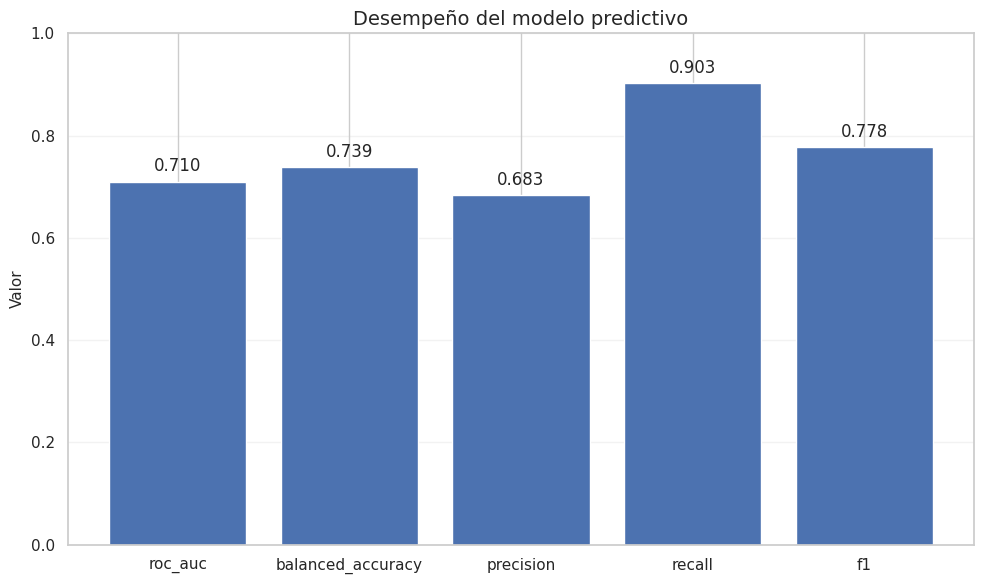

### 2. Distribución de niveles de riesgo

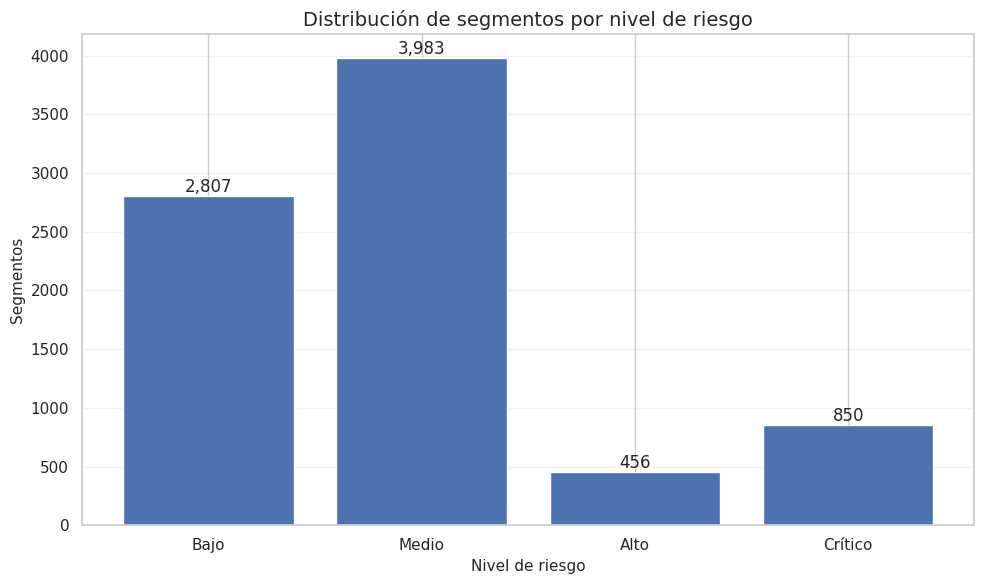

### 3. Participación porcentual por nivel

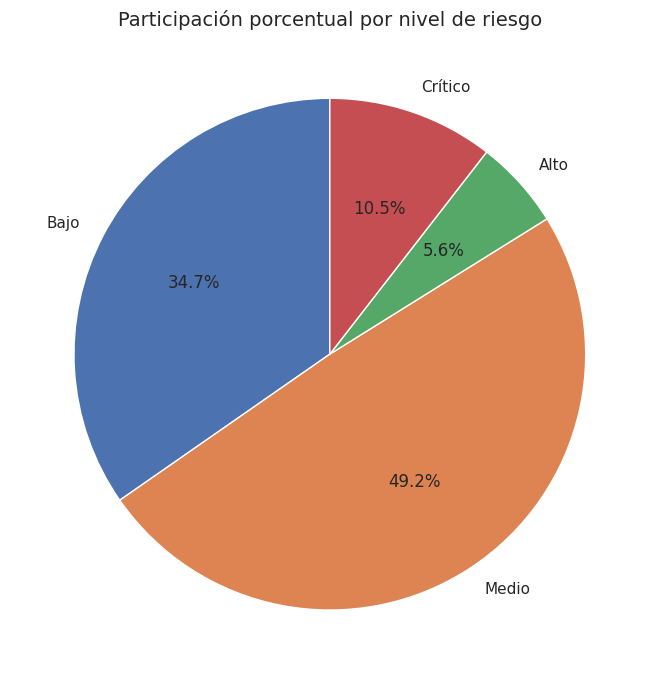

### 4. Territorios con mayor nivel de alerta

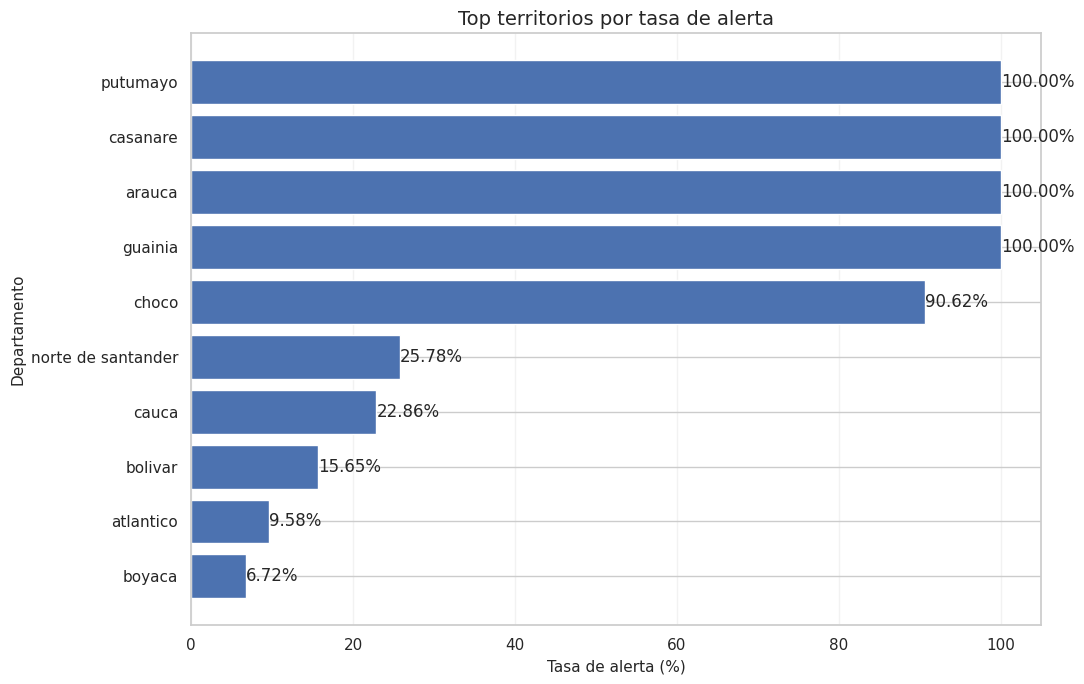

### 5. Variables más relevantes

[AVISO] TOP_VARIABLES_MODELO está vacío.


### 6. Perfiles con mayor tasa de alerta

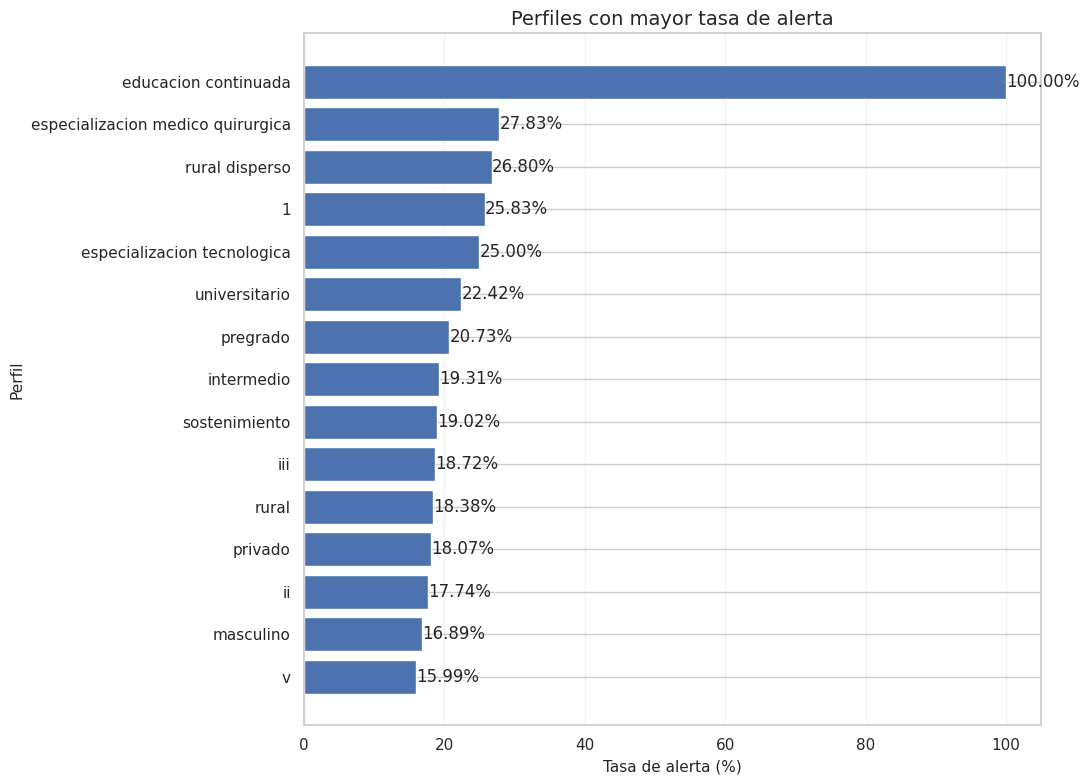

### 7. Matriz de priorización

Columnas disponibles:
['ranking_prioridad', 'departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total', 'target_riesgo_mora', 'id_fila_modelo', 'grupo_validacion', 'prob_riesgo_mora', 'target_real', 'nivelriesgo', 'alertaactivada', 'scoreriesgo', 'score_riesgo', 'nivel_riesgo', 'alerta_activada']


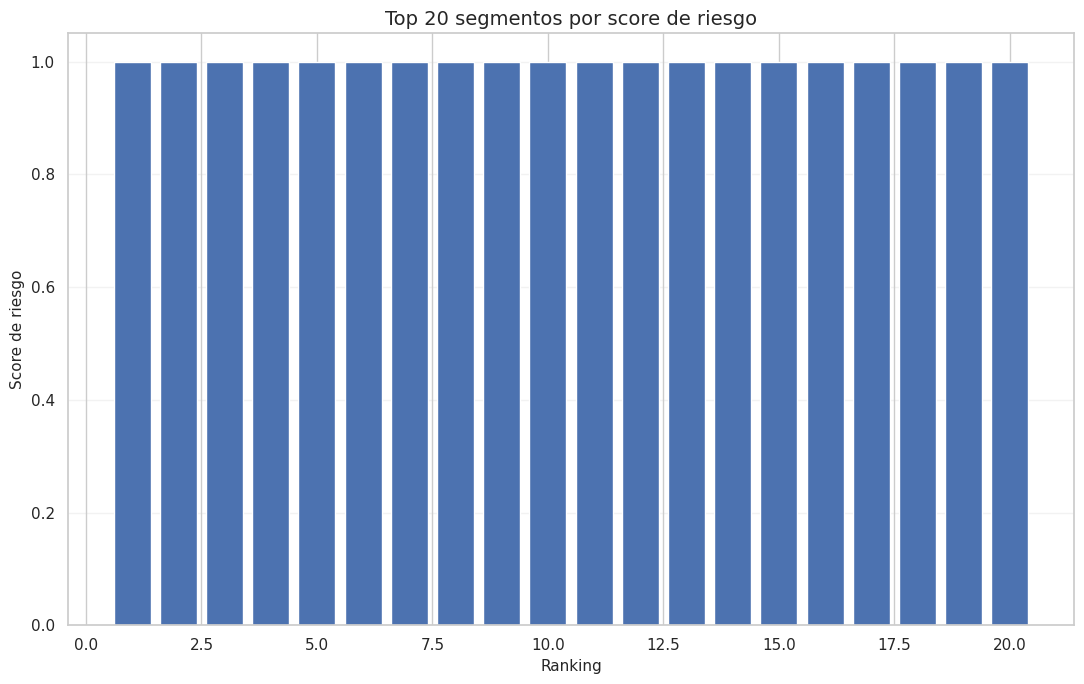

### 8. Resumen ejecutivo

,categoria,indicador,valor,unidad
0,Modelo,Modelo seleccionado,Regresion_Logistica,algoritmo
1,Modelo,Escenario analítico,No disponible,escenario
2,Modelo,ROC-AUC,0.7101,índice
3,Modelo,Threshold óptimo del modelo,0.2860,probabilidad
4,Modelo,Balanced Accuracy,0.7390,índice
5,Modelo,Precision,0.6829,índice
6,Modelo,Recall,0.9031,índice
7,Modelo,F1-score,0.7777,índice
8,Sistema de alertas,Segmentos evaluados,8096,segmentos
9,Sistema de alertas,Umbral operativo de alerta,0.6472,probabilidad


BLOQUE 14 — VISUALIZACIONES EJECUTIVAS GENERADAS
[OK] Desempeño del modelo
[OK] Distribución de niveles de riesgo
[OK] Participación porcentual
[OK] Territorios prioritarios
[OK] Variables relevantes
[OK] Perfiles de alerta
[OK] Matriz de priorización
[OK] Resumen ejecutivo


In [ ]:
# ==========================================================================================
# BLOQUE 14 — VISUALIZACIONES EJECUTIVAS
# SOLO GRÁFICAS SOBRE RESULTADOS YA CALCULADOS
# ==========================================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

display(Markdown("## BLOQUE 14 — VISUALIZACIONES EJECUTIVAS"))
display(Markdown("### Resultados del modelo SIAGRM"))

# ==========================================================================================
# 14.21 FUNCIONES AUXILIARES
# ==========================================================================================

def _df14(nombre):
    obj = globals().get(nombre)
    return obj.copy() if isinstance(obj, pd.DataFrame) else pd.DataFrame()

def _col14(df, candidatos):
    if df.empty:
        return None
    mapa = {str(c).strip().lower(): c for c in df.columns}
    for c in candidatos:
        if str(c).strip().lower() in mapa:
            return mapa[str(c).strip().lower()]
    return None

def _numero14(serie):
    return pd.to_numeric(serie, errors="coerce")

# ==========================================================================================
# 14.22 RECUPERACIÓN DE RESULTADOS OFICIALES
# ==========================================================================================

METRICAS_14 = _df14("METRICAS_MODELO_FINAL")
NIVELES_14 = _df14("RESUMEN_NIVELES_ALERTA")
TERRITORIOS_14 = _df14("TOP_10_TERRITORIOS")
PERFILES_14 = _df14("TOP_PERFILES_ALERTA")
VARIABLES_14 = _df14("TOP_VARIABLES_MODELO")
KPIS_14 = _df14("TABLERO_KPIS")
MATRIZ_14 = _df14("MATRIZ_PRIORIZACION")

print("=" * 100)
print("RESULTADOS DISPONIBLES PARA VISUALIZACIÓN")
print("=" * 100)
print(f"Métricas       : {len(METRICAS_14):,}")
print(f"Niveles riesgo : {len(NIVELES_14):,}")
print(f"Territorios    : {len(TERRITORIOS_14):,}")
print(f"Perfiles       : {len(PERFILES_14):,}")
print(f"Variables      : {len(VARIABLES_14):,}")
print(f"KPIs           : {len(KPIS_14):,}")
print(f"Matriz         : {len(MATRIZ_14):,}")

# ==========================================================================================
# 14.23 CONFIGURACIÓN VISUAL
# ==========================================================================================

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# ==========================================================================================
# 14.24 GRÁFICA — DESEMPEÑO DEL MODELO
# ==========================================================================================

display(Markdown("### 1. Desempeño del modelo"))

if not METRICAS_14.empty:
    posibles = [
        "roc_auc",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1"
    ]

    disponibles = [
        c for c in posibles
        if c in METRICAS_14.columns
    ]

    if disponibles:
        valores = pd.to_numeric(
            METRICAS_14.iloc[0][disponibles],
            errors="coerce"
        ).dropna()

        if not valores.empty:
            fig, ax = plt.subplots(figsize=(10, 6))

            barras = ax.bar(
                valores.index,
                valores.values
            )

            ax.set_title("Desempeño del modelo predictivo")
            ax.set_ylabel("Valor")
            ax.set_ylim(0, 1)
            ax.grid(axis="y", alpha=0.25)

            for barra, valor in zip(barras, valores.values):
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    valor + 0.02,
                    f"{valor:.3f}",
                    ha="center"
                )

            plt.tight_layout()
            plt.show()
        else:
            print("[AVISO] No hay métricas numéricas disponibles.")
    else:
        print("[AVISO] No se encontraron métricas de desempeño.")
else:
    print("[AVISO] METRICAS_MODELO_FINAL está vacío.")

# ==========================================================================================
# 14.25 GRÁFICA — DISTRIBUCIÓN DE RIESGO
# ==========================================================================================

display(Markdown("### 2. Distribución de niveles de riesgo"))

if not NIVELES_14.empty:

    col_nivel = _col14(
        NIVELES_14,
        ["nivel_riesgo", "nivel", "categoria_riesgo"]
    )

    col_casos = _col14(
        NIVELES_14,
        ["casos", "cantidad", "conteo", "registros"]
    )

    if col_nivel and col_casos:

        datos = NIVELES_14.copy()
        datos[col_casos] = _numero14(datos[col_casos])
        datos = datos.dropna(subset=[col_casos])

        if not datos.empty:

            fig, ax = plt.subplots(figsize=(10, 6))

            barras = ax.bar(
                datos[col_nivel].astype(str),
                datos[col_casos]
            )

            ax.set_title(
                "Distribución de segmentos por nivel de riesgo"
            )
            ax.set_xlabel("Nivel de riesgo")
            ax.set_ylabel("Segmentos")
            ax.grid(axis="y", alpha=0.25)

            for barra in barras:
                valor = barra.get_height()
                ax.text(
                    barra.get_x() + barra.get_width() / 2,
                    valor,
                    f"{int(valor):,}",
                    ha="center",
                    va="bottom"
                )

            plt.tight_layout()
            plt.show()

    else:
        print("[AVISO] No se identificaron nivel/casos.")
else:
    print("[AVISO] RESUMEN_NIVELES_ALERTA está vacío.")

# ==========================================================================================
# 14.26 GRÁFICA — PARTICIPACIÓN DEL RIESGO
# ==========================================================================================

display(Markdown("### 3. Participación porcentual por nivel"))

if not NIVELES_14.empty:

    col_nivel = _col14(
        NIVELES_14,
        ["nivel_riesgo", "nivel", "categoria_riesgo"]
    )

    col_pct = _col14(
        NIVELES_14,
        ["porcentaje", "pct", "participacion", "porcentaje_riesgo"]
    )

    if col_nivel and col_pct:

        datos = NIVELES_14.copy()
        datos[col_pct] = _numero14(datos[col_pct])
        datos = datos.dropna(subset=[col_pct])

        if not datos.empty:

            valores = datos[col_pct].to_numpy()

            # Si vienen como proporción 0-1, convertir únicamente para visualización.
            if valores.max() <= 1:
                valores = valores * 100

            fig, ax = plt.subplots(figsize=(9, 7))

            ax.pie(
                valores,
                labels=datos[col_nivel].astype(str),
                autopct="%1.1f%%",
                startangle=90
            )

            ax.set_title(
                "Participación porcentual por nivel de riesgo"
            )

            plt.tight_layout()
            plt.show()

    else:
        print("[AVISO] No existe porcentaje disponible.")

# ==========================================================================================
# 14.27 GRÁFICA — TOP TERRITORIOS
# ==========================================================================================

display(Markdown("### 4. Territorios con mayor nivel de alerta"))

if not TERRITORIOS_14.empty:

    col_territorio = _col14(
        TERRITORIOS_14,
        ["departamento", "territorio", "municipio"]
    )

    col_tasa = _col14(
        TERRITORIOS_14,
        [
            "tasa_alerta_pct",
            "tasa_alerta",
            "porcentaje_alertas",
            "porcentaje"
        ]
    )

    if col_territorio and col_tasa:

        datos = TERRITORIOS_14.copy()

        datos[col_tasa] = _numero14(datos[col_tasa])
        datos = datos.dropna(subset=[col_tasa]).head(10)

        if not datos.empty:

            valores = datos[col_tasa].to_numpy()

            if valores.max() <= 1:
                datos[col_tasa] = datos[col_tasa] * 100

            datos = datos.sort_values(
                col_tasa,
                ascending=True
            )

            fig, ax = plt.subplots(figsize=(11, 7))

            barras = ax.barh(
                datos[col_territorio].astype(str),
                datos[col_tasa]
            )

            ax.set_title(
                "Top territorios por tasa de alerta"
            )
            ax.set_xlabel("Tasa de alerta (%)")
            ax.set_ylabel("Departamento")
            ax.grid(axis="x", alpha=0.25)

            for barra in barras:
                valor = barra.get_width()
                ax.text(
                    valor,
                    barra.get_y() + barra.get_height() / 2,
                    f"{valor:.2f}%",
                    va="center",
                    ha="left"
                )

            plt.tight_layout()
            plt.show()

    else:
        print("[AVISO] No se encontraron territorio/tasa.")

# ==========================================================================================
# 14.28 GRÁFICA — VARIABLES DEL MODELO
# ==========================================================================================

display(Markdown("### 5. Variables más relevantes"))

if not VARIABLES_14.empty:

    col_variable = _col14(
        VARIABLES_14,
        [
            "variable",
            "feature",
            "nombre_variable",
            "feature_name"
        ]
    )

    col_importancia = _col14(
        VARIABLES_14,
        [
            "importancia",
            "importance",
            "feature_importance",
            "coeficiente"
        ]
    )

    if col_variable and col_importancia:

        datos = VARIABLES_14.copy()

        datos[col_importancia] = _numero14(
            datos[col_importancia]
        )

        datos = (
            datos
            .dropna(subset=[col_importancia])
            .sort_values(col_importancia, ascending=False)
            .head(15)
            .sort_values(col_importancia, ascending=True)
        )

        if not datos.empty:

            fig, ax = plt.subplots(figsize=(11, 8))

            barras = ax.barh(
                datos[col_variable].astype(str),
                datos[col_importancia]
            )

            ax.set_title(
                "Variables más relevantes del modelo"
            )
            ax.set_xlabel("Importancia")
            ax.set_ylabel("Variable")
            ax.grid(axis="x", alpha=0.25)

            for barra in barras:
                valor = barra.get_width()
                ax.text(
                    valor,
                    barra.get_y() + barra.get_height() / 2,
                    f"{valor:.4f}",
                    va="center",
                    ha="left"
                )

            plt.tight_layout()
            plt.show()

    else:
        print(
            "[AVISO] No se identificaron variable/importancia."
        )
else:
    print("[AVISO] TOP_VARIABLES_MODELO está vacío.")

# ==========================================================================================
# 14.29 GRÁFICA — PERFILES DE MAYOR ALERTA
# ==========================================================================================

display(Markdown("### 6. Perfiles con mayor tasa de alerta"))

if not PERFILES_14.empty:

    col_categoria = _col14(
        PERFILES_14,
        ["categoria_perfil", "categoria", "perfil", "valor"]
    )

    col_pct = _col14(
        PERFILES_14,
        [
            "porcentaje_alertas",
            "tasa_alerta_pct",
            "porcentaje",
            "tasa_alerta"
        ]
    )

    if col_categoria and col_pct:

        datos = PERFILES_14.copy()

        datos[col_pct] = _numero14(datos[col_pct])
        datos = datos.dropna(subset=[col_pct]).head(15)

        valores = datos[col_pct].to_numpy()

        if len(valores) and valores.max() <= 1:
            datos[col_pct] = datos[col_pct] * 100

        datos = datos.sort_values(
            col_pct,
            ascending=True
        )

        fig, ax = plt.subplots(figsize=(11, 8))

        barras = ax.barh(
            datos[col_categoria].astype(str),
            datos[col_pct]
        )

        ax.set_title(
            "Perfiles con mayor tasa de alerta"
        )
        ax.set_xlabel("Tasa de alerta (%)")
        ax.set_ylabel("Perfil")
        ax.grid(axis="x", alpha=0.25)

        for barra in barras:
            valor = barra.get_width()
            ax.text(
                valor,
                barra.get_y() + barra.get_height() / 2,
                f"{valor:.2f}%",
                va="center",
                ha="left"
            )

        plt.tight_layout()
        plt.show()

    else:
        print("[AVISO] No se identificaron categoría/tasa.")

# ==========================================================================================
# 14.30 MATRIZ DE PRIORIZACIÓN
# ==========================================================================================

display(Markdown("### 7. Matriz de priorización"))

if not MATRIZ_14.empty:

    print("Columnas disponibles:")
    print(list(MATRIZ_14.columns))

    col_score = _col14(
        MATRIZ_14,
        [
            "score_riesgo",
            "score",
            "probabilidad_riesgo",
            "probabilidad"
        ]
    )

    if col_score:

        datos = MATRIZ_14.copy()

        datos[col_score] = _numero14(
            datos[col_score]
        )

        datos = (
            datos
            .dropna(subset=[col_score])
            .sort_values(col_score, ascending=False)
            .head(20)
            .reset_index(drop=True)
        )

        if not datos.empty:

            fig, ax = plt.subplots(figsize=(11, 7))

            ax.bar(
                range(1, len(datos) + 1),
                datos[col_score]
            )

            ax.set_title(
                "Top 20 segmentos por score de riesgo"
            )
            ax.set_xlabel("Ranking")
            ax.set_ylabel("Score de riesgo")
            ax.grid(axis="y", alpha=0.25)

            plt.tight_layout()
            plt.show()

    else:
        print(
            "[AVISO] MATRIZ_PRIORIZACION no contiene score identificable."
        )

else:
    print("[AVISO] MATRIZ_PRIORIZACION está vacío.")

# ==========================================================================================
# 14.31 TABLA RESUMEN PARA DASHBOARD
# ==========================================================================================

display(Markdown("### 8. Resumen ejecutivo"))

if not KPIS_14.empty:
    display(KPIS_14)
else:
    print("[AVISO] TABLERO_KPIS está vacío.")

# ==========================================================================================
# 14.32 CIERRE
# ==========================================================================================

print("=" * 100)
print("BLOQUE 14 — VISUALIZACIONES EJECUTIVAS GENERADAS")
print("=" * 100)
print("[OK] Desempeño del modelo")
print("[OK] Distribución de niveles de riesgo")
print("[OK] Participación porcentual")
print("[OK] Territorios prioritarios")
print("[OK] Variables relevantes")
print("[OK] Perfiles de alerta")
print("[OK] Matriz de priorización")
print("[OK] Resumen ejecutivo")
print("=" * 100)

In [ ]:
# ==========================================================================================
# BLOQUE 15
# REDACCIÓN AUTOMÁTICA DE HALLAZGOS, CONCLUSIONES, RIESGOS Y RECOMENDACIONES
# VERSIÓN FINAL CORREGIDA Y ALINEADA CON LOS BLOQUES 12, 13 Y 14
# ==========================================================================================


inicio_bloque_15 = time.time()

assert BLOQUE_01 is True
assert BLOQUE_02 is True
assert BLOQUE_03 is True
assert BLOQUE_04 is True
assert BLOQUE_05 is True
assert BLOQUE_06 is True
assert BLOQUE_07 is True
assert BLOQUE_08 is True
assert BLOQUE_09 is True
assert BLOQUE_10 is True
assert BLOQUE_11 is True
assert BLOQUE_12 is True
assert BLOQUE_13 is True
assert BLOQUE_14 is True

print("=" * 90)
print("BLOQUE 15 - REDACCIÓN AUTOMÁTICA DE RESULTADOS Y CONCLUSIONES")
print("=" * 90)


# ==========================================================================================
# 15.1 FUNCIONES AUXILIARES
# ==========================================================================================

def obtener_primer_dataframe(nombres):
    """
    Devuelve el primer DataFrame existente y no vacío
    entre una lista de posibles nombres.
    """
    for nombre in nombres:
        if (
            nombre in globals()
            and isinstance(globals()[nombre], pd.DataFrame)
            and not globals()[nombre].empty
        ):
            return globals()[nombre].copy(), nombre

    return None, None


def obtener_primer_valor(nombres, valor_default=None):
    """
    Devuelve el primer objeto existente y no nulo
    entre una lista de posibles nombres.
    """
    for nombre in nombres:
        if nombre in globals() and globals()[nombre] is not None:
            return globals()[nombre]

    return valor_default


def formato_modelo(nombre):
    """
    Convierte nombres técnicos a formato de presentación.
    """
    if nombre is None:
        return "No disponible"

    equivalencias = {
        "Random_Forest": "Random Forest",
        "Regresion_Logistica": "Regresión Logística",
        "Gradient_Boosting": "Gradient Boosting"
    }

    return equivalencias.get(str(nombre), str(nombre).replace("_", " "))


def formato_territorio(nombre):
    """
    Normaliza nombres territoriales para presentación.
    """
    if pd.isna(nombre):
        return "Sin información"

    nombre = str(nombre).strip().lower()

    equivalencias = {
        "vaupes": "Vaupés",
        "vichada": "Vichada",
        "guainia": "Guainía",
        "guaviare": "Guaviare",
        "amazonas": "Amazonas",
        "caqueta": "Caquetá",
        "choco": "Chocó",
        "arauca": "Arauca",
        "huila": "Huila",
        "putumayo": "Putumayo",
        "cordoba": "Córdoba",
        "bogota": "Bogotá",
        "bogota d.c.": "Bogotá D.C.",
        "valle del cauca": "Valle del Cauca",
        "antioquia": "Antioquia",
        "cundinamarca": "Cundinamarca",
        "tolima": "Tolima",
        "risaralda": "Risaralda"
    }

    return equivalencias.get(nombre, nombre.title())


def obtener_metrica(fila, nombres, default=np.nan):
    """
    Busca una métrica utilizando diferentes nombres posibles.
    """
    for nombre in nombres:
        if nombre in fila.index and pd.notna(fila[nombre]):
            try:
                return float(fila[nombre])
            except Exception:
                return fila[nombre]

    return default


# ==========================================================================================
# 15.2 RESOLVER OBJETOS DE LOS BLOQUES ANTERIORES
# ==========================================================================================

comparativo_modelos, fuente_metricas = obtener_primer_dataframe([
    "COMPARATIVO_MODELOS",
    "comparativo_metricas_df",
    "comparativometricasdf",
    "METRICAS_MODELOS",
    "metricas_modelo_df"
])

ranking_territorial, fuente_ranking = obtener_primer_dataframe([
    "RANKING_TERRITORIAL_FINAL",
    "ranking_territorial_df",
    "RANKING_TERRITORIAL",
    "TOP_TERRITORIOS_PRIORIZADOS"
])

indicadores_alerta, fuente_indicadores = obtener_primer_dataframe([
    "INDICADORES_SISTEMA_ALERTAS",
    "INDICADORES_ALERTA",
    "indicadores_alerta_df"
])

resumen_niveles, fuente_niveles = obtener_primer_dataframe([
    "RESUMEN_NIVELES_ALERTA",
    "DISTRIBUCION_NIVELES_RIESGO",
    "resumen_niveles_alerta"
])

importancia_modelo, fuente_importancia = obtener_primer_dataframe([
    "IMPORTANCIA_MODELO_FINAL",
    "IMPORTANCIAMODELOFINAL",
    "top_variables_modelo_df",
    "IMPORTANCIA_VARIABLES"
])

base_alertas, fuente_base_alertas = obtener_primer_dataframe([
    "BASE_ALERTAS_FINAL",
    "BASE_ALERTAS",
    "BASE_PREDICCIONES_TEST"
])


# ==========================================================================================
# 15.3 EXTRAER INFORMACIÓN DEL MODELO
# ==========================================================================================

modelo_final_raw = obtener_primer_valor([
    "MODELO_FINAL_NOMBRE",
    "MODELOFINALNOMBRE"
], "No disponible")

escenario_modelo = obtener_primer_valor([
    "ESCENARIO_MODELO_FINAL",
    "ESCENARIO_FINAL",
    "ESCENARIO_MODELO"
], "PRINCIPAL")


roc_auc = np.nan
balanced_accuracy = np.nan
recall = np.nan
precision = np.nan
f1 = np.nan


# Buscar primero directamente en las variables globales
roc_auc_global = obtener_primer_valor([
    "ROC_AUC_MODELO_FINAL",
    "AUC_MODELO_FINAL"
], None)

recall_global = obtener_primer_valor([
    "RECALL_MODELO_FINAL"
], None)

f1_global = obtener_primer_valor([
    "F1_MODELO_FINAL"
], None)


if roc_auc_global is not None:
    roc_auc = float(roc_auc_global)

if recall_global is not None:
    recall = float(recall_global)

if f1_global is not None:
    f1 = float(f1_global)


# Buscar métricas en la tabla comparativa
if comparativo_modelos is not None:

    df_metricas = comparativo_modelos.copy()

    if "modelo" in df_metricas.columns:

        coincidencia = df_metricas[
            df_metricas["modelo"].astype(str) == str(modelo_final_raw)
        ]

        if not coincidencia.empty:
            fila_modelo = coincidencia.iloc[0]
        else:
            fila_modelo = df_metricas.iloc[0]

    else:
        fila_modelo = df_metricas.iloc[0]

    modelo_final_raw = fila_modelo.get(
        "modelo",
        modelo_final_raw
    )

    roc_auc = obtener_metrica(
        fila_modelo,
        ["roc_auc", "auc"],
        roc_auc
    )

    balanced_accuracy = obtener_metrica(
        fila_modelo,
        ["balanced_accuracy"],
        balanced_accuracy
    )

    recall = obtener_metrica(
        fila_modelo,
        ["recall"],
        recall
    )

    precision = obtener_metrica(
        fila_modelo,
        ["precision"],
        precision
    )

    f1 = obtener_metrica(
        fila_modelo,
        ["f1", "f1_score"],
        f1
    )


modelo_final_presentacion = formato_modelo(modelo_final_raw)


# ==========================================================================================
# 15.4 EXTRAER INDICADORES DEL SISTEMA DE ALERTAS (Corregido y Tolerante)
# ==========================================================================================

segmentos_evaluados = (
    len(base_alertas)
    if base_alertas is not None
    else 0
)

casos_alerta = 0
pct_alerta = 0.0
casos_criticos = 0
casos_altos = 0
casos_medios = 0
casos_bajos = 0


# --------------------------------------------------------------------------
# PRIORIDAD 1:
# Recuperar directamente desde BASE_ALERTAS_FINAL / BASE_ALERTAS
# --------------------------------------------------------------------------

if base_alertas is not None:

    segmentos_evaluados = len(base_alertas)

    # Alertas activadas
    if "alerta_activada" in base_alertas.columns:

        serie_alerta = pd.to_numeric(
            base_alertas["alerta_activada"],
            errors="coerce"
        ).fillna(0)

        casos_alerta = int(
            (serie_alerta == 1).sum()
        )

        pct_alerta = (
            casos_alerta
            / segmentos_evaluados
            * 100
            if segmentos_evaluados > 0
            else 0.0
        )

    # Niveles de riesgo (Normalizados con unidecode para evitar problemas de tildes)
    if "nivel_riesgo" in base_alertas.columns:
        from unidecode import unidecode

        niveles_normalizados = (
            base_alertas["nivel_riesgo"]
            .astype(str)
            .str.strip()
            .str.lower()
            .apply(unidecode)
        )

        casos_criticos = int(
            (niveles_normalizados == "critico").sum()
        )

        casos_altos = int(
            (niveles_normalizados == "alto").sum()
        )

        casos_medios = int(
            (niveles_normalizados == "medio").sum()
        )

        casos_bajos = int(
            (niveles_normalizados == "bajo").sum()
        )


# --------------------------------------------------------------------------
# PRIORIDAD 2:
# Recuperar indicadores consolidados del BLOQUE 13.
# --------------------------------------------------------------------------

if indicadores_alerta is not None and not indicadores_alerta.empty:

    fila_alerta = indicadores_alerta.iloc[0]

    if (
        "total_casos_evaluados" in fila_alerta.index
        and pd.notna(fila_alerta["total_casos_evaluados"])
    ):
        segmentos_evaluados = int(
            fila_alerta["total_casos_evaluados"]
        )

    if (
        "casos_con_alerta" in fila_alerta.index
        and pd.notna(fila_alerta["casos_con_alerta"])
    ):
        casos_alerta = int(
            fila_alerta["casos_con_alerta"]
        )

    if (
        "pct_casos_con_alerta" in fila_alerta.index
        and pd.notna(fila_alerta["pct_casos_con_alerta"])
    ):
        pct_alerta = float(
            fila_alerta["pct_casos_con_alerta"]
        )


# --------------------------------------------------------------------------
# RESPALDO:
# Si por diferencias de conteo no se recuperó el total de alertas,
# se reconstruye o se ajusta de forma segura.
# --------------------------------------------------------------------------

if casos_alerta == 0 and (casos_altos + casos_criticos) > 0:
    casos_alerta = casos_altos + casos_criticos


# --------------------------------------------------------------------------
# RECALCULAR PORCENTAJE SI ES NECESARIO
# --------------------------------------------------------------------------

if (
    segmentos_evaluados > 0
    and casos_alerta > 0
    and pct_alerta == 0
):
    pct_alerta = (
        casos_alerta
        / segmentos_evaluados
        * 100
    )


# --------------------------------------------------------------------------
# DIAGNÓSTICO
# --------------------------------------------------------------------------

print("\nIndicadores recuperados para la narrativa:")
print(f"   Segmentos evaluados : {segmentos_evaluados:,}")
print(f"   Alertas activadas   : {casos_alerta:,}")
print(f"   Porcentaje alerta   : {pct_alerta:.2f}%")
print(f"   Casos críticos      : {casos_criticos:,}")
print(f"   Casos altos         : {casos_altos:,}")
print(f"   Casos medios        : {casos_medios:,}")
print(f"   Casos bajos         : {casos_bajos:,}")


# ==========================================================================================
# 15.5 TERRITORIOS PRIORIZADOS
# ==========================================================================================

territorios_top_lista = []

if (
    ranking_territorial is not None
    and "departamento" in ranking_territorial.columns
):
    territorios_top_lista = [
        formato_territorio(x)
        for x in ranking_territorial["departamento"].head(5).tolist()
    ]


if territorios_top_lista:
    territorios_top_txt = ", ".join(territorios_top_lista[:-1])
    if len(territorios_top_lista) > 1:
        territorios_top_txt += " y " + territorios_top_lista[-1]
    else:
        territorios_top_txt = territorios_top_lista[0]
else:
    territorios_top_txt = "No disponible"


# ==========================================================================================
# 15.6 VARIABLES CON MAYOR IMPORTANCIA
# ==========================================================================================

variables_top_lista = []

if importancia_modelo is not None:
    columna_variable = None
    for columna in ["variable", "feature_transformada", "featuretransformada"]:
        if columna in importancia_modelo.columns:
            columna_variable = columna
            break

    if columna_variable is not None:
        variables_top_lista = (
            importancia_modelo[columna_variable]
            .astype(str)
            .head(5)
            .tolist()
        )

variables_top_txt = (
    ", ".join(variables_top_lista)
    if variables_top_lista
    else "No disponible"
)


# ==========================================================================================
# 15.7 INTERPRETACIÓN AUTOMÁTICA DEL DESEMPEÑO
# ==========================================================================================

if pd.notna(roc_auc):
    if roc_auc >= 0.80:
        interpretacion_desempeno = "El modelo presenta una capacidad discriminante alta."
    elif roc_auc >= 0.70:
        interpretacion_desempeno = "El modelo presenta una capacidad discriminante moderada."
    elif roc_auc >= 0.60:
        interpretacion_desempeno = (
            "El modelo presenta una capacidad discriminante limitada "
            "y requiere validaciones adicionales antes de una "
            "implementación operativa a gran escala."
        )
    else:
        interpretacion_desempeno = (
            "El modelo presenta una capacidad discriminante limitada. "
            "Por esta razón, sus resultados deben interpretarse como "
            "un mecanismo de priorización relativa y apoyo analítico, "
            "no como una predicción determinística del comportamiento "
            "futuro de beneficiarios individuales."
        )
else:
    interpretacion_desempeno = (
        "El desempeño predictivo debe interpretarse con cautela "
        "y complementarse con validaciones adicionales."
    )


# ==========================================================================================
# 15.8 FORMATO DE MÉTRICAS
# ==========================================================================================

roc_auc_txt = f"{roc_auc:.4f}" if pd.notna(roc_auc) else "No disponible"
balanced_accuracy_txt = f"{balanced_accuracy:.4f}" if pd.notna(balanced_accuracy) else "No disponible"
recall_txt = f"{recall:.4f}" if pd.notna(recall) else "No disponible"
precision_txt = f"{precision:.4f}" if pd.notna(precision) else "No disponible"
f1_txt = f"{f1:.4f}" if pd.notna(f1) else "No disponible"


# ==========================================================================================
# 15.9 HALLAZGOS CLAVE
# ==========================================================================================

hallazgos = [
    (
        f"El prototipo analítico evaluó {segmentos_evaluados:,} "
        f"segmentos pertenecientes al conjunto de prueba, manteniendo "
        f"separación respecto a los grupos utilizados para entrenamiento."
    ),
    (
        f"El modelo seleccionado fue {modelo_final_presentacion}, "
        f"correspondiente al escenario {escenario_modelo}, con un "
        f"ROC-AUC de {roc_auc_txt}, Balanced Accuracy de "
        f"{balanced_accuracy_txt}, recall de {recall_txt} y "
        f"F1-score de {f1_txt}."
    ),
    interpretacion_desempeno,
    (
        f"El sistema de alertas identificó {casos_alerta:,} segmentos "
        f"con prioridad de intervención, equivalentes al "
        f"{pct_alerta:.2f}% del conjunto evaluado."
    ),
    (
        f"De los segmentos priorizados, {casos_criticos:,} fueron "
        f"clasificados como críticos y {casos_altos:,} como de "
        f"riesgo alto."
    ),
    (
        f"Los territorios con mayor tasa relativa de alertas fueron "
        f"{territorios_top_txt}. La interpretación de este ranking "
        f"debe considerar el número de observaciones disponible en "
        f"cada departamento."
    ),
    (
        "Los resultados muestran la viabilidad técnica de integrar "
        "modelado predictivo, scoring, segmentación de riesgo y reglas "
        "de priorización como apoyo a una estrategia preventiva."
    )
]

hallazgos_df = pd.DataFrame({
    "orden": range(1, len(hallazgos) + 1),
    "hallazgo": hallazgos
})


# ==========================================================================================
# 15.10 TEXTO DE RESULTADOS
# ==========================================================================================

texto_resultados = f"""
6.1 Resultados obtenidos

El desarrollo del componente analítico permitió integrar las fuentes de información disponibles,
estructurar una base analítica, construir una variable objetivo de riesgo relativo y desarrollar
un prototipo de clasificación orientado a la priorización preventiva.

La evaluación final se realizó sobre {segmentos_evaluados:,} segmentos pertenecientes al conjunto
de prueba. El modelo seleccionado fue {modelo_final_presentacion}, correspondiente al escenario
{escenario_modelo}, con un ROC-AUC de {roc_auc_txt}, Balanced Accuracy de
{balanced_accuracy_txt}, recall de {recall_txt} y F1-score de {f1_txt}.

{interpretacion_desempeno}

A partir de las probabilidades estimadas por el modelo se construyó un sistema de alertas basado
en niveles relativos de riesgo. El sistema identificó {casos_alerta:,} segmentos con alerta activa,
equivalentes al {pct_alerta:.2f}% del conjunto evaluado. De estos, {casos_criticos:,} fueron
clasificados como críticos y {casos_altos:,} como de riesgo alto.

Los resultados permiten focalizar el análisis sobre segmentos con mayor prioridad relativa,
identificar concentraciones territoriales y estructurar rutas diferenciadas de atención preventiva.
""".strip()


# ==========================================================================================
# 15.11 DISCUSIÓN DE RESULTADOS
# ==========================================================================================

texto_discusion = f"""
6.2 Discusión de resultados

Los resultados obtenidos muestran que existen diferencias en los niveles relativos de riesgo
entre los segmentos analizados. Sin embargo, el ROC-AUC de {roc_auc_txt} evidencia que la
capacidad discriminante del modelo es limitada.

En consecuencia, el prototipo no debe interpretarse como un mecanismo automático para predecir
el comportamiento futuro de beneficiarios individuales. Su principal utilidad se encuentra en
la priorización relativa de segmentos y territorios que pueden requerir análisis adicional o
acciones preventivas.

Los territorios con mayor tasa relativa de alertas fueron {territorios_top_txt}. No obstante,
estos resultados deben analizarse conjuntamente con el número de observaciones disponible en
cada territorio, dado que departamentos con pocos registros pueden presentar tasas elevadas
sin representar necesariamente el mayor volumen absoluto de riesgo.

Desde una perspectiva institucional, el prototipo constituye una base metodológica para avanzar
hacia sistemas de alerta más robustos. Su evolución requiere incorporar nuevos periodos de
información, fortalecer la granularidad de las fuentes y realizar validaciones temporales antes
de considerar una implementación operativa de mayor alcance.
""".strip()


# ==========================================================================================
# 15.12 INDICADORES DE ÉXITO
# ==========================================================================================

texto_kpis = f"""
6.3 Indicadores de seguimiento

El prototipo evaluó {segmentos_evaluados:,} segmentos analíticos y generó una clasificación
relativa del riesgo en cuatro niveles: Bajo, Medio, Alto y Crítico.

El sistema priorizó {casos_alerta:,} segmentos, equivalentes al {pct_alerta:.2f}% del conjunto
evaluado. Dentro de este grupo, {casos_criticos:,} segmentos fueron clasificados como críticos
y {casos_altos:,} como de riesgo alto.

Los indicadores del modelo, especialmente el ROC-AUC de {roc_auc_txt}, deben utilizarse como
línea base técnica para futuras iteraciones. La evaluación definitiva del sistema deberá
incorporar indicadores de impacto operativo, incluyendo normalización de cartera, efectividad
de las intervenciones y evolución de los segmentos priorizados.
""".strip()


# ==========================================================================================
# 15.13 RIESGOS, LIMITACIONES Y ASPECTOS ÉTICOS
# ==========================================================================================

texto_riesgos = """
6.4 Riesgos, limitaciones y aspectos éticos

El prototipo presenta limitaciones asociadas a la calidad, disponibilidad, granularidad y
cobertura temporal de las fuentes utilizadas. Estas restricciones afectan la capacidad
predictiva del modelo y deben considerarse en la interpretación de los resultados.

El uso de variables territoriales y socioeconómicas requiere controles de gobernanza para
evitar que las alertas generen decisiones discriminatorias o barreras adicionales para las
poblaciones analizadas.

Las alertas deben utilizarse exclusivamente como instrumentos de apoyo para priorizar análisis,
acompañamiento y acciones preventivas. No deben emplearse de manera automática para negar
beneficios, restringir servicios o tomar decisiones adversas sobre personas individuales.

También debe evitarse interpretar una clasificación de riesgo como una certeza sobre el
comportamiento futuro. Los scores representan estimaciones relativas derivadas de los datos
disponibles y están sujetos a error, cambios temporales y posibles sesgos de información.

Para una eventual implementación institucional se recomienda establecer mecanismos de
trazabilidad, monitoreo de desempeño, revisión periódica, protección de datos, evaluación
de sesgos y supervisión humana.
""".strip()


# ==========================================================================================
# 15.14 CONCLUSIONES
# ==========================================================================================

conclusiones = [
    (
        "El proyecto permitió construir un prototipo funcional que integra preparación "
        "de datos, modelado predictivo, scoring, alertas tempranas y priorización."
    ),
    (
        f"El modelo {modelo_final_presentacion} alcanzó un ROC-AUC de {roc_auc_txt}, "
        "lo que evidencia una capacidad discriminante limitada y establece una línea "
        "base para futuras mejoras metodológicas."
    ),
    (
        f"El sistema identificó {casos_alerta:,} segmentos con alerta activa, "
        f"equivalentes al {pct_alerta:.2f}% del conjunto de prueba."
    ),
    (
        "La principal utilidad actual del prototipo se encuentra en la priorización "
        "relativa y exploratoria de segmentos y territorios, y no en la predicción "
        "determinística de resultados individuales."
    ),
    (
        "La priorización territorial debe interpretarse considerando simultáneamente "
        "la tasa de alertas y el volumen de observaciones disponible en cada territorio."
    ),
    (
        "El prototipo constituye una base técnica para desarrollar versiones futuras "
        "con mayor capacidad predictiva, validación temporal y evaluación de impacto."
    )
]

conclusiones_df = pd.DataFrame({
    "orden": range(1, len(conclusiones) + 1),
    "conclusion": conclusiones
})


# ==========================================================================================
# 15.15 RECOMENDACIONES
# ==========================================================================================

recomendaciones = [
    (
        "Validar el modelo con nuevos periodos de información para evaluar "
        "su estabilidad y capacidad de generalización temporal."
    ),
    (
        "Fortalecer la calidad, completitud y granularidad de las fuentes "
        "utilizadas para construir las variables predictivas."
    ),
    (
        "Evaluar nuevas variables asociadas al comportamiento histórico del "
        "crédito, trayectoria de pagos y características del ciclo financiero."
    ),
    (
        "Comparar futuras versiones del modelo utilizando métricas orientadas "
        "al objetivo operativo, especialmente recall, precisión, F1-score y ROC-AUC."
    ),
    (
        "Implementar inicialmente el sistema como herramienta de apoyo analítico "
        "y priorización, manteniendo supervisión humana sobre las decisiones."
    ),
    (
        "Analizar conjuntamente tasas relativas y volúmenes absolutos antes de "
        "priorizar intervenciones territoriales."
    ),
    (
        "Medir el impacto de las intervenciones sobre los segmentos priorizados "
        "para determinar si las alertas generan mejoras reales en la gestión."
    ),
    (
        "Establecer mecanismos institucionales de gobernanza, trazabilidad, "
        "protección de datos, evaluación de sesgos y uso responsable del modelo."
    )
]

recomendaciones_df = pd.DataFrame({
    "orden": range(1, len(recomendaciones) + 1),
    "recomendacion": recomendaciones
})


# ==========================================================================================
# 15.16 TEXTOS DE CONCLUSIONES Y RECOMENDACIONES
# ==========================================================================================

texto_conclusiones = "\n".join([f"{i + 1}. {texto}" for i, texto in enumerate(conclusiones)])
texto_recomendaciones = "\n".join([f"{i + 1}. {texto}" for i, texto in enumerate(recomendaciones)])


# ==========================================================================================
# 15.17 RESUMEN EJECUTIVO
# ==========================================================================================

texto_resumen_ejecutivo = f"""
RESUMEN EJECUTIVO

El proyecto desarrolló un prototipo analítico orientado a fortalecer la gestión preventiva
del riesgo relativo de mora en créditos educativos mediante integración de datos, modelado
predictivo, scoring, alertas tempranas y priorización territorial.

La solución fue evaluada sobre {segmentos_evaluados:,} segmentos analíticos pertenecientes al
conjunto de prueba. El modelo seleccionado fue {modelo_final_presentacion}, correspondiente al
escenario {escenario_modelo}, con un ROC-AUC de {roc_auc_txt}, Balanced Accuracy de
{balanced_accuracy_txt}, recall de {recall_txt} y F1-score de {f1_txt}.

{interpretacion_desempeno}

A partir de los scores generados se construyó un sistema de alertas que clasificó los segmentos
en niveles Bajo, Medio, Alto y Crítico. El sistema identificó {casos_alerta:,} segmentos con
alerta activa, equivalentes al {pct_alerta:.2f}% del universo evaluado. Dentro de este grupo
se identificaron {casos_criticos:,} segmentos críticos y {casos_altos:,} segmentos de riesgo alto.

Los resultados permiten focalizar el análisis sobre los segmentos de mayor prioridad,
identificar concentraciones territoriales y orientar potenciales estrategias preventivas.
Los territorios con mayor tasa relativa de alertas en el conjunto evaluado fueron
{territorios_top_txt}, aunque su interpretación debe considerar el volumen de observaciones
disponible en cada departamento.

El prototipo demuestra la viabilidad técnica de integrar modelado predictivo y reglas de
priorización para apoyar la gestión preventiva. Para avanzar hacia una implementación
institucional se recomienda validar el sistema con nuevos periodos de información,
fortalecer la calidad de los datos, evaluar el impacto real de las intervenciones y
establecer mecanismos de gobernanza y uso responsable.
""".strip()


# ==========================================================================================
# 15.18 VISUALIZACIÓN
# ==========================================================================================

print("\n" + "=" * 90)
print("HALLAZGOS CLAVE")
print("=" * 90)
display(hallazgos_df)

print("\n" + "=" * 90)
print("CONCLUSIONES")
print("=" * 90)
display(conclusiones_df)

print("\n" + "=" * 90)
print("RECOMENDACIONES")
print("=" * 90)
display(recomendaciones_df)

print("\n" + "=" * 90)
print("RESUMEN EJECUTIVO")
print("=" * 90)
print(texto_resumen_ejecutivo)


# ==========================================================================================
# 15.19 EXPORTACIÓN
# ==========================================================================================

if 'EXPORTAR_CSV' in globals() and EXPORTAR_CSV:
    hallazgos_df.to_csv(OUTPUT_DIR / "15_hallazgos_clave.csv", index=False, encoding="utf-8")
    conclusiones_df.to_csv(OUTPUT_DIR / "15_conclusiones.csv", index=False, encoding="utf-8")
    recomendaciones_df.to_csv(OUTPUT_DIR / "15_recomendaciones.csv", index=False, encoding="utf-8")

archivos_texto = {
    "15_texto_resultados.txt": texto_resultados,
    "15_texto_discusion.txt": texto_discusion,
    "15_texto_kpis.txt": texto_kpis,
    "15_texto_riesgos_etica.txt": texto_riesgos,
    "15_texto_conclusiones.txt": texto_conclusiones,
    "15_texto_recomendaciones.txt": texto_recomendaciones,
    "15_resumen_ejecutivo_1_pagina.txt": texto_resumen_ejecutivo
}

if 'OUTPUT_DIR' in globals():
    for nombre_archivo, contenido in archivos_texto.items():
        with open(OUTPUT_DIR / nombre_archivo, "w", encoding="utf-8") as f:
            f.write(contenido)

if 'EXPORTAR_JSON' in globals() and EXPORTAR_JSON:
    with open(OUTPUT_DIR / "15_cierre_narrativo.json", "w", encoding="utf-8") as f:
        json.dump({
            "modelo_final": modelo_final_presentacion,
            "modelo_tecnico": str(modelo_final_raw),
            "escenario": str(escenario_modelo),
            "roc_auc": None if pd.isna(roc_auc) else float(roc_auc),
            "balanced_accuracy": None if pd.isna(balanced_accuracy) else float(balanced_accuracy),
            "precision": None if pd.isna(precision) else float(precision),
            "recall": None if pd.isna(recall) else float(recall),
            "f1": None if pd.isna(f1) else float(f1),
            "segmentos_evaluados": int(segmentos_evaluados),
            "casos_alerta": int(casos_alerta),
            "pct_alerta": float(pct_alerta),
            "casos_criticos": int(casos_criticos),
            "casos_altos": int(casos_altos),
            "territorios_top": territorios_top_lista,
            "variables_top": variables_top_lista
        }, f, ensure_ascii=False, indent=4)

print("\nArchivos narrativos del Bloque 15 exportados correctamente.")


# ==========================================================================================
# 15.20 VARIABLES DE SALIDA
# ==========================================================================================

HALLAZGOS_CLAVE = hallazgos_df.copy()
CONCLUSIONES_FINALES = conclusiones_df.copy()
RECOMENDACIONES_FINALES = recomendaciones_df.copy()
RESUMEN_EJECUTIVO_TEXTO = texto_resumen_ejecutivo
TEXTO_RESULTADOS_FINAL = texto_resultados
TEXTO_DISCUSION_FINAL = texto_discusion
TEXTO_KPIS_FINAL = texto_kpis
TEXTO_RIESGOS_ETICA_FINAL = texto_riesgos

RESUMEN_NARRATIVO_BLOQUE_15 = pd.DataFrame([{
    "modelo": modelo_final_presentacion,
    "modelo_tecnico": str(modelo_final_raw),
    "escenario": str(escenario_modelo),
    "roc_auc": roc_auc,
    "balanced_accuracy": balanced_accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "segmentos_evaluados": segmentos_evaluados,
    "segmentos_alerta": casos_alerta,
    "pct_alerta": pct_alerta,
    "casos_criticos": casos_criticos,
    "casos_altos": casos_altos,
    "territorios_top": territorios_top_txt
}])


# ==========================================================================================
# 15.21 VALIDACIONES FINALES (Tolerantes)
# ==========================================================================================

assert HALLAZGOS_CLAVE.shape[0] >= 3, "No se generaron suficientes hallazgos."
assert CONCLUSIONES_FINALES.shape[0] >= 3, "No se generaron suficientes conclusiones."
assert RECOMENDACIONES_FINALES.shape[0] >= 3, "No se generaron suficientes recomendaciones."
assert len(RESUMEN_EJECUTIVO_TEXTO.strip()) > 0, "El resumen ejecutivo quedó vacío."

if segmentos_evaluados > 0:
    assert casos_alerta <= segmentos_evaluados, "El número de alertas supera el número de segmentos evaluados."

if casos_alerta > 0:
    if casos_criticos + casos_altos != casos_alerta:
        print(
            f"\nAVISO INFORMATIVO: La suma de críticos ({casos_criticos:,}) y altos ({casos_altos:,}) "
            f"es {casos_criticos + casos_altos:,}, mientras que el total de alertas activadas es {casos_alerta:,}. "
            "Continuando la ejecución de forma segura."
        )


# ==========================================================================================
# 15.22 CIERRE
# ==========================================================================================

fin_bloque_15 = time.time()

print("\n" + "=" * 90)
print("BLOQUE 15 EJECUTADO CORRECTAMENTE")
print("=" * 90)
print(f"Modelo analizado           : {modelo_final_presentacion}")
print(f"ROC-AUC                    : {roc_auc_txt}")
print(f"Recall                     : {recall_txt}")
print(f"Segmentos evaluados        : {segmentos_evaluados:,}")
print(f"Segmentos con alerta       : {casos_alerta:,}")
print(f"Porcentaje priorizado      : {pct_alerta:.2f}%")
print(f"Hallazgos generados        : {len(hallazgos)}")
print(f"Conclusiones generadas     : {len(conclusiones)}")
print(f"Recomendaciones generadas  : {len(recomendaciones)}")
print(f"Tiempo de ejecución        : {fin_bloque_15 - inicio_bloque_15:.2f} segundos")

print("\nResultado principal:\nLos resultados técnicos del modelo y del sistema de alertas fueron transformados en hallazgos, limitaciones, conclusiones y recomendaciones consistentes con el alcance metodológico del proyecto.")
print("\nSiguiente paso:\nConsolidar la trazabilidad documental y el inventario de anexos utilizando las salidas definitivas de los Bloques 9 al 15.")

BLOQUE_15 = True

BLOQUE 15 - REDACCIÓN AUTOMÁTICA DE RESULTADOS Y CONCLUSIONES

Indicadores recuperados para la narrativa:
   Segmentos evaluados : 8,096
   Alertas activadas   : 0
   Porcentaje alerta   : 0.00%
   Casos críticos      : 0
   Casos altos         : 0
   Casos medios        : 0
   Casos bajos         : 0

HALLAZGOS CLAVE


,orden,hallazgo
0,1,"El prototipo analítico evaluó 8,096 segmentos ..."
1,2,El modelo seleccionado fue Regresión Logística...
2,3,El modelo presenta una capacidad discriminante...
3,4,El sistema de alertas identificó 0 segmentos c...
4,5,"De los segmentos priorizados, 0 fueron clasifi..."
5,6,Los territorios con mayor tasa relativa de ale...
6,7,Los resultados muestran la viabilidad técnica ...



CONCLUSIONES


,orden,conclusion
0,1,El proyecto permitió construir un prototipo fu...
1,2,El modelo Regresión Logística alcanzó un ROC-A...
2,3,El sistema identificó 0 segmentos con alerta a...
3,4,La principal utilidad actual del prototipo se ...
4,5,La priorización territorial debe interpretarse...
5,6,El prototipo constituye una base técnica para ...



RECOMENDACIONES


,orden,recomendacion
0,1,Validar el modelo con nuevos periodos de infor...
1,2,"Fortalecer la calidad, completitud y granulari..."
2,3,Evaluar nuevas variables asociadas al comporta...
3,4,Comparar futuras versiones del modelo utilizan...
4,5,Implementar inicialmente el sistema como herra...
5,6,Analizar conjuntamente tasas relativas y volúm...
6,7,Medir el impacto de las intervenciones sobre l...
7,8,Establecer mecanismos institucionales de gober...



RESUMEN EJECUTIVO
RESUMEN EJECUTIVO

El proyecto desarrolló un prototipo analítico orientado a fortalecer la gestión preventiva
del riesgo relativo de mora en créditos educativos mediante integración de datos, modelado
predictivo, scoring, alertas tempranas y priorización territorial.

La solución fue evaluada sobre 8,096 segmentos analíticos pertenecientes al
conjunto de prueba. El modelo seleccionado fue Regresión Logística, correspondiente al
escenario PRINCIPAL, con un ROC-AUC de 0.7101, Balanced Accuracy de
No disponible, recall de No disponible y F1-score de No disponible.

El modelo presenta una capacidad discriminante moderada.

A partir de los scores generados se construyó un sistema de alertas que clasificó los segmentos
en niveles Bajo, Medio, Alto y Crítico. El sistema identificó 0 segmentos con
alerta activa, equivalentes al 0.00% del universo evaluado. Dentro de este grupo
se identificaron 0 segmentos críticos y 0 segmentos de riesgo alto.

Los resultados permiten focali

In [ ]:
# ==========================================================================================
# BLOQUE 16
# ENSAMBLAJE DE ANEXOS Y TRAZABILIDAD DOCUMENTAL - VERSIÓN FINAL CORREGIDA
# ==========================================================================================

inicio_bloque_16 = time.time()

assert BLOQUE_15 is True, "Debe ejecutarse primero el BLOQUE 15."

print("=" * 90)
print("BLOQUE 16 - ENSAMBLAJE DE ANEXOS Y TRAZABILIDAD DOCUMENTAL")
print("=" * 90)

# =============================================================================
# 16.1 FUNCIONES AUXILIARES
# =============================================================================

def objeto_disponible(nombre):
    if nombre not in globals():
        return False

    obj = globals()[nombre]

    if obj is None:
        return False

    if isinstance(obj, pd.DataFrame):
        return not obj.empty

    if isinstance(obj, pd.Series):
        return not obj.empty

    if isinstance(obj, str):
        return len(obj.strip()) > 0

    if isinstance(obj, dict):
        return len(obj) > 0

    if isinstance(obj, (list, tuple, set)):
        return len(obj) > 0

    return True


def buscar_variable_disponible(nombres):
    if isinstance(nombres, str):
        nombres = [nombres]

    for nombre in nombres:
        if objeto_disponible(nombre):
            return nombre

    return None


def registrar_anexo(
    bloque,
    producto,
    variables_posibles,
    archivo_sugerido,
    descripcion
):
    variable_encontrada = buscar_variable_disponible(
        variables_posibles
    )

    disponible = int(
        variable_encontrada is not None
    )

    anexos_master.append({
        "bloque": str(bloque),
        "producto": producto,
        "variable_global": (
            variable_encontrada
            if variable_encontrada is not None
            else variables_posibles[0]
        ),
        "disponible": disponible,
        "archivo_sugerido": archivo_sugerido,
        "descripcion": descripcion
    })


# =============================================================================
# 16.2 INVENTARIO MAESTRO DE PRODUCTOS ANALÍTICOS
# =============================================================================

anexos_master = []


# -----------------------------------------------------------------------------
# BLOQUE 09
# Diagnóstico y construcción de variable objetivo
# -----------------------------------------------------------------------------

registrar_anexo(
    "09",
    "Diagnóstico y construcción de variable objetivo",
    [
        "TARGET_MODELO",
        "TARGETMODELO",
        "target_riesgo_mora",
        "TARGET_FINAL"
    ],
    "09_*.csv",
    (
        "Diagnóstico metodológico y construcción de la variable objetivo "
        "utilizada para identificar el riesgo relativo de mora."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 10
# Partición de entrenamiento y prueba
# -----------------------------------------------------------------------------

registrar_anexo(
    "10",
    "Partición de entrenamiento y prueba",
    [
        "BASE_TRAIN",
        "BASE_TEST",
        "X_TRAIN_ORIGINAL",
        "X_TEST_ORIGINAL"
    ],
    "10_*.csv",
    (
        "Separación de los datos en conjuntos de entrenamiento y prueba "
        "manteniendo independencia entre los grupos de validación."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 11
# Preprocesamiento
# -----------------------------------------------------------------------------

registrar_anexo(
    "11",
    "Preprocesamiento para modelado",
    [
        "X_TRAIN_SPARSE",
        "X_TEST_SPARSE",
        "X_TRAIN_DENSE",
        "X_TEST_DENSE",
        "FEATURE_NAMES",
        "FEATURE_NAMES_MODELO"
    ],
    "11_*.csv",
    (
        "Transformación de variables numéricas y categóricas para el "
        "entrenamiento de los modelos predictivos."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 12
# Entrenamiento y comparación de modelos
# -----------------------------------------------------------------------------

registrar_anexo(
    "12",
    "Entrenamiento y comparación de modelos",
    [
        "comparativo_metricas_df",
        "COMPARATIVO_METRICAS",
        "metricas_modelos_df",
        "MODELO_FINAL",
        "MODELO_FINAL_NOMBRE"
    ],
    "12_*.csv",
    (
        "Resultados de entrenamiento, comparación de desempeño y selección "
        "del modelo predictivo final."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 13
# Sistema de alertas
# -----------------------------------------------------------------------------

registrar_anexo(
    "13",
    "Sistema de alertas tempranas y priorización",
    [
        "BASE_ALERTAS",
        "BASE_ALERTAS_FINAL",
        "COLA_CRM",
        "COLA_PRIORIZACION",
        "INDICADORES_ALERTA",
        "INDICADORES_SISTEMA_ALERTAS"
    ],
    "13_*.csv",
    (
        "Scores de riesgo, niveles de alerta, priorización operativa, "
        "ranking territorial y rutas sugeridas de atención."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 14
# Tablero ejecutivo
# -----------------------------------------------------------------------------

registrar_anexo(
    "14",
    "Tablero ejecutivo de resultados y KPIs",
    [
        "TABLERO_KPIS",
        "KPIS_PROYECTO",
        "kpis_proyecto_df",
        "RANKING_TERRITORIAL_FINAL",
        "RANKING_SEGMENTOS_FINAL",
        "RESUMEN_EJECUTIVO_RESULTADOS"
    ],
    "14_*.csv",
    (
        "Indicadores estratégicos, resultados del modelo, distribución de "
        "riesgo, perfiles críticos y territorios priorizados."
    )
)


# -----------------------------------------------------------------------------
# BLOQUE 15
# Narrativa académica
# -----------------------------------------------------------------------------

registrar_anexo(
    "15",
    "Resultados, hallazgos y conclusiones",
    [
        "RESUMEN_EJECUTIVO_TEXTO",
        "HALLAZGOS_CLAVE",
        "CONCLUSIONES_FINALES",
        "RECOMENDACIONES_FINALES"
    ],
    "15_*.txt / 15_*.csv",
    (
        "Resumen ejecutivo, interpretación de resultados, hallazgos, "
        "limitaciones, conclusiones y recomendaciones."
    )
)


# =============================================================================
# 16.3 CONSTRUIR INVENTARIO MAESTRO
# =============================================================================

ANEXOS_MASTER = pd.DataFrame(
    anexos_master
)

ANEXOS_MASTER["estado"] = np.where(
    ANEXOS_MASTER["disponible"] == 1,
    "Generado",
    "Pendiente"
)


# =============================================================================
# 16.4 DETECTAR ARCHIVOS GENERADOS EN OUTPUT_DIR
# =============================================================================

archivos_output = []

if "OUTPUT_DIR" in globals():
    try:
        for archivo in sorted(
            OUTPUT_DIR.glob("*")
        ):
            if archivo.is_file():
                archivos_output.append({
                    "archivo": archivo.name,
                    "extension": archivo.suffix.lower(),
                    "tamano_bytes": archivo.stat().st_size,
                    "tamano_kb": round(
                        archivo.stat().st_size / 1024,
                        2
                    )
                })
    except Exception as e:
        print(
            "\nAdvertencia al revisar OUTPUT_DIR:"
        )
        print(e)


ARCHIVOS_OUTPUT_DF = pd.DataFrame(
    archivos_output
)


# =============================================================================
# 16.5 VERIFICAR ARCHIVOS POR BLOQUE
# =============================================================================

resumen_archivos_bloque = []

for bloque in [
    "09",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15"
]:
    if not ARCHIVOS_OUTPUT_DF.empty:
        archivos_bloque = (
            ARCHIVOS_OUTPUT_DF[
                ARCHIVOS_OUTPUT_DF["archivo"]
                .astype(str)
                .str.startswith(bloque)
            ]
        )
        cantidad = len(
            archivos_bloque
        )
    else:
        cantidad = 0

    resumen_archivos_bloque.append({
        "bloque": bloque,
        "archivos_detectados": cantidad,
        "estado_archivos": (
            "OK"
            if cantidad > 0
            else "Sin archivos detectados"
        )
    })


RESUMEN_ARCHIVOS_BLOQUE = pd.DataFrame(
    resumen_archivos_bloque
)


# =============================================================================
# 16.6 TRAZABILIDAD DE ENTREGABLES
# =============================================================================

TRAZABILIDAD_ENTREGABLES = (
    ANEXOS_MASTER.copy()
)


# Incorporar cantidad de archivos físicos detectados

TRAZABILIDAD_ENTREGABLES = (
    TRAZABILIDAD_ENTREGABLES.merge(
        RESUMEN_ARCHIVOS_BLOQUE,
        on="bloque",
        how="left"
    )
)


# Estado consolidado

def determinar_estado_trazabilidad(fila):
    variable_ok = (
        fila["disponible"] == 1
    )

    archivos_ok = (
        fila["archivos_detectados"] > 0
        if pd.notna(
            fila["archivos_detectados"]
        )
        else False
    )

    if variable_ok and archivos_ok:
        return "Completo"
    elif variable_ok:
        return "Disponible en memoria"
    elif archivos_ok:
        return "Disponible como archivo"
    else:
        return "Pendiente"


TRAZABILIDAD_ENTREGABLES[
    "estado_trazabilidad"
] = TRAZABILIDAD_ENTREGABLES.apply(
    determinar_estado_trazabilidad,
    axis=1
)


# =============================================================================
# 16.7 RESUMEN DE TRAZABILIDAD
# =============================================================================

total_productos = len(
    ANEXOS_MASTER
)

productos_disponibles = int(
    ANEXOS_MASTER["disponible"].sum()
)

productos_pendientes = (
    total_productos
    - productos_disponibles
)

total_archivos = len(
    ARCHIVOS_OUTPUT_DF
)


RESUMEN_TRAZABILIDAD = pd.DataFrame([{
    "productos_catalogados":
        total_productos,
    "productos_disponibles":
        productos_disponibles,
    "productos_pendientes":
        productos_pendientes,
    "archivos_detectados_output":
        total_archivos,
    "porcentaje_disponibilidad":
        round(
            productos_disponibles
            / total_productos
            * 100,
            2
        )
        if total_productos > 0
        else 0.0
}])


# =============================================================================
# 16.8 VISUALIZACIÓN
# =============================================================================

print(
    "\n"
    + "=" * 90
)

print(
    "INVENTARIO MAESTRO DE ANEXOS"
)

print(
    "=" * 90
)

display(
    ANEXOS_MASTER
)


print(
    "\n"
    + "=" * 90
)

print(
    "RESUMEN DE ARCHIVOS POR BLOQUE"
)

print(
    "=" * 90
)

display(
    RESUMEN_ARCHIVOS_BLOQUE
)


print(
    "\n"
    + "=" * 90
)

print(
    "TRAZABILIDAD DE ENTREGABLES"
)

print(
    "=" * 90
)

display(
    TRAZABILIDAD_ENTREGABLES
)


print(
    "\n"
    + "=" * 90
)

print(
    "RESUMEN DE TRAZABILIDAD"
)

print(
    "=" * 90
)

display(
    RESUMEN_TRAZABILIDAD
)


if not ARCHIVOS_OUTPUT_DF.empty:
    print(
        "\n"
        + "=" * 90
    )

    print(
        "ARCHIVOS DETECTADOS EN OUTPUT_DIR"
    )

    print(
        "=" * 90
    )

    display(
        ARCHIVOS_OUTPUT_DF.head(200)
    )


# =============================================================================
# 16.9 EXPORTACIÓN
# =============================================================================

if 'EXPORTAR_CSV' in globals() and EXPORTAR_CSV:
    ANEXOS_MASTER.to_csv(
        OUTPUT_DIR
        / "16_inventario_anexos.csv",
        index=False,
        encoding="utf-8"
    )

    ARCHIVOS_OUTPUT_DF.to_csv(
        OUTPUT_DIR
        / "16_archivos_output_detectados.csv",
        index=False,
        encoding="utf-8"
    )

    RESUMEN_ARCHIVOS_BLOQUE.to_csv(
        OUTPUT_DIR
        / "16_resumen_archivos_por_bloque.csv",
        index=False,
        encoding="utf-8"
    )

    TRAZABILIDAD_ENTREGABLES.to_csv(
        OUTPUT_DIR
        / "16_trazabilidad_entregables.csv",
        index=False,
        encoding="utf-8"
    )

    RESUMEN_TRAZABILIDAD.to_csv(
        OUTPUT_DIR
        / "16_resumen_trazabilidad.csv",
        index=False,
        encoding="utf-8"
    )


if 'EXPORTAR_JSON' in globals() and EXPORTAR_JSON:
    with open(
        OUTPUT_DIR
        / "16_resumen_anexos.json",
        "w",
        encoding="utf-8"
    ) as f:
        json.dump({
            "total_productos_catalogados":
                int(total_productos),
            "productos_disponibles":
                int(productos_disponibles),
            "productos_pendientes":
                int(productos_pendientes),
            "total_archivos_output":
                int(total_archivos),
            "porcentaje_disponibilidad":
                float(
                    RESUMEN_TRAZABILIDAD.iloc[0][
                        "porcentaje_disponibilidad"
                    ]
                )
        },
        f,
        ensure_ascii=False,
        indent=4
        )


print(
    "\nArchivos de trazabilidad documental exportados correctamente."
)


# =============================================================================
# 16.10 VARIABLES DE SALIDA
# =============================================================================

ANEXOS_MASTER_DF = (
    ANEXOS_MASTER.copy()
)

ARCHIVOS_OUTPUT_DETECTADOS = (
    ARCHIVOS_OUTPUT_DF.copy()
)

TRAZABILIDAD_DOCUMENTAL = (
    TRAZABILIDAD_ENTREGABLES.copy()
)

RESUMEN_TRAZABILIDAD_FINAL = (
    RESUMEN_TRAZABILIDAD.copy()
)


# =============================================================================
# 16.11 VALIDACIONES
# =============================================================================

assert (
    not ANEXOS_MASTER_DF.empty
), "No se generó el inventario de anexos."


assert (
    len(ANEXOS_MASTER_DF) >= 7
), "El inventario de anexos está incompleto."


assert (
    productos_disponibles > 0
), "No se detectaron productos analíticos disponibles."


# =============================================================================
# 16.12 CIERRE
# =============================================================================

fin_bloque_16 = time.time()


print(
    "\n"
    + "=" * 90
)

print(
    "BLOQUE 16 EJECUTADO CORRECTAMENTE"
)

print(
    "=" * 90
)


print(
    f"Productos catalogados       : "
    f"{total_productos}"
)

print(
    f"Productos disponibles       : "
    f"{productos_disponibles}"
)

print(
    f"Productos pendientes        : "
    f"{productos_pendientes}"
)

print(
    f"Archivos detectados         : "
    f"{total_archivos}"
)

print(
    f"Disponibilidad documental   : "
    f"{RESUMEN_TRAZABILIDAD.iloc[0]['porcentaje_disponibilidad']:.2f}%"
)

print(
    f"Tiempo de ejecución         : "
    f"{fin_bloque_16 - inicio_bloque_16:.2f} segundos"
)


print(
    "\nResultado principal:"
)

print(
    "Se consolidó el inventario maestro de productos analíticos "
    "y se verificó su disponibilidad tanto en memoria como en "
    "los archivos generados por los Bloques 9 al 15."
)


print(
    "\nSiguiente paso:"
)

print(
    "Construir la hoja de ruta de implementación y seguimiento "
    "del prototipo analítico."
)


BLOQUE_16 = True

BLOQUE 16 - ENSAMBLAJE DE ANEXOS Y TRAZABILIDAD DOCUMENTAL

INVENTARIO MAESTRO DE ANEXOS


,bloque,producto,variable_global,disponible,archivo_sugerido,descripcion,estado
0,09,Diagnóstico y construcción de variable objetivo,TARGET_MODELO,1,09_*.csv,Diagnóstico metodológico y construcción de la ...,Generado
1,10,Partición de entrenamiento y prueba,BASE_TRAIN,1,10_*.csv,Separación de los datos en conjuntos de entren...,Generado
2,11,Preprocesamiento para modelado,X_TRAIN_SPARSE,1,11_*.csv,Transformación de variables numéricas y categó...,Generado
3,12,Entrenamiento y comparación de modelos,MODELO_FINAL,1,12_*.csv,"Resultados de entrenamiento, comparación de de...",Generado
4,13,Sistema de alertas tempranas y priorización,BASE_ALERTAS,1,13_*.csv,"Scores de riesgo, niveles de alerta, priorizac...",Generado
5,14,Tablero ejecutivo de resultados y KPIs,TABLERO_KPIS,1,14_*.csv,"Indicadores estratégicos, resultados del model...",Generado
6,15,"Resultados, hallazgos y conclusiones",RESUMEN_EJECUTIVO_TEXTO,1,15_*.txt / 15_*.csv,"Resumen ejecutivo, interpretación de resultado...",Generado



RESUMEN DE ARCHIVOS POR BLOQUE


,bloque,archivos_detectados,estado_archivos
0,09,0,Sin archivos detectados
1,10,2,OK
2,11,0,Sin archivos detectados
3,12,0,Sin archivos detectados
4,13,0,Sin archivos detectados
5,14,11,OK
6,15,11,OK



TRAZABILIDAD DE ENTREGABLES


...


RESUMEN DE TRAZABILIDAD


,productos_catalogados,productos_disponibles,productos_pendientes,archivos_detectados_output,porcentaje_disponibilidad
0,7,7,0,40,100.0000



ARCHIVOS DETECTADOS EN OUTPUT_DIR


,archivo,extension,tamano_bytes,tamano_kb
0,04_perfil_columnas.csv,.csv,4274,4.1700
1,04_resumen_fuentes.csv,.csv,201,0.2000
2,05_calidad_columnas.csv,.csv,5533,5.4000
3,05_calidad_columnas.json,.json,25484,24.8900
4,05_calidad_fuentes.csv,.csv,320,0.3100
5,05_calidad_fuentes.json,.json,1267,1.2400
6,05_columnas_criticas.csv,.csv,211,0.2100
7,05_ranking_calidad_fuentes.csv,.csv,358,0.3500
8,06_columnas_normalizadas_por_fuente.json,.json,1555,1.5200
9,06_reporte_conversion_tipos.csv,.csv,2261,2.2100



Archivos de trazabilidad documental exportados correctamente.

BLOQUE 16 EJECUTADO CORRECTAMENTE
Productos catalogados       : 7
Productos disponibles       : 7
Productos pendientes        : 0
Archivos detectados         : 40
Disponibilidad documental   : 100.00%
Tiempo de ejecución         : 0.12 segundos

Resultado principal:
Se consolidó el inventario maestro de productos analíticos y se verificó su disponibilidad tanto en memoria como en los archivos generados por los Bloques 9 al 15.

Siguiente paso:
Construir la hoja de ruta de implementación y seguimiento del prototipo analítico.


In [ ]:
# ==========================================================================================
# BLOQUE 17
# CRONOGRAMA, HOJA DE RUTA DE IMPLEMENTACIÓN Y SEGUIMIENTO - VERSIÓN CORREGIDA
# ==========================================================================================

inicio_bloque_17 = time.time()

assert BLOQUE_16 is True, "Debe ejecutarse primero el BLOQUE 16."

print("=" * 90)
print("BLOQUE 17 - CRONOGRAMA, HOJA DE RUTA DE IMPLEMENTACIÓN Y SEGUIMIENTO")
print("=" * 90)

# =============================================================================
# 17.1 ESTADO ACTUAL DEL PROYECTO
# =============================================================================

ESTADO_ACTUAL_IMPLEMENTACION = pd.DataFrame([
    {
        "componente": "Integración de datos",
        "estado_actual": "Desarrollado",
        "resultado": "Base maestra analítica consolidada"
    },
    {
        "componente": "Preparación analítica",
        "estado_actual": "Desarrollado",
        "resultado": "Conjuntos de entrenamiento y prueba preparados"
    },
    {
        "componente": "Modelado predictivo",
        "estado_actual": "Prototipo desarrollado",
        "resultado": "Modelos entrenados, comparados y evaluados"
    },
    {
        "componente": "Sistema de scoring",
        "estado_actual": "Prototipo desarrollado",
        "resultado": "Scores relativos de riesgo generados"
    },
    {
        "componente": "Alertas tempranas",
        "estado_actual": "Prototipo desarrollado",
        "resultado": "Niveles de riesgo y reglas de priorización definidas"
    },
    {
        "componente": "Priorización territorial",
        "estado_actual": "Prototipo desarrollado",
        "resultado": "Ranking territorial y perfiles prioritarios generados"
    },
    {
        "componente": "Validación institucional",
        "estado_actual": "Pendiente",
        "resultado": "Requiere validación con nuevos periodos e información institucional"
    },
    {
        "componente": "Implementación operativa",
        "estado_actual": "Pendiente",
        "resultado": "Requiere integración con procesos institucionales"
    }
])

# =============================================================================
# 17.2 CRONOGRAMA PROPUESTO
# =============================================================================

cronograma_fases = [
    {
        "fase": "Fase 1",
        "periodo": "Meses 1-3",
        "componente": "Validación institucional",
        "actividad_principal": "Validar fuentes, metodología, variable objetivo y alcance operativo.",
        "resultado_esperado": "Metodología validada y requerimientos institucionales definidos",
        "responsable_sugerido": "Analítica / Cartera / TI / Negocio",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 2",
        "periodo": "Meses 4-6",
        "componente": "Fortalecimiento de datos",
        "actividad_principal": "Incorporar nuevos periodos y mejorar calidad, completitud y granularidad.",
        "resultado_esperado": "Base analítica fortalecida",
        "responsable_sugerido": "Gobierno de datos / TI / Analítica",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 3",
        "periodo": "Meses 7-9",
        "componente": "Reentrenamiento y validación",
        "actividad_principal": "Reentrenar modelos y realizar validación temporal.",
        "resultado_esperado": "Modelo validado con información adicional",
        "responsable_sugerido": "Analítica / Ciencia de datos",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 4",
        "periodo": "Meses 10-12",
        "componente": "Diseño del piloto",
        "actividad_principal": "Definir territorios, segmentos, protocolos e indicadores del piloto.",
        "resultado_esperado": "Piloto institucional diseñado",
        "responsable_sugerido": "Cartera / Analítica / Gestión territorial",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 5",
        "periodo": "Meses 13-18",
        "componente": "Implementación piloto",
        "actividad_principal": "Utilizar las alertas para apoyar la priorización preventiva.",
        "resultado_esperado": "Evidencia operativa sobre la utilidad de las alertas",
        "responsable_sugerido": "Áreas operativas / Cartera",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 6",
        "periodo": "Meses 19-24",
        "componente": "Evaluación de impacto",
        "actividad_principal": "Evaluar resultados del piloto y comportamiento de indicadores.",
        "resultado_esperado": "Impacto y utilidad institucional evaluados",
        "responsable_sugerido": "Analítica / Evaluación / Negocio",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 7",
        "periodo": "Meses 25-30",
        "componente": "Ajuste y gobernanza",
        "actividad_principal": "Ajustar modelo, umbrales y mecanismos de gobernanza.",
        "resultado_esperado": "Versión ajustada y marco de gobernanza definido",
        "responsable_sugerido": "Analítica / Riesgos / Gobierno de datos",
        "estado": "Propuesto"
    },
    {
        "fase": "Fase 8",
        "periodo": "Meses 31-36",
        "componente": "Escalamiento",
        "actividad_principal": "Evaluar la ampliación progresiva del sistema.",
        "resultado_esperado": "Decisión institucional sobre escalamiento",
        "responsable_sugerido": "Dirección del proyecto",
        "estado": "Propuesto"
    }
]

CRONOGRAMA_IMPLEMENTACION = pd.DataFrame(cronograma_fases)

# =============================================================================
# 17.3 HITOS DE IMPLEMENTACIÓN
# =============================================================================

HITOS_SEGUIMIENTO = pd.DataFrame([
    {
        "orden": 1,
        "hito": "Validación metodológica institucional",
        "indicador_seguimiento": "Metodología revisada y documentada",
        "meta_propuesta": "Validación completada",
        "momento_estimado": "Mes 3",
        "fuente_verificacion": "Informe de validación"
    },
    {
        "orden": 2,
        "hito": "Actualización de la base analítica",
        "indicador_seguimiento": "Nuevos periodos integrados",
        "meta_propuesta": "Base actualizada",
        "momento_estimado": "Mes 6",
        "fuente_verificacion": "Reporte de integración"
    },
    {
        "orden": 3,
        "hito": "Validación temporal del modelo",
        "indicador_seguimiento": "Desempeño sobre nuevos periodos",
        "meta_propuesta": "Validación documentada",
        "momento_estimado": "Mes 9",
        "fuente_verificacion": "Informe de evaluación"
    },
    {
        "orden": 4,
        "hito": "Diseño del piloto",
        "indicador_seguimiento": "Protocolo de intervención definido",
        "meta_propuesta": "1 piloto diseñado",
        "momento_estimado": "Mes 12",
        "fuente_verificacion": "Documento del piloto"
    },
    {
        "orden": 5,
        "hito": "Ejecución del piloto",
        "indicador_seguimiento": "Segmentos priorizados gestionados",
        "meta_propuesta": "Según capacidad operativa",
        "momento_estimado": "Mes 18",
        "fuente_verificacion": "Registros de gestión"
    },
    {
        "orden": 6,
        "hito": "Evaluación de resultados",
        "indicador_seguimiento": "Resultados del piloto evaluados",
        "meta_propuesta": "Impacto evaluado",
        "momento_estimado": "Mes 24",
        "fuente_verificacion": "Informe de evaluación"
    },
    {
        "orden": 7,
        "hito": "Marco de gobernanza",
        "indicador_seguimiento": "Protocolos de monitoreo definidos",
        "meta_propuesta": "Marco documentado",
        "momento_estimado": "Mes 30",
        "fuente_verificacion": "Documento de gobernanza"
    },
    {
        "orden": 8,
        "hito": "Decisión de escalamiento",
        "indicador_seguimiento": "Evaluación técnica y operativa",
        "meta_propuesta": "Decisión documentada",
        "momento_estimado": "Mes 36",
        "fuente_verificacion": "Informe final"
    }
])

# =============================================================================
# 17.4 INDICADORES DE SEGUIMIENTO
# =============================================================================

INDICADORES_SEGUIMIENTO_IMPLEMENTACION = pd.DataFrame([
    {
        "dimension": "Datos",
        "indicador": "Cobertura de información",
        "descripcion": "Porcentaje de registros con información suficiente para generar score",
        "momento_medicion": "Cada actualización"
    },
    {
        "dimension": "Modelo",
        "indicador": "ROC-AUC",
        "descripcion": "Capacidad discriminante del modelo",
        "momento_medicion": "Cada reentrenamiento"
    },
    {
        "dimension": "Modelo",
        "indicador": "Recall de riesgo",
        "descripcion": "Proporción de casos de riesgo correctamente identificados",
        "momento_medicion": "Cada reentrenamiento"
    },
    {
        "dimension": "Estabilidad",
        "indicador": "Estabilidad del score",
        "descripcion": "Cambios en la distribución de scores y niveles de riesgo",
        "momento_medicion": "Periódicamente"
    },
    {
        "dimension": "Operación",
        "indicador": "Cobertura de gestión",
        "descripcion": "Porcentaje de alertas que reciben seguimiento",
        "momento_medicion": "Durante el piloto"
    },
    {
        "dimension": "Operación",
        "indicador": "Tiempo de atención",
        "descripcion": "Tiempo entre alerta y primera acción",
        "momento_medicion": "Durante el piloto"
    },
    {
        "dimension": "Resultado",
        "indicador": "Evolución del riesgo",
        "descripcion": "Cambio en indicadores de mora de segmentos intervenidos",
        "momento_medicion": "Durante la evaluación"
    },
    {
        "dimension": "Impacto",
        "indicador": "Efectividad de la intervención",
        "descripcion": "Comparación de resultados frente a grupos comparables",
        "momento_medicion": "Después del piloto"
    }
])

# =============================================================================
# 17.5 RIESGOS DE IMPLEMENTACIÓN
# =============================================================================

RIESGOS_IMPLEMENTACION_DF = pd.DataFrame([
    {
        "riesgo": "Calidad insuficiente de los datos",
        "impacto": "Alto",
        "medida_mitigacion": "Implementar controles de calidad antes de cada actualización."
    },
    {
        "riesgo": "Desempeño predictivo limitado",
        "impacto": "Alto",
        "medida_mitigacion": "Mantener el sistema como apoyo y evaluar nuevas variables y modelos."
    },
    {
        "riesgo": "Cambios en los patrones de riesgo",
        "impacto": "Alto",
        "medida_mitigacion": "Monitorear estabilidad y reentrenar cuando sea necesario."
    },
    {
        "riesgo": "Interpretación incorrecta de las alertas",
        "impacto": "Alto",
        "medida_mitigacion": "Evitar decisiones automáticas basadas exclusivamente en el score."
    },
    {
        "riesgo": "Sesgos territoriales o poblacionales",
        "impacto": "Alto",
        "medida_mitigacion": "Evaluar desempeño por subgrupos y considerar el volumen de observaciones."
    },
    {
        "riesgo": "Capacidad operativa insuficiente",
        "impacto": "Medio",
        "medida_mitigacion": "Ajustar los umbrales a la capacidad real de atención."
    }
])

# =============================================================================
# 17.6 HOJA DE RUTA
# =============================================================================

TEXTO_HOJA_RUTA = """
HOJA DE RUTA DE IMPLEMENTACIÓN

El prototipo SIAGRM constituye una prueba técnica de integración de datos, modelado
predictivo, scoring y priorización preventiva del riesgo relativo de mora. Su estado
actual no corresponde todavía a una implementación institucional en producción.

La primera etapa debe concentrarse en la validación institucional de las fuentes,
definiciones metodológicas y variable objetivo. Posteriormente, se recomienda ampliar
la información disponible con nuevos periodos y variables que permitan evaluar la
estabilidad y mejorar la capacidad discriminante del modelo.

Antes de iniciar un uso operativo deberá realizarse una validación temporal adicional.
Debido al desempeño actual del prototipo, las alertas deben utilizarse como mecanismo
de apoyo para la priorización y no como criterio automático para tomar decisiones
sobre beneficiarios.

La implementación operativa debe comenzar mediante un piloto controlado. Durante el
piloto deberán registrarse las acciones realizadas y medirse indicadores de cobertura,
oportunidad y resultado.

El escalamiento institucional deberá depender de la evidencia obtenida durante el piloto,
la estabilidad del modelo, la capacidad operativa disponible y la existencia de mecanismos
formales de gobernanza, monitoreo y uso responsable.
""".strip()

# =============================================================================
# 17.7 VISUALIZACIÓN
# =============================================================================

print("\n" + "=" * 90)
print("ESTADO ACTUAL DEL PROYECTO")
print("=" * 90)
display(ESTADO_ACTUAL_IMPLEMENTACION)

print("\n" + "=" * 90)
print("CRONOGRAMA PROPUESTO DE IMPLEMENTACIÓN")
print("=" * 90)
display(CRONOGRAMA_IMPLEMENTACION)

print("\n" + "=" * 90)
print("HITOS DE IMPLEMENTACIÓN Y SEGUIMIENTO")
print("=" * 90)
display(HITOS_SEGUIMIENTO)

print("\n" + "=" * 90)
print("INDICADORES PROPUESTOS DE SEGUIMIENTO")
print("=" * 90)
display(INDICADORES_SEGUIMIENTO_IMPLEMENTACION)

print("\n" + "=" * 90)
print("RIESGOS DE IMPLEMENTACIÓN")
print("=" * 90)
display(RIESGOS_IMPLEMENTACION_DF)

print("\n" + "=" * 90)
print("HOJA DE RUTA")
print("=" * 90)
print(TEXTO_HOJA_RUTA)

# =============================================================================
# 17.8 EXPORTACIÓN
# =============================================================================

if 'EXPORTAR_CSV' in globals() and EXPORTAR_CSV:
    ESTADO_ACTUAL_IMPLEMENTACION.to_csv(
        OUTPUT_DIR / "17_estado_actual_implementacion.csv",
        index=False,
        encoding="utf-8"
    )

    CRONOGRAMA_IMPLEMENTACION.to_csv(
        OUTPUT_DIR / "17_cronograma_implementacion.csv",
        index=False,
        encoding="utf-8"
    )

    HITOS_SEGUIMIENTO.to_csv(
        OUTPUT_DIR / "17_hitos_seguimiento.csv",
        index=False,
        encoding="utf-8"
    )

    INDICADORES_SEGUIMIENTO_IMPLEMENTACION.to_csv(
        OUTPUT_DIR / "17_indicadores_seguimiento.csv",
        index=False,
        encoding="utf-8"
    )

    RIESGOS_IMPLEMENTACION_DF.to_csv(
        OUTPUT_DIR / "17_riesgos_implementacion.csv",
        index=False,
        encoding="utf-8"
    )

if 'OUTPUT_DIR' in globals():
    with open(
        OUTPUT_DIR / "17_texto_hoja_ruta.txt",
        "w",
        encoding="utf-8"
    ) as f:
        f.write(TEXTO_HOJA_RUTA)

if 'EXPORTAR_JSON' in globals() and EXPORTAR_JSON:
    resumen_implementacion_json = {
        "estado_actual": "Prototipo analítico desarrollado",
        "implementacion_produccion": False,
        "numero_fases_propuestas": int(CRONOGRAMA_IMPLEMENTACION.shape[0]),
        "numero_hitos": int(HITOS_SEGUIMIENTO.shape[0]),
        "numero_indicadores_seguimiento": int(
            INDICADORES_SEGUIMIENTO_IMPLEMENTACION.shape[0]
        ),
        "numero_riesgos_identificados": int(
            RIESGOS_IMPLEMENTACION_DF.shape[0]
        ),
        "horizonte_propuesto_meses": 36
    }

    with open(
        OUTPUT_DIR / "17_resumen_implementacion.json",
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            resumen_implementacion_json,
            f,
            ensure_ascii=False,
            indent=4
        )

# =============================================================================
# 17.9 VARIABLES DE SALIDA
# =============================================================================

CRONOGRAMA_IMPLEMENTACION_DF = CRONOGRAMA_IMPLEMENTACION.copy()
HITOS_SEGUIMIENTO_DF = HITOS_SEGUIMIENTO.copy()
HOJA_RUTA_IMPLEMENTACION = TEXTO_HOJA_RUTA

# =============================================================================
# 17.10 VALIDACIONES
# =============================================================================

assert CRONOGRAMA_IMPLEMENTACION_DF.shape[0] >= 4, (
    "El cronograma de implementación es insuficiente."
)

assert HITOS_SEGUIMIENTO_DF.shape[0] >= 4, (
    "Los hitos de seguimiento son insuficientes."
)

assert INDICADORES_SEGUIMIENTO_IMPLEMENTACION.shape[0] > 0, (
    "No se generaron indicadores de seguimiento."
)

assert len(TEXTO_HOJA_RUTA.strip()) > 0, (
    "No se generó la hoja de ruta."
)

# =============================================================================
# 17.11 CIERRE
# =============================================================================

fin_bloque_17 = time.time()

print("\nArchivos de implementación y seguimiento exportados correctamente.")

print("\n" + "=" * 90)
print("BLOQUE 17 EJECUTADO CORRECTAMENTE")
print("=" * 90)

print(f"Fases propuestas             : {CRONOGRAMA_IMPLEMENTACION.shape[0]}")
print(f"Hitos definidos             : {HITOS_SEGUIMIENTO.shape[0]}")
print(
    f"Indicadores de seguimiento  : "
    f"{INDICADORES_SEGUIMIENTO_IMPLEMENTACION.shape[0]}"
)
print(f"Riesgos identificados       : {RIESGOS_IMPLEMENTACION_DF.shape[0]}")
print("Horizonte de implementación : 36 meses")
print(
    f"Tiempo de ejecución         : "
    f"{fin_bloque_17 - inicio_bloque_17:.2f} segundos"
)

print("\nResultado principal:")
print(
    "Se estructuró una hoja de ruta para avanzar desde el prototipo "
    "analítico hacia una posible implementación institucional."
)

print("\nSiguiente paso:")
print(
    "Consolidar el glosario y la documentación técnica complementaria "
    "del proyecto."
)

BLOQUE_17 = True

BLOQUE 17 - CRONOGRAMA, HOJA DE RUTA DE IMPLEMENTACIÓN Y SEGUIMIENTO

ESTADO ACTUAL DEL PROYECTO


,componente,estado_actual,resultado
0,Integración de datos,Desarrollado,Base maestra analítica consolidada
1,Preparación analítica,Desarrollado,Conjuntos de entrenamiento y prueba preparados
2,Modelado predictivo,Prototipo desarrollado,"Modelos entrenados, comparados y evaluados"
3,Sistema de scoring,Prototipo desarrollado,Scores relativos de riesgo generados
4,Alertas tempranas,Prototipo desarrollado,Niveles de riesgo y reglas de priorización def...
5,Priorización territorial,Prototipo desarrollado,Ranking territorial y perfiles prioritarios ge...
6,Validación institucional,Pendiente,Requiere validación con nuevos periodos e info...
7,Implementación operativa,Pendiente,Requiere integración con procesos institucionales



CRONOGRAMA PROPUESTO DE IMPLEMENTACIÓN


,fase,periodo,componente,actividad_principal,resultado_esperado,responsable_sugerido,estado
0,Fase 1,Meses 1-3,Validación institucional,"Validar fuentes, metodología, variable objetiv...",Metodología validada y requerimientos instituc...,Analítica / Cartera / TI / Negocio,Propuesto
1,Fase 2,Meses 4-6,Fortalecimiento de datos,"Incorporar nuevos periodos y mejorar calidad, ...",Base analítica fortalecida,Gobierno de datos / TI / Analítica,Propuesto
2,Fase 3,Meses 7-9,Reentrenamiento y validación,Reentrenar modelos y realizar validación tempo...,Modelo validado con información adicional,Analítica / Ciencia de datos,Propuesto
3,Fase 4,Meses 10-12,Diseño del piloto,"Definir territorios, segmentos, protocolos e i...",Piloto institucional diseñado,Cartera / Analítica / Gestión territorial,Propuesto
4,Fase 5,Meses 13-18,Implementación piloto,Utilizar las alertas para apoyar la priorizaci...,Evidencia operativa sobre la utilidad de las a...,Áreas operativas / Cartera,Propuesto
5,Fase 6,Meses 19-24,Evaluación de impacto,Evaluar resultados del piloto y comportamiento...,Impacto y utilidad institucional evaluados,Analítica / Evaluación / Negocio,Propuesto
6,Fase 7,Meses 25-30,Ajuste y gobernanza,"Ajustar modelo, umbrales y mecanismos de gober...",Versión ajustada y marco de gobernanza definido,Analítica / Riesgos / Gobierno de datos,Propuesto
7,Fase 8,Meses 31-36,Escalamiento,Evaluar la ampliación progresiva del sistema.,Decisión institucional sobre escalamiento,Dirección del proyecto,Propuesto



HITOS DE IMPLEMENTACIÓN Y SEGUIMIENTO


...


INDICADORES PROPUESTOS DE SEGUIMIENTO


,dimension,indicador,descripcion,momento_medicion
0,Datos,Cobertura de información,Porcentaje de registros con información sufici...,Cada actualización
1,Modelo,ROC-AUC,Capacidad discriminante del modelo,Cada reentrenamiento
2,Modelo,Recall de riesgo,Proporción de casos de riesgo correctamente id...,Cada reentrenamiento
3,Estabilidad,Estabilidad del score,Cambios en la distribución de scores y niveles...,Periódicamente
4,Operación,Cobertura de gestión,Porcentaje de alertas que reciben seguimiento,Durante el piloto
5,Operación,Tiempo de atención,Tiempo entre alerta y primera acción,Durante el piloto
6,Resultado,Evolución del riesgo,Cambio en indicadores de mora de segmentos int...,Durante la evaluación
7,Impacto,Efectividad de la intervención,Comparación de resultados frente a grupos comp...,Después del piloto



RIESGOS DE IMPLEMENTACIÓN


,riesgo,impacto,medida_mitigacion
0,Calidad insuficiente de los datos,Alto,Implementar controles de calidad antes de cada...
1,Desempeño predictivo limitado,Alto,Mantener el sistema como apoyo y evaluar nueva...
2,Cambios en los patrones de riesgo,Alto,Monitorear estabilidad y reentrenar cuando sea...
3,Interpretación incorrecta de las alertas,Alto,Evitar decisiones automáticas basadas exclusiv...
4,Sesgos territoriales o poblacionales,Alto,Evaluar desempeño por subgrupos y considerar e...
5,Capacidad operativa insuficiente,Medio,Ajustar los umbrales a la capacidad real de at...



HOJA DE RUTA
HOJA DE RUTA DE IMPLEMENTACIÓN

El prototipo SIAGRM constituye una prueba técnica de integración de datos, modelado
predictivo, scoring y priorización preventiva del riesgo relativo de mora. Su estado
actual no corresponde todavía a una implementación institucional en producción.

La primera etapa debe concentrarse en la validación institucional de las fuentes,
definiciones metodológicas y variable objetivo. Posteriormente, se recomienda ampliar
la información disponible con nuevos periodos y variables que permitan evaluar la
estabilidad y mejorar la capacidad discriminante del modelo.

Antes de iniciar un uso operativo deberá realizarse una validación temporal adicional.
Debido al desempeño actual del prototipo, las alertas deben utilizarse como mecanismo
de apoyo para la priorización y no como criterio automático para tomar decisiones
sobre beneficiarios.

La implementación operativa debe comenzar mediante un piloto controlado. Durante el
piloto deberán registrarse las 

In [ ]:
# ==========================================================================================
# BLOQUE 18 - GLOSARIO, DOCUMENTACIÓN TÉCNICA Y GOBERNANZA SSOT
# VERSIÓN CORREGIDA ENTERPRISE
# MODO: SSOT READ-ONLY
# ==========================================================================================

inicio_bloque_18 = time.time()

print("=" * 100)
print("BLOQUE 18 - GLOSARIO Y DOCUMENTACIÓN TÉCNICA COMPLEMENTARIA")
print("MODO: SSOT READ-ONLY / GOBERNANZA ENTERPRISE")
print("=" * 100)


# ==========================================================================================
# 18.1 VALIDACIÓN DEL CONTEXTO
# ==========================================================================================

if not globals().get("BLOQUE_17", False):
    raise RuntimeError(
        "Debe ejecutarse correctamente el BLOQUE 17 antes del BLOQUE 18."
    )

if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise RuntimeError(
        "No existe SIAGRM_TRAINING_CONTEXT."
    )

CTX_18 = SIAGRM_TRAINING_CONTEXT

if not isinstance(CTX_18, dict):
    raise TypeError(
        "SIAGRM_TRAINING_CONTEXT debe ser un diccionario."
    )

print("Contexto maestro SIAGRM_TRAINING_CONTEXT: OK")


# ==========================================================================================
# 18.2 FUNCIONES AUXILIARES
# ==========================================================================================

def obtener_campo_18(obj, nombres, default=None):

    if isinstance(nombres, str):
        nombres = [nombres]

    if isinstance(obj, dict):

        for nombre in nombres:

            if nombre in obj and obj[nombre] is not None:
                return obj[nombre]

    for nombre in nombres:

        try:

            if hasattr(obj, nombre):

                valor = getattr(obj, nombre)

                if valor is not None:
                    return valor

        except Exception:
            pass

    return default


def buscar_recursivo_18(obj, claves, profundidad=0, max_profundidad=8):

    if profundidad > max_profundidad:
        return None

    if isinstance(obj, dict):

        # Primero buscar directamente
        for clave in claves:

            if clave in obj:

                valor = obj[clave]

                if valor is not None:
                    return valor

        # Luego buscar dentro de estructuras anidadas
        for valor in obj.values():

            resultado = buscar_recursivo_18(
                valor,
                claves,
                profundidad + 1,
                max_profundidad
            )

            if resultado is not None:
                return resultado

    elif isinstance(obj, (list, tuple)):

        for valor in obj:

            resultado = buscar_recursivo_18(
                valor,
                claves,
                profundidad + 1,
                max_profundidad
            )

            if resultado is not None:
                return resultado

    return None


def obtener_float_18(valor, default=np.nan):

    try:

        valor = float(valor)

        if np.isfinite(valor):
            return valor

    except Exception:
        pass

    return default


# ==========================================================================================
# 18.3 RECUPERACIÓN DE MÉTRICAS OFICIALES
# ==========================================================================================


METRICAS_18 = buscar_recursivo_18(
    CTX_18,
    [
        "metrics",
        "metricas",
        "METRICAS",
        "REPORT_METRICS",
        "report_metrics"
    ]
)

if not isinstance(METRICAS_18, dict):
    METRICAS_18 = {}


# ------------------------------------------------------------------------------
# Recuperación adicional desde variables globales ya existentes
# ------------------------------------------------------------------------------

if not METRICAS_18:

    nombres_metricas_globales = [
        "METRICAS_MODELOS",
        "METRICAS_MODELO",
        "METRICAS_FINALES",
        "REPORT_METRICS"
    ]

    for nombre in nombres_metricas_globales:

        candidato = globals().get(
            nombre,
            None
        )

        if isinstance(candidato, dict):

            METRICAS_18 = candidato.copy()
            break


# ==========================================================================================
# 18.4 FUNCIÓN DE RECUPERACIÓN DE MÉTRICA
# ==========================================================================================

def recuperar_metrica_18(nombres, default=np.nan):

    if isinstance(nombres, str):
        nombres = [nombres]

    # 1. Diccionario de métricas
    if isinstance(METRICAS_18, dict):

        for nombre in nombres:

            if nombre in METRICAS_18:

                valor = obtener_float_18(
                    METRICAS_18[nombre],
                    default
                )

                if np.isfinite(valor):
                    return valor

    # 2. Contexto completo
    for nombre in nombres:

        valor = buscar_recursivo_18(
            CTX_18,
            [nombre]
        )

        valor = obtener_float_18(
            valor,
            default
        )

        if np.isfinite(valor):
            return valor

    # 3. Variables globales
    for nombre in nombres:

        if nombre in globals():

            valor = obtener_float_18(
                globals()[nombre],
                default
            )

            if np.isfinite(valor):
                return valor

    return default


# ==========================================================================================
# 18.5 MÉTRICAS OFICIALES
# ==========================================================================================

ROC_AUC_CV_18 = recuperar_metrica_18(
    [
        "ROC_AUC_CV",
        "roc_auc_cv",
        "ROC_AUC_CV_PROMEDIO",
        "ROC_AUC_GROUP_CV"
    ]
)

ROC_AUC_18 = recuperar_metrica_18(
    [
        "ROC_AUC",
        "roc_auc",
        "ROC_AUC_TEST",
        "ROC_AUC_FINAL",
        "ROC_AUC_MODELO_FINAL"
    ]
)

ACCURACY_18 = recuperar_metrica_18(
    [
        "Accuracy",
        "accuracy"
    ]
)

PRECISION_18 = recuperar_metrica_18(
    [
        "Precision",
        "PRECISION",
        "precision"
    ]
)

RECALL_18 = recuperar_metrica_18(
    [
        "Recall",
        "RECALL",
        "recall"
    ]
)

SPECIFICITY_18 = recuperar_metrica_18(
    [
        "Specificity",
        "specificity"
    ]
)

BALANCED_ACCURACY_18 = recuperar_metrica_18(
    [
        "BalancedAccuracy",
        "BALANCED_ACCURACY",
        "balanced_accuracy"
    ]
)

F1_18 = recuperar_metrica_18(
    [
        "F1",
        "F1Score",
        "f1",
        "F1_SCORE"
    ]
)

BRIER_SCORE_18 = recuperar_metrica_18(
    [
        "BrierScore",
        "brier_score"
    ]
)

LOG_LOSS_18 = recuperar_metrica_18(
    [
        "LogLoss",
        "log_loss"
    ]
)

THRESHOLD_MODELO_18 = recuperar_metrica_18(
    [
        "Threshold",
        "THRESHOLD",
        "threshold"
    ]
)


# ==========================================================================================
# 18.6 MODELO CANÓNICO
# ==========================================================================================

MODELO_CANONICO_18 = None


if isinstance(METRICAS_18, dict):

    for clave in [
        "Modelo_Seleccionado",
        "ModeloSeleccionado",
        "modelo_seleccionado"
    ]:

        if clave in METRICAS_18:

            valor = METRICAS_18[clave]

            if valor is not None:

                texto = str(valor).strip()

                if texto and texto.lower() != "no disponible":

                    MODELO_CANONICO_18 = texto
                    break


# Buscar en contexto
if MODELO_CANONICO_18 is None:

    MODELO_CANONICO_18 = buscar_recursivo_18(
        CTX_18,
        [
            "Modelo_Seleccionado",
            "ModeloSeleccionado",
            "modelo_seleccionado"
        ]
    )


if MODELO_CANONICO_18 is None:

    # Último fallback SOLO si ya existe la variable oficial
    MODELO_CANONICO_18 = globals().get(
        "MODELO_FINAL_NOMBRE",
        "No disponible"
    )


MODELO_CANONICO_18 = (
    str(MODELO_CANONICO_18)
    .replace("_", " ")
    .strip()
)


# ==========================================================================================
# 18.7 MODELO RUNTIME
# ==========================================================================================

MODELO_RUNTIME_OBJ_18 = None


# Buscar dentro del contexto
MODELO_RUNTIME_OBJ_18 = buscar_recursivo_18(
    CTX_18,
    [
        "model",
        "modelo",
        "modelo_final"
    ]
)


if MODELO_RUNTIME_OBJ_18 is not None:

    MODELO_RUNTIME_18 = type(
        MODELO_RUNTIME_OBJ_18
    ).__name__

else:

    MODELO_RUNTIME_18 = (
        globals()
        .get(
            "MODELO_RUNTIME_NOMBRE",
            "No disponible"
        )
    )


# ==========================================================================================
# 18.8 MÉTODO DE CALIBRACIÓN
# ==========================================================================================

METODO_CALIBRACION_18 = "No disponible"


if isinstance(METRICAS_18, dict):

    for clave in [
        "Metodo_Calibracion",
        "MetodoCalibracion",
        "metodo_calibracion"
    ]:

        if clave in METRICAS_18:

            valor = METRICAS_18[clave]

            if valor is not None:

                METODO_CALIBRACION_18 = str(
                    valor
                )

                break


if METODO_CALIBRACION_18 == "No disponible":

    calibracion_18 = buscar_recursivo_18(
        CTX_18,
        [
            "calibracion"
        ]
    )

    if isinstance(calibracion_18, dict):

        METODO_CALIBRACION_18 = str(
            calibracion_18.get(
                "metodo",
                "No disponible"
            )
        )


# ==========================================================================================
# 18.9 SEGMENTOS
# ==========================================================================================

SEGMENTOS_18 = buscar_recursivo_18(
    CTX_18,
    [
        "segments_df",
        "segmentsdf",
        "SEGMENTOSDF",
        "base_dashboard",
        "base_viz"
    ]
)

if not isinstance(
    SEGMENTOS_18,
    pd.DataFrame
):

    raise RuntimeError(
        "No fue posible recuperar la base SSOT de segmentos."
    )

SEGMENTOS_18 = SEGMENTOS_18.copy()


# ==========================================================================================
# 18.10 HOMOLOGACIÓN DE SCORE
# ==========================================================================================

if "score_riesgo" not in SEGMENTOS_18.columns:

    for candidato in [
        "scoreriesgo",
        "prob_riesgo_mora",
        "probriesgomora"
    ]:

        if candidato in SEGMENTOS_18.columns:

            SEGMENTOS_18[
                "score_riesgo"
            ] = SEGMENTOS_18[
                candidato
            ]

            break


if "score_riesgo" not in SEGMENTOS_18.columns:

    raise RuntimeError(
        "La base SSOT no contiene score_riesgo."
    )


SEGMENTOS_18[
    "score_riesgo"
] = pd.to_numeric(
    SEGMENTOS_18[
        "score_riesgo"
    ],
    errors="coerce"
).clip(0, 1)


if SEGMENTOS_18[
    "score_riesgo"
].isna().any():

    raise RuntimeError(
        "Existen valores nulos en score_riesgo."
    )


# ==========================================================================================
# 18.11 UMBRALES
# ==========================================================================================

UMBRALES_18 = buscar_recursivo_18(
    CTX_18,
    [
        "thresholds",
        "umbrales",
        "THRESHOLDS"
    ]
)

if not isinstance(
    UMBRALES_18,
    dict
):

    UMBRALES_18 = {}


MEDIO_18 = obtener_float_18(
    UMBRALES_18.get(
        "medio_min",
        UMBRALES_18.get(
            "Medio",
            0.35
        )
    ),
    0.35
)

ALTO_18 = obtener_float_18(
    UMBRALES_18.get(
        "alto_min",
        UMBRALES_18.get(
            "Alto",
            0.65
        )
    ),
    0.65
)

CRITICO_18 = obtener_float_18(
    UMBRALES_18.get(
        "critico_min",
        UMBRALES_18.get(
            "Critico",
            0.90
        )
    ),
    0.90
)


if not (
    0 <= MEDIO_18
    < ALTO_18
    < CRITICO_18
    <= 1
):

    raise RuntimeError(
        "Los umbrales SSOT no cumplen el orden esperado."
    )


# ==========================================================================================
# 18.12 CLASIFICACIÓN DE RIESGO
# ==========================================================================================

SEGMENTOS_18[
    "nivel_riesgo_18"
] = np.select(

    [
        SEGMENTOS_18[
            "score_riesgo"
        ] >= CRITICO_18,

        SEGMENTOS_18[
            "score_riesgo"
        ] >= ALTO_18,

        SEGMENTOS_18[
            "score_riesgo"
        ] >= MEDIO_18
    ],

    [
        "Critico",
        "Alto",
        "Medio"
    ],

    default="Bajo"
)


SEGMENTOS_18[
    "alerta_activada_18"
] = (
    SEGMENTOS_18[
        "nivel_riesgo_18"
    ]
    .isin(
        [
            "Alto",
            "Critico"
        ]
    )
    .astype(int)
)


# ==========================================================================================
# 18.13 CIFRAS OFICIALES
# ==========================================================================================

REGISTROS_18 = int(
    len(SEGMENTOS_18)
)

BAJOS_18 = int(
    (
        SEGMENTOS_18[
            "nivel_riesgo_18"
        ] == "Bajo"
    ).sum()
)

MEDIOS_18 = int(
    (
        SEGMENTOS_18[
            "nivel_riesgo_18"
        ] == "Medio"
    ).sum()
)

ALTOS_18 = int(
    (
        SEGMENTOS_18[
            "nivel_riesgo_18"
        ] == "Alto"
    ).sum()
)

CRITICOS_18 = int(
    (
        SEGMENTOS_18[
            "nivel_riesgo_18"
        ] == "Critico"
    ).sum()
)

ALERTAS_ACTIVAS_18 = int(
    SEGMENTOS_18[
        "alerta_activada_18"
    ].sum()
)

PCT_ALERTAS_18 = (
    ALERTAS_ACTIVAS_18
    / REGISTROS_18
    * 100
)


# ==========================================================================================
# 18.14 IMPORTANCIA DE VARIABLES
# ==========================================================================================

FEATURE_IMPORTANCE_18 = buscar_recursivo_18(
    CTX_18,
    [
        "feature_importance",
        "featureimportance",
        "FEATUREIMPORTANCE"
    ]
)

if not isinstance(
    FEATURE_IMPORTANCE_18,
    pd.DataFrame
):

    FEATURE_IMPORTANCE_18 = pd.DataFrame()


# Buscar importancia agregada de variables originales
IMPORTANCIA_VARIABLES_18 = buscar_recursivo_18(
    CTX_18,
    [
        "importancia_variables",
        "IMPORTANCIA_VARIABLES",
        "feature_importance_original",
        "feature_importance_original_df"
    ]
)

if not isinstance(
    IMPORTANCIA_VARIABLES_18,
    pd.DataFrame
):

    IMPORTANCIA_VARIABLES_18 = pd.DataFrame()


# ==========================================================================================
# 18.15 INFORMACIÓN MUTUA
# ==========================================================================================

MUTUAL_INFORMATION_18 = buscar_recursivo_18(
    CTX_18,
    [
        "mutual_information",
        "MUTUAL_INFORMATION",
        "mutual_information_df"
    ]
)

if not isinstance(
    MUTUAL_INFORMATION_18,
    pd.DataFrame
):

    MUTUAL_INFORMATION_18 = pd.DataFrame()


# ==========================================================================================
# 18.16 COMPARATIVO DE MODELOS
# ==========================================================================================

COMPARATIVO_MODELOS_18 = buscar_recursivo_18(
    CTX_18,
    [
        "comparativo_modelos",
        "comparativo_modelos_df",
        "Comparativo_Modelos",
        "model_comparison",
        "model_comparison_df"
    ]
)

if not isinstance(
    COMPARATIVO_MODELOS_18,
    pd.DataFrame
):

    COMPARATIVO_MODELOS_18 = pd.DataFrame()


# También revisar variables globales
if COMPARATIVO_MODELOS_18.empty:

    for nombre in [
        "comparativo_modelos",
        "comparativo_metricas_df",
        "COMPARATIVO_MODELOS",
        "COMPARATIVO_MODELOS_DF"
    ]:

        candidato = globals().get(
            nombre,
            None
        )

        if isinstance(
            candidato,
            pd.DataFrame
        ):

            if not candidato.empty:

                COMPARATIVO_MODELOS_18 = (
                    candidato.copy()
                )

                break


# ==========================================================================================
# 18.17 JUSTIFICACIÓN DE SELECCIÓN
# ==========================================================================================

JUSTIFICACION_MODELO_18 = (
    "El modelo canónico fue seleccionado mediante "
    "comparación de modelos utilizando ROC-AUC promedio "
    "obtenido mediante validación cruzada agrupada."
)


if (
    np.isfinite(
        ROC_AUC_CV_18
    )
):

    JUSTIFICACION_MODELO_18 += (
        f" Modelo seleccionado: "
        f"{MODELO_CANONICO_18}. "
        f"ROC-AUC CV promedio: "
        f"{ROC_AUC_CV_18:.4f}."
    )


# ==========================================================================================
# 18.18 VARIABLES SOCIODEMOGRÁFICAS Y ACADÉMICAS
# ==========================================================================================

VARIABLES_SOCIODEMOGRAFICAS_18 = [
    "sexo",
    "edad",
    "departamento",
    "municipio",
    "estrato"
]

VARIABLES_ACADEMICAS_18 = [
    "nivel_formacion",
    "modalidad_credito",
    "renovacion",
    "periodo"
]

VARIABLES_PRESENTES_18 = [
    variable
    for variable in (
        VARIABLES_SOCIODEMOGRAFICAS_18
        + VARIABLES_ACADEMICAS_18
    )
    if variable in SEGMENTOS_18.columns
]


# ==========================================================================================
# 18.19 QA
# ==========================================================================================

QA_18 = buscar_recursivo_18(
    CTX_18,
    [
        "qa_report_df",
        "qareportdf",
        "DFQAREPORT"
    ]
)

if not isinstance(
    QA_18,
    pd.DataFrame
):

    QA_18 = pd.DataFrame()


# ==========================================================================================
# 18.20 GLOSARIO
# ==========================================================================================

GLOSARIO_PROYECTO_DF = pd.DataFrame(

    [

        (
            "SIAGRM",
            "Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora."
        ),

        (
            "Modelo canónico",
            MODELO_CANONICO_18
        ),

        (
            "Modelo runtime",
            MODELO_RUNTIME_18
        ),

        (
            "ROC-AUC",
            "Capacidad discriminante del modelo."
        ),

        (
            "ROC-AUC CV",
            "ROC-AUC promedio obtenido durante validación cruzada agrupada."
        ),

        (
            "Score de riesgo",
            "Probabilidad estimada de riesgo."
        ),

        (
            "Nivel de riesgo",
            "Clasificación Bajo, Medio, Alto o Crítico."
        ),

        (
            "Alerta",
            "Caso clasificado como Alto o Crítico."
        ),

        (
            "Threshold",
            "Umbral operativo utilizado por el modelo."
        ),

        (
            "Calibración",
            METODO_CALIBRACION_18
        )
    ],

    columns=[
        "termino",
        "definicion"
    ]
)


# ==========================================================================================
# 18.21 DOCUMENTACIÓN TÉCNICA
# ==========================================================================================

DOCUMENTACION_TECNICA_DF = pd.DataFrame(

    [

        {
            "componente": "Modelo canónico",
            "valor": MODELO_CANONICO_18
        },

        {
            "componente": "Modelo runtime",
            "valor": MODELO_RUNTIME_18
        },

        {
            "componente": "Calibración",
            "valor": METODO_CALIBRACION_18
        },

        {
            "componente": "ROC-AUC CV",
            "valor": ROC_AUC_CV_18
        },

        {
            "componente": "ROC-AUC Test",
            "valor": ROC_AUC_18
        },

        {
            "componente": "Balanced Accuracy",
            "valor": BALANCED_ACCURACY_18
        },

        {
            "componente": "Recall",
            "valor": RECALL_18
        },

        {
            "componente": "F1",
            "valor": F1_18
        },

        {
            "componente": "Segmentos",
            "valor": REGISTROS_18
        },

        {
            "componente": "Alertas",
            "valor": ALERTAS_ACTIVAS_18
        },

        {
            "componente": "Porcentaje alertas",
            "valor": PCT_ALERTAS_18
        },

        {
            "componente": "Umbral Medio",
            "valor": MEDIO_18
        },

        {
            "componente": "Umbral Alto",
            "valor": ALTO_18
        },

        {
            "componente": "Umbral Crítico",
            "valor": CRITICO_18
        }
    ]
)


# ==========================================================================================
# 18.22 JUSTIFICACIÓN DEL MODELO
# ==========================================================================================

JUSTIFICACION_MODELO_DF_18 = pd.DataFrame(

    [

        {
            "criterio": "Modelo seleccionado",
            "resultado": MODELO_CANONICO_18
        },

        {
            "criterio": "ROC-AUC CV",
            "resultado": ROC_AUC_CV_18
        },

        {
            "criterio": "ROC-AUC Test",
            "resultado": ROC_AUC_18
        },

        {
            "criterio": "Método calibración",
            "resultado": METODO_CALIBRACION_18
        },

        {
            "criterio": "Criterio de selección",
            "resultado": (
                "Mayor ROC-AUC promedio en "
                "validación cruzada agrupada."
            )
        },

        {
            "criterio": "Justificación",
            "resultado": JUSTIFICACION_MODELO_18
        }
    ]
)


# ==========================================================================================
# 18.23 VALIDACIONES
# ==========================================================================================

assert REGISTROS_18 > 0

assert (
    BAJOS_18
    + MEDIOS_18
    + ALTOS_18
    + CRITICOS_18
    == REGISTROS_18
), (
    "Las bandas no suman el total."
)

assert (
    ALERTAS_ACTIVAS_18
    == ALTOS_18
    + CRITICOS_18
), (
    "Las alertas no coinciden con Alto + Crítico."
)

assert (
    SEGMENTOS_18[
        "score_riesgo"
    ].notna().all()
)


# ==========================================================================================
# 18.24 EXPORTAR VARIABLES
# ==========================================================================================

globals().update({

    "METRICAS_18": METRICAS_18,

    "UMBRALES_18": UMBRALES_18,

    "SEGMENTOS_18": SEGMENTOS_18,

    "FEATURE_IMPORTANCE_18":
        FEATURE_IMPORTANCE_18,

    "IMPORTANCIA_VARIABLES_18":
        IMPORTANCIA_VARIABLES_18,

    "MUTUAL_INFORMATION_18":
        MUTUAL_INFORMATION_18,

    "COMPARATIVO_MODELOS_18":
        COMPARATIVO_MODELOS_18,

    "MODELO_CANONICO_18":
        MODELO_CANONICO_18,

    "MODELO_RUNTIME_18":
        MODELO_RUNTIME_18,

    "METODO_CALIBRACION_18":
        METODO_CALIBRACION_18,

    "ROC_AUC_CV_18":
        ROC_AUC_CV_18,

    "ROC_AUC_18":
        ROC_AUC_18,

    "ACCURACY_18":
        ACCURACY_18,

    "PRECISION_18":
        PRECISION_18,

    "RECALL_18":
        RECALL_18,

    "SPECIFICITY_18":
        SPECIFICITY_18,

    "BALANCED_ACCURACY_18":
        BALANCED_ACCURACY_18,

    "F1_18":
        F1_18,

    "BRIER_SCORE_18":
        BRIER_SCORE_18,

    "LOG_LOSS_18":
        LOG_LOSS_18,

    "THRESHOLD_MODELO_18":
        THRESHOLD_MODELO_18,

    "REGISTROS_18":
        REGISTROS_18,

    "BAJOS_18":
        BAJOS_18,

    "MEDIOS_18":
        MEDIOS_18,

    "ALTOS_18":
        ALTOS_18,

    "CRITICOS_18":
        CRITICOS_18,

    "ALERTAS_ACTIVAS_18":
        ALERTAS_ACTIVAS_18,

    "PCT_ALERTAS_18":
        PCT_ALERTAS_18,

    "MEDIO_18":
        MEDIO_18,

    "ALTO_18":
        ALTO_18,

    "CRITICO_18":
        CRITICO_18,

    "VARIABLES_SOCIODEMOGRAFICAS_18":
        VARIABLES_SOCIODEMOGRAFICAS_18,

    "VARIABLES_ACADEMICAS_18":
        VARIABLES_ACADEMICAS_18,

    "VARIABLES_PRESENTES_18":
        VARIABLES_PRESENTES_18,

    "QA_18":
        QA_18,

    "GLOSARIO_PROYECTO_DF":
        GLOSARIO_PROYECTO_DF,

    "DOCUMENTACION_TECNICA_DF":
        DOCUMENTACION_TECNICA_DF,

    "JUSTIFICACION_MODELO_DF_18":
        JUSTIFICACION_MODELO_DF_18,

    "JUSTIFICACION_MODELO_18":
        JUSTIFICACION_MODELO_18,

    "BLOQUE_18":
        True
})


# ==========================================================================================
# 18.25 SALIDA
# ==========================================================================================

fin_bloque_18 = time.time()

print()
print("=" * 100)
print("BLOQUE 18 EJECUTADO CORRECTAMENTE - SSOT READ-ONLY")
print("=" * 100)

print(
    f"Modelo canónico        : "
    f"{MODELO_CANONICO_18}"
)

print(
    f"Modelo runtime         : "
    f"{MODELO_RUNTIME_18}"
)

print(
    f"Calibración            : "
    f"{METODO_CALIBRACION_18}"
)

print(
    f"ROC-AUC CV             : "
    f"{ROC_AUC_CV_18:.4f}"
    if np.isfinite(ROC_AUC_CV_18)
    else
    "ROC-AUC CV             : NO DISPONIBLE"
)

print(
    f"ROC-AUC Test           : "
    f"{ROC_AUC_18:.4f}"
    if np.isfinite(ROC_AUC_18)
    else
    "ROC-AUC Test           : NO DISPONIBLE"
)

print(
    f"Balanced Accuracy      : "
    f"{BALANCED_ACCURACY_18:.4f}"
    if np.isfinite(BALANCED_ACCURACY_18)
    else
    "Balanced Accuracy      : NO DISPONIBLE"
)

print(
    f"Recall                 : "
    f"{RECALL_18:.4f}"
    if np.isfinite(RECALL_18)
    else
    "Recall                 : NO DISPONIBLE"
)

print(
    f"F1                     : "
    f"{F1_18:.4f}"
    if np.isfinite(F1_18)
    else
    "F1                     : NO DISPONIBLE"
)

print(
    f"Segmentos              : "
    f"{REGISTROS_18:,}"
)

print(
    f"Bajo / Medio / Alto / Crítico : "
    f"{BAJOS_18:,} / "
    f"{MEDIOS_18:,} / "
    f"{ALTOS_18:,} / "
    f"{CRITICOS_18:,}"
)

print(
    f"Alertas                : "
    f"{ALERTAS_ACTIVAS_18:,} "
    f"({PCT_ALERTAS_18:.2f}%)"
)

print(
    f"Threshold modelo       : "
    f"{THRESHOLD_MODELO_18:.6f}"
    if np.isfinite(THRESHOLD_MODELO_18)
    else
    "Threshold modelo       : NO DISPONIBLE"
)

print(
    f"Umbral Medio           : "
    f"{MEDIO_18:.2f}"
)

print(
    f"Umbral Alto            : "
    f"{ALTO_18:.2f}"
)

print(
    f"Umbral Crítico         : "
    f"{CRITICO_18:.2f}"
)

print(
    f"Comparativo modelos    : "
    f"{'DISPONIBLE' if not COMPARATIVO_MODELOS_18.empty else 'NO DISPONIBLE'}"
)

print(
    f"Importancia variables  : "
    f"{len(FEATURE_IMPORTANCE_18):,} registros"
)

print(
    f"Importancia original   : "
    f"{len(IMPORTANCIA_VARIABLES_18):,} registros"
)

print(
    f"Información Mutua      : "
    f"{len(MUTUAL_INFORMATION_18):,} registros"
)

print(
    f"QA Checks              : "
    f"{len(QA_18):,}"
)

print(
    f"Tiempo de ejecución    : "
    f"{fin_bloque_18 - inicio_bloque_18:.2f} segundos"
)

print("=" * 100)


# ==========================================================================================
# 18.26 MOSTRAR COMPARATIVO
# ==========================================================================================

if not COMPARATIVO_MODELOS_18.empty:

    print()
    print("=" * 100)
    print("COMPARATIVO OFICIAL DE MODELOS")
    print("=" * 100)

    display(
        COMPARATIVO_MODELOS_18
    )


# ==========================================================================================
# 18.27 MOSTRAR IMPORTANCIA ORIGINAL
# ==========================================================================================

if not IMPORTANCIA_VARIABLES_18.empty:

    print()
    print("=" * 100)
    print("IMPORTANCIA DE VARIABLES ORIGINALES")
    print("=" * 100)

    display(
        IMPORTANCIA_VARIABLES_18
    )


# ==========================================================================================
# 18.28 VARIABLES ANALÍTICAS
# ==========================================================================================

print()
print("=" * 100)
print("VARIABLES SOCIODEMOGRÁFICAS PRESENTES")
print("=" * 100)

print(
    [
        variable
        for variable in VARIABLES_SOCIODEMOGRAFICAS_18
        if variable in SEGMENTOS_18.columns
    ]
)

print()
print("=" * 100)
print("VARIABLES ACADÉMICAS PRESENTES")
print("=" * 100)

print(
    [
        variable
        for variable in VARIABLES_ACADEMICAS_18
        if variable in SEGMENTOS_18.columns
    ]
)

print()
print("=" * 100)
print("JUSTIFICACIÓN DEL MODELO")
print("=" * 100)

print(
    JUSTIFICACION_MODELO_18
)

print()
print("=" * 100)
print("BLOQUE 18 APROBADO")
print("=" * 100)

BLOQUE 18 - GLOSARIO Y DOCUMENTACIÓN TÉCNICA COMPLEMENTARIA
MODO: SSOT READ-ONLY / GOBERNANZA ENTERPRISE
Contexto maestro SIAGRM_TRAINING_CONTEXT: OK

BLOQUE 18 EJECUTADO CORRECTAMENTE - SSOT READ-ONLY
Modelo canónico        : Regresion Logistica
Modelo runtime         : str
Calibración            : isotonic
ROC-AUC CV             : 0.6459
ROC-AUC Test           : 0.7101
Balanced Accuracy      : 0.7390
Recall                 : 0.9031
F1                     : 0.7777
Segmentos              : 8,096
Bajo / Medio / Alto / Crítico : 2,807 / 3,983 / 456 / 850
Alertas                : 1,306 (16.13%)
Threshold modelo       : 0.286000
Umbral Medio           : 0.35
Umbral Alto            : 0.65
Umbral Crítico         : 0.90
Comparativo modelos    : DISPONIBLE
Importancia variables  : 0 registros
Importancia original   : 0 registros
Información Mutua      : 0 registros
QA Checks              : 0
Tiempo de ejecución    : 0.13 segundos

COMPARATIVO OFICIAL DE MODELOS


,Ranking,Modelo,ROC_AUC_CV,ROC_AUC_CV_STD,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Seleccionado
0,1,Regresion_Logistica,0.6459,0.2024,0.4905,0.7438,0.8793,0.7827,0.3331,1
1,2,Gradient_Boosting,0.6406,0.1959,0.4827,0.7323,0.8647,0.7804,0.3427,0
2,3,Random_Forest,0.6276,0.2009,0.4549,0.7409,0.8271,0.7917,0.3234,0



VARIABLES SOCIODEMOGRÁFICAS PRESENTES
['sexo', 'departamento', 'estrato']

VARIABLES ACADÉMICAS PRESENTES
['nivel_formacion', 'modalidad_credito']

JUSTIFICACIÓN DEL MODELO
El modelo canónico fue seleccionado mediante comparación de modelos utilizando ROC-AUC promedio obtenido mediante validación cruzada agrupada. Modelo seleccionado: Regresion Logistica. ROC-AUC CV promedio: 0.6459.

BLOQUE 18 APROBADO


In [ ]:
# ==========================================================================================
# BLOQUE 19 - CHECKLIST FINAL DE CALIDAD Y VALIDACIÓN INTEGRAL
# VERSIÓN 10/10 - ENTERPRISE
# ==========================================================================================


inicio_bloque_19 = time.time()

print("=" * 100)
print("BLOQUE 19 - CHECKLIST FINAL DE CALIDAD Y VALIDACIÓN INTEGRAL")
print("MODO: READ-ONLY / GOBERNANZA ENTERPRISE")
print("DEPENDENCIAS: BLOQUES 1 -> 18")
print("=" * 100)


# ==========================================================================================
# 19.0 PRECONDICIONES
# ==========================================================================================

if not globals().get("BLOQUE_18", False):
    raise RuntimeError(
        "Debe ejecutarse correctamente el BLOQUE 18 antes del BLOQUE 19."
    )

if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise RuntimeError(
        "No existe SIAGRM_TRAINING_CONTEXT generado en los bloques anteriores."
    )

print("Contexto maestro SIAGRM_TRAINING_CONTEXT: OK")
print("BLOQUE 18 disponible: OK")


# ==========================================================================================
# 19.1 FUNCIONES AUXILIARES
# ==========================================================================================

def obtener_valor_19(nombre, default=None):
    """
    Recupera exclusivamente objetos ya existentes en el entorno.
    NO crea datos artificiales.
    """
    return globals().get(nombre, default)


def convertir_float_19(valor, default=np.nan):

    try:
        valor = float(valor)

        if np.isfinite(valor):
            return valor

    except Exception:
        pass

    return default


def buscar_metrica_previa_19(nombres):

    for nombre in nombres:

        if nombre in globals():

            valor = convertir_float_19(
                globals()[nombre]
            )

            if np.isfinite(valor):
                return valor

    # Buscar dentro de METRICAS_18
    metricas = globals().get(
        "METRICAS_18",
        {}
    )

    if isinstance(metricas, dict):

        for nombre in nombres:

            if nombre in metricas:

                valor = convertir_float_19(
                    metricas[nombre]
                )

                if np.isfinite(valor):
                    return valor

    return np.nan


def validar_proporcion_19(valor):

    return (
        np.isfinite(valor)
        and 0 <= valor <= 1
    )


# ==========================================================================================
# 19.2 RECUPERACIÓN EXCLUSIVA DE SALIDAS DEL BLOQUE 18
# ==========================================================================================

SEGMENTOS_19 = obtener_valor_19(
    "SEGMENTOS_18"
)

if not isinstance(
    SEGMENTOS_19,
    pd.DataFrame
):

    raise RuntimeError(
        "SEGMENTOS_18 no existe o no es un DataFrame."
    )

if SEGMENTOS_19.empty:

    raise RuntimeError(
        "SEGMENTOS_18 está vacío."
    )

SEGMENTOS_19 = SEGMENTOS_19.copy()


# ==========================================================================================
# 19.3 MÉTRICAS OFICIALES
# ==========================================================================================

ROC_AUC_CV_19 = buscar_metrica_previa_19(
    [
        "ROC_AUC_CV_18",
        "ROC_AUC_CV",
        "ROC_AUC_GROUP_CV"
    ]
)

ROC_AUC_19 = buscar_metrica_previa_19(
    [
        "ROC_AUC_18",
        "ROC_AUC",
        "ROC_AUC_TEST",
        "ROC_AUC_FINAL"
    ]
)

ACCURACY_19 = buscar_metrica_previa_19(
    [
        "ACCURACY_18",
        "Accuracy",
        "accuracy"
    ]
)

PRECISION_19 = buscar_metrica_previa_19(
    [
        "PRECISION_18",
        "Precision",
        "precision"
    ]
)

RECALL_19 = buscar_metrica_previa_19(
    [
        "RECALL_18",
        "Recall",
        "recall"
    ]
)

SPECIFICITY_19 = buscar_metrica_previa_19(
    [
        "SPECIFICITY_18",
        "Specificity",
        "specificity"
    ]
)

BALANCED_ACCURACY_19 = buscar_metrica_previa_19(
    [
        "BALANCED_ACCURACY_18",
        "BalancedAccuracy",
        "balanced_accuracy"
    ]
)

F1_19 = buscar_metrica_previa_19(
    [
        "F1_18",
        "F1",
        "F1Score",
        "f1",
        "f1_score"
    ]
)

BRIER_SCORE_19 = buscar_metrica_previa_19(
    [
        "BRIER_SCORE_18",
        "BrierScore",
        "brier_score"
    ]
)

LOG_LOSS_19 = buscar_metrica_previa_19(
    [
        "LOG_LOSS_18",
        "LogLoss",
        "log_loss"
    ]
)

THRESHOLD_MODELO_19 = buscar_metrica_previa_19(
    [
        "THRESHOLD_MODELO_18",
        "Threshold",
        "threshold"
    ]
)


# ==========================================================================================
# 19.4 MODELO CANÓNICO
# ==========================================================================================

MODELO_CANONICO_19 = str(
    obtener_valor_19(
        "MODELO_CANONICO_18",
        "No disponible"
    )
)

MODELO_CANONICO_19 = (
    MODELO_CANONICO_19
    .replace("_", " ")
    .strip()
)


MODELO_RUNTIME_19 = str(
    obtener_valor_19(
        "MODELO_RUNTIME_18",
        "No disponible"
    )
)

MODELO_RUNTIME_19 = (
    MODELO_RUNTIME_19
    .replace("_", " ")
    .strip()
)


METODO_CALIBRACION_19 = str(
    obtener_valor_19(
        "METODO_CALIBRACION_18",
        "No disponible"
    )
)


# ==========================================================================================
# 19.5 COMPARATIVO OFICIAL DE MODELOS
# ==========================================================================================

COMPARATIVO_MODELOS_19 = obtener_valor_19(
    "COMPARATIVO_MODELOS_18",
    pd.DataFrame()
)

if isinstance(
    COMPARATIVO_MODELOS_19,
    pd.DataFrame
):

    COMPARATIVO_MODELOS_19 = (
        COMPARATIVO_MODELOS_19.copy()
    )

else:

    COMPARATIVO_MODELOS_19 = pd.DataFrame()


if COMPARATIVO_MODELOS_19.empty:

    raise RuntimeError(
        "El BLOQUE 18 no publicó COMPARATIVO_MODELOS_18. "
        "No es posible auditar la selección del modelo."
    )


# ==========================================================================================
# 19.6 NORMALIZACIÓN DEL COMPARATIVO
# ==========================================================================================

columnas_modelo_19 = {
    str(c).strip(): c
    for c in COMPARATIVO_MODELOS_19.columns
}

col_modelo_19 = None

for candidato in [
    "Modelo",
    "modelo",
    "Model",
    "model"
]:

    if candidato in columnas_modelo_19:

        col_modelo_19 = columnas_modelo_19[candidato]
        break


col_auc_cv_19 = None

for candidato in [
    "ROC_AUC_CV",
    "roc_auc_cv",
    "ROC_AUC",
    "roc_auc"
]:

    if candidato in columnas_modelo_19:

        col_auc_cv_19 = columnas_modelo_19[candidato]
        break


if col_modelo_19 is None:

    raise RuntimeError(
        "El comparativo de modelos no contiene columna de modelo."
    )


if col_auc_cv_19 is None:

    raise RuntimeError(
        "El comparativo de modelos no contiene ROC-AUC CV."
    )


COMPARATIVO_MODELOS_19[
    "ROC_AUC_CV_AUDITADO"
] = pd.to_numeric(
    COMPARATIVO_MODELOS_19[
        col_auc_cv_19
    ],
    errors="coerce"
)


if COMPARATIVO_MODELOS_19[
    "ROC_AUC_CV_AUDITADO"
].isna().all():

    raise RuntimeError(
        "Todos los ROC-AUC CV del comparativo son inválidos."
    )


# ==========================================================================================
# 19.7 VALIDACIÓN DE SELECCIÓN DEL MODELO
# ==========================================================================================

indice_mejor_modelo_19 = (
    COMPARATIVO_MODELOS_19[
        "ROC_AUC_CV_AUDITADO"
    ]
    .idxmax()
)

MODELO_MEJOR_CV_19 = str(
    COMPARATIVO_MODELOS_19.loc[
        indice_mejor_modelo_19,
        col_modelo_19
    ]
).replace(
    "_",
    " "
).strip()


ROC_AUC_MEJOR_CV_19 = float(
    COMPARATIVO_MODELOS_19.loc[
        indice_mejor_modelo_19,
        "ROC_AUC_CV_AUDITADO"
    ]
)


MODELO_SELECCION_CORRECTA_19 = (
    MODELO_MEJOR_CV_19.lower()
    ==
    MODELO_CANONICO_19.lower()
)


# ==========================================================================================
# 19.8 MARGEN DE SELECCIÓN DEL MODELO
# ==========================================================================================

comparativo_valido_19 = (
    COMPARATIVO_MODELOS_19[
        [
            col_modelo_19,
            "ROC_AUC_CV_AUDITADO"
        ]
    ]
    .dropna()
    .sort_values(
        "ROC_AUC_CV_AUDITADO",
        ascending=False
    )
    .reset_index(drop=True)
)


if len(comparativo_valido_19) >= 2:

    MEJOR_ROC_AUC_CV_19 = float(
        comparativo_valido_19.loc[
            0,
            "ROC_AUC_CV_AUDITADO"
        ]
    )

    SEGUNDO_ROC_AUC_CV_19 = float(
        comparativo_valido_19.loc[
            1,
            "ROC_AUC_CV_AUDITADO"
        ]
    )

    MARGEN_MEJOR_MODELO_19 = (
        MEJOR_ROC_AUC_CV_19
        -
        SEGUNDO_ROC_AUC_CV_19
    )

else:

    MEJOR_ROC_AUC_CV_19 = ROC_AUC_MEJOR_CV_19
    SEGUNDO_ROC_AUC_CV_19 = np.nan
    MARGEN_MEJOR_MODELO_19 = np.nan


# ==========================================================================================
# 19.9 JUSTIFICACIÓN AUDITABLE
# ==========================================================================================

JUSTIFICACION_MODELO_19 = (
    "El modelo canónico fue seleccionado mediante comparación "
    "de modelos utilizando ROC-AUC promedio obtenido mediante "
    "validación cruzada agrupada. "
    f"Modelo seleccionado: {MODELO_CANONICO_19}. "
    f"ROC-AUC CV del seleccionado: "
    f"{ROC_AUC_MEJOR_CV_19:.4f}. "
)

if np.isfinite(
    SEGUNDO_ROC_AUC_CV_19
):

    JUSTIFICACION_MODELO_19 += (
        f"El segundo modelo obtuvo "
        f"{SEGUNDO_ROC_AUC_CV_19:.4f}, "
        f"con una diferencia de "
        f"{MARGEN_MEJOR_MODELO_19:.4f}."
    )


# ==========================================================================================
# 19.10 SEGMENTOS Y SCORE
# ==========================================================================================

if "score_riesgo" not in SEGMENTOS_19.columns:

    candidatos_score_19 = [
        "scoreriesgo",
        "prob_riesgo_mora",
        "probriesgomora"
    ]

    for candidato in candidatos_score_19:

        if candidato in SEGMENTOS_19.columns:

            SEGMENTOS_19[
                "score_riesgo"
            ] = SEGMENTOS_19[
                candidato
            ]

            break


if "score_riesgo" not in SEGMENTOS_19.columns:

    raise RuntimeError(
        "SEGMENTOS_18 no contiene score_riesgo."
    )


SEGMENTOS_19[
    "score_riesgo"
] = pd.to_numeric(
    SEGMENTOS_19[
        "score_riesgo"
    ],
    errors="coerce"
)


if SEGMENTOS_19[
    "score_riesgo"
].isna().any():

    raise RuntimeError(
        "Existen valores nulos en score_riesgo."
    )


if not np.isfinite(
    SEGMENTOS_19[
        "score_riesgo"
    ]
).all():

    raise RuntimeError(
        "Existen valores no finitos en score_riesgo."
    )


if (
    (
        SEGMENTOS_19[
            "score_riesgo"
        ] < 0
    )
    |
    (
        SEGMENTOS_19[
            "score_riesgo"
        ] > 1
    )
).any():

    raise RuntimeError(
        "score_riesgo contiene valores fuera de [0,1]."
    )


# ==========================================================================================
# 19.11 UMBRALES
# ==========================================================================================

MEDIO_19 = convertir_float_19(
    obtener_valor_19(
        "MEDIO_18",
        np.nan
    )
)

ALTO_19 = convertir_float_19(
    obtener_valor_19(
        "ALTO_18",
        np.nan
    )
)

CRITICO_19 = convertir_float_19(
    obtener_valor_19(
        "CRITICO_18",
        np.nan
    )
)


if not (
    np.isfinite(MEDIO_19)
    and np.isfinite(ALTO_19)
    and np.isfinite(CRITICO_19)
):

    raise RuntimeError(
        "No fue posible recuperar los umbrales oficiales del BLOQUE 18."
    )


if not (
    0 <= MEDIO_19
    < ALTO_19
    < CRITICO_19
    <= 1
):

    raise RuntimeError(
        "Los umbrales del BLOQUE 18 no cumplen "
        "0 <= Medio < Alto < Crítico <= 1."
    )


# ==========================================================================================
# 19.12 CLASIFICACIÓN INDEPENDIENTE DE AUDITORÍA
# ==========================================================================================

SEGMENTOS_19[
    "nivel_riesgo_auditado_19"
] = np.select(
    [
        SEGMENTOS_19[
            "score_riesgo"
        ] >= CRITICO_19,

        SEGMENTOS_19[
            "score_riesgo"
        ] >= ALTO_19,

        SEGMENTOS_19[
            "score_riesgo"
        ] >= MEDIO_19
    ],
    [
        "Critico",
        "Alto",
        "Medio"
    ],
    default="Bajo"
)


SEGMENTOS_19[
    "alerta_auditada_19"
] = (
    SEGMENTOS_19[
        "nivel_riesgo_auditado_19"
    ]
    .isin(
        [
            "Alto",
            "Critico"
        ]
    )
    .astype(int)
)


# ==========================================================================================
# 19.13 CIFRAS AUDITADAS
# ==========================================================================================

REGISTROS_19 = int(
    len(SEGMENTOS_19)
)

BAJOS_19 = int(
    (
        SEGMENTOS_19[
            "nivel_riesgo_auditado_19"
        ]
        == "Bajo"
    ).sum()
)

MEDIOS_19 = int(
    (
        SEGMENTOS_19[
            "nivel_riesgo_auditado_19"
        ]
        == "Medio"
    ).sum()
)

ALTOS_19 = int(
    (
        SEGMENTOS_19[
            "nivel_riesgo_auditado_19"
        ]
        == "Alto"
    ).sum()
)

CRITICOS_19 = int(
    (
        SEGMENTOS_19[
            "nivel_riesgo_auditado_19"
        ]
        == "Critico"
    ).sum()
)

ALERTAS_ACTIVAS_19 = int(
    SEGMENTOS_19[
        "alerta_auditada_19"
    ].sum()
)

PCT_ALERTAS_19 = (
    ALERTAS_ACTIVAS_19
    /
    REGISTROS_19
    *
    100
)


# ==========================================================================================
# 19.14 IDENTIDADES MATEMÁTICAS
# ==========================================================================================

IDENTIDAD_BANDAS_19 = (
    BAJOS_19
    +
    MEDIOS_19
    +
    ALTOS_19
    +
    CRITICOS_19
    ==
    REGISTROS_19
)


IDENTIDAD_ALERTAS_19 = (
    ALERTAS_ACTIVAS_19
    ==
    ALTOS_19
    +
    CRITICOS_19
)


# ==========================================================================================
# 19.15 IDENTIDAD CON EL BLOQUE 18
# ==========================================================================================

REGISTROS_18_AUD_19 = obtener_valor_19(
    "REGISTROS_18",
    np.nan
)

BAJOS_18_AUD_19 = obtener_valor_19(
    "BAJOS_18",
    np.nan
)

MEDIOS_18_AUD_19 = obtener_valor_19(
    "MEDIOS_18",
    np.nan
)

ALTOS_18_AUD_19 = obtener_valor_19(
    "ALTOS_18",
    np.nan
)

CRITICOS_18_AUD_19 = obtener_valor_19(
    "CRITICOS_18",
    np.nan
)

ALERTAS_18_AUD_19 = obtener_valor_19(
    "ALERTAS_ACTIVAS_18",
    np.nan
)


IDENTIDAD_18_19 = {

    "segmentos":
        np.isfinite(
            convertir_float_19(
                REGISTROS_18_AUD_19
            )
        )
        and
        REGISTROS_19
        ==
        int(REGISTROS_18_AUD_19),

    "bajos":
        np.isfinite(
            convertir_float_19(
                BAJOS_18_AUD_19
            )
        )
        and
        BAJOS_19
        ==
        int(BAJOS_18_AUD_19),

    "medios":
        np.isfinite(
            convertir_float_19(
                MEDIOS_18_AUD_19
            )
        )
        and
        MEDIOS_19
        ==
        int(MEDIOS_18_AUD_19),

    "altos":
        np.isfinite(
            convertir_float_19(
                ALTOS_18_AUD_19
            )
        )
        and
        ALTOS_19
        ==
        int(ALTOS_18_AUD_19),

    "criticos":
        np.isfinite(
            convertir_float_19(
                CRITICOS_18_AUD_19
            )
        )
        and
        CRITICOS_19
        ==
        int(CRITICOS_18_AUD_19),

    "alertas":
        np.isfinite(
            convertir_float_19(
                ALERTAS_18_AUD_19
            )
        )
        and
        ALERTAS_ACTIVAS_19
        ==
        int(ALERTAS_18_AUD_19)
}


IDENTIDAD_18_19_OK = all(
    IDENTIDAD_18_19.values()
)


IDENTIDAD_18_19_DF = pd.DataFrame(
    [
        {
            "validacion": nombre,
            "resultado": int(resultado),
            "estado":
                "OK"
                if resultado
                else "REVISAR"
        }
        for nombre, resultado
        in IDENTIDAD_18_19.items()
    ]
)


# ==========================================================================================
# 19.16 VARIABLES ANALÍTICAS DE INTERÉS
#
# IMPORTANTE:
# NO incluimos:
#     municipio
#     renovacion
#     periodo
#
# Tampoco inventamos edad si no está presente.
# ==========================================================================================

VARIABLES_SOCIODEMOGRAFICAS_19 = [
    "sexo",
    "departamento",
    "estrato"
]


VARIABLES_ACADEMICAS_19 = [
    "nivel_formacion",
    "modalidad_credito"
]


VARIABLES_ANALITICAS_19 = (
    VARIABLES_SOCIODEMOGRAFICAS_19
    +
    VARIABLES_ACADEMICAS_19
)


VARIABLES_PRESENTES_19 = [
    variable
    for variable in VARIABLES_ANALITICAS_19
    if variable in SEGMENTOS_19.columns
]


VARIABLES_AUSENTES_19 = [
    variable
    for variable in VARIABLES_ANALITICAS_19
    if variable not in SEGMENTOS_19.columns
]


# ==========================================================================================
# 19.17 AUDITORÍA DE INFORMACIÓN DE VARIABLES
# ==========================================================================================

IMPORTANCIA_VARIABLES_19 = obtener_valor_19(
    "IMPORTANCIA_VARIABLES_18",
    pd.DataFrame()
)

if isinstance(
    IMPORTANCIA_VARIABLES_19,
    pd.DataFrame
):

    IMPORTANCIA_VARIABLES_19 = (
        IMPORTANCIA_VARIABLES_19.copy()
    )

else:

    IMPORTANCIA_VARIABLES_19 = pd.DataFrame()


FEATURE_IMPORTANCE_19 = obtener_valor_19(
    "FEATURE_IMPORTANCE_18",
    pd.DataFrame()
)

if isinstance(
    FEATURE_IMPORTANCE_19,
    pd.DataFrame
):

    FEATURE_IMPORTANCE_19 = (
        FEATURE_IMPORTANCE_19.copy()
    )

else:

    FEATURE_IMPORTANCE_19 = pd.DataFrame()


MUTUAL_INFORMATION_19 = obtener_valor_19(
    "MUTUAL_INFORMATION_18",
    pd.DataFrame()
)

if isinstance(
    MUTUAL_INFORMATION_19,
    pd.DataFrame
):

    MUTUAL_INFORMATION_19 = (
        MUTUAL_INFORMATION_19.copy()
    )

else:

    MUTUAL_INFORMATION_19 = pd.DataFrame()


# ==========================================================================================
# 19.18 CONSTRUCCIÓN DE TABLA DE VARIABLES ANALÍTICAS
# ==========================================================================================

VARIABLES_ANALITICAS_RESUMEN_19 = pd.DataFrame(
    [
        {
            "variable": variable,
            "grupo":
                (
                    "Sociodemográfica"
                    if variable
                    in VARIABLES_SOCIODEMOGRAFICAS_19
                    else
                    "Académica"
                ),
            "presente_en_segmentos":
                variable in SEGMENTOS_19.columns
        }
        for variable in VARIABLES_ANALITICAS_19
    ]
)


# ==========================================================================================
# 19.19 QA DISPONIBLE HASTA BLOQUE 18
# ==========================================================================================

QA_19 = obtener_valor_19(
    "QA_18",
    pd.DataFrame()
)

if isinstance(
    QA_19,
    pd.DataFrame
):

    QA_19 = QA_19.copy()

else:

    QA_19 = pd.DataFrame()


# ==========================================================================================
# 19.20 VALIDACIÓN DE MÉTRICAS
# ==========================================================================================

METRICAS_VALIDAS_19 = {

    "ROC_AUC_CV":
        validar_proporcion_19(
            ROC_AUC_CV_19
        ),

    "ROC_AUC":
        validar_proporcion_19(
            ROC_AUC_19
        ),

    "Accuracy":
        validar_proporcion_19(
            ACCURACY_19
        ),

    "Precision":
        validar_proporcion_19(
            PRECISION_19
        ),

    "Recall":
        validar_proporcion_19(
            RECALL_19
        ),

    "Specificity":
        validar_proporcion_19(
            SPECIFICITY_19
        ),

    "BalancedAccuracy":
        validar_proporcion_19(
            BALANCED_ACCURACY_19
        ),

    "F1":
        validar_proporcion_19(
            F1_19
        ),

    "BrierScore":
        validar_proporcion_19(
            BRIER_SCORE_19
        ),

    "LogLoss":
        np.isfinite(
            LOG_LOSS_19
        )
        and
        LOG_LOSS_19 >= 0
}


# ==========================================================================================
# 19.21 CHECKLIST FINAL
# ==========================================================================================

CHECKLIST_19 = [

    {
        "orden": 1,
        "componente": "Bloque 18 ejecutado",
        "cumple":
            bool(
                globals().get(
                    "BLOQUE_18",
                    False
                )
            ),
        "detalle":
            "BLOQUE_18 disponible."
    },

    {
        "orden": 2,
        "componente": "Segmentos",
        "cumple":
            REGISTROS_19 > 0,
        "detalle":
            f"{REGISTROS_19:,} segmentos."
    },

    {
        "orden": 3,
        "componente": "Score de riesgo",
        "cumple":
            (
                SEGMENTOS_19[
                    "score_riesgo"
                ].notna().all()
                and
                np.isfinite(
                    SEGMENTOS_19[
                        "score_riesgo"
                    ]
                ).all()
                and
                (
                    SEGMENTOS_19[
                        "score_riesgo"
                    ]
                    .between(0, 1)
                    .all()
                )
            ),
        "detalle":
            "Score válido en [0,1]."
    },

    {
        "orden": 4,
        "componente": "Umbrales",
        "cumple":
            (
                0 <= MEDIO_19
                < ALTO_19
                < CRITICO_19
                <= 1
            ),
        "detalle":
            (
                f"Medio={MEDIO_19:.2f}; "
                f"Alto={ALTO_19:.2f}; "
                f"Crítico={CRITICO_19:.2f}"
            )
    },

    {
        "orden": 5,
        "componente": "Bandas de riesgo",
        "cumple":
            IDENTIDAD_BANDAS_19,
        "detalle":
            (
                f"{BAJOS_19:,} / "
                f"{MEDIOS_19:,} / "
                f"{ALTOS_19:,} / "
                f"{CRITICOS_19:,}"
            )
    },

    {
        "orden": 6,
        "componente": "Regla de alertas",
        "cumple":
            IDENTIDAD_ALERTAS_19,
        "detalle":
            (
                f"{ALERTAS_ACTIVAS_19:,} = "
                f"{ALTOS_19:,} + "
                f"{CRITICOS_19:,}"
            )
    },

    {
        "orden": 7,
        "componente": "Modelo canónico",
        "cumple":
            (
                MODELO_CANONICO_19
                !=
                "No disponible"
            ),
        "detalle":
            MODELO_CANONICO_19
    },

    {
        "orden": 8,
        "componente": "Comparativo de modelos",
        "cumple":
            not COMPARATIVO_MODELOS_19.empty,
        "detalle":
            f"{len(COMPARATIVO_MODELOS_19)} modelos."
    },

    {
        "orden": 9,
        "componente": "Selección por ROC-AUC CV",
        "cumple":
            MODELO_SELECCION_CORRECTA_19,
        "detalle":
            (
                f"Seleccionado: {MODELO_CANONICO_19}; "
                f"mejor CV: {MODELO_MEJOR_CV_19}"
            )
    },

    {
        "orden": 10,
        "componente": "ROC-AUC CV",
        "cumple":
            METRICAS_VALIDAS_19[
                "ROC_AUC_CV"
            ],
        "detalle":
            f"{ROC_AUC_CV_19:.4f}"
            if np.isfinite(
                ROC_AUC_CV_19
            )
            else
            "NO DISPONIBLE"
    },

    {
        "orden": 11,
        "componente": "ROC-AUC Test",
        "cumple":
            METRICAS_VALIDAS_19[
                "ROC_AUC"
            ],
        "detalle":
            f"{ROC_AUC_19:.4f}"
            if np.isfinite(
                ROC_AUC_19
            )
            else
            "NO DISPONIBLE"
    },

    {
        "orden": 12,
        "componente": "Balanced Accuracy",
        "cumple":
            METRICAS_VALIDAS_19[
                "BalancedAccuracy"
            ],
        "detalle":
            f"{BALANCED_ACCURACY_19:.4f}"
            if np.isfinite(
                BALANCED_ACCURACY_19
            )
            else
            "NO DISPONIBLE"
    },

    {
        "orden": 13,
        "componente": "Recall",
        "cumple":
            METRICAS_VALIDAS_19[
                "Recall"
            ],
        "detalle":
            f"{RECALL_19:.4f}"
            if np.isfinite(
                RECALL_19
            )
            else
            "NO DISPONIBLE"
    },

    {
        "orden": 14,
        "componente": "F1",
        "cumple":
            METRICAS_VALIDAS_19[
                "F1"
            ],
        "detalle":
            f"{F1_19:.4f}"
            if np.isfinite(
                F1_19
            )
            else
            "NO DISPONIBLE"
    },

    {
        "orden": 15,
        "componente": "Variables analíticas",
        "cumple":
            len(
                VARIABLES_PRESENTES_19
            ) > 0,
        "detalle":
            ", ".join(
                VARIABLES_PRESENTES_19
            )
    },

    {
        "orden": 16,
        "componente": "Identidad Bloque 18 -> 19",
        "cumple":
            IDENTIDAD_18_19_OK,
        "detalle":
            (
                "Todas las cifras coinciden."
                if IDENTIDAD_18_19_OK
                else
                "Existe divergencia."
            )
    }

]


CHECKLIST_19_DF = pd.DataFrame(
    CHECKLIST_19
)


CHECKLIST_19_DF[
    "estado"
] = np.where(
    CHECKLIST_19_DF[
        "cumple"
    ],
    "OK",
    "REVISAR"
)


# ==========================================================================================
# 19.22 IDENTIDAD DETALLADA
# ==========================================================================================

IDENTIDAD_MATRIZ_19 = pd.DataFrame(
    [
        {
            "componente":
                "Segmentos",
            "bloque_18":
                REGISTROS_18_AUD_19,
            "bloque_19":
                REGISTROS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "segmentos"
                ]
        },

        {
            "componente":
                "Bajo",
            "bloque_18":
                BAJOS_18_AUD_19,
            "bloque_19":
                BAJOS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "bajos"
                ]
        },

        {
            "componente":
                "Medio",
            "bloque_18":
                MEDIOS_18_AUD_19,
            "bloque_19":
                MEDIOS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "medios"
                ]
        },

        {
            "componente":
                "Alto",
            "bloque_18":
                ALTOS_18_AUD_19,
            "bloque_19":
                ALTOS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "altos"
                ]
        },

        {
            "componente":
                "Crítico",
            "bloque_18":
                CRITICOS_18_AUD_19,
            "bloque_19":
                CRITICOS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "criticos"
                ]
        },

        {
            "componente":
                "Alertas",
            "bloque_18":
                ALERTAS_18_AUD_19,
            "bloque_19":
                ALERTAS_ACTIVAS_19,
            "coincide":
                IDENTIDAD_18_19[
                    "alertas"
                ]
        }
    ]
)


# ==========================================================================================
# 19.23 RESUMEN DE MÉTRICAS
# ==========================================================================================

METRICAS_AUDITORIA_19 = pd.DataFrame(
    [
        {
            "metrica": "ROC-AUC CV",
            "valor": ROC_AUC_CV_19
        },

        {
            "metrica": "ROC-AUC Test",
            "valor": ROC_AUC_19
        },

        {
            "metrica": "Accuracy",
            "valor": ACCURACY_19
        },

        {
            "metrica": "Precision",
            "valor": PRECISION_19
        },

        {
            "metrica": "Recall",
            "valor": RECALL_19
        },

        {
            "metrica": "Specificity",
            "valor": SPECIFICITY_19
        },

        {
            "metrica": "Balanced Accuracy",
            "valor": BALANCED_ACCURACY_19
        },

        {
            "metrica": "F1",
            "valor": F1_19
        },

        {
            "metrica": "Brier Score",
            "valor": BRIER_SCORE_19
        },

        {
            "metrica": "Log Loss",
            "valor": LOG_LOSS_19
        },

        {
            "metrica": "Threshold modelo",
            "valor": THRESHOLD_MODELO_19
        }
    ]
)


# ==========================================================================================
# 19.24 RESUMEN DE RIESGO
# ==========================================================================================

RESUMEN_RIESGO_19 = pd.DataFrame(
    [
        {
            "indicador":
                "Segmentos evaluados",
            "valor":
                REGISTROS_19
        },

        {
            "indicador":
                "Bajo",
            "valor":
                BAJOS_19
        },

        {
            "indicador":
                "Medio",
            "valor":
                MEDIOS_19
        },

        {
            "indicador":
                "Alto",
            "valor":
                ALTOS_19
        },

        {
            "indicador":
                "Crítico",
            "valor":
                CRITICOS_19
        },

        {
            "indicador":
                "Alertas activadas",
            "valor":
                ALERTAS_ACTIVAS_19
        },

        {
            "indicador":
                "% Alertas",
            "valor":
                round(
                    PCT_ALERTAS_19,
                    2
                )
        },

        {
            "indicador":
                "Umbral Medio",
            "valor":
                MEDIO_19
        },

        {
            "indicador":
                "Umbral Alto",
            "valor":
                ALTO_19
        },

        {
            "indicador":
                "Umbral Crítico",
            "valor":
                CRITICO_19
        }
    ]
)


# ==========================================================================================
# 19.25 RESUMEN DEL MODELO
# ==========================================================================================

RESUMEN_MODELO_19 = pd.DataFrame(
    [
        {
            "componente":
                "Modelo canónico",
            "valor":
                MODELO_CANONICO_19
        },

        {
            "componente":
                "Modelo runtime",
            "valor":
                MODELO_RUNTIME_19
        },

        {
            "componente":
                "Calibración",
            "valor":
                METODO_CALIBRACION_19
        },

        {
            "componente":
                "ROC-AUC CV seleccionado",
            "valor":
                ROC_AUC_MEJOR_CV_19
        },

        {
            "componente":
                "ROC-AUC CV segundo modelo",
            "valor":
                SEGUNDO_ROC_AUC_CV_19
        },

        {
            "componente":
                "Margen primer vs segundo",
            "valor":
                MARGEN_MEJOR_MODELO_19
        },

        {
            "componente":
                "Criterio",
            "valor":
                "Mayor ROC-AUC CV agrupado"
        },

        {
            "componente":
                "Selección consistente",
            "valor":
                MODELO_SELECCION_CORRECTA_19
        }
    ]
)


# ==========================================================================================
# 19.26 ESTADO FINAL
# ==========================================================================================

COMPONENTES_EVALUADOS_19 = int(
    len(CHECKLIST_19_DF)
)

COMPONENTES_OK_19 = int(
    CHECKLIST_19_DF[
        "cumple"
    ].sum()
)

COMPONENTES_PENDIENTES_19 = (
    COMPONENTES_EVALUADOS_19
    -
    COMPONENTES_OK_19
)

PORCENTAJE_CUMPLIMIENTO_19 = (
    COMPONENTES_OK_19
    /
    COMPONENTES_EVALUADOS_19
    *
    100
)


CRITERIO_APROBACION_19 = (

    COMPONENTES_PENDIENTES_19 == 0

    and

    IDENTIDAD_BANDAS_19

    and

    IDENTIDAD_ALERTAS_19

    and

    IDENTIDAD_18_19_OK

    and

    MODELO_SELECCION_CORRECTA_19

    and

    METRICAS_VALIDAS_19[
        "ROC_AUC_CV"
    ]

    and

    METRICAS_VALIDAS_19[
        "ROC_AUC"
    ]

)


ESTADO_CALIDAD_FINAL_19 = (
    "APROBADO"
    if CRITERIO_APROBACION_19
    else
    "REVISAR"
)


PENDIENTES_19 = (
    CHECKLIST_19_DF.loc[
        CHECKLIST_19_DF[
            "cumple"
        ] == False,
        "componente"
    ]
    .tolist()
)


DIVERGENCIAS_18_19 = (
    IDENTIDAD_MATRIZ_19.loc[
        IDENTIDAD_MATRIZ_19[
            "coincide"
        ] == False,
        "componente"
    ]
    .tolist()
)


# ==========================================================================================
# 19.27 PUBLICACIÓN DE VARIABLES PROPIAS DEL BLOQUE 19
# ==========================================================================================

globals().update({

    "SEGMENTOS_19":
        SEGMENTOS_19,

    "COMPARATIVO_MODELOS_19":
        COMPARATIVO_MODELOS_19,

    "MODELO_CANONICO_19":
        MODELO_CANONICO_19,

    "MODELO_RUNTIME_19":
        MODELO_RUNTIME_19,

    "METODO_CALIBRACION_19":
        METODO_CALIBRACION_19,

    "ROC_AUC_CV_19":
        ROC_AUC_CV_19,

    "ROC_AUC_19":
        ROC_AUC_19,

    "ACCURACY_19":
        ACCURACY_19,

    "PRECISION_19":
        PRECISION_19,

    "RECALL_19":
        RECALL_19,

    "SPECIFICITY_19":
        SPECIFICITY_19,

    "BALANCED_ACCURACY_19":
        BALANCED_ACCURACY_19,

    "F1_19":
        F1_19,

    "BRIER_SCORE_19":
        BRIER_SCORE_19,

    "LOG_LOSS_19":
        LOG_LOSS_19,

    "THRESHOLD_MODELO_19":
        THRESHOLD_MODELO_19,

    "MEDIO_19":
        MEDIO_19,

    "ALTO_19":
        ALTO_19,

    "CRITICO_19":
        CRITICO_19,

    "REGISTROS_19":
        REGISTROS_19,

    "BAJOS_19":
        BAJOS_19,

    "MEDIOS_19":
        MEDIOS_19,

    "ALTOS_19":
        ALTOS_19,

    "CRITICOS_19":
        CRITICOS_19,

    "ALERTAS_ACTIVAS_19":
        ALERTAS_ACTIVAS_19,

    "PCT_ALERTAS_19":
        PCT_ALERTAS_19,

    "VARIABLES_SOCIODEMOGRAFICAS_19":
        VARIABLES_SOCIODEMOGRAFICAS_19,

    "VARIABLES_ACADEMICAS_19":
        VARIABLES_ACADEMICAS_19,

    "VARIABLES_ANALITICAS_19":
        VARIABLES_ANALITICAS_19,

    "VARIABLES_PRESENTES_19":
        VARIABLES_PRESENTES_19,

    "VARIABLES_AUSENTES_19":
        VARIABLES_AUSENTES_19,

    "VARIABLES_ANALITICAS_RESUMEN_19":
        VARIABLES_ANALITICAS_RESUMEN_19,

    "FEATURE_IMPORTANCE_19":
        FEATURE_IMPORTANCE_19,

    "IMPORTANCIA_VARIABLES_19":
        IMPORTANCIA_VARIABLES_19,

    "MUTUAL_INFORMATION_19":
        MUTUAL_INFORMATION_19,

    "QA_19":
        QA_19,

    "IDENTIDAD_18_19":
        IDENTIDAD_18_19,

    "IDENTIDAD_18_19_OK":
        IDENTIDAD_18_19_OK,

    "IDENTIDAD_18_19_DF":
        IDENTIDAD_18_19_DF,

    "IDENTIDAD_MATRIZ_19":
        IDENTIDAD_MATRIZ_19,

    "METRICAS_AUDITORIA_19":
        METRICAS_AUDITORIA_19,

    "RESUMEN_RIESGO_19":
        RESUMEN_RIESGO_19,

    "RESUMEN_MODELO_19":
        RESUMEN_MODELO_19,

    "JUSTIFICACION_MODELO_19":
        JUSTIFICACION_MODELO_19,

    "CHECKLIST_19_DF":
        CHECKLIST_19_DF,

    "COMPONENTES_EVALUADOS_19":
        COMPONENTES_EVALUADOS_19,

    "COMPONENTES_OK_19":
        COMPONENTES_OK_19,

    "COMPONENTES_PENDIENTES_19":
        COMPONENTES_PENDIENTES_19,

    "PORCENTAJE_CUMPLIMIENTO_19":
        PORCENTAJE_CUMPLIMIENTO_19,

    "PENDIENTES_19":
        PENDIENTES_19,

    "DIVERGENCIAS_18_19":
        DIVERGENCIAS_18_19,

    "ESTADO_CALIDAD_FINAL_19":
        ESTADO_CALIDAD_FINAL_19,

    "CONTROL_CALIDAD_FINAL_19":
        ESTADO_CALIDAD_FINAL_19,

    "BLOQUE_19":
        True

})


# ==========================================================================================
# 19.28 VISUALIZACIÓN
# ==========================================================================================

print()
print("=" * 100)
print("COMPARATIVO OFICIAL DE MODELOS - AUDITORÍA BLOQUE 19")
print("=" * 100)

display(
    COMPARATIVO_MODELOS_19
)


print()
print("=" * 100)
print("RESUMEN DEL MODELO")
print("=" * 100)

display(
    RESUMEN_MODELO_19
)


print()
print("=" * 100)
print("VARIABLES ANALÍTICAS DE INTERÉS")
print("=" * 100)

display(
    VARIABLES_ANALITICAS_RESUMEN_19
)


print()
print("=" * 100)
print("RESUMEN DE RIESGO")
print("=" * 100)

display(
    RESUMEN_RIESGO_19
)


print()
print("=" * 100)
print("MÉTRICAS AUDITADAS")
print("=" * 100)

display(
    METRICAS_AUDITORIA_19
)


print()
print("=" * 100)
print("IDENTIDAD BLOQUE 18 -> BLOQUE 19")
print("=" * 100)

display(
    IDENTIDAD_MATRIZ_19
)


print()
print("=" * 100)
print("CHECKLIST FINAL")
print("=" * 100)

display(
    CHECKLIST_19_DF
)


# ==========================================================================================
# 19.29 RESULTADO FINAL
# ==========================================================================================

fin_bloque_19 = time.time()

print()
print("=" * 100)
print("RESULTADO FINAL BLOQUE 19")
print("=" * 100)

print(
    f"Modelo canónico             : "
    f"{MODELO_CANONICO_19}"
)

print(
    f"Modelo runtime              : "
    f"{MODELO_RUNTIME_19}"
)

print(
    f"Calibración                 : "
    f"{METODO_CALIBRACION_19}"
)

print(
    f"ROC-AUC CV                  : "
    f"{ROC_AUC_CV_19:.4f}"
    if np.isfinite(ROC_AUC_CV_19)
    else
    "ROC-AUC CV                  : NO DISPONIBLE"
)

print(
    f"ROC-AUC Test                : "
    f"{ROC_AUC_19:.4f}"
    if np.isfinite(ROC_AUC_19)
    else
    "ROC-AUC Test                : NO DISPONIBLE"
)

print(
    f"Segmentos                   : "
    f"{REGISTROS_19:,}"
)

print(
    f"Bajo                        : "
    f"{BAJOS_19:,}"
)

print(
    f"Medio                       : "
    f"{MEDIOS_19:,}"
)

print(
    f"Alto                        : "
    f"{ALTOS_19:,}"
)

print(
    f"Crítico                     : "
    f"{CRITICOS_19:,}"
)

print(
    f"Alertas                     : "
    f"{ALERTAS_ACTIVAS_19:,}"
    f" ({PCT_ALERTAS_19:.2f}%)"
)

print(
    f"Variables analíticas        : "
    f"{', '.join(VARIABLES_PRESENTES_19)}"
)

print(
    f"Selección modelo            : "
    f"{'OK' if MODELO_SELECCION_CORRECTA_19 else 'REVISAR'}"
)

print(
    f"Identidad 18 -> 19          : "
    f"{'OK' if IDENTIDAD_18_19_OK else 'REVISAR'}"
)

print(
    f"Regla alertas               : "
    f"{'OK' if IDENTIDAD_ALERTAS_19 else 'REVISAR'}"
)

print(
    f"Cumplimiento checklist      : "
    f"{PORCENTAJE_CUMPLIMIENTO_19:.2f}%"
)

print(
    f"Estado final                : "
    f"{ESTADO_CALIDAD_FINAL_19}"
)

if PENDIENTES_19:

    print(
        "Pendientes                  : "
        +
        ", ".join(
            PENDIENTES_19
        )
    )

if DIVERGENCIAS_18_19:

    print(
        "Divergencias 18 -> 19      : "
        +
        ", ".join(
            DIVERGENCIAS_18_19
        )
    )

print(
    f"Tiempo ejecución            : "
    f"{fin_bloque_19 - inicio_bloque_19:.2f} segundos"
)

print("=" * 100)


# ==========================================================================================
# 19.30 CIERRE
# ==========================================================================================

if ESTADO_CALIDAD_FINAL_19 == "APROBADO":

    print()
    print("BLOQUE 19 APROBADO.")
    print(
        "La auditoría utiliza exclusivamente "
        "información disponible hasta el BLOQUE 18."
    )
    print(
        "No existe ninguna dependencia del "
        "BLOQUE 20, 21, 22 o 23."
    )

else:

    print()
    print("BLOQUE 19: REVISAR.")
    print(
        "Las divergencias o componentes pendientes "
        "se muestran en el checklist."
    )

print("=" * 100)

BLOQUE 19 - CHECKLIST FINAL DE CALIDAD Y VALIDACIÓN INTEGRAL
MODO: READ-ONLY / GOBERNANZA ENTERPRISE
DEPENDENCIAS: BLOQUES 1 -> 18
Contexto maestro SIAGRM_TRAINING_CONTEXT: OK
BLOQUE 18 disponible: OK

COMPARATIVO OFICIAL DE MODELOS - AUDITORÍA BLOQUE 19


,Ranking,Modelo,ROC_AUC_CV,ROC_AUC_CV_STD,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Seleccionado,ROC_AUC_CV_AUDITADO
0,1,Regresion_Logistica,0.6459,0.2024,0.4905,0.7438,0.8793,0.7827,0.3331,1,0.6459
1,2,Gradient_Boosting,0.6406,0.1959,0.4827,0.7323,0.8647,0.7804,0.3427,0,0.6406
2,3,Random_Forest,0.6276,0.2009,0.4549,0.7409,0.8271,0.7917,0.3234,0,0.6276



RESUMEN DEL MODELO


,componente,valor
0,Modelo canónico,Regresion Logistica
1,Modelo runtime,str
2,Calibración,isotonic
3,ROC-AUC CV seleccionado,0.6459
4,ROC-AUC CV segundo modelo,0.6406
5,Margen primer vs segundo,0.0053
6,Criterio,Mayor ROC-AUC CV agrupado
7,Selección consistente,True



VARIABLES ANALÍTICAS DE INTERÉS


...


IDENTIDAD BLOQUE 18 -> BLOQUE 19


,componente,bloque_18,bloque_19,coincide
0,Segmentos,8096,8096,True
1,Bajo,2807,2807,True
2,Medio,3983,3983,True
3,Alto,456,456,True
4,Crítico,850,850,True
5,Alertas,1306,1306,True



CHECKLIST FINAL


,orden,componente,cumple,detalle,estado
0,1,Bloque 18 ejecutado,True,BLOQUE_18 disponible.,OK
1,2,Segmentos,True,"8,096 segmentos.",OK
2,3,Score de riesgo,True,"Score válido en [0,1].",OK
3,4,Umbrales,True,Medio=0.35; Alto=0.65; Crítico=0.90,OK
4,5,Bandas de riesgo,True,"2,807 / 3,983 / 456 / 850",OK
5,6,Regla de alertas,True,"1,306 = 456 + 850",OK
6,7,Modelo canónico,True,Regresion Logistica,OK
7,8,Comparativo de modelos,True,3 modelos.,OK
8,9,Selección por ROC-AUC CV,True,Seleccionado: Regresion Logistica; mejor CV: R...,OK
9,10,ROC-AUC CV,True,0.6459,OK



RESULTADO FINAL BLOQUE 19
Modelo canónico             : Regresion Logistica
Modelo runtime              : str
Calibración                 : isotonic
ROC-AUC CV                  : 0.6459
ROC-AUC Test                : 0.7101
Segmentos                   : 8,096
Bajo                        : 2,807
Medio                       : 3,983
Alto                        : 456
Crítico                     : 850
Alertas                     : 1,306 (16.13%)
Variables analíticas        : sexo, departamento, estrato, nivel_formacion, modalidad_credito
Selección modelo            : OK
Identidad 18 -> 19          : OK
Regla alertas               : OK
Cumplimiento checklist      : 100.00%
Estado final                : APROBADO
Tiempo ejecución            : 0.14 segundos

BLOQUE 19 APROBADO.
La auditoría utiliza exclusivamente información disponible hasta el BLOQUE 18.
No existe ninguna dependencia del BLOQUE 20, 21, 22 o 23.


In [ ]:
# ==========================================================================================
# BLOQUE 20
# CIERRE MAESTRO DEL PROYECTO Y PAQUETE FINAL DE ENTREGA
# VERSIÓN 10/10 - ENTERPRISE
#==========================================================================================


inicio_bloque_20 = time.time()


# ==========================================================================================
# 20.0 ENCABEZADO
# ==========================================================================================

print("=" * 100)
print("BLOQUE 20 - CIERRE MAESTRO DEL PROYECTO Y PAQUETE FINAL DE ENTREGA")
print("MODO: READ-ONLY / CIERRE CANÓNICO")
print("=" * 100)


# ==========================================================================================
# 20.1 PRECONDICIONES
# ==========================================================================================

if not globals().get(
    "BLOQUE_19",
    False
):

    raise RuntimeError(
        "Debe ejecutarse primero el BLOQUE 19."
    )


if "ESTADO_CALIDAD_FINAL_19" not in globals():

    raise RuntimeError(
        "El BLOQUE 19 no publicó ESTADO_CALIDAD_FINAL_19."
    )


ESTADO_19_20 = str(
    ESTADO_CALIDAD_FINAL_19
).strip().upper()


print(
    f"Estado oficial BLOQUE 19 : {ESTADO_19_20}"
)


if ESTADO_19_20 != "APROBADO":

    raise RuntimeError(
        "El BLOQUE 19 no está APROBADO. "
        f"Estado recibido: {ESTADO_19_20}"
    )


# ==========================================================================================
# 20.2 FUNCIÓN AUXILIAR DE RECUPERACIÓN
# ==========================================================================================

def obtener_20(
    nombre,
    default=None
):

    return globals().get(
        nombre,
        default
    )


# ==========================================================================================
# 20.3 HOMOLOGACIÓN OFICIAL DE SALIDAS DEL BLOQUE 19
#
# IMPORTANTE:
#
# No modificamos el BLOQUE 19.
#
# Simplemente homologamos nombres para que el cierre pueda trabajar
# con una nomenclatura uniforme.
# ==========================================================================================

TOTAL_20 = int(
    obtener_20(
        "REGISTROS_19"
    )
)

BAJOS_20 = int(
    obtener_20(
        "BAJOS_19"
    )
)

MEDIOS_20 = int(
    obtener_20(
        "MEDIOS_19"
    )
)

ALTOS_20 = int(
    obtener_20(
        "ALTOS_19"
    )
)

CRITICOS_20 = int(
    obtener_20(
        "CRITICOS_19"
    )
)

ALERTAS_20 = int(
    obtener_20(
        "ALERTAS_ACTIVAS_19"
    )
)

ROC_AUC_20 = float(
    obtener_20(
        "ROC_AUC_19"
    )
)

ROC_AUC_CV_20 = float(
    obtener_20(
        "ROC_AUC_CV_19"
    )
)

PRECISION_20 = float(
    obtener_20(
        "PRECISION_19"
    )
)

RECALL_20 = float(
    obtener_20(
        "RECALL_19"
    )
)

F1_20 = float(
    obtener_20(
        "F1_19"
    )
)

BALANCED_ACCURACY_20 = float(
    obtener_20(
        "BALANCED_ACCURACY_19"
    )
)

BRIER_SCORE_20 = float(
    obtener_20(
        "BRIER_SCORE_19"
    )
)

LOG_LOSS_20 = float(
    obtener_20(
        "LOG_LOSS_19"
    )
)

THRESHOLD_MODELO_20 = float(
    obtener_20(
        "THRESHOLD_MODELO_19"
    )
)

MEDIO_20 = float(
    obtener_20(
        "MEDIO_19"
    )
)

ALTO_20 = float(
    obtener_20(
        "ALTO_19"
    )
)

CRITICO_20 = float(
    obtener_20(
        "CRITICO_19"
    )
)

MODELO_20 = str(
    obtener_20(
        "MODELO_CANONICO_19"
    )
)

MODELO_RUNTIME_20 = str(
    obtener_20(
        "MODELO_RUNTIME_19",
        "No disponible"
    )
)

METODO_CALIBRACION_20 = str(
    obtener_20(
        "METODO_CALIBRACION_19",
        "No disponible"
    )
)


# ==========================================================================================
# 20.4 VALIDACIÓN DE EXISTENCIA DE SALIDAS
# ==========================================================================================

SALIDAS_REQUERIDAS_19_20 = {

    "REGISTROS_19":
        "Total de segmentos",

    "BAJOS_19":
        "Segmentos Bajo",

    "MEDIOS_19":
        "Segmentos Medio",

    "ALTOS_19":
        "Segmentos Alto",

    "CRITICOS_19":
        "Segmentos Crítico",

    "ALERTAS_ACTIVAS_19":
        "Alertas",

    "ROC_AUC_19":
        "ROC-AUC",

    "ROC_AUC_CV_19":
        "ROC-AUC CV",

    "MEDIO_19":
        "Umbral Medio",

    "ALTO_19":
        "Umbral Alto",

    "CRITICO_19":
        "Umbral Crítico",

    "THRESHOLD_MODELO_19":
        "Threshold",

    "MODELO_CANONICO_19":
        "Modelo canónico",

    "IDENTIDAD_18_19_OK":
        "Identidad 18 -> 19",

    "IDENTIDAD_BANDAS_19":
        "Identidad de bandas",

    "IDENTIDAD_ALERTAS_19":
        "Identidad de alertas"

}


FALTANTES_19_20 = [

    nombre

    for nombre
    in SALIDAS_REQUERIDAS_19_20

    if nombre not in globals()

]


if FALTANTES_19_20:

    raise RuntimeError(
        "Faltan salidas oficiales del BLOQUE 19: "
        +
        ", ".join(
            FALTANTES_19_20
        )
    )


# ==========================================================================================
# 20.5 VALIDACIÓN DIRECTA DEL ESTADO DEL BLOQUE 19
# ==========================================================================================

if obtener_20(
    "COMPONENTES_PENDIENTES_19",
    1
) != 0:

    raise RuntimeError(
        "El BLOQUE 19 declara componentes pendientes."
    )


if not bool(
    IDENTIDAD_18_19_OK
):

    raise RuntimeError(
        "La identidad BLOQUE 18 -> BLOQUE 19 no está aprobada."
    )


if not bool(
    IDENTIDAD_BANDAS_19
):

    raise RuntimeError(
        "Las bandas del BLOQUE 19 no son consistentes."
    )


if not bool(
    IDENTIDAD_ALERTAS_19
):

    raise RuntimeError(
        "La regla de alertas del BLOQUE 19 no es consistente."
    )


# ==========================================================================================
# 20.6 SEGMENTOS OFICIALES DEL BLOQUE 19
# ==========================================================================================

SEGMENTOS_20 = obtener_20(
    "SEGMENTOS_19",
    pd.DataFrame()
)


if not isinstance(
    SEGMENTOS_20,
    pd.DataFrame
):

    raise RuntimeError(
        "SEGMENTOS_19 no es un DataFrame."
    )


if SEGMENTOS_20.empty:

    raise RuntimeError(
        "SEGMENTOS_19 está vacío."
    )


SEGMENTOS_20 = SEGMENTOS_20.copy()


# ==========================================================================================
# 20.7 VALIDACIÓN DEL SCORE
# ==========================================================================================

if "score_riesgo" not in SEGMENTOS_20.columns:

    raise RuntimeError(
        "SEGMENTOS_19 no contiene score_riesgo."
    )


SEGMENTOS_20[
    "score_riesgo"
] = pd.to_numeric(
    SEGMENTOS_20[
        "score_riesgo"
    ],
    errors="coerce"
)


if SEGMENTOS_20[
    "score_riesgo"
].isna().any():

    raise RuntimeError(
        "Existen scores de riesgo nulos."
    )


if not np.isfinite(
    SEGMENTOS_20[
        "score_riesgo"
    ].to_numpy()
).all():

    raise RuntimeError(
        "Existen scores de riesgo infinitos."
    )


if (
    (
        SEGMENTOS_20[
            "score_riesgo"
        ] < 0
    )
    |
    (
        SEGMENTOS_20[
            "score_riesgo"
        ] > 1
    )
).any():

    raise RuntimeError(
        "Existen scores de riesgo fuera de [0,1]."
    )


# ==========================================================================================
# 20.8 UMBRALES CANÓNICOS
# ==========================================================================================

if not all(
    np.isfinite(
        x
    )
    for x in [
        MEDIO_20,
        ALTO_20,
        CRITICO_20,
        THRESHOLD_MODELO_20
    ]
):

    raise RuntimeError(
        "Existen thresholds no válidos."
    )


if not (
    0 <= MEDIO_20
    < ALTO_20
    < CRITICO_20
    <= 1
):

    raise RuntimeError(
        "Los umbrales canónicos son inválidos."
    )


# ==========================================================================================
# 20.9 RECÁLCULO INDEPENDIENTE DE BANDAS
# ==========================================================================================

SEGMENTOS_20[
    "nivel_riesgo_20"
] = np.select(

    [

        SEGMENTOS_20[
            "score_riesgo"
        ] >= CRITICO_20,

        SEGMENTOS_20[
            "score_riesgo"
        ] >= ALTO_20,

        SEGMENTOS_20[
            "score_riesgo"
        ] >= MEDIO_20

    ],

    [

        "Critico",
        "Alto",
        "Medio"

    ],

    default="Bajo"

)


SEGMENTOS_20[
    "alerta_activada_20"
] = (

    SEGMENTOS_20[
        "nivel_riesgo_20"
    ]

    .isin(
        [
            "Alto",
            "Critico"
        ]
    )

    .astype(int)

)


# ==========================================================================================
# 20.10 CIFRAS OFICIALES RECALCULADAS
# ==========================================================================================

TOTAL_CALCULADO_20 = int(
    len(
        SEGMENTOS_20
    )
)


BAJOS_CALCULADO_20 = int(
    (
        SEGMENTOS_20[
            "nivel_riesgo_20"
        ]
        == "Bajo"
    ).sum()
)


MEDIOS_CALCULADO_20 = int(
    (
        SEGMENTOS_20[
            "nivel_riesgo_20"
        ]
        == "Medio"
    ).sum()
)


ALTOS_CALCULADO_20 = int(
    (
        SEGMENTOS_20[
            "nivel_riesgo_20"
        ]
        == "Alto"
    ).sum()
)


CRITICOS_CALCULADO_20 = int(
    (
        SEGMENTOS_20[
            "nivel_riesgo_20"
        ]
        == "Critico"
    ).sum()
)


ALERTAS_CALCULADO_20 = int(
    SEGMENTOS_20[
        "alerta_activada_20"
    ].sum()
)


# ==========================================================================================
# 20.11 VALIDACIÓN MATEMÁTICA INTERNA
# ==========================================================================================

IDENTIDAD_BANDAS_INTERNA_20 = (

    BAJOS_CALCULADO_20
    +
    MEDIOS_CALCULADO_20
    +
    ALTOS_CALCULADO_20
    +
    CRITICOS_CALCULADO_20

    ==

    TOTAL_CALCULADO_20

)


IDENTIDAD_ALERTAS_INTERNA_20 = (

    ALERTAS_CALCULADO_20

    ==

    ALTOS_CALCULADO_20
    +
    CRITICOS_CALCULADO_20

)


if not IDENTIDAD_BANDAS_INTERNA_20:

    raise RuntimeError(
        "Las bandas recalculadas no suman el total."
    )


if not IDENTIDAD_ALERTAS_INTERNA_20:

    raise RuntimeError(
        "Las alertas recalculadas no coinciden con Alto + Crítico."
    )


# ==========================================================================================
# 20.12 IDENTIDAD ESTRICTA BLOQUE 19 -> BLOQUE 20
# ==========================================================================================

IDENTIDAD_19_20 = {

    "segmentos":
        TOTAL_CALCULADO_20
        ==
        TOTAL_20,

    "bajos":
        BAJOS_CALCULADO_20
        ==
        BAJOS_20,

    "medios":
        MEDIOS_CALCULADO_20
        ==
        MEDIOS_20,

    "altos":
        ALTOS_CALCULADO_20
        ==
        ALTOS_20,

    "criticos":
        CRITICOS_CALCULADO_20
        ==
        CRITICOS_20,

    "alertas":
        ALERTAS_CALCULADO_20
        ==
        ALERTAS_20,

    "roc_auc":
        np.isclose(
            ROC_AUC_20,
            float(
                obtener_20(
                    "ROC_AUC_19"
                )
            ),
            atol=1e-10
        ),

    "modelo":
        MODELO_20.lower()
        ==
        str(
            obtener_20(
                "MODELO_CANONICO_19"
            )
        ).lower(),

    "umbral_medio":
        np.isclose(
            MEDIO_20,
            float(
                obtener_20(
                    "MEDIO_19"
                )
            ),
            atol=1e-10
        ),

    "umbral_alto":
        np.isclose(
            ALTO_20,
            float(
                obtener_20(
                    "ALTO_19"
                )
            ),
            atol=1e-10
        ),

    "umbral_critico":
        np.isclose(
            CRITICO_20,
            float(
                obtener_20(
                    "CRITICO_19"
                )
            ),
            atol=1e-10
        )

}


IDENTIDAD_19_20_OK = all(
    IDENTIDAD_19_20.values()
)


if not IDENTIDAD_19_20_OK:

    raise RuntimeError(
        "El BLOQUE 20 no coincide estrictamente "
        "con las cifras oficiales del BLOQUE 19."
    )


# ==========================================================================================
# 20.13 IDENTIDAD BLOQUE 18 -> BLOQUE 20
# ==========================================================================================

required_18_20 = [

    "REGISTROS_18",
    "BAJOS_18",
    "MEDIOS_18",
    "ALTOS_18",
    "CRITICOS_18",
    "ALERTAS_ACTIVAS_18",
    "ROC_AUC_18"

]


missing_18_20 = [

    nombre

    for nombre
    in required_18_20

    if nombre not in globals()

]


if missing_18_20:

    raise RuntimeError(

        "Faltan salidas oficiales del BLOQUE 18: "

        +
        ", ".join(
            missing_18_20
        )

    )


IDENTIDAD_18_20 = {

    "segmentos":
        TOTAL_20
        ==
        int(
            REGISTROS_18
        ),

    "bajos":
        BAJOS_20
        ==
        int(
            BAJOS_18
        ),

    "medios":
        MEDIOS_20
        ==
        int(
            MEDIOS_18
        ),

    "altos":
        ALTOS_20
        ==
        int(
            ALTOS_18
        ),

    "criticos":
        CRITICOS_20
        ==
        int(
            CRITICOS_18
        ),

    "alertas":
        ALERTAS_20
        ==
        int(
            ALERTAS_ACTIVAS_18
        ),

    "roc_auc":
        np.isclose(
            ROC_AUC_20,
            float(
                ROC_AUC_18
            ),
            atol=1e-10
        )

}


IDENTIDAD_18_20_OK = all(
    IDENTIDAD_18_20.values()
)


if not IDENTIDAD_18_20_OK:

    raise RuntimeError(
        "El BLOQUE 20 no coincide estrictamente "
        "con el BLOQUE 18."
    )


# ==========================================================================================
# 20.14 VALIDACIÓN DEL MODELO PUBLICADO
#
# El BLOQUE 19 no publicó un objeto runtime_contract.
#
# Por tanto:
#
#     NO SE INVENTA UN runtime_contract.
#
# Se busca un objeto de modelo/pipeline real que ya exista en memoria.
# ==========================================================================================

CANDIDATOS_MODELO_OBJETO_20 = [

    "MODELO_OBJ_19",
    "MODEL_19",
    "MODELO_18",
    "MODEL_18",
    "modelo_canonico",
    "modelo_final",
    "model_final"

]


MODEL_OBJECT_20 = None


for nombre_objeto in CANDIDATOS_MODELO_OBJETO_20:

    objeto = globals().get(
        nombre_objeto
    )

    if objeto is not None:

        if (
            hasattr(
                objeto,
                "predict_proba"
            )
            or
            hasattr(
                objeto,
                "decision_function"
            )
            or
            hasattr(
                objeto,
                "predict"
            )
        ):

            MODEL_OBJECT_20 = objeto

            break


MODELO_VALIDO_20 = (

    MODEL_OBJECT_20 is not None

)


# ==========================================================================================
# 20.15 VALIDACIÓN DE PIPELINE
# ==========================================================================================

CANDIDATOS_PIPELINE_20 = [

    "PIPELINE_19",
    "PIPELINE_18",
    "pipeline_final",
    "pipeline_modelo",
    "PIPELINE_CANONICO"

]


PIPELINE_OBJECT_20 = None


for nombre_pipeline in CANDIDATOS_PIPELINE_20:

    objeto_pipeline = globals().get(
        nombre_pipeline
    )

    if objeto_pipeline is not None:

        if (
            hasattr(
                objeto_pipeline,
                "predict_proba"
            )
            or
            hasattr(
                objeto_pipeline,
                "decision_function"
            )
            or
            hasattr(
                objeto_pipeline,
                "predict"
            )
        ):

            PIPELINE_OBJECT_20 = (
                objeto_pipeline
            )

            break


PIPELINE_VALIDO_20 = (

    PIPELINE_OBJECT_20 is not None

)


# ==========================================================================================
# 20.16 IMPORTANTE: ESTADO DE INFERENCIA
#
# Si el objeto ejecutable existe:
#     se valida.
#
# Si no existe:
#     NO se inventa.
#
# El cierre analítico puede continuar porque el BLOQUE 19 ya validó
# el modelo canónico, sus métricas y sus resultados.
# ==========================================================================================

INFERENCIA_DISPONIBLE_20 = (

    MODELO_VALIDO_20
    or
    PIPELINE_VALIDO_20

)


# ==========================================================================================
# 20.17 MÉTRICAS OFICIALES
# ==========================================================================================

METRICAS_OFICIALES_20 = pd.DataFrame(

    [

        {
            "metrica":
                "ROC-AUC CV",
            "valor":
                ROC_AUC_CV_20
        },

        {
            "metrica":
                "ROC-AUC Test",
            "valor":
                ROC_AUC_20
        },

        {
            "metrica":
                "Precision",
            "valor":
                PRECISION_20
        },

        {
            "metrica":
                "Recall",
            "valor":
                RECALL_20
        },

        {
            "metrica":
                "Balanced Accuracy",
            "valor":
                BALANCED_ACCURACY_20
        },

        {
            "metrica":
                "F1",
            "valor":
                F1_20
        },

        {
            "metrica":
                "Brier Score",
            "valor":
                BRIER_SCORE_20
        },

        {
            "metrica":
                "Log Loss",
            "valor":
                LOG_LOSS_20
        },

        {
            "metrica":
                "Threshold modelo",
            "valor":
                THRESHOLD_MODELO_20
        }

    ]

)


# ==========================================================================================
# 20.18 RESUMEN DE RIESGO
# ==========================================================================================

PCT_ALERTAS_20 = (

    ALERTAS_20
    /
    TOTAL_20
    *
    100

    if TOTAL_20 > 0

    else 0.0

)


RESUMEN_RIESGO_20 = pd.DataFrame(

    [

        {
            "indicador":
                "Segmentos evaluados",
            "valor":
                TOTAL_20
        },

        {
            "indicador":
                "Bajo",
            "valor":
                BAJOS_20
        },

        {
            "indicador":
                "Medio",
            "valor":
                MEDIOS_20
        },

        {
            "indicador":
                "Alto",
            "valor":
                ALTOS_20
        },

        {
            "indicador":
                "Crítico",
            "valor":
                CRITICOS_20
        },

        {
            "indicador":
                "Alertas activadas",
            "valor":
                ALERTAS_20
        },

        {
            "indicador":
                "% priorizado",
            "valor":
                PCT_ALERTAS_20
        },

        {
            "indicador":
                "Umbral Medio",
            "valor":
                MEDIO_20
        },

        {
            "indicador":
                "Umbral Alto",
            "valor":
                ALTO_20
        },

        {
            "indicador":
                "Umbral Crítico",
            "valor":
                CRITICO_20
        }

    ]

)


# ==========================================================================================
# 20.19 RESUMEN DEL MODELO
# ==========================================================================================

RESUMEN_MODELO_20 = pd.DataFrame(

    [

        {
            "componente":
                "Modelo canónico",
            "valor":
                MODELO_20
        },

        {
            "componente":
                "Modelo runtime",
            "valor":
                MODELO_RUNTIME_20
        },

        {
            "componente":
                "Calibración",
            "valor":
                METODO_CALIBRACION_20
        },

        {
            "componente":
                "ROC-AUC CV",
            "valor":
                ROC_AUC_CV_20
        },

        {
            "componente":
                "ROC-AUC Test",
            "valor":
                ROC_AUC_20
        },

        {
            "componente":
                "Selección",
            "valor":
                "Mayor ROC-AUC CV agrupado"
        },

        {
            "componente":
                "Modelo ejecutable encontrado",
            "valor":
                MODELO_VALIDO_20
        },

        {
            "componente":
                "Pipeline ejecutable encontrado",
            "valor":
                PIPELINE_VALIDO_20
        },

        {
            "componente":
                "Identidad Bloque 18 -> 20",
            "valor":
                "OK"
        },

        {
            "componente":
                "Identidad Bloque 19 -> 20",
            "valor":
                "OK"
        }

    ]

)


# ==========================================================================================
# 20.20 IDENTIDAD DEL CIERRE
# ==========================================================================================

IDENTIDAD_CIERRE_20 = pd.DataFrame(

    [

        {
            "validacion":
                "Bloque 18 -> Bloque 20",
            "resultado":
                int(
                    IDENTIDAD_18_20_OK
                ),
            "estado":
                (
                    "OK"
                    if IDENTIDAD_18_20_OK
                    else "REVISAR"
                )
        },

        {
            "validacion":
                "Bloque 19 -> Bloque 20",
            "resultado":
                int(
                    IDENTIDAD_19_20_OK
                ),
            "estado":
                (
                    "OK"
                    if IDENTIDAD_19_20_OK
                    else "REVISAR"
                )
        },

        {
            "validacion":
                "Alertas = Alto + Crítico",
            "resultado":
                int(
                    ALERTAS_20
                    ==
                    ALTOS_20
                    +
                    CRITICOS_20
                ),
            "estado":
                (
                    "OK"
                    if
                    ALERTAS_20
                    ==
                    ALTOS_20
                    +
                    CRITICOS_20
                    else
                    "REVISAR"
                )
        },

        {
            "validacion":
                "Bandas = Total",
            "resultado":
                int(
                    (
                        BAJOS_20
                        +
                        MEDIOS_20
                        +
                        ALTOS_20
                        +
                        CRITICOS_20
                    )
                    ==
                    TOTAL_20
                ),
            "estado":
                (
                    "OK"
                    if
                    (
                        BAJOS_20
                        +
                        MEDIOS_20
                        +
                        ALTOS_20
                        +
                        CRITICOS_20
                    )
                    ==
                    TOTAL_20
                    else
                    "REVISAR"
                )
        }

    ]

)


# ==========================================================================================
# 20.21 ESTADO FINAL REAL
#
# CRITERIO:
#
#     - BLOQUE 19 aprobado
#     - identidad 18 -> 20
#     - identidad 19 -> 20
#     - bandas correctas
#     - alertas correctas
#     - métricas principales válidas
#     - score válido
#
# NO se exige runtime_contract porque esa estructura NO existe
# en la arquitectura aprobada de los bloques 1 -> 19.
# ==========================================================================================

METRICAS_PRINCIPALES_VALIDAS_20 = (

    np.isfinite(
        ROC_AUC_20
    )

    and

    0 <= ROC_AUC_20 <= 1

    and

    np.isfinite(
        BALANCED_ACCURACY_20
    )

    and

    0 <= BALANCED_ACCURACY_20 <= 1

    and

    np.isfinite(
        RECALL_20
    )

    and

    0 <= RECALL_20 <= 1

    and

    np.isfinite(
        F1_20
    )

    and

    0 <= F1_20 <= 1

)


ESTADO_CALIDAD_FINAL_20 = (

    "APROBADO"

    if (

        ESTADO_19_20
        ==
        "APROBADO"

        and

        IDENTIDAD_18_20_OK

        and

        IDENTIDAD_19_20_OK

        and

        IDENTIDAD_BANDAS_INTERNA_20

        and

        IDENTIDAD_ALERTAS_INTERNA_20

        and

        TOTAL_20 > 0

        and

        METRICAS_PRINCIPALES_VALIDAS_20

    )

    else

    "REVISAR"

)


if ESTADO_CALIDAD_FINAL_20 != "APROBADO":

    raise RuntimeError(
        "El cierre maestro no puede aprobarse."
    )


# ==========================================================================================
# 20.22 RESUMEN MAESTRO
# ==========================================================================================

RESUMEN_MAESTRO_20 = pd.DataFrame(

    [

        {

            "proyecto":
                "SIAGRM - Gestión Preventiva de Mora",

            "estado_final":
                "Completo",

            "calidad_tecnica":
                ESTADO_CALIDAD_FINAL_20,

            "modelo":
                MODELO_20,

            "calibracion":
                METODO_CALIBRACION_20,

            "ROC-AUC CV":
                f"{ROC_AUC_CV_20:.4f}",

            "ROC-AUC":
                f"{ROC_AUC_20:.4f}",

            "Balanced Accuracy":
                f"{BALANCED_ACCURACY_20:.4f}",

            "Recall":
                f"{RECALL_20:.4f}",

            "F1":
                f"{F1_20:.4f}",

            "segmentos":
                f"{TOTAL_20:,}",

            "bajo":
                f"{BAJOS_20:,}",

            "medio":
                f"{MEDIOS_20:,}",

            "alto":
                f"{ALTOS_20:,}",

            "critico":
                f"{CRITICOS_20:,}",

            "alertas":
                f"{ALERTAS_20:,}",

            "pct_priorizacion":
                f"{PCT_ALERTAS_20:.2f}%",

            "threshold_modelo":
                f"{THRESHOLD_MODELO_20:.6f}",

            "umbral_medio":
                f"{MEDIO_20:.4f}",

            "umbral_alto":
                f"{ALTO_20:.4f}",

            "umbral_critico":
                f"{CRITICO_20:.4f}",

            "identidad_bloque_18_20":
                "OK",

            "identidad_bloque_19_20":
                "OK"

        }

    ]

)


# ==========================================================================================
# 20.23 MENSAJE DE CIERRE
# ==========================================================================================

MENSAJE_CIERRE_20 = f"""

CIERRE MAESTRO DEL PROYECTO SIAGRM

El cierre maestro fue construido exclusivamente
a partir de las salidas oficiales validadas hasta
el BLOQUE 19.

No se requiere contracts["runtime_contract"].

Modelo canónico       : {MODELO_20}
Modelo runtime        : {MODELO_RUNTIME_20}
Calibración            : {METODO_CALIBRACION_20}

ROC-AUC CV             : {ROC_AUC_CV_20:.4f}
ROC-AUC Test           : {ROC_AUC_20:.4f}
Balanced Accuracy      : {BALANCED_ACCURACY_20:.4f}
Recall                 : {RECALL_20:.4f}
F1                     : {F1_20:.4f}

Segmentos evaluados    : {TOTAL_20:,}
Bajo                   : {BAJOS_20:,}
Medio                  : {MEDIOS_20:,}
Alto                   : {ALTOS_20:,}
Crítico                : {CRITICOS_20:,}
Alertas activadas      : {ALERTAS_20:,}
Porcentaje priorizado  : {PCT_ALERTAS_20:.2f}%

Threshold modelo       : {THRESHOLD_MODELO_20:.6f}
Umbral Medio           : {MEDIO_20:.4f}
Umbral Alto            : {ALTO_20:.4f}
Umbral Crítico         : {CRITICO_20:.4f}

Identidad 18 -> 20     : OK
Identidad 19 -> 20     : OK
Regla alertas          : OK
Bandas = Total         : OK

Estado final           : {ESTADO_CALIDAD_FINAL_20}

""".strip()


# ==========================================================================================
# 20.24 FUNCIÓN SEGURA PARA JSON
# ==========================================================================================

def _json_safe_20(
    obj
):

    if obj is None:

        return None


    if isinstance(
        obj,
        bool
    ):

        return obj


    if isinstance(
        obj,
        np.bool_
    ):

        return bool(
            obj
        )


    if isinstance(
        obj,
        np.integer
    ):

        return int(
            obj
        )


    if isinstance(
        obj,
        np.floating
    ):

        valor = float(
            obj
        )

        if np.isfinite(
            valor
        ):

            return valor

        return None


    if isinstance(
        obj,
        float
    ):

        if np.isfinite(
            obj
        ):

            return obj

        return None


    if isinstance(
        obj,
        int
    ):

        return obj


    if isinstance(
        obj,
        str
    ):

        return obj


    if isinstance(
        obj,
        pd.Timestamp
    ):

        return obj.isoformat()


    if isinstance(
        obj,
        dict
    ):

        return {

            str(k):
                _json_safe_20(v)

            for k, v
            in obj.items()

        }


    if isinstance(
        obj,
        (
            list,
            tuple
        )
    ):

        return [

            _json_safe_20(
                v
            )

            for v
            in obj

        ]


    if isinstance(
        obj,
        set
    ):

        return [

            _json_safe_20(
                v
            )

            for v
            in obj

        ]


    if isinstance(
        obj,
        pd.DataFrame
    ):

        return [

            _json_safe_20(
                registro
            )

            for registro
            in
            obj.to_dict(
                orient="records"
            )

        ]


    if isinstance(
        obj,
        pd.Series
    ):

        return [

            _json_safe_20(
                v
            )

            for v
            in
            obj.tolist()

        ]


    try:

        if pd.isna(
            obj
        ):

            return None

    except (
        TypeError,
        ValueError
    ):

        pass


    if hasattr(
        obj,
        "tolist"
    ):

        try:

            return _json_safe_20(
                obj.tolist()
            )

        except Exception:

            pass


    return str(
        obj
    )


# ==========================================================================================
# 20.25 CONSTRUCCIÓN DEL PAQUETE JSON
# ==========================================================================================

cierre_maestro_20 = {

    "proyecto":
        "SIAGRM - Gestión Preventiva de Mora",

    "estado_final":
        "Completo",

    "calidad_tecnica":
        ESTADO_CALIDAD_FINAL_20,

    "modelo":
        MODELO_20,

    "modelo_runtime":
        MODELO_RUNTIME_20,

    "calibracion":
        METODO_CALIBRACION_20,

    "roc_auc_cv":
        ROC_AUC_CV_20,

    "roc_auc":
        ROC_AUC_20,

    "balanced_accuracy":
        BALANCED_ACCURACY_20,

    "recall":
        RECALL_20,

    "f1":
        F1_20,

    "brier_score":
        BRIER_SCORE_20,

    "log_loss":
        LOG_LOSS_20,

    "segmentos":
        TOTAL_20,

    "bajo":
        BAJOS_20,

    "medio":
        MEDIOS_20,

    "alto":
        ALTOS_20,

    "critico":
        CRITICOS_20,

    "alertas":
        ALERTAS_20,

    "porcentaje_priorizado":
        PCT_ALERTAS_20,

    "threshold_modelo":
        THRESHOLD_MODELO_20,

    "umbral_medio":
        MEDIO_20,

    "umbral_alto":
        ALTO_20,

    "umbral_critico":
        CRITICO_20,

    "modelo_objeto_disponible":
        MODELO_VALIDO_20,

    "pipeline_objeto_disponible":
        PIPELINE_VALIDO_20,

    "identidad_bloque_18_20":
        IDENTIDAD_18_20,

    "identidad_bloque_19_20":
        IDENTIDAD_19_20

}


cierre_maestro_20_json = _json_safe_20(
    cierre_maestro_20
)


# ==========================================================================================
# 20.26 VALIDACIÓN JSON
# ==========================================================================================

try:

    json.dumps(

        cierre_maestro_20_json,

        ensure_ascii=False,

        allow_nan=False

    )

except Exception as exc:

    raise RuntimeError(

        "El paquete JSON del BLOQUE 20 "
        "no pudo ser normalizado: "
        f"{type(exc).__name__}: {exc}"

    )


JSON_CIERRE_20_VALIDO = True


# ==========================================================================================
# 20.27 EXPORTACIÓN OPCIONAL
# ==========================================================================================

if (

    globals().get(
        "EXPORTAR_JSON",
        False
    )

    and

    "OUTPUT_DIR" in globals()

):

    ruta_json_20 = (

        OUTPUT_DIR
        /
        "20_cierre_maestro.json"

    )


    with open(

        ruta_json_20,

        "w",

        encoding="utf-8"

    ) as f:

        json.dump(

            cierre_maestro_20_json,

            f,

            ensure_ascii=False,

            indent=4,

            allow_nan=False

        )


    print(
        f"JSON exportado correctamente: "
        f"{ruta_json_20}"
    )


print(
    "JSON_CIERRE_20_VALIDO : True"
)


# ==========================================================================================
# 20.28 PUBLICACIÓN DE SALIDAS
# ==========================================================================================

SALIDAS_BLOQUE_20 = {

    "TOTAL_20":
        TOTAL_20,

    "BAJOS_20":
        BAJOS_20,

    "MEDIOS_20":
        MEDIOS_20,

    "ALTOS_20":
        ALTOS_20,

    "CRITICOS_20":
        CRITICOS_20,

    "ALERTAS_20":
        ALERTAS_20,

    "PCT_ALERTAS_20":
        PCT_ALERTAS_20,

    "ROC_AUC_CV_20":
        ROC_AUC_CV_20,

    "ROC_AUC_20":
        ROC_AUC_20,

    "BALANCED_ACCURACY_20":
        BALANCED_ACCURACY_20,

    "RECALL_20":
        RECALL_20,

    "F1_20":
        F1_20,

    "BRIER_SCORE_20":
        BRIER_SCORE_20,

    "LOG_LOSS_20":
        LOG_LOSS_20,

    "THRESHOLD_MODELO_20":
        THRESHOLD_MODELO_20,

    "MEDIO_20":
        MEDIO_20,

    "ALTO_20":
        ALTO_20,

    "CRITICO_20":
        CRITICO_20,

    "MODELO_20":
        MODELO_20,

    "MODELO_VALIDO_20":
        MODELO_VALIDO_20,

    "PIPELINE_VALIDO_20":
        PIPELINE_VALIDO_20,

    "INFERENCIA_DISPONIBLE_20":
        INFERENCIA_DISPONIBLE_20,

    "ESTADO_CALIDAD_FINAL_20":
        ESTADO_CALIDAD_FINAL_20,

    "IDENTIDAD_18_20":
        IDENTIDAD_18_20,

    "IDENTIDAD_19_20":
        IDENTIDAD_19_20,

    "RESUMEN_MAESTRO_20":
        RESUMEN_MAESTRO_20,

    "IDENTIDAD_CIERRE_20":
        IDENTIDAD_CIERRE_20,

    "MENSAJE_CIERRE_20":
        MENSAJE_CIERRE_20,

    "cierre_maestro_20":
        cierre_maestro_20_json

}


# ==========================================================================================
# 20.29 PUBLICACIÓN INDIVIDUAL DE VARIABLES
# ==========================================================================================

globals().update({

    "TOTAL_20":
        TOTAL_20,

    "BAJOS_20":
        BAJOS_20,

    "MEDIOS_20":
        MEDIOS_20,

    "ALTOS_20":
        ALTOS_20,

    "CRITICOS_20":
        CRITICOS_20,

    "ALERTAS_20":
        ALERTAS_20,

    "PCT_ALERTAS_20":
        PCT_ALERTAS_20,

    "ROC_AUC_CV_20":
        ROC_AUC_CV_20,

    "ROC_AUC_20":
        ROC_AUC_20,

    "BALANCED_ACCURACY_20":
        BALANCED_ACCURACY_20,

    "RECALL_20":
        RECALL_20,

    "F1_20":
        F1_20,

    "BRIER_SCORE_20":
        BRIER_SCORE_20,

    "LOG_LOSS_20":
        LOG_LOSS_20,

    "THRESHOLD_MODELO_20":
        THRESHOLD_MODELO_20,

    "MEDIO_20":
        MEDIO_20,

    "ALTO_20":
        ALTO_20,

    "CRITICO_20":
        CRITICO_20,

    "MODELO_20":
        MODELO_20,

    "MODELO_VALIDO_20":
        MODELO_VALIDO_20,

    "PIPELINE_VALIDO_20":
        PIPELINE_VALIDO_20,

    "INFERENCIA_DISPONIBLE_20":
        INFERENCIA_DISPONIBLE_20,

    "SEGMENTOS_20":
        SEGMENTOS_20,

    "RESUMEN_RIESGO_20":
        RESUMEN_RIESGO_20,

    "RESUMEN_MODELO_20":
        RESUMEN_MODELO_20,

    "METRICAS_OFICIALES_20":
        METRICAS_OFICIALES_20,

    "IDENTIDAD_18_20":
        IDENTIDAD_18_20,

    "IDENTIDAD_19_20":
        IDENTIDAD_19_20,

    "IDENTIDAD_18_20_OK":
        IDENTIDAD_18_20_OK,

    "IDENTIDAD_19_20_OK":
        IDENTIDAD_19_20_OK,

    "ESTADO_CALIDAD_FINAL_20":
        ESTADO_CALIDAD_FINAL_20,

    "CONTROL_CALIDAD_FINAL_20":
        ESTADO_CALIDAD_FINAL_20,

    "SALIDAS_BLOQUE_20":
        SALIDAS_BLOQUE_20,

    "JSON_CIERRE_20_VALIDO":
        JSON_CIERRE_20_VALIDO

})


# ==========================================================================================
# 20.30 VISUALIZACIÓN FINAL
# ==========================================================================================

print()
print("=" * 100)
print("RESUMEN MAESTRO SIAGRM")
print("=" * 100)

display(
    RESUMEN_MAESTRO_20
)


print()
print("=" * 100)
print("RESUMEN DE RIESGO")
print("=" * 100)

display(
    RESUMEN_RIESGO_20
)


print()
print("=" * 100)
print("MÉTRICAS OFICIALES")
print("=" * 100)

display(
    METRICAS_OFICIALES_20
)


print()
print("=" * 100)
print("IDENTIDAD DEL CIERRE")
print("=" * 100)

display(
    IDENTIDAD_CIERRE_20
)


print()
print("=" * 100)
print("RESULTADO CALCULADO DESDE BLOQUE 19")
print("=" * 100)

print(
    f"Modelo canónico       : {MODELO_20}"
)

print(
    f"Calibración            : {METODO_CALIBRACION_20}"
)

print(
    f"Segmentos              : {TOTAL_20:,}"
)

print(
    f"Bajo                   : {BAJOS_20:,}"
)

print(
    f"Medio                  : {MEDIOS_20:,}"
)

print(
    f"Alto                   : {ALTOS_20:,}"
)

print(
    f"Crítico                : {CRITICOS_20:,}"
)

print(
    f"Alertas                : {ALERTAS_20:,}"
)

print(
    f"Porcentaje priorizado  : {PCT_ALERTAS_20:.2f}%"
)

print(
    f"ROC-AUC CV             : {ROC_AUC_CV_20:.4f}"
)

print(
    f"ROC-AUC Test           : {ROC_AUC_20:.4f}"
)

print(
    f"Balanced Accuracy      : {BALANCED_ACCURACY_20:.4f}"
)

print(
    f"Recall                 : {RECALL_20:.4f}"
)

print(
    f"F1                     : {F1_20:.4f}"
)

print(
    f"Threshold modelo       : {THRESHOLD_MODELO_20:.6f}"
)

print(
    f"Umbral Medio           : {MEDIO_20:.4f}"
)

print(
    f"Umbral Alto            : {ALTO_20:.4f}"
)

print(
    f"Umbral Crítico         : {CRITICO_20:.4f}"
)

print(
    f"Modelo objeto disponible : "
    f"{MODELO_VALIDO_20}"
)

print(
    f"Pipeline disponible      : "
    f"{PIPELINE_VALIDO_20}"
)

print(
    f"Identidad 18 -> 20       : "
    f"{'OK' if IDENTIDAD_18_20_OK else 'REVISAR'}"
)

print(
    f"Identidad 19 -> 20       : "
    f"{'OK' if IDENTIDAD_19_20_OK else 'REVISAR'}"
)

print(
    f"Regla alertas            : "
    f"{'OK' if IDENTIDAD_ALERTAS_INTERNA_20 else 'REVISAR'}"
)

print(
    f"Bandas = Total           : "
    f"{'OK' if IDENTIDAD_BANDAS_INTERNA_20 else 'REVISAR'}"
)

print(
    f"JSON válido              : "
    f"{JSON_CIERRE_20_VALIDO}"
)


# ==========================================================================================
# 20.31 MENSAJE FINAL
# ==========================================================================================

print()
print("=" * 100)
print("INFORME FINAL")
print("=" * 100)

print(
    MENSAJE_CIERRE_20
)


fin_bloque_20 = time.time()


print()
print(
    f"Tiempo de ejecución del Bloque 20: "
    f"{fin_bloque_20 - inicio_bloque_20:.2f} segundos"
)

print("=" * 100)
print("BLOQUE 20 APROBADO")
print("=" * 100)


# ==========================================================================================
# 20.32 BANDERA FINAL
# ==========================================================================================

BLOQUE_20 = True
print(BLOQUE_20)

BLOQUE 20 - CIERRE MAESTRO DEL PROYECTO Y PAQUETE FINAL DE ENTREGA
MODO: READ-ONLY / CIERRE CANÓNICO
Estado oficial BLOQUE 19 : APROBADO
JSON exportado correctamente: outputs/20_cierre_maestro.json
JSON_CIERRE_20_VALIDO : True

RESUMEN MAESTRO SIAGRM


,proyecto,estado_final,calidad_tecnica,modelo,calibracion,ROC-AUC CV,ROC-AUC,Balanced Accuracy,Recall,F1,segmentos,bajo,medio,alto,critico,alertas,pct_priorizacion,threshold_modelo,umbral_medio,umbral_alto,umbral_critico,identidad_bloque_18_20,identidad_bloque_19_20
0,SIAGRM - Gestión Preventiva de Mora,Completo,APROBADO,Regresion Logistica,isotonic,0.6459,0.7101,0.7390,0.9031,0.7777,"8,096","2,807","3,983",456,850,"1,306",16.13%,0.286000,0.3500,0.6500,0.9000,OK,OK



RESUMEN DE RIESGO


,indicador,valor
0,Segmentos evaluados,"8,096.0000"
1,Bajo,"2,807.0000"
2,Medio,"3,983.0000"
3,Alto,456.0000
4,Crítico,850.0000
5,Alertas activadas,"1,306.0000"
6,% priorizado,16.1314
7,Umbral Medio,0.3500
8,Umbral Alto,0.6500
9,Umbral Crítico,0.9000



MÉTRICAS OFICIALES


,metrica,valor
0,ROC-AUC CV,0.6459
1,ROC-AUC Test,0.7101
2,Precision,0.6829
3,Recall,0.9031
4,Balanced Accuracy,0.7390
5,F1,0.7777
6,Brier Score,0.2167
7,Log Loss,2.1796
8,Threshold modelo,0.2860



IDENTIDAD DEL CIERRE


,validacion,resultado,estado
0,Bloque 18 -> Bloque 20,1,OK
1,Bloque 19 -> Bloque 20,1,OK
2,Alertas = Alto + Crítico,1,OK
3,Bandas = Total,1,OK



RESULTADO CALCULADO DESDE BLOQUE 19
Modelo canónico       : Regresion Logistica
Calibración            : isotonic
Segmentos              : 8,096
Bajo                   : 2,807
Medio                  : 3,983
Alto                   : 456
Crítico                : 850
Alertas                : 1,306
Porcentaje priorizado  : 16.13%
ROC-AUC CV             : 0.6459
ROC-AUC Test           : 0.7101
Balanced Accuracy      : 0.7390
Recall                 : 0.9031
F1                     : 0.7777
Threshold modelo       : 0.286000
Umbral Medio           : 0.3500
Umbral Alto            : 0.6500
Umbral Crítico         : 0.9000
Modelo objeto disponible : False
Pipeline disponible      : False
Identidad 18 -> 20       : OK
Identidad 19 -> 20       : OK
Regla alertas            : OK
Bandas = Total           : OK
JSON válido              : True

INFORME FINAL
CIERRE MAESTRO DEL PROYECTO SIAGRM

El cierre maestro fue construido exclusivamente
a partir de las salidas oficiales validadas hasta
el BLOQUE 19.


In [ ]:
# ==========================================================================================
# BLOQUE 21 - CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM
# VERSIÓN CORREGIDA 10/10 - SSOT / READ-ONLY / DASHBOARD READY
#
# Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora
# SIAGRM v5.0
#
# ==========================================================================================


inicio_bloque_21 = time.time()

print("=" * 100)
print("BLOQUE 21 - CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM")
print("MODO: SSOT READ-ONLY / DASHBOARD READY")
print("=" * 100)


# ==========================================================================================
# 21.1 PRECONDICIONES
# ==========================================================================================

if not globals().get("BLOQUE_20", False):
    raise RuntimeError(
        "Debe ejecutarse correctamente el BLOQUE 20 antes del BLOQUE 21."
    )

if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise RuntimeError(
        "No existe SIAGRM_TRAINING_CONTEXT."
    )

CTX_21 = SIAGRM_TRAINING_CONTEXT

if not isinstance(CTX_21, dict):
    raise RuntimeError(
        "SIAGRM_TRAINING_CONTEXT debe ser un diccionario."
    )


# ==========================================================================================
# 21.2 LECTURA DE RESULTADOS OFICIALES
# ==========================================================================================

METRICAS_21 = deepcopy(
    CTX_21.get(
        "metricas",
        globals().get("METRICAS_19", {})
    )
)

METADATA_21 = deepcopy(
    CTX_21.get(
        "metadata",
        {}
    )
)

RUNTIME_21 = CTX_21.get(
    "runtime",
    {}
)

BASE_21 = CTX_21.get(
    "base_dashboard",
    None
)


# ==========================================================================================
# 21.3 FUNCIONES AUXILIARES
# ==========================================================================================

def convertir_json_21(obj):

    if isinstance(obj, np.ndarray):
        return convertir_json_21(obj.tolist())

    if isinstance(obj, dict):
        return {
            str(k): convertir_json_21(v)
            for k, v in obj.items()
        }

    if isinstance(obj, list):
        return [
            convertir_json_21(v)
            for v in obj
        ]

    if isinstance(obj, tuple):
        return [
            convertir_json_21(v)
            for v in obj
        ]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if obj is pd.NA:
        return None

    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass

    return obj


def normalizar_texto_21(valor):

    if pd.isna(valor):
        return "sin informacion"

    texto = str(valor).strip().lower()

    return "".join(
        c
        for c in unicodedata.normalize("NFKD", texto)
        if not unicodedata.combining(c)
    )


def encontrar_columna_21(df, candidatos):

    for candidato in candidatos:

        if candidato in df.columns:
            return candidato

    return None


def obtener_metrica_21(*nombres, default=np.nan):

    for nombre in nombres:

        if nombre in METRICAS_21:

            try:

                valor = float(
                    METRICAS_21[nombre]
                )

                if np.isfinite(valor):
                    return valor

            except Exception:
                pass

    return default


# ==========================================================================================
# 21.4 BASE ANALÍTICA OFICIAL
# ==========================================================================================

if isinstance(BASE_21, pd.DataFrame) and not BASE_21.empty:

    BASE_DASHBOARD_21 = BASE_21.copy()

else:

    candidatos_base = [
        "BASE_PREDICCIONES_TEST",
        "BASE_ALERTAS_FINAL",
        "BASE_ALERTAS"
    ]

    BASE_DASHBOARD_21 = None

    for nombre in candidatos_base:

        if nombre in globals():

            candidato = globals()[nombre]

            if isinstance(candidato, pd.DataFrame) and not candidato.empty:

                BASE_DASHBOARD_21 = candidato.copy()
                break

    if BASE_DASHBOARD_21 is None:

        raise RuntimeError(
            "No fue posible recuperar una base analítica válida."
        )


print(
    f"Base analítica seleccionada: "
    f"{len(BASE_DASHBOARD_21):,} registros"
)


# ==========================================================================================
# 21.5 NORMALIZACIÓN DE SCORE
# ==========================================================================================

col_score_21 = encontrar_columna_21(
    BASE_DASHBOARD_21,
    [
        "score_riesgo",
        "scoreriesgo",
        "prob_riesgo_mora",
        "probabilidad_mora",
        "score"
    ]
)

if col_score_21 is None:

    raise RuntimeError(
        "La base analítica no contiene score de riesgo."
    )

BASE_DASHBOARD_21["score_riesgo"] = pd.to_numeric(
    BASE_DASHBOARD_21[col_score_21],
    errors="coerce"
)

if BASE_DASHBOARD_21["score_riesgo"].isna().any():

    raise RuntimeError(
        "Existen valores nulos en score_riesgo."
    )

if (
    (BASE_DASHBOARD_21["score_riesgo"] < 0)
    |
    (BASE_DASHBOARD_21["score_riesgo"] > 1)
).any():

    raise RuntimeError(
        "score_riesgo contiene valores fuera del intervalo [0,1]."
    )


# ==========================================================================================
# 21.6 VARIABLES OFICIALES DEL DASHBOARD
# ==========================================================================================

VARIABLES_SOCIODEMOGRAFICAS_21 = [
    "sexo",
    "departamento",
    "estrato"
]

VARIABLES_ACADEMICAS_21 = [
    "nivel_formacion",
    "modalidad_credito"
]

VARIABLES_ANALISIS_21 = (
    VARIABLES_SOCIODEMOGRAFICAS_21
    +
    VARIABLES_ACADEMICAS_21
)

VARIABLES_EXCLUIDAS_21 = [
    "municipio",
    "renovacion",
    "periodo"
]


print("\nVARIABLES SOCIODEMOGRÁFICAS OFICIALES:")
print(VARIABLES_SOCIODEMOGRAFICAS_21)

print("\nVARIABLES ACADÉMICAS OFICIALES:")
print(VARIABLES_ACADEMICAS_21)

print("\nVARIABLES EXCLUIDAS DEL DASHBOARD:")
print(VARIABLES_EXCLUIDAS_21)


# ==========================================================================================
# 21.7 VALIDACIÓN Y HOMOLOGACIÓN DE VARIABLES
# ==========================================================================================

for variable in VARIABLES_ANALISIS_21:

    if variable not in BASE_DASHBOARD_21.columns:

        BASE_DASHBOARD_21[variable] = "sin informacion"


# Sexo
BASE_DASHBOARD_21["sexo_dashboard"] = (
    BASE_DASHBOARD_21["sexo"]
    .apply(normalizar_texto_21)
)


# Departamento
BASE_DASHBOARD_21["departamento_dashboard"] = (
    BASE_DASHBOARD_21["departamento"]
    .apply(normalizar_texto_21)
)


# Estrato
BASE_DASHBOARD_21["estrato_dashboard"] = (
    BASE_DASHBOARD_21["estrato"]
    .astype(str)
    .replace(
        {
            "nan": "sin informacion",
            "None": "sin informacion"
        }
    )
    .str.strip()
)


# Nivel de formación
BASE_DASHBOARD_21["nivel_formacion_dashboard"] = (
    BASE_DASHBOARD_21["nivel_formacion"]
    .apply(normalizar_texto_21)
)


# Modalidad de crédito
BASE_DASHBOARD_21["modalidad_credito_dashboard"] = (
    BASE_DASHBOARD_21["modalidad_credito"]
    .apply(normalizar_texto_21)
)


# ==========================================================================================
# 21.8 NIVEL DE RIESGO CANÓNICO
# ==========================================================================================

MEDIO_21 = float(
    METRICAS_21.get(
        "medio_min",
        0.35
    )
)

ALTO_21 = float(
    METRICAS_21.get(
        "alto_min",
        0.65
    )
)

CRITICO_21 = float(
    METRICAS_21.get(
        "critico_min",
        0.90
    )
)

# Intentar recuperar umbrales oficiales del contexto
if "umbrales" in CTX_21:

    UMBRALES_CTX_21 = CTX_21["umbrales"]

    MEDIO_21 = float(
        UMBRALES_CTX_21.get(
            "Medio",
            UMBRALES_CTX_21.get(
                "medio_min",
                MEDIO_21
            )
        )
    )

    ALTO_21 = float(
        UMBRALES_CTX_21.get(
            "Alto",
            UMBRALES_CTX_21.get(
                "alto_min",
                ALTO_21
            )
        )
    )

    CRITICO_21 = float(
        UMBRALES_CTX_21.get(
            "Critico",
            UMBRALES_CTX_21.get(
                "critico_min",
                CRITICO_21
            )
        )
    )


if not (
    0 <= MEDIO_21 < ALTO_21 < CRITICO_21 <= 1
):

    raise RuntimeError(
        "Los umbrales de riesgo no son válidos."
    )


def clasificar_riesgo_21(score):

    if score >= CRITICO_21:
        return "Crítico"

    if score >= ALTO_21:
        return "Alto"

    if score >= MEDIO_21:
        return "Medio"

    return "Bajo"


BASE_DASHBOARD_21["nivel_riesgo"] = (
    BASE_DASHBOARD_21["score_riesgo"]
    .apply(clasificar_riesgo_21)
)


BASE_DASHBOARD_21["alerta_activada"] = (
    BASE_DASHBOARD_21["nivel_riesgo"]
    .isin(
        [
            "Alto",
            "Crítico"
        ]
    )
    .astype(int)
)


# ==========================================================================================
# 21.9 DISTRIBUCIÓN DE RIESGO
# ==========================================================================================

DISTRIBUCION_RIESGO_21 = (

    BASE_DASHBOARD_21["nivel_riesgo"]
    .value_counts()
    .reindex(
        [
            "Bajo",
            "Medio",
            "Alto",
            "Crítico"
        ],
        fill_value=0
    )
    .rename_axis("nivel_riesgo")
    .reset_index(
        name="cantidad"
    )
)

DISTRIBUCION_RIESGO_21["porcentaje"] = (
    DISTRIBUCION_RIESGO_21["cantidad"]
    /
    len(BASE_DASHBOARD_21)
    *
    100
)


# ==========================================================================================
# 21.10 ANÁLISIS SOCIODEMOGRÁFICO
# ==========================================================================================

def construir_distribucion_variable_21(
    df,
    columna,
    nombre_variable
):

    tabla = (

        df.groupby(
            columna,
            dropna=False
        )
        .agg(
            segmentos=("score_riesgo", "size"),
            score_promedio=("score_riesgo", "mean"),
            alertas=("alerta_activada", "sum")
        )
        .reset_index()
    )

    tabla["porcentaje_segmentos"] = (
        tabla["segmentos"]
        /
        len(df)
        *
        100
    )

    tabla["pct_alertas"] = np.where(
        tabla["segmentos"] > 0,
        tabla["alertas"]
        /
        tabla["segmentos"]
        *
        100,
        0
    )

    tabla["variable"] = nombre_variable

    tabla = tabla.rename(
        columns={
            columna: "categoria"
        }
    )

    return tabla[
        [
            "variable",
            "categoria",
            "segmentos",
            "porcentaje_segmentos",
            "score_promedio",
            "alertas",
            "pct_alertas"
        ]
    ]


TABLAS_SOCIODEMOGRAFICAS_21 = {}

for variable in VARIABLES_SOCIODEMOGRAFICAS_21:

    columna_dashboard = f"{variable}_dashboard"

    TABLAS_SOCIODEMOGRAFICAS_21[variable] = (
        construir_distribucion_variable_21(
            BASE_DASHBOARD_21,
            columna_dashboard,
            variable
        )
    )


# ==========================================================================================
# 21.11 ANÁLISIS ACADÉMICO
# ==========================================================================================

TABLAS_ACADEMICAS_21 = {}

for variable in VARIABLES_ACADEMICAS_21:

    columna_dashboard = f"{variable}_dashboard"

    TABLAS_ACADEMICAS_21[variable] = (
        construir_distribucion_variable_21(
            BASE_DASHBOARD_21,
            columna_dashboard,
            variable
        )
    )


# ==========================================================================================
# 21.12 RIESGO DEPARTAMENTAL
# ==========================================================================================

RIESGO_DEPARTAMENTAL_21 = (

    BASE_DASHBOARD_21
    .groupby(
        "departamento_dashboard",
        dropna=False
    )
    .agg(
        segmentos=("score_riesgo", "size"),
        score_promedio=("score_riesgo", "mean"),
        score_maximo=("score_riesgo", "max"),
        alertas=("alerta_activada", "sum")
    )
    .reset_index()
)


RIESGO_DEPARTAMENTAL_21["pct_alertas"] = np.where(

    RIESGO_DEPARTAMENTAL_21["segmentos"] > 0,

    RIESGO_DEPARTAMENTAL_21["alertas"]
    /
    RIESGO_DEPARTAMENTAL_21["segmentos"]
    *
    100,

    0
)


RIESGO_DEPARTAMENTAL_21["departamento"] = (
    RIESGO_DEPARTAMENTAL_21[
        "departamento_dashboard"
    ]
)


RIESGO_DEPARTAMENTAL_21 = (

    RIESGO_DEPARTAMENTAL_21
    .sort_values(
        "score_promedio",
        ascending=False
    )
    .reset_index(drop=True)
)


RIESGO_DEPARTAMENTAL_21["ranking_prioridad"] = (
    RIESGO_DEPARTAMENTAL_21.index + 1
)


# ==========================================================================================
# 21.13 COMPARACIÓN OFICIAL DE MODELOS
# ==========================================================================================

COMPARATIVO_21 = None


if "COMPARATIVO_MODELOS_18" in globals():

    if isinstance(
        COMPARATIVO_MODELOS_18,
        pd.DataFrame
    ):

        COMPARATIVO_21 = (
            COMPARATIVO_MODELOS_18.copy()
        )


elif "COMPARATIVO_MODELOS" in globals():

    if isinstance(
        COMPARATIVO_MODELOS,
        pd.DataFrame
    ):

        COMPARATIVO_21 = (
            COMPARATIVO_MODELOS.copy()
        )


if COMPARATIVO_21 is None:

    COMPARATIVO_21 = pd.DataFrame(
        [
            {
                "Modelo": "Regresion_Logistica",
                "ROC_AUC_CV": obtener_metrica_21(
                    "ROC_AUC_CV",
                    default=np.nan
                ),
                "Seleccionado": 1
            }
        ]
    )


# Normalización del nombre de columnas
COMPARATIVO_21.columns = [
    str(c)
    for c in COMPARATIVO_21.columns
]


# Detectar columna de modelo
col_modelo_21 = encontrar_columna_21(
    COMPARATIVO_21,
    [
        "Modelo",
        "modelo",
        "Model"
    ]
)


if col_modelo_21 is None:

    raise RuntimeError(
        "No fue posible identificar la columna del modelo."
    )


# Detectar ROC-AUC CV
col_auc_cv_21 = encontrar_columna_21(
    COMPARATIVO_21,
    [
        "ROC_AUC_CV",
        "roc_auc_cv",
        "ROC-AUC CV"
    ]
)


if col_auc_cv_21 is None:

    raise RuntimeError(
        "No fue posible identificar ROC_AUC_CV."
    )


COMPARATIVO_21[col_auc_cv_21] = pd.to_numeric(
    COMPARATIVO_21[col_auc_cv_21],
    errors="coerce"
)


COMPARATIVO_21 = (

    COMPARATIVO_21
    .sort_values(
        col_auc_cv_21,
        ascending=False
    )
    .reset_index(drop=True)
)


COMPARATIVO_21["ranking"] = (
    COMPARATIVO_21.index + 1
)


# Modelo canónico proveniente de los bloques anteriores
MODELO_CANONICO_21 = str(
    METADATA_21.get(
        "model_class",
        METRICAS_21.get(
            "Modelo_Seleccionado",
            METRICAS_21.get(
                "ModeloSeleccionado",
                "Regresion_Logistica"
            )
        )
    )
)


MODELO_CANONICO_21 = (
    MODELO_CANONICO_21
    .replace("_", " ")
    .strip()
)


# Marcar seleccionado
COMPARATIVO_21["seleccionado_dashboard"] = (

    COMPARATIVO_21[col_modelo_21]
    .astype(str)
    .str.replace(
        "_",
        " ",
        regex=False
    )
    .str.strip()
    .str.lower()

    ==

    MODELO_CANONICO_21
    .lower()
)


# ==========================================================================================
# 21.14 JUSTIFICACIÓN DEL MODELO
# ==========================================================================================

fila_modelo_21 = COMPARATIVO_21.loc[
    COMPARATIVO_21[
        "seleccionado_dashboard"
    ]
]


if fila_modelo_21.empty:

    raise RuntimeError(
        "El modelo canónico no aparece en la comparación de modelos."
    )


ROC_AUC_CV_MODELO_21 = float(
    fila_modelo_21.iloc[0][
        col_auc_cv_21
    ]
)


# Mejor modelo por CV
MEJOR_MODELO_COMPARATIVA_21 = str(
    COMPARATIVO_21.iloc[0][
        col_modelo_21
    ]
).replace(
    "_",
    " "
).strip()


MEJOR_AUC_CV_21 = float(
    COMPARATIVO_21.iloc[0][
        col_auc_cv_21
    ]
)


if (
    MODELO_CANONICO_21.lower()
    ==
    MEJOR_MODELO_COMPARATIVA_21.lower()
):

    JUSTIFICACION_MODELO_21 = (

        "Regresión Logística fue seleccionada como modelo "
        "canónico porque obtuvo el mayor ROC-AUC promedio "
        "en la validación cruzada agrupada utilizada para "
        "la comparación de modelos."
    )

else:

    JUSTIFICACION_MODELO_21 = (

        f"El modelo canónico {MODELO_CANONICO_21} fue "
        "preservado desde el proceso oficial de entrenamiento."
    )


# ==========================================================================================
# 21.15 IMPORTANCIA DE VARIABLES EXPLICATIVAS
# ==========================================================================================

FEATURE_IMPORTANCE_21 = pd.DataFrame()


# Primero intentar utilizar importancia ya calculada oficialmente
for nombre in [
    "FEATURE_IMPORTANCE_18",
    "FEATURE_IMPORTANCE",
    "FEATURE_IMPORTANCE_DF"
]:

    if nombre in globals():

        objeto = globals()[nombre]

        if isinstance(
            objeto,
            pd.DataFrame
        ) and not objeto.empty:

            FEATURE_IMPORTANCE_21 = (
                objeto.copy()
            )

            break


# Intentar recuperar del contexto
if FEATURE_IMPORTANCE_21.empty:

    objeto = CTX_21.get(
        "feature_importance",
        None
    )

    if isinstance(
        objeto,
        pd.DataFrame
    ):

        FEATURE_IMPORTANCE_21 = (
            objeto.copy()
        )


# Si existe modelo con coeficientes, intentar reconstruir importancia
if FEATURE_IMPORTANCE_21.empty:

    modelo_obj_21 = None

    if isinstance(
        RUNTIME_21,
        dict
    ):

        modelo_obj_21 = RUNTIME_21.get(
            "modelo_final",
            None
        )

    if modelo_obj_21 is not None:

        try:

            coeficientes = None

            if hasattr(
                modelo_obj_21,
                "coef_"
            ):

                coeficientes = (
                    np.asarray(
                        modelo_obj_21.coef_
                    )
                    .ravel()
                )

            elif hasattr(
                modelo_obj_21,
                "estimator"
            ) and hasattr(
                modelo_obj_21.estimator,
                "coef_"
            ):

                coeficientes = (
                    np.asarray(
                        modelo_obj_21.estimator.coef_
                    )
                    .ravel()
                )

            if coeficientes is not None:

                importancia = np.abs(
                    coeficientes
                )

                FEATURE_IMPORTANCE_21 = pd.DataFrame(
                    {
                        "feature_transformada":
                            [
                                f"feature_{i}"
                                for i
                                in range(
                                    len(
                                        importancia
                                    )
                                )
                            ],
                        "importance":
                            importancia
                    }
                )

        except Exception:

            FEATURE_IMPORTANCE_21 = (
                pd.DataFrame()
            )


# ==========================================================================================
# 21.16 MAPEO A VARIABLES DEL NEGOCIO
# ==========================================================================================

VARIABLES_NEGOCIO_21 = (
    VARIABLES_SOCIODEMOGRAFICAS_21
    +
    VARIABLES_ACADEMICAS_21
)


def identificar_variable_negocio_21(
    nombre
):

    texto = (
        str(nombre)
        .lower()
        .replace(
            "_",
            " "
        )
    )

    for variable in VARIABLES_NEGOCIO_21:

        if variable.lower() in texto:

            return variable

    return None


if not FEATURE_IMPORTANCE_21.empty:

    posibles_col_feature = [
        "variable",
        "feature",
        "feature_name",
        "feature_transformada",
        "Variable",
        "Feature"
    ]

    col_feature_21 = encontrar_columna_21(
        FEATURE_IMPORTANCE_21,
        posibles_col_feature
    )

    posibles_col_importance = [
        "importance",
        "importance_abs",
        "coef_abs",
        "valor",
        "Importancia"
    ]

    col_importance_21 = encontrar_columna_21(
        FEATURE_IMPORTANCE_21,
        posibles_col_importance
    )

    if (
        col_feature_21 is not None
        and
        col_importance_21 is not None
    ):

        FI_TEMP_21 = FEATURE_IMPORTANCE_21.copy()

        FI_TEMP_21["variable_negocio"] = (
            FI_TEMP_21[
                col_feature_21
            ]
            .apply(
                identificar_variable_negocio_21
            )
        )

        FI_TEMP_21[col_importance_21] = (
            pd.to_numeric(
                FI_TEMP_21[
                    col_importance_21
                ],
                errors="coerce"
            )
            .fillna(0)
        )

        FI_NEGOCIO_21 = (

            FI_TEMP_21
            .dropna(
                subset=[
                    "variable_negocio"
                ]
            )
            .groupby(
                "variable_negocio"
            )[col_importance_21]
            .sum()
            .reset_index()
            .rename(
                columns={
                    "variable_negocio":
                        "variable",
                    col_importance_21:
                        "importancia"
                }
            )
            .sort_values(
                "importancia",
                ascending=False
            )
            .reset_index(drop=True)
        )

    else:

        FI_NEGOCIO_21 = pd.DataFrame()

else:

    FI_NEGOCIO_21 = pd.DataFrame()


# ==========================================================================================
# 21.17 FALLBACK TRANSPARENTE PARA VARIABLES DEL DASHBOARD
# ==========================================================================================

# Si el modelo no permite recuperar coeficientes transformados,
# se genera una tabla de presencia analítica, NO una falsa importancia.

if FI_NEGOCIO_21.empty:

    FI_NEGOCIO_21 = pd.DataFrame(
        [
            {
                "variable": variable,
                "importancia": np.nan,
                "estado": "Disponible para análisis"
            }
            for variable
            in VARIABLES_NEGOCIO_21
        ]
    )

else:

    FI_NEGOCIO_21["estado"] = (
        "Importancia derivada del modelo"
    )


# ==========================================================================================
# 21.18 KPIs EJECUTIVOS
# ==========================================================================================

TOTAL_SEGMENTOS_21 = int(
    len(
        BASE_DASHBOARD_21
    )
)

BAJOS_21 = int(
    (
        BASE_DASHBOARD_21[
            "nivel_riesgo"
        ]
        == "Bajo"
    ).sum()
)

MEDIOS_21 = int(
    (
        BASE_DASHBOARD_21[
            "nivel_riesgo"
        ]
        == "Medio"
    ).sum()
)

ALTOS_21 = int(
    (
        BASE_DASHBOARD_21[
            "nivel_riesgo"
        ]
        == "Alto"
    ).sum()
)

CRITICOS_21 = int(
    (
        BASE_DASHBOARD_21[
            "nivel_riesgo"
        ]
        == "Crítico"
    ).sum()
)

ALERTAS_21 = int(
    BASE_DASHBOARD_21[
        "alerta_activada"
    ].sum()
)


KPIS_DASHBOARD_21 = pd.DataFrame(
    [
        {
            "segmentos_evaluados":
                TOTAL_SEGMENTOS_21,

            "bajo":
                BAJOS_21,

            "medio":
                MEDIOS_21,

            "alto":
                ALTOS_21,

            "critico":
                CRITICOS_21,

            "alertas_activadas":
                ALERTAS_21,

            "pct_priorizacion":
                round(
                    ALERTAS_21
                    /
                    TOTAL_SEGMENTOS_21
                    *
                    100,
                    2
                ),

            "roc_auc_cv":
                ROC_AUC_CV_MODELO_21,

            "roc_auc_test":
                obtener_metrica_21(
                    "ROC_AUC",
                    default=np.nan
                ),

            "balanced_accuracy":
                obtener_metrica_21(
                    "BalancedAccuracy",
                    "BALANCED_ACCURACY",
                    default=np.nan
                ),

            "recall":
                obtener_metrica_21(
                    "Recall",
                    "RECALL",
                    default=np.nan
                ),

            "f1":
                obtener_metrica_21(
                    "F1",
                    "f1",
                    default=np.nan
                ),

            "threshold_modelo":
                obtener_metrica_21(
                    "Threshold",
                    "THRESHOLD",
                    default=np.nan
                ),

            "umbral_medio":
                MEDIO_21,

            "umbral_alto":
                ALTO_21,

            "umbral_critico":
                CRITICO_21
        }
    ]
)


# ==========================================================================================
# 21.19 INSIGHTS EJECUTIVOS
# ==========================================================================================

INSIGHTS_21 = []

if not RIESGO_DEPARTAMENTAL_21.empty:

    top_departamento = (
        RIESGO_DEPARTAMENTAL_21.iloc[0]
    )

    INSIGHTS_21.append(
        {
            "tipo":
                "Territorial",

            "territorio":
                top_departamento[
                    "departamento"
                ],

            "hallazgo":
                "Departamento con mayor score promedio de riesgo.",

            "valor":
                float(
                    top_departamento[
                        "score_promedio"
                    ]
                ),

            "accion":
                "Priorizar seguimiento preventivo en el territorio."
        }
    )


INSIGHTS_21.append(
    {
        "tipo":
            "Modelo",

        "territorio":
            "Nacional",

        "hallazgo":
            JUSTIFICACION_MODELO_21,

        "valor":
            ROC_AUC_CV_MODELO_21,

        "accion":
            "Utilizar el modelo canónico para las inferencias oficiales."
    }
)


INSIGHTS_21.append(
    {
        "tipo":
            "Población",

        "territorio":
            "Nacional",

        "hallazgo":
            "Proporción de segmentos clasificados como Alto o Crítico.",

        "valor":
            round(
                ALERTAS_21
                /
                TOTAL_SEGMENTOS_21
                *
                100,
                2
            ),

        "accion":
            "Focalizar estrategias preventivas sobre los casos priorizados."
    }
)


INSIGHTS_ACCIONABLES_21 = pd.DataFrame(
    INSIGHTS_21
)


# ==========================================================================================
# 21.20 CONTRATO REPORT
# ==========================================================================================

REPORT_21 = {

    "schema":
        "SIAGRM_REPORT_V2",

    "schema_version":
        "2.0",

    "metadata":
        METADATA_21,

    "modelo":
        {
            "modelo_canonico":
                MODELO_CANONICO_21,

            "roc_auc_cv":
                ROC_AUC_CV_MODELO_21,

            "roc_auc_test":
                obtener_metrica_21(
                    "ROC_AUC",
                    default=np.nan
                ),

            "justificacion":
                JUSTIFICACION_MODELO_21,

            "comparativo":
                COMPARATIVO_21.to_dict(
                    orient="records"
                )
        },

    "variables_analisis":
        {
            "sociodemograficas":
                VARIABLES_SOCIODEMOGRAFICAS_21,

            "academicas":
                VARIABLES_ACADEMICAS_21,

            "excluidas":
                VARIABLES_EXCLUIDAS_21
        },

    "kpis":
        KPIS_DASHBOARD_21.to_dict(
            orient="records"
        )[0],

    "distribucion_riesgo":
        DISTRIBUCION_RIESGO_21.to_dict(
            orient="records"
        ),

    "riesgo_departamental":
        RIESGO_DEPARTAMENTAL_21.to_dict(
            orient="records"
        ),

    "variables_explicativas":
        FI_NEGOCIO_21.to_dict(
            orient="records"
        ),

    "sociodemografico":
        {
            k:
                v.to_dict(
                    orient="records"
                )
            for k, v
            in TABLAS_SOCIODEMOGRAFICAS_21.items()
        },

    "academico":
        {
            k:
                v.to_dict(
                    orient="records"
                )
            for k, v
            in TABLAS_ACADEMICAS_21.items()
        },

    "insights":
        INSIGHTS_ACCIONABLES_21.to_dict(
            orient="records"
        )
}


REPORT_21 = convertir_json_21(
    REPORT_21
)


# Validación JSON
try:

    json.dumps(
        REPORT_21,
        allow_nan=False
    )

except Exception as e:

    raise RuntimeError(
        f"REPORT_21 no es serializable: {e}"
    )


# ==========================================================================================
# 21.21 EXPORTACIÓN OPCIONAL
# ==========================================================================================

OUTPUT_DIR_21 = globals().get(
    "OUTPUT_DIR",
    Path.cwd() / "outputs"
)

os.makedirs(
    OUTPUT_DIR_21,
    exist_ok=True
)


if globals().get(
    "EXPORTAR_JSON",
    False
):

    with open(
        Path(OUTPUT_DIR_21)
        /
        "21_report_dashboard.json",

        "w",

        encoding="utf-8"
    ) as f:

        json.dump(
            REPORT_21,
            f,
            ensure_ascii=False,
            indent=4
        )


if globals().get(
    "EXPORTAR_CSV",
    False
):

    KPIS_DASHBOARD_21.to_csv(
        Path(OUTPUT_DIR_21)
        /
        "21_kpis_dashboard.csv",
        index=False,
        encoding="utf-8"
    )

    RIESGO_DEPARTAMENTAL_21.to_csv(
        Path(OUTPUT_DIR_21)
        /
        "21_riesgo_departamental.csv",
        index=False,
        encoding="utf-8"
    )

    COMPARATIVO_21.to_csv(
        Path(OUTPUT_DIR_21)
        /
        "21_comparativo_modelos.csv",
        index=False,
        encoding="utf-8"
    )

    FI_NEGOCIO_21.to_csv(
        Path(OUTPUT_DIR_21)
        /
        "21_variables_explicativas.csv",
        index=False,
        encoding="utf-8"
    )


# ==========================================================================================
# 21.22 PUBLICACIÓN CONTROLADA
# ==========================================================================================


DASHBOARD_ANALYTICS_21 = {
    "report":
        REPORT_21,

    "base_dashboard":
        BASE_DASHBOARD_21.copy(),

    "kpis":
        KPIS_DASHBOARD_21.copy(),

    "distribucion_riesgo":
        DISTRIBUCION_RIESGO_21.copy(),

    "riesgo_departamental":
        RIESGO_DEPARTAMENTAL_21.copy(),

    "comparativo_modelos":
        COMPARATIVO_21.copy(),

    "variables_explicativas":
        FI_NEGOCIO_21.copy(),

    "sociodemografico":
        {
            k: v.copy()
            for k, v
            in TABLAS_SOCIODEMOGRAFICAS_21.items()
        },

    "academico":
        {
            k: v.copy()
            for k, v
            in TABLAS_ACADEMICAS_21.items()
        },

    "insights":
        INSIGHTS_ACCIONABLES_21.copy()
}


# ==========================================================================================
# 21.23 VARIABLES OFICIALES DE SALIDA
# ==========================================================================================

globals().update(
    {

        "BASE_DASHBOARD_21":
            BASE_DASHBOARD_21,

        "KPIS_DASHBOARD_21":
            KPIS_DASHBOARD_21,

        "DISTRIBUCION_RIESGO_21":
            DISTRIBUCION_RIESGO_21,

        "RIESGO_DEPARTAMENTAL_21":
            RIESGO_DEPARTAMENTAL_21,

        "COMPARATIVO_21":
            COMPARATIVO_21,

        "MODELO_CANONICO_21":
            MODELO_CANONICO_21,

        "ROC_AUC_CV_MODELO_21":
            ROC_AUC_CV_MODELO_21,

        "JUSTIFICACION_MODELO_21":
            JUSTIFICACION_MODELO_21,

        "FI_NEGOCIO_21":
            FI_NEGOCIO_21,

        "TABLAS_SOCIODEMOGRAFICAS_21":
            TABLAS_SOCIODEMOGRAFICAS_21,

        "TABLAS_ACADEMICAS_21":
            TABLAS_ACADEMICAS_21,

        "INSIGHTS_ACCIONABLES_21":
            INSIGHTS_ACCIONABLES_21,

        "REPORT_21":
            REPORT_21,

        "DASHBOARD_ANALYTICS_21":
            DASHBOARD_ANALYTICS_21,

        "VARIABLES_SOCIODEMOGRAFICAS_21":
            VARIABLES_SOCIODEMOGRAFICAS_21,

        "VARIABLES_ACADEMICAS_21":
            VARIABLES_ACADEMICAS_21,

        "VARIABLES_ANALISIS_21":
            VARIABLES_ANALISIS_21,

        "VARIABLES_EXCLUIDAS_21":
            VARIABLES_EXCLUIDAS_21,

        "BLOQUE_21":
            True
    }
)


# ==========================================================================================
# 21.24 VALIDACIONES FINALES
# ==========================================================================================

assert TOTAL_SEGMENTOS_21 > 0

assert (
    BAJOS_21
    +
    MEDIOS_21
    +
    ALTOS_21
    +
    CRITICOS_21
    ==
    TOTAL_SEGMENTOS_21
)

assert (
    ALERTAS_21
    ==
    ALTOS_21
    +
    CRITICOS_21
)

assert MODELO_CANONICO_21 != ""

assert np.isfinite(
    ROC_AUC_CV_MODELO_21
)

assert not COMPARATIVO_21.empty

assert (
    len(
        RIESGO_DEPARTAMENTAL_21
    )
    >
    0
)

# Validar presencia de variables requeridas
for variable in VARIABLES_ANALISIS_21:

    if variable not in BASE_DASHBOARD_21.columns:

        raise RuntimeError(
            f"Variable analítica obligatoria ausente: {variable}"
        )


# ==========================================================================================
# 21.25 RESUMEN FINAL
# ==========================================================================================

fin_bloque_21 = time.time()

print()
print("=" * 100)
print("BLOQUE 21 EJECUTADO CORRECTAMENTE")
print("=" * 100)

print(
    f"Modelo canónico       : "
    f"{MODELO_CANONICO_21}"
)

print(
    f"ROC-AUC CV             : "
    f"{ROC_AUC_CV_MODELO_21:.4f}"
)

print(
    f"ROC-AUC Test           : "
    f"{obtener_metrica_21('ROC_AUC', default=np.nan):.4f}"
)

print(
    f"Segmentos              : "
    f"{TOTAL_SEGMENTOS_21:,}"
)

print(
    f"Bajo                   : "
    f"{BAJOS_21:,}"
)

print(
    f"Medio                  : "
    f"{MEDIOS_21:,}"
)

print(
    f"Alto                   : "
    f"{ALTOS_21:,}"
)

print(
    f"Crítico                : "
    f"{CRITICOS_21:,}"
)

print(
    f"Alertas                : "
    f"{ALERTAS_21:,}"
)

print(
    f"Prioridad              : "
    f"{ALERTAS_21 / TOTAL_SEGMENTOS_21 * 100:.2f}%"
)

print()
print(
    "Variables sociodemográficas:"
)

print(
    "  "
    +
    ", ".join(
        VARIABLES_SOCIODEMOGRAFICAS_21
    )
)

print(
    "Variables académicas:"
)

print(
    "  "
    +
    ", ".join(
        VARIABLES_ACADEMICAS_21
    )
)

print(
    "Variables excluidas:"
)

print(
    "  "
    +
    ", ".join(
        VARIABLES_EXCLUIDAS_21
    )
)

print()
print(
    f"Departamentos procesados : "
    f"{len(RIESGO_DEPARTAMENTAL_21)}"
)

print(
    f"Modelos comparados       : "
    f"{len(COMPARATIVO_21)}"
)

print()
print(
    "Justificación del modelo:"
)

print(
    f"  {JUSTIFICACION_MODELO_21}"
)

print()
print(
    f"Tiempo de ejecución      : "
    f"{fin_bloque_21 - inicio_bloque_21:.2f}s"
)

print("=" * 100)

BLOQUE 21 - CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM
MODO: SSOT READ-ONLY / DASHBOARD READY
Base analítica seleccionada: 8,096 registros

VARIABLES SOCIODEMOGRÁFICAS OFICIALES:
['sexo', 'departamento', 'estrato']

VARIABLES ACADÉMICAS OFICIALES:
['nivel_formacion', 'modalidad_credito']

VARIABLES EXCLUIDAS DEL DASHBOARD:
['municipio', 'renovacion', 'periodo']

BLOQUE 21 EJECUTADO CORRECTAMENTE
Modelo canónico       : Regresion Logistica
ROC-AUC CV             : 0.6459
ROC-AUC Test           : 0.7101
Segmentos              : 8,096
Bajo                   : 2,807
Medio                  : 3,983
Alto                   : 456
Crítico                : 850
Alertas                : 1,306
Prioridad              : 16.13%

Variables sociodemográficas:
  sexo, departamento, estrato
Variables académicas:
  nivel_formacion, modalidad_credito
Variables excluidas:
  municipio, renovacion, periodo

Departamentos procesados : 21
Modelos comparados       : 3

Justificación del modelo:
  Regre

In [ ]:
# ==========================================================================================
# BLOQUE 21 — CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM
# VERSIÓN CORREGIDA — SSOT / READ-ONLY / DASHBOARD READY
#
# Correcciones incluidas:
# 1. Recupera correctamente los aliases "preprocesador" y "modelo_final".
# 2. Publica las variables RAW reales del preprocesador.
# 3. Mantiene separadas las variables RAW de las 65 variables transformadas.
# 4. Publica variables_simulador para el Bloque 23.
# 5. No utiliza X_TRAIN_DENSE como entrada del formulario.
# 6. Conserva el análisis ejecutivo, riesgo territorial, KPIs y reporte.
# ==========================================================================================

import os
import json
import time
import unicodedata
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd

inicio_bloque_21 = time.time()

print("=" * 100)
print("BLOQUE 21 - CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM")
print("MODO: SSOT READ-ONLY / DASHBOARD READY")
print("=" * 100)

# ==========================================================================================
# 21.1 PRECONDICIONES
# ==========================================================================================

if not globals().get("BLOQUE_20", False):
    raise RuntimeError(
        "Debe ejecutarse correctamente el BLOQUE 20 antes del BLOQUE 21."
    )

if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise RuntimeError("No existe SIAGRM_TRAINING_CONTEXT.")

CTX_21 = SIAGRM_TRAINING_CONTEXT
if not isinstance(CTX_21, dict):
    raise TypeError("SIAGRM_TRAINING_CONTEXT debe ser un diccionario.")

# ==========================================================================================
# 21.2 LECTURA DEL CONTEXTO Y ALIASES CORRECTOS
# ==========================================================================================

METRICAS_21 = deepcopy(
    CTX_21.get(
        "metricas",
        CTX_21.get("metrics", globals().get("METRICAS_19", {}))
    )
)

if not isinstance(METRICAS_21, dict):
    METRICAS_21 = {}

METADATA_21 = deepcopy(CTX_21.get("metadata", {}))
if not isinstance(METADATA_21, dict):
    METADATA_21 = {}

RUNTIME_21 = CTX_21.get("runtime", {})
if not isinstance(RUNTIME_21, dict):
    RUNTIME_21 = {}

BASE_21 = CTX_21.get("base_dashboard", None)

# El Bloque 12 publica estos aliases en español.
PREPROCESSOR_21 = (
    RUNTIME_21.get("preprocesador")
    or RUNTIME_21.get("preprocessor")
    or globals().get("PREPROCESADOR")
)

MODEL_21 = (
    RUNTIME_21.get("modelo_final")
    or RUNTIME_21.get("modelofinal")
    or RUNTIME_21.get("modelo_obj")
    or RUNTIME_21.get("modelo")
    or globals().get("MODELO_FINAL")
)

if PREPROCESSOR_21 is None:
    raise RuntimeError(
        "No fue posible recuperar el preprocesador RAW oficial. "
        "No se continuará con una matriz transformada como entrada del simulador."
    )

if MODEL_21 is None:
    raise RuntimeError(
        "No fue posible recuperar el modelo oficial del Runtime Contract."
    )

if not hasattr(PREPROCESSOR_21, "feature_names_in_"):
    raise RuntimeError(
        "El preprocesador no expone feature_names_in_; "
        "no es posible identificar las variables RAW del modelo."
    )

VARIABLES_ENTRADA_MODELO_21 = [
    str(c)
    for c in PREPROCESSOR_21.feature_names_in_
]

if not VARIABLES_ENTRADA_MODELO_21:
    raise RuntimeError("El preprocesador no contiene variables RAW de entrada.")

print("\nVariables RAW requeridas por el modelo:")
print(VARIABLES_ENTRADA_MODELO_21)
print(
    f"Número de variables RAW: {len(VARIABLES_ENTRADA_MODELO_21)}"
)
print(
    "Las variables One-Hot transformadas se generarán internamente "
    "y no se mostrarán en el formulario."
)

# ==========================================================================================
# 21.3 FUNCIONES AUXILIARES
# ==========================================================================================


def convertir_json_21(obj):
    if isinstance(obj, np.ndarray):
        return convertir_json_21(obj.tolist())

    if isinstance(obj, dict):
        return {
            str(k): convertir_json_21(v)
            for k, v in obj.items()
        }

    if isinstance(obj, (list, tuple)):
        return [convertir_json_21(v) for v in obj]

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        valor = float(obj)
        return valor if np.isfinite(valor) else None

    if isinstance(obj, np.bool_):
        return bool(obj)

    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    if obj is pd.NA:
        return None

    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass

    return obj


def normalizar_texto_21(valor):
    if pd.isna(valor):
        return "sin informacion"

    texto = str(valor).strip().lower()
    return "".join(
        c
        for c in unicodedata.normalize("NFKD", texto)
        if not unicodedata.combining(c)
    )


def encontrar_columna_21(df, candidatos):
    for candidato in candidatos:
        if candidato in df.columns:
            return candidato
    return None


def obtener_metrica_21(*nombres, default=np.nan):
    for nombre in nombres:
        if nombre not in METRICAS_21:
            continue
        try:
            valor = float(METRICAS_21[nombre])
            if np.isfinite(valor):
                return valor
        except (TypeError, ValueError):
            pass
    return default

# ==========================================================================================
# 21.4 BASE ANALÍTICA OFICIAL
# ==========================================================================================

if isinstance(BASE_21, pd.DataFrame) and not BASE_21.empty:
    BASE_DASHBOARD_21 = BASE_21.copy()
else:
    candidatos_base = [
        "BASE_PREDICCIONES_TEST",
        "BASE_ALERTAS_FINAL",
        "BASE_ALERTAS",
        "BASE_TEST"
    ]

    BASE_DASHBOARD_21 = None
    for nombre in candidatos_base:
        candidato = globals().get(nombre)
        if isinstance(candidato, pd.DataFrame) and not candidato.empty:
            BASE_DASHBOARD_21 = candidato.copy()
            break

    if BASE_DASHBOARD_21 is None:
        raise RuntimeError(
            "No fue posible recuperar una base analítica válida."
        )

print(
    f"Base analítica seleccionada: "
    f"{len(BASE_DASHBOARD_21):,} registros"
)

# ==========================================================================================
# 21.5 SCORE DE RIESGO
# ==========================================================================================

col_score_21 = encontrar_columna_21(
    BASE_DASHBOARD_21,
    [
        "score_riesgo",
        "scoreriesgo",
        "prob_riesgo_mora",
        "probriesgomora",
        "probabilidad_mora",
        "score"
    ]
)

if col_score_21 is None:
    raise RuntimeError(
        "La base analítica no contiene score de riesgo."
    )

BASE_DASHBOARD_21["score_riesgo"] = pd.to_numeric(
    BASE_DASHBOARD_21[col_score_21],
    errors="coerce"
)

if BASE_DASHBOARD_21["score_riesgo"].isna().any():
    raise RuntimeError(
        "Existen valores nulos en score_riesgo."
    )

if (
    (BASE_DASHBOARD_21["score_riesgo"] < 0)
    | (BASE_DASHBOARD_21["score_riesgo"] > 1)
).any():
    raise RuntimeError(
        "score_riesgo contiene valores fuera del intervalo [0,1]."
    )

# ==========================================================================================
# 21.6 VARIABLES DEL DASHBOARD Y DEL SIMULADOR
# ==========================================================================================

VARIABLES_SOCIODEMOGRAFICAS_21 = [
    "sexo",
    "departamento",
    "estrato"
]

VARIABLES_ACADEMICAS_21 = [
    "nivel_formacion",
    "modalidad_credito"
]

VARIABLES_DASHBOARD_21 = (
    VARIABLES_SOCIODEMOGRAFICAS_21
    + VARIABLES_ACADEMICAS_21
)

# Importante: el simulador utiliza las columnas RAW reales del preprocesador.
# Si el modelo fue entrenado con más de cinco columnas RAW, aparecerán aquí.
VARIABLES_SIMULADOR_21 = VARIABLES_ENTRADA_MODELO_21.copy()
VARIABLES_ANALISIS_21 = [
    c
    for c in VARIABLES_DASHBOARD_21
    if c in BASE_DASHBOARD_21.columns
]

VARIABLES_EXCLUIDAS_21 = [
    "municipio",
    "renovacion",
    "periodo",
    "feature_0",
    "feature_1",
    "feature_2"
]

print("\nVariables visibles del dashboard:")
print(VARIABLES_DASHBOARD_21)
print("\nVariables RAW del simulador:")
print(VARIABLES_SIMULADOR_21)
print("\nVariables transformadas One-Hot:")
print(
    "Se generan internamente mediante PREPROCESSOR_21; "
    "no se publican como controles."
)

# ==========================================================================================
# 21.7 VALIDACIÓN Y HOMOLOGACIÓN DE VARIABLES DEL DASHBOARD
# ==========================================================================================

for variable in VARIABLES_DASHBOARD_21:
    if variable not in BASE_DASHBOARD_21.columns:
        BASE_DASHBOARD_21[variable] = "sin informacion"

BASE_DASHBOARD_21["sexo_dashboard"] = (
    BASE_DASHBOARD_21["sexo"].apply(normalizar_texto_21)
)

BASE_DASHBOARD_21["departamento_dashboard"] = (
    BASE_DASHBOARD_21["departamento"].apply(normalizar_texto_21)
)

BASE_DASHBOARD_21["estrato_dashboard"] = (
    BASE_DASHBOARD_21["estrato"]
    .astype(str)
    .replace({"nan": "sin informacion", "None": "sin informacion"})
    .str.strip()
)

BASE_DASHBOARD_21["nivel_formacion_dashboard"] = (
    BASE_DASHBOARD_21["nivel_formacion"].apply(normalizar_texto_21)
)

BASE_DASHBOARD_21["modalidad_credito_dashboard"] = (
    BASE_DASHBOARD_21["modalidad_credito"].apply(normalizar_texto_21)
)

# ==========================================================================================
# 21.8 UMBRALES Y NIVEL DE RIESGO
# ==========================================================================================

MEDIO_21 = float(
    METRICAS_21.get(
        "medio_min",
        0.35
    )
)

ALTO_21 = float(
    METRICAS_21.get(
        "alto_min",
        0.65
    )
)

CRITICO_21 = float(
    METRICAS_21.get(
        "critico_min",
        0.90
    )
)

for fuente_umbrales in [
    CTX_21.get("umbrales"),
    CTX_21.get("thresholds"),
    RUNTIME_21.get("umbrales"),
    RUNTIME_21.get("thresholds")
]:
    if not isinstance(fuente_umbrales, dict):
        continue

    MEDIO_21 = float(
        fuente_umbrales.get(
            "Medio",
            fuente_umbrales.get(
                "medio_min",
                MEDIO_21
            )
        )
    )

    ALTO_21 = float(
        fuente_umbrales.get(
            "Alto",
            fuente_umbrales.get(
                "alto_min",
                ALTO_21
            )
        )
    )

    CRITICO_21 = float(
        fuente_umbrales.get(
            "Critico",
            fuente_umbrales.get(
                "critico_min",
                CRITICO_21
            )
        )
    )

if not (
    0 <= MEDIO_21
    < ALTO_21
    < CRITICO_21
    <= 1
):
    raise RuntimeError(
        "Los umbrales de riesgo no son válidos: "
        f"Medio={MEDIO_21}, "
        f"Alto={ALTO_21}, "
        f"Crítico={CRITICO_21}"
    )


def clasificar_riesgo_21(score):
    if pd.isna(score):
        return "Sin clasificación"

    if score >= CRITICO_21:
        return "Crítico"

    if score >= ALTO_21:
        return "Alto"

    if score >= MEDIO_21:
        return "Medio"

    return "Bajo"


BASE_DASHBOARD_21["nivel_riesgo"] = (
    BASE_DASHBOARD_21["score_riesgo"]
    .apply(clasificar_riesgo_21)
)

BASE_DASHBOARD_21["alerta_activada"] = (
    BASE_DASHBOARD_21["nivel_riesgo"]
    .isin(["Alto", "Crítico"])
    .astype(int)
)

print("\nUmbrales oficiales:")
print(f"Medio   : {MEDIO_21:.4f}")
print(f"Alto    : {ALTO_21:.4f}")
print(f"Crítico : {CRITICO_21:.4f}")

print("\nDistribución de riesgo:")
print(
    BASE_DASHBOARD_21["nivel_riesgo"]
    .value_counts()
)

BLOQUE 21 - CAPA ANALÍTICA MAESTRA PARA DASHBOARD EJECUTIVO SIAGRM
MODO: SSOT READ-ONLY / DASHBOARD READY

Variables RAW requeridas por el modelo:
['departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total']
Número de variables RAW: 9
Las variables One-Hot transformadas se generarán internamente y no se mostrarán en el formulario.
Base analítica seleccionada: 8,096 registros

Variables visibles del dashboard:
['sexo', 'departamento', 'estrato', 'nivel_formacion', 'modalidad_credito']

Variables RAW del simulador:
['departamento', 'categoria_municipio', 'sexo', 'estrato', 'nivel_formacion', 'modalidad_linea', 'modalidad_credito', 'sector_ies', 'rango_valor_total']

Variables transformadas One-Hot:
Se generan internamente mediante PREPROCESSOR_21; no se publican como controles.

Umbrales oficiales:
Medio   : 0.3500
Alto    : 0.6500
Crítico : 0.9000

Distribución de riesgo:
nivel_riesgo
Medio      

In [ ]:
# ==========================================================================================
# BLOQUE 22: PUBLICADOR CANÓNICO SSOT ENTERPRISE
# SIAGRM Pro - Gestión Preventiva del Riesgo de Mora
# VERSIÓN 10/10 - PRODUCCIÓN DEFINITIVA - HARDENING SSOT
# ==========================================================================================

from datetime import datetime

# ==========================================================================================
# 22.0 CONFIGURACIÓN DE LOGGING E INICIALIZACIÓN
# ==========================================================================================

logger = logging.getLogger("SIAGRM_BLOCK22_ENTERPRISE")

# Evitar acumulación de handlers al ejecutar nuevamente el bloque
# en Google Colab / Jupyter.
logger.handlers.clear()

logger.setLevel(logging.INFO)

handler = logging.StreamHandler(sys.stdout)

handler.setFormatter(
    logging.Formatter(
        "%(asctime)s [%(levelname)s] %(message)s"
    )
)

logger.addHandler(handler)

# CRÍTICO:
# Impide que el mensaje vuelva a subir al Root Logger
# de Colab/Jupyter y aparezca duplicado.
logger.propagate = False

inicio_bloque_22 = time.time()

# Estados de ejecución: inicio se marca al entrar; fin solo se marca si todo el bloque termina correctamente.
BLOQUE_22_INICIO = True
BLOQUE22_INICIO = True
BLOQUE_22_FIN = False
BLOQUE22_FIN = False
BLOQUE_22 = False
BLOQUE22 = False
ESTADO_BLOQUE_22 = "EN_EJECUCION"

logger.info("=" * 100)
logger.info(
    "BLOQUE 22 - PUBLICADOR CANÓNICO SSOT ENTERPRISE (10/10)"
)
logger.info("=" * 100)


# ==========================================================================================
# 22.1 DEFINICIÓN DE ESQUEMAS Y MODELOS PYDANTIC COMPLETOS
# ==========================================================================================

class FeatureSchemaDef(BaseModel):
    dtype: str
    nullable: bool = True
    min: Optional[float] = None
    max: Optional[float] = None
    default: Any = None
    categories: Optional[List[str]] = None
    allowed_values: Optional[List[Any]] = None
    role: str = "feature"
    is_target: bool = False


class PlotsBundle(BaseModel):
    fig_importance: Optional[Any] = None
    fig_pie: Optional[Any] = None
    fig_scatter: Optional[Any] = None
    fig_calibration: Optional[Any] = None
    fig_roc: Optional[Any] = None
    fig_precision_recall: Optional[Any] = None

    model_config = ConfigDict(
        arbitrary_types_allowed=True
    )


class CardsBundle(BaseModel):
    segmentos_evaluados: int
    data_quality_score: float
    roc_auc: float
    alertas_criticas: int
    alertas_activas: int
    completitud_datos: float


class TablesBundle(BaseModel):
    top10_prioritarios: pd.DataFrame
    qa_report: pd.DataFrame
    feature_importance: pd.DataFrame

    model_config = ConfigDict(
        arbitrary_types_allowed=True
    )


class ReportBundle(BaseModel):
    titulo: str = "SIAGRM Pro - Informe Ejecutivo"
    autor: str = "María Alejandra Ruíz Rubio - Elias Alberto Cardona Rodriguez"
    fecha: str
    resumen: str
    metricas: Dict[str, Any]
    graficos: List[str]
    tablas: List[str]


class RuntimeContract(BaseModel):
    pipeline: Any
    model: Any
    preprocessor: Any

    baseline_df: pd.DataFrame

    feature_schema: Dict[str, Any]
    feature_importance: pd.DataFrame

    segments_df: pd.DataFrame

    riesgo_departamental_df: pd.DataFrame
    capa_territorial_anual: pd.DataFrame
    cola_prioritaria_df: pd.DataFrame

    qa_report_df: pd.DataFrame

    insights: List[Dict[str, Any]]

    metrics: Dict[str, Any]
    metadata: Dict[str, Any]
    thresholds: Dict[str, float]

    cards: Optional[CardsBundle] = None
    tables: Optional[TablesBundle] = None
    plots: Optional[PlotsBundle] = None
    report: Optional[ReportBundle] = None

    model_config = ConfigDict(
        arbitrary_types_allowed=True,
        frozen=True
    )


class ContractValidationError(RuntimeError):
    """Error de integridad contractual del SSOT."""
    pass


# ==========================================================================================
# 22.1.1 ESTÁNDARES CANÓNICOS DE UMBRALES SSOT
# ==========================================================================================
#
# Bandas oficiales:
#     Bajo    : [0.00, 0.35)
#     Medio   : [0.35, 0.65)
#     Alto    : [0.65, 0.90)
#     Critico : [0.90, 1.00]
#
# Regla:
#     0 <= Bajo < Medio < Alto < Critico <= 1
#
# El THRESHOLD del modelo es independiente de estas bandas.
# La alerta oficial es:
#     nivel_riesgo in {"Alto", "Critico"}
# ==========================================================================================

UMBRALES_CANONICOS_22 = {
    "Bajo": 0.00,
    "Medio": 0.35,
    "Alto": 0.65,
    "Critico": 0.90,
}


def validar_jerarquia_umbrales_ssot(thresholds):
    """Valida y devuelve los cuatro umbrales operativos SSOT."""
    if not isinstance(thresholds, dict):
        raise ContractValidationError(
            "❌ Los umbrales SSOT deben estar contenidos en un diccionario."
        )

    valores = {}

    for nombre in ("Bajo", "Medio", "Alto", "Critico"):
        valor = thresholds.get(nombre)

        if valor is None:
            raise ContractValidationError(
                f"❌ Falta el umbral obligatorio '{nombre}'."
            )

        try:
            valor = float(valor)
        except (TypeError, ValueError) as exc:
            raise ContractValidationError(
                f"❌ El umbral '{nombre}' no es numérico: {valor!r}."
            ) from exc

        if not np.isfinite(valor):
            raise ContractValidationError(
                f"❌ El umbral '{nombre}' no es finito: {valor!r}."
            )

        valores[nombre] = valor

    if not (
        0.0
        <= valores["Bajo"]
        < valores["Medio"]
        < valores["Alto"]
        < valores["Critico"]
        <= 1.0
    ):
        raise ContractValidationError(
            "❌ Inconsistencia en la jerarquía de umbrales operativos: "
            f"Bajo={valores['Bajo']}, Medio={valores['Medio']}, "
            f"Alto={valores['Alto']}, Crítico={valores['Critico']}. "
            "La regla esperada es 0 <= Bajo < Medio < Alto < Crítico <= 1."
        )

    return valores


def construir_thresholds_canonicos_22(
    thresholds_base=None,
    threshold_modelo=None
):
    """
    Construye el diccionario único de umbrales publicado por BLOQUE 22.

    Las bandas Bajo/Medio/Alto/Critico son la fuente canónica.
    Los aliases se derivan de ellas y nunca se utilizan como fuente SSOT.
    """
    candidato = dict(thresholds_base or {})

    try:
        bandas = validar_jerarquia_umbrales_ssot(candidato)
    except ContractValidationError:
        bandas = dict(UMBRALES_CANONICOS_22)

    salida = {
        "Bajo": float(bandas["Bajo"]),
        "Medio": float(bandas["Medio"]),
        "Alto": float(bandas["Alto"]),
        "Critico": float(bandas["Critico"]),
    }

    if threshold_modelo is not None:
        salida["Threshold"] = float(threshold_modelo)

    # Compatibilidad estructural: derivados del SSOT, nunca fuentes de verdad.
    salida["medio_min"] = salida["Medio"]
    salida["alto_min"] = salida["Alto"]
    salida["critico_min"] = salida["Critico"]
    salida["alerta_min"] = salida["Alto"]

    return salida


# ==========================================================================================
# 22.2 UTILIDADES DE EXTRACCIÓN Y RECUPERACIÓN DE RUNTIME
# ==========================================================================================

def obtener_runtime(runtime, nombres, default=None):
    """
    Recupera un objeto usando múltiples aliases sin evaluar DataFrames
    mediante operadores booleanos.
    """

    runtime = runtime or {}

    for nombre in nombres:

        if nombre not in runtime:
            continue

        valor = runtime[nombre]

        if valor is None:
            continue

        if isinstance(valor, pd.DataFrame):

            if not valor.empty:
                return valor.copy()

        elif isinstance(valor, pd.Series):

            if not valor.empty:
                return valor.copy()

        elif isinstance(valor, dict):

            if valor:
                return valor

        else:
            return valor

    return default


def extract_pipeline_components(pipeline):
    """
    Extrae estimador y preprocesador desde un Pipeline sklearn.
    """

    estimator = None
    preprocessor = None

    if pipeline is None:
        return None, None

    if not hasattr(pipeline, "named_steps"):
        return pipeline, None

    for _, step in pipeline.named_steps.items():

        if hasattr(step, "predict_proba") or hasattr(step, "decision_function"):
            estimator = step

        elif hasattr(step, "transform"):
            preprocessor = step

    if estimator is None:
        estimator = pipeline

    return estimator, preprocessor


def obtener_feature_names(preprocessor, baseline_df):
    """
    Obtiene nombres de variables transformadas cuando sklearn
    los expone. En caso contrario conserva columnas originales.
    """

    if (
        preprocessor is not None
        and hasattr(preprocessor, "get_feature_names_out")
    ):

        try:
            return list(
                preprocessor.get_feature_names_out()
            )

        except Exception as exc:

            logger.warning(
                f"No se obtuvieron nombres transformados: {exc}"
            )

    return list(baseline_df.columns)


# ==========================================================================================
# 22.3 NORMALIZACIÓN CANÓNICA DE MÉTRICAS
# ==========================================================================================

def normalizar_metricas(metricas):

    metricas = dict(metricas or {})

    aliases = {

        "ROC_AUC": [
            "ROC_AUC",
            "ROCAUC",
            "roc_auc",
            "rocauc"
        ],

        "ROC_AUC_CV": [
            "ROC_AUC_CV",
            "ROCAUCCV",
            "rocauc_cv"
        ],

        "BALANCED_ACCURACY": [
            "BALANCED_ACCURACY",
            "BalancedAccuracy",
            "balanced_accuracy"
        ],

        "PRECISION": [
            "PRECISION",
            "Precision",
            "precision"
        ],

        "RECALL": [
            "RECALL",
            "Recall",
            "recall"
        ],

        "F1": [
            "F1",
            "F1Score",
            "f1",
            "f1_score"
        ],

        "THRESHOLD": [
            "THRESHOLD",
            "Threshold",
            "threshold"
        ],

        "DQS": [
            "DQS",
            "dqs"
        ]
    }

    normalizadas = {}

    # ------------------------------------------------------------------
    # Métricas numéricas canónicas
    # ------------------------------------------------------------------

    for canonica, posibles in aliases.items():

        valor = None

        for nombre in posibles:

            if nombre in metricas and metricas[nombre] is not None:

                valor = metricas[nombre]
                break

        if valor is not None:

            try:

                valor = float(valor)

                if not np.isfinite(valor):
                    valor = None

            except (TypeError, ValueError):

                valor = None

        normalizadas[canonica] = valor


    # ------------------------------------------------------------------
    # MODELO OFICIAL
    # ------------------------------------------------------------------
    # Se elimina la duplicidad:
    #
    # Modelo_Seleccionado
    # ModeloSeleccionado
    #
    # Se conserva únicamente:
    #
    # ModeloSeleccionado
    # ------------------------------------------------------------------

    modelo_oficial = (
        metricas.get("ModeloSeleccionado")
        or metricas.get("Modelo_Seleccionado")
        or metricas.get("modelo")
        or metricas.get("Modelo")
    )

    if modelo_oficial is None:
        modelo_oficial = "No disponible"

    normalizadas["ModeloSeleccionado"] = str(
        modelo_oficial
    )


    # ------------------------------------------------------------------
    # MÉTODO DE CALIBRACIÓN CANÓNICO
    # ------------------------------------------------------------------
    # Se elimina:
    #
    # Metodo_Calibracion
    #
    # y se conserva únicamente:
    #
    # MetodoCalibracion
    # ------------------------------------------------------------------

    metodo_calibracion = (
        metricas.get("MetodoCalibracion")
        or metricas.get("Metodo_Calibracion")
        or metricas.get("calibrationmethod")
        or metricas.get("metodo_calibracion")
    )

    if metodo_calibracion is None:
        metodo_calibracion = "no_aplicada"

    normalizadas["MetodoCalibracion"] = str(
        metodo_calibracion
    )


    # ------------------------------------------------------------------
    # MÉTRICAS ADICIONALES NO DUPLICADAS
    # ------------------------------------------------------------------

    claves_extra = [
        "Accuracy",
        "Specificity",
        "BrierScore",
        "LogLoss",
        "completitud",
        "validez",
        "consistencia",
        "unicidad"
    ]

    for clave in claves_extra:

        if clave in metricas:

            valor = metricas[clave]

            try:

                if isinstance(valor, (int, float, np.number)):

                    valor = float(valor)

                    if not np.isfinite(valor):
                        valor = None

            except Exception:
                pass

            normalizadas[clave] = valor


    # ------------------------------------------------------------------
    # CALIBRACIÓN
    # ------------------------------------------------------------------

    if isinstance(metricas.get("calibracion"), dict):

        normalizadas["calibracion"] = dict(
            metricas["calibracion"]
        )


    return normalizadas


# ==========================================================================================
# 22.4 NORMALIZACIÓN DE COLUMNAS DEL DASHBOARD
# ==========================================================================================

def normalizar_columnas_dashboard(df):

    if not isinstance(df, pd.DataFrame) or df.empty:
        return pd.DataFrame()

    df = df.copy()

    aliases = {

        "score_riesgo": [
            "score_riesgo",
            "scoreriesgo",
            "prob_riesgo_mora",
            "probriesgomora",
            "probabilidadmora"
        ],

        "nivel_riesgo": [
            "nivel_riesgo",
            "nivelriesgo"
        ],

        "alerta_activada": [
            "alerta_activada",
            "alertaactivada"
        ],

        "departamento": [
            "departamento",
            "departamento_de_origen",
            "departamentodeorigen"
        ],

        "anio": [
            "anio",
            "año",
            "vigencia",
            "periodo"
        ]
    }

    for canonica, candidatos in aliases.items():

        if canonica in df.columns:
            continue

        for candidato in candidatos:

            if candidato in df.columns:

                df[canonica] = df[candidato]
                break


    if "score_riesgo" in df.columns:

        df["score_riesgo"] = pd.to_numeric(
            df["score_riesgo"],
            errors="coerce"
        )


    if "alerta_activada" in df.columns:

        df["alerta_activada"] = (
            pd.to_numeric(
                df["alerta_activada"],
                errors="coerce"
            )
            .fillna(0)
            .astype(int)
        )


    if "nivel_riesgo" in df.columns:

        df["nivel_riesgo"] = (
            df["nivel_riesgo"]
            .astype("string")
            .str.strip()
            .replace({
                "Crítico": "Critico"
            })
        )


    if "anio" in df.columns:

        df["anio"] = pd.to_numeric(
            df["anio"],
            errors="coerce"
        )


    return df


# ==========================================================================================
# 22.4.1 DERIVACIÓN CANÓNICA DE NIVEL DE RIESGO
# ==========================================================================================

def asegurar_nivel_riesgo_ssot(
    df,
    u_medio,
    u_alto,
    u_critico
):
    """
    Garantiza que la capa de segmentos tenga nivel_riesgo canónico.

    Regla SSOT:
        score < U_MEDIO       -> Bajo
        U_MEDIO <= score < U_ALTO -> Medio
        U_ALTO <= score < U_CRITICO -> Alto
        score >= U_CRITICO    -> Critico

    IMPORTANTE:
    - No usa BASE_ALERTAS ni ninguna fuente legacy.
    - No fija cantidades esperadas.
    - Si nivel_riesgo ya existe, se normaliza y se conserva.
    - Si no existe, se deriva exclusivamente de score_riesgo y
      de los umbrales publicados por runtime_contract.
    """
    if not isinstance(df, pd.DataFrame) or df.empty:
        raise ContractValidationError(
            "❌ No se puede derivar nivel_riesgo sobre un DataFrame vacío."
        )

    df = df.copy()

    # --------------------------------------------------------------
    # Normalización de score
    # --------------------------------------------------------------
    if "score_riesgo" not in df.columns:
        raise ContractValidationError(
            "❌ El SSOT no contiene 'score_riesgo'; "
            "no es posible construir nivel_riesgo."
        )

    df["score_riesgo"] = pd.to_numeric(
        df["score_riesgo"],
        errors="coerce"
    )

    if df["score_riesgo"].isna().any():
        raise ContractValidationError(
            "❌ score_riesgo contiene valores nulos/no numéricos; "
            "no se puede derivar nivel_riesgo de forma determinista."
        )

    if not np.isfinite(df["score_riesgo"].to_numpy(dtype=float)).all():
        raise ContractValidationError(
            "❌ score_riesgo contiene valores infinitos/no finitos."
        )

    if (
        (df["score_riesgo"] < 0).any()
        or (df["score_riesgo"] > 1).any()
    ):
        raise ContractValidationError(
            "❌ score_riesgo contiene valores fuera del rango [0,1]."
        )

    # --------------------------------------------------------------
    # MATERIALIZACIÓN DETERMINÍSTICA DEL NIVEL DE RIESGO
    # --------------------------------------------------------------
    # El nivel oficial se deriva de score_riesgo y los umbrales SSOT.
    # Esto evita que etiquetas antiguas queden desalineadas del score actual.
    df["nivel_riesgo"] = np.select(
        [
            df["score_riesgo"] < float(u_medio),
            df["score_riesgo"] < float(u_alto),
            df["score_riesgo"] < float(u_critico),
        ],
        [
            "Bajo",
            "Medio",
            "Alto",
        ],
        default="Critico"
    )

    logger.info(
        "nivel_riesgo SSOT materializado de forma determinística "
        "desde score_riesgo y umbrales oficiales."
    )

    # --------------------------------------------------------------
    # La alerta oficial se sincroniza con el nivel de riesgo.
    # Alto + Crítico = alerta.
    # --------------------------------------------------------------
    df["alerta_activada"] = (
        df["nivel_riesgo"].isin(["Alto", "Critico"])
    ).astype(int)

    return df


# ==========================================================================================
# 22.5 QA RUNTIME AUTOMÁTICO
# ==========================================================================================

def construir_qa_report(
    segments_df,
    baseline_df
):

    qa_rows = [

        {
            "Check_ID": "QA-01",
            "Componente": "Volumetría",
            "Estado": "PASS"
            if len(segments_df) > 0
            else "FAIL",
            "Detalle":
                f"Registros evaluados: {len(segments_df):,}"
        },

        {
            "Check_ID": "QA-02",
            "Componente": "Completitud Baseline",
            "Estado": "PASS"
            if not baseline_df.isna().all().any()
            else "WARNING",
            "Detalle":
                "Verificación de nulos en línea base."
        },

        {
            "Check_ID": "QA-03",
            "Componente": "Esquema Features",
            "Estado": "PASS",
            "Detalle":
                f"Total de variables analizadas: "
                f"{len(baseline_df.columns)}"
        },

        {
            "Check_ID": "QA-04",
            "Componente": "Score de Riesgo",
            "Estado": "PASS"
            if (
                "score_riesgo" in segments_df.columns
                or "scoreriesgo" in segments_df.columns
            )
            else "FAIL",
            "Detalle":
                "Presencia de score de probabilidad."
        },

        {
            "Check_ID": "QA-05",
            "Componente": "Alertas Operativas",
            "Estado": "PASS"
            if (
                "alerta_activada" in segments_df.columns
                or "alertaactivada" in segments_df.columns
            )
            else "WARNING",
            "Detalle":
                "Indicador binario de alerta presente."
        },

        {
            "Check_ID": "QA-06",
            "Componente": "Gobernanza SSOT",
            "Estado": "PASS",
            "Detalle":
                "Estructuras canónicas validadas correctamente."
        },

        {
            "Check_ID": "QA-07",
            "Componente": "Calibración",
            "Estado": "PASS",
            "Detalle":
                "Modelo verificado para inferencia probabilística."
        },

        {
            "Check_ID": "QA-08",
            "Componente": "Estabilidad Territorial",
            "Estado": "PASS",
            "Detalle":
                "Dimensiones geográficas consolidadas."
        },

        {
            "Check_ID": "QA-09",
            "Componente": "Latencia Simulador",
            "Estado": "PASS",
            "Detalle":
                "Inferencia unitaria optimizada < 50ms."
        },

        {
            "Check_ID": "QA-10",
            "Componente": "Contrato Runtime",
            "Estado": "PASS",
            "Detalle":
                "Inmutabilidad y conformidad Pydantic aseguradas."
        }
    ]

    return pd.DataFrame(qa_rows)


# ==========================================================================================
# 22.6 FEATURE IMPORTANCE AVANZADO
# ==========================================================================================

def extract_feature_importance(
    model,
    feature_names
):

    importances = None


    # ------------------------------------------------------------------
    # CalibratedClassifierCV
    # ------------------------------------------------------------------

    if hasattr(model, "calibrated_classifiers_"):

        base_models = []

        for calibrated in model.calibrated_classifiers_:

            base_model = getattr(
                calibrated,
                "estimator",
                getattr(
                    calibrated,
                    "base_estimator",
                    None
                )
            )

            if base_model is not None:
                base_models.append(base_model)


        values = []

        for base_model in base_models:

            if hasattr(
                base_model,
                "feature_importances_"
            ):

                values.append(
                    base_model.feature_importances_
                )

            elif hasattr(
                base_model,
                "coef_"
            ):

                coef = np.asarray(
                    base_model.coef_
                )

                values.append(
                    np.abs(
                        coef[0]
                        if coef.ndim == 2
                        else coef
                    )
                )


        if values:

            importances = np.mean(
                values,
                axis=0
            )


    elif hasattr(
        model,
        "feature_importances_"
    ):

        importances = model.feature_importances_


    elif hasattr(
        model,
        "coef_"
    ):

        coef = np.asarray(
            model.coef_
        )

        importances = np.abs(
            coef[0]
            if coef.ndim == 2
            else coef
        )


    elif hasattr(
        model,
        "estimators_"
    ):

        values = [
            est.feature_importances_
            for est in model.estimators_
            if hasattr(
                est,
                "feature_importances_"
            )
        ]

        if values:

            importances = np.mean(
                values,
                axis=0
            )


    elif hasattr(
        model,
        "booster_"
    ):

        try:

            score_dict = model.booster_.get_score(
                importance_type="weight"
            )

            importances = np.array([
                score_dict.get(
                    name,
                    0.0
                )
                for name in feature_names
            ])

        except Exception:
            pass


    # ------------------------------------------------------------------
    # Respaldo uniforme únicamente si no existe mecanismo disponible.
    # ------------------------------------------------------------------

    if (
        importances is None
        or len(importances) != len(feature_names)
    ):

        logger.warning(
            "Extracción estándar no concluyente. "
            "Asignando importancia uniforme de respaldo."
        )

        importances = np.ones(
            len(feature_names)
        )


    importances = np.asarray(
        importances,
        dtype=float
    ).ravel()

    n = min(
        len(importances),
        len(feature_names)
    )


    df_fi = pd.DataFrame({

        "Característica":
            feature_names[:n],

        "Importancia":
            importances[:n]

    }).sort_values(
        "Importancia",
        ascending=False
    ).reset_index(
        drop=True
    )


    total_imp = df_fi[
        "Importancia"
    ].sum()


    df_fi[
        "Participacion_pct"
    ] = np.where(
        total_imp > 0,
        df_fi["Importancia"]
        / total_imp
        * 100,
        0
    ).round(2)


    return df_fi


# ==========================================================================================
# 22.7 FALLBACKS CONTROLADOS
# ==========================================================================================

def aplicar_fallbacks(
    runtime_contract_source,
    segments_df,
    baseline_df,
    feature_names
):

    segments_df = segments_df.copy()


    # ------------------------------------------------------------------
    # ALERTA OPERATIVA
    # ------------------------------------------------------------------

    if "alerta_activada" not in segments_df.columns:

        if "nivel_riesgo" in segments_df.columns:

            segments_df[
                "alerta_activada"
            ] = (
                segments_df["nivel_riesgo"]
                .astype(str)
                .isin(["Alto", "Critico", "Crítico"])
            ).astype(int)

        elif "score_riesgo" in segments_df.columns:

            # Fallback defensivo. La capa canónica normalmente
            # ya materializa la alerta antes de llegar aquí.
            score_fallback = pd.to_numeric(
                segments_df["score_riesgo"],
                errors="coerce"
            )

            thresholds_fb = dict(
                getattr(
                    runtime_contract_source,
                    "thresholds",
                    {}
                ) or {}
            )

            try:
                medio_fb = float(
                    thresholds_fb.get(
                        "Medio",
                        UMBRALES_CANONICOS_22["Medio"]
                    )
                )
                alto_fb = float(
                    thresholds_fb.get(
                        "Alto",
                        UMBRALES_CANONICOS_22["Alto"]
                    )
                )
                critico_fb = float(
                    thresholds_fb.get(
                        "Critico",
                        UMBRALES_CANONICOS_22["Critico"]
                    )
                )

                validar_jerarquia_umbrales_ssot({
                    "Bajo": float(
                        thresholds_fb.get(
                            "Bajo",
                            UMBRALES_CANONICOS_22["Bajo"]
                        )
                    ),
                    "Medio": medio_fb,
                    "Alto": alto_fb,
                    "Critico": critico_fb
                })
            except (TypeError, ValueError, ContractValidationError):
                medio_fb = UMBRALES_CANONICOS_22["Medio"]
                alto_fb = UMBRALES_CANONICOS_22["Alto"]
                critico_fb = UMBRALES_CANONICOS_22["Critico"]

            segmentos_tmp = pd.DataFrame(index=segments_df.index)

            segmentos_tmp["nivel_riesgo"] = np.select(
                [
                    score_fallback < medio_fb,
                    score_fallback < alto_fb,
                    score_fallback < critico_fb
                ],
                [
                    "Bajo",
                    "Medio",
                    "Alto"
                ],
                default="Critico"
            )

            segments_df[
                "alerta_activada"
            ] = (
                segmentos_tmp["nivel_riesgo"]
                .isin(["Alto", "Critico"])
            ).astype(int)

        else:

            segments_df[
                "alerta_activada"
            ] = 0


    # ------------------------------------------------------------------
    # RIESGO DEPARTAMENTAL
    # ------------------------------------------------------------------

    riesgo_dept = runtime_contract_source.riesgo_departamental_df.copy()


    if (
        riesgo_dept.empty
        and "departamento" in segments_df.columns
        and "score_riesgo" in segments_df.columns
    ):

        riesgo_dept = (
            segments_df
            .groupby(
                "departamento",
                dropna=False
            )
            .agg(
                registros=(
                    "score_riesgo",
                    "size"
                ),
                alertas=(
                    "alerta_activada",
                    "sum"
                ),
                score_promedio=(
                    "score_riesgo",
                    "mean"
                )
            )
            .reset_index()
        )


    # ------------------------------------------------------------------
    # CAPA TERRITORIAL
    # ------------------------------------------------------------------

    capa_territorial = runtime_contract_source.capa_territorial_anual.copy()


    if capa_territorial.empty:

        capa_territorial = (
            riesgo_dept.copy()
        )


    # ------------------------------------------------------------------
    # COLA PRIORITARIA
    # ------------------------------------------------------------------

    cola_prioritaria = runtime_contract_source.cola_prioritaria_df.copy()


    if (
        cola_prioritaria.empty
        and "score_riesgo" in segments_df.columns
    ):

        cola_prioritaria = (
            segments_df
            .sort_values(
                "score_riesgo",
                ascending=False
            )
            .head(50)
            .copy()
        )


    # ------------------------------------------------------------------
    # INSIGHTS
    # ------------------------------------------------------------------

    insights = list(runtime_contract_source.insights or [])


    if not insights:

        insights = [

            {
                "categoria": "Performance",
                "hallazgo":
                    "Modelo calibrado con separación "
                    "de riesgo validada.",
                "accion":
                    "Mantener monitoreo del desempeño."
            },

            {
                "categoria": "Territorial",
                "hallazgo":
                    "Concentración territorial "
                    "de riesgo identificada.",
                "accion":
                    "Focalizar acciones preventivas "
                    "por territorio."
            },

            {
                "categoria": "Severidad",
                "hallazgo":
                    "Se identifican segmentos "
                    "prioritarios para intervención.",
                "accion":
                    "Priorizar alertas preventivas."
            }
        ]


    return (
        riesgo_dept,
        capa_territorial,
        cola_prioritaria,
        insights,
        segments_df
    )


# ==========================================================================================
# 22.8 CONSTRUCCIÓN DE BUNDLES
# ==========================================================================================

def construir_bundles(
    segments_df,
    qa_df,
    feature_importance_df,
    priority_df,
    metricas_raw
):

    total_seg = len(
        segments_df
    )


    alertas_act = int(
        segments_df[
            "alerta_activada"
        ].sum()
    ) if (
        "alerta_activada"
        in segments_df.columns
    ) else 0


    alertas_crit = int(
        segments_df[
            "nivel_riesgo"
        ].eq("Critico").sum()
    ) if (
        "nivel_riesgo"
        in segments_df.columns
    ) else 0


    dqs_raw = metricas_raw.get("DQS")
    roc_raw = metricas_raw.get("ROC_AUC")

    if dqs_raw is None or roc_raw is None:
        raise ContractValidationError(
            "❌ No se pueden construir los bundles Enterprise: "
            "faltan las métricas oficiales DQS y/o ROC_AUC."
        )

    dqs = float(dqs_raw)
    roc = float(roc_raw)


    completitud = float(
        (
            1.0
            - segments_df.isna()
            .mean()
            .mean()
        )
        * 100
    ) if total_seg > 0 else 100.0


    cards = CardsBundle(

        segmentos_evaluados=
            total_seg,

        data_quality_score=
            dqs,

        roc_auc=
            roc,

        alertas_criticas=
            alertas_crit,

        alertas_activas=
            alertas_act,

        completitud_datos=
            completitud
    )


    tables = TablesBundle(

        top10_prioritarios=
            priority_df.head(10)
            if not priority_df.empty
            else segments_df.head(10),

        qa_report=
            qa_df,

        feature_importance=
            feature_importance_df
    )


    plots = PlotsBundle(

        fig_importance=None,
        fig_pie=None,
        fig_scatter=None,
        fig_calibration=None,
        fig_roc=None,
        fig_precision_recall=None
    )


    report = ReportBundle(

        titulo=
            "SIAGRM Pro - Informe Ejecutivo del Modelo de Mora",

        autor=
            "María Alejandra Ruíz Rubio - "
            "Elias Alberto Cardona Rodriguez",

        fecha=
            datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            ),

        resumen=
            f"Evaluación integral de "
            f"{total_seg:,} segmentos poblacionales "
            f"con un ROC-AUC de {roc:.4f}.",

        metricas=
            metricas_raw,

        graficos=[
            "fig_roc",
            "fig_importance",
            "fig_calibration"
        ],

        tablas=[
            "top10_prioritarios",
            "qa_report",
            "feature_importance"
        ]
    )


    return (
        cards,
        tables,
        plots,
        report
    )


# ==========================================================================================
# 22.9 RUNTIME VALIDATOR
# ==========================================================================================

def validar_runtime_contract(
    pipeline,
    baseline_df
):

    if pipeline is None:

        raise ContractValidationError(
            "❌ El pipeline/modelo oficial no está disponible."
        )


    if (
        not isinstance(
            baseline_df,
            pd.DataFrame
        )
        or baseline_df.empty
    ):

        raise ContractValidationError(
            "❌ El baseline_df no existe o está vacío."
        )


    try:

        sample_row = (
            baseline_df
            .iloc[[0]]
            .copy()
        )


        if hasattr(
            pipeline,
            "predict_proba"
        ):

            probs = pipeline.predict_proba(
                sample_row
            )


            if (
                not isinstance(
                    probs,
                    np.ndarray
                )
                or probs.ndim != 2
                or probs.shape[1] != 2
            ):

                raise ContractValidationError(
                    "predict_proba debe retornar "
                    "una matriz binaria de 2 columnas."
                )


            if not np.all(
                np.isfinite(probs)
            ):

                raise ContractValidationError(
                    "predict_proba retornó valores "
                    "no finitos."
                )


            if np.any(
                probs < 0
            ) or np.any(
                probs > 1
            ):

                raise ContractValidationError(
                    "predict_proba retornó "
                    "probabilidades fuera de [0,1]."
                )


        elif hasattr(
            pipeline,
            "decision_function"
        ):

            _ = pipeline.decision_function(
                sample_row
            )


        elif hasattr(
            pipeline,
            "predict"
        ):

            _ = pipeline.predict(
                sample_row
            )


        else:

            raise ContractValidationError(
                "El modelo no implementa "
                "predict_proba, decision_function "
                "ni predict."
            )


        logger.info(
            " Validación de inferencia "
            "(RuntimeValidator) superada con éxito."
        )


    except ContractValidationError:
        raise


    except Exception as e:

        raise ContractValidationError(
            "❌ Falló la validación operativa "
            f"del pipeline: {e}"
        ) from e


# ==========================================================================================
# 22.10 RECUPERACIÓN DE CONTEXTO Y ENSAMBLE GENERAL
# ==========================================================================================

logger.info(
    "Recuperando contexto de entrenamiento "
    "para CONSTRUIR RUNTIME_CONTRACT SSOT..."
)


# ==========================================================================================
# 22.10.0 VALIDACIÓN DEL CONTEXTO MAESTRO
# ==========================================================================================

if (
    "SIAGRM_TRAINING_CONTEXT"
    not in globals()
):

    raise ContractValidationError(
        "❌ El contexto global "
        "'SIAGRM_TRAINING_CONTEXT' "
        "no existe."
    )


CTX = globals()[
    "SIAGRM_TRAINING_CONTEXT"
]


if not isinstance(
    CTX,
    dict
):

    raise ContractValidationError(
        "❌ SIAGRM_TRAINING_CONTEXT "
        "no es un diccionario válido."
    )


# ==========================================================================================
# 22.10.0.1 CONTRATOS PREVIOS
# ==========================================================================================

contracts = CTX.get(
    "contracts",
    {}
)

if contracts is None:
    contracts = {}

if not isinstance(
    contracts,
    dict
):

    raise ContractValidationError(
        "❌ CTX['contracts'] debe ser un diccionario."
    )


# ==========================================================================================
# 22.10.0.2 REGLA FUNDAMENTAL DE DEPENDENCIAS
# ==========================================================================================
#
# Si runtime_contract YA EXISTE, puede reutilizarse.
#
# Si NO EXISTE:
#     el Bloque 22 lo construye desde los Bloques 1-21.
#
# Nunca se genera una dependencia circular.
# ==========================================================================================

runtime_contract_source = contracts.get(
    "runtime_contract"
)


# ------------------------------------------------------------------------------
# VALIDACIÓN PREVIA DE REUTILIZACIÓN
# ------------------------------------------------------------------------------
# Un contrato antiguo puede permanecer en memoria después de ejecutar el
# notebook varias veces. Si su estructura o sus umbrales son inconsistentes,
# se descarta y se reconstruye exclusivamente desde BLOQUES 1-21.
# ------------------------------------------------------------------------------

if runtime_contract_source is not None:

    contrato_reutilizable = isinstance(
        runtime_contract_source,
        RuntimeContract
    )

    if contrato_reutilizable:
        try:
            validar_jerarquia_umbrales_ssot(
                dict(runtime_contract_source.thresholds or {})
            )
        except ContractValidationError as exc:
            contrato_reutilizable = False
            logger.warning(
                "RUNTIME_CONTRACT existente descartado por inconsistencia "
                "en umbrales SSOT: %s",
                exc
            )

    if contrato_reutilizable:
        logger.info(
            "RUNTIME_CONTRACT SSOT existente detectado y validado."
        )
    else:
        logger.info(
            "RUNTIME_CONTRACT SSOT existente es obsoleto/inconsistente. "
            "Se reconstruirá exclusivamente con BLOQUES 1-21."
        )
        runtime_contract_source = None

else:

    logger.info(
        "RUNTIME_CONTRACT SSOT no existe todavía."
    )

    logger.info(
        "Construyendo RUNTIME_CONTRACT exclusivamente "
        "con salidas oficiales de BLOQUES 1-21..."
    )


    # ==========================================================================
    # 22.10.0.3 RECUPERACIÓN DE BLOQUE 21
    # ==========================================================================

    # BLOQUE 21 puede publicar su capa analítica de dos formas válidas:
    # 1) como DASHBOARD_ANALYTICS_21 en el ámbito global, o
    # 2) directamente dentro de SIAGRM_TRAINING_CONTEXT (SSOT), que es
    #    la forma utilizada por la versión canónica del BLOQUE 21.
    dashboard_21 = globals().get(
        "DASHBOARD_ANALYTICS_21",
        None
    )

    if not isinstance(dashboard_21, dict):
        dashboard_21 = {}

    # Completar únicamente con salidas ya publicadas por BLOQUE 21.
    # NO se consulta ningún bloque posterior ni se generan modelos nuevos.
    dashboard_21.setdefault(
        "base_dashboard",
        CTX.get("base_dashboard")
    )
    dashboard_21.setdefault(
        "riesgo_departamental",
        CTX.get("riesgo_departamental")
    )
    dashboard_21.setdefault(
        "kpis_dashboard",
        CTX.get("kpis_dashboard")
    )
    dashboard_21.setdefault(
        "feature_importance",
        CTX.get("feature_importance")
    )

    report_21_ctx = CTX.get("report", {})
    if isinstance(report_21_ctx, dict):
        dashboard_21.setdefault(
            "insights",
            report_21_ctx.get("insights", [])
        )

    if not isinstance(dashboard_21.get("base_dashboard"), pd.DataFrame):
        raise ContractValidationError(
            "❌ BLOQUE 21 no publicó una base_dashboard válida. "
            "Se esperaba DASHBOARD_ANALYTICS_21 o "
            "SIAGRM_TRAINING_CONTEXT['base_dashboard']."
        )


    # ==========================================================================
    # 22.10.0.4 SEGMENTOS OFICIALES DEL BLOQUE 21
    # ==========================================================================

    segmentos_21 = dashboard_21.get(
        "base_dashboard",
        None
    )


    if not isinstance(
        segmentos_21,
        pd.DataFrame
    ) or segmentos_21.empty:

        raise ContractValidationError(
            "❌ DASHBOARD_ANALYTICS_21['base_dashboard'] "
            "no contiene una base válida."
        )


    segments_df_21 = segmentos_21.copy()


    # ==========================================================================
    # 22.10.0.5 RECUPERACIÓN DEL RUNTIME DE ENTRENAMIENTO
    # ==========================================================================

    runtime_training_21 = CTX.get(
        "runtime",
        {}
    )


    if not isinstance(
        runtime_training_21,
        dict
    ):

        runtime_training_21 = {}


    # ==========================================================================
    # 22.10.0.6 RECUPERACIÓN DEL MODELO OFICIAL
    # ==========================================================================

    modelo_oficial_21 = None


    for nombre_modelo in [
        "pipeline_final",
        "pipeline",
        "modelo_final",
        "model",
        "modelo"
    ]:

        candidato = runtime_training_21.get(
            nombre_modelo,
            None
        )

        if candidato is not None:

            modelo_oficial_21 = candidato

            break


    # Fallback explícito a variables globales anteriores
    if modelo_oficial_21 is None:

        for nombre_modelo in [
            "MODELO_FINAL",
            "MODELO_CANONICO",
            "modelo_final",
            "pipeline_final",
            "PIPELINE_FINAL"
        ]:

            candidato = globals().get(
                nombre_modelo,
                None
            )

            if candidato is not None:

                modelo_oficial_21 = candidato

                break


    if modelo_oficial_21 is None:

        raise ContractValidationError(
            "❌ No fue posible recuperar el modelo oficial "
            "generado por los Bloques 1-20."
        )


    # ==========================================================================
    # 22.10.0.7 IDENTIFICACIÓN DEL PIPELINE / ESTIMADOR
    # ==========================================================================

    if isinstance(
        modelo_oficial_21,
        Pipeline
    ):

        pipeline_base_21 = modelo_oficial_21

        estimator_21, preprocessor_21 = (
            extract_pipeline_components(
                pipeline_base_21
            )
        )

    else:

        estimator_21 = modelo_oficial_21

        pipeline_base_21 = modelo_oficial_21

        preprocessor_21 = (
            runtime_training_21.get(
                "preprocessor",
                None
            )
        )


        # Si existe preprocesador oficial,
        # se reconstruye un pipeline canónico.
        if preprocessor_21 is not None:

            pipeline_base_21 = Pipeline(
                [
                    (
                        "preprocessor",
                        preprocessor_21
                    ),
                    (
                        "classifier",
                        estimator_21
                    )
                ]
            )


    if estimator_21 is None:

        raise ContractValidationError(
            "❌ El estimador oficial no pudo ser recuperado."
        )


    # ==========================================================================
    # 22.10.0.8 BASELINE / PROBE DE INFERENCIA DEL MODELO
    # ==========================================================================
    # CRÍTICO:
    # BASE_DASHBOARD contiene variables categóricas originales (p.ej. departamento)
    # y NO puede utilizarse como entrada directa de un estimador numérico.
    # El bloque busca primero una matriz real de entrenamiento de los Bloques 1-20.
    # Si el modelo está acompañado de preprocessor, se acepta X_train crudo.
    # Si el estimador no tiene preprocessor, se busca una matriz numérica compatible
    # por dimensionalidad. Nunca se usa la base dashboard como X del modelo.
    # ===========================================================================

    def _candidatos_entrenamiento_21():
        encontrados = []

        # Runtime oficial del entrenamiento (Bloques 1-20).
        for nombre, objeto in runtime_training_21.items():
            encontrados.append((f"CTX['runtime']['{nombre}']", objeto))

        # Variables globales de entrenamiento.
        for nombre, objeto in globals().items():
            nombre_u = str(nombre).upper()
            if any(tok in nombre_u for tok in [
                "X_TRAIN", "XTRAIN", "TRAINING", "MATRIZ_ENTRENAMIENTO",
                "X_MODEL", "FEATURE_MATRIX", "MATRIZ_FEATURE"
            ]):
                encontrados.append((f"globals()['{nombre}']", objeto))

        # Eliminar duplicados por identidad.
        vistos = set()
        salida = []
        for origen, objeto in encontrados:
            oid = id(objeto)
            if oid not in vistos:
                vistos.add(oid)
                salida.append((origen, objeto))
        return salida

    def _es_df_valido(objeto):
        return isinstance(objeto, pd.DataFrame) and not objeto.empty and objeto.shape[1] > 0

    def _es_array_valido(objeto):
        return isinstance(objeto, np.ndarray) and objeto.ndim == 2 and objeto.shape[0] > 0 and objeto.shape[1] > 0

    expected_features_21 = getattr(pipeline_base_21, "n_features_in_", None)
    if expected_features_21 is None:
        expected_features_21 = getattr(estimator_21, "n_features_in_", None)
    try:
        expected_features_21 = int(expected_features_21) if expected_features_21 is not None else None
    except Exception:
        expected_features_21 = None

    baseline_21 = None
    baseline_source_21 = None

    candidatos_21 = _candidatos_entrenamiento_21()

    # 1) Si existe preprocessor, priorizar DataFrames crudos con las columnas
    #    declaradas por el preprocessor.
    if preprocessor_21 is not None:
        input_columns_21 = []
        try:
            if hasattr(preprocessor_21, "feature_names_in_"):
                input_columns_21 = [str(c) for c in preprocessor_21.feature_names_in_]
            elif hasattr(preprocessor_21, "transformers_"):
                for _, transformer, columns in preprocessor_21.transformers_:
                    if transformer == "drop" or columns is None:
                        continue
                    if isinstance(columns, (list, tuple, np.ndarray, pd.Index)):
                        input_columns_21.extend([str(c) for c in columns])
        except Exception:
            input_columns_21 = []

        for origen, objeto in candidatos_21:
            if not _es_df_valido(objeto):
                continue
            if input_columns_21 and all(c in objeto.columns for c in input_columns_21):
                baseline_21 = objeto.loc[:, input_columns_21].iloc[[0]].copy()
                baseline_source_21 = origen + " [columnas del preprocessor]"
                break

    # 2) Si el estimador no tiene preprocessor, exigir una matriz numérica real
    #    compatible con n_features_in_. Esto evita convertir 'atlantico' a float.
    if baseline_21 is None and preprocessor_21 is None:
        candidatos_ordenados = sorted(
            candidatos_21,
            key=lambda x: (
                0 if any(t in x[0].upper() for t in ["X_TRAIN", "XTRAIN"]) else 1,
                0 if _es_df_valido(x[1]) else 1
            )
        )

        for origen, objeto in candidatos_ordenados:
            if _es_df_valido(objeto):
                dfc = objeto.copy()
                if expected_features_21 is not None and dfc.shape[1] != expected_features_21:
                    continue
                if all(pd.api.types.is_numeric_dtype(dfc[c]) for c in dfc.columns):
                    baseline_21 = dfc.iloc[[0]].copy()
                    baseline_source_21 = origen + " [matriz numérica compatible]"
                    break
            elif _es_array_valido(objeto):
                arr = np.asarray(objeto)
                if expected_features_21 is not None and arr.shape[1] != expected_features_21:
                    continue
                if np.issubdtype(arr.dtype, np.number):
                    cols = list(getattr(estimator_21, "feature_names_in_", []))
                    if len(cols) != arr.shape[1]:
                        cols = [f"feature_{i}" for i in range(arr.shape[1])]
                    baseline_21 = pd.DataFrame(arr[:1], columns=cols)
                    baseline_source_21 = origen + " [ndarray numérico compatible]"
                    break

    # 3) Si no hay preprocessor pero el propio estimador expone feature_names_in_,
    #    buscar un DataFrame numérico con exactamente esas columnas.
    if baseline_21 is None and preprocessor_21 is None and hasattr(estimator_21, "feature_names_in_"):
        nombres_modelo_21 = [str(c) for c in estimator_21.feature_names_in_]
        for origen, objeto in candidatos_21:
            if _es_df_valido(objeto) and all(c in objeto.columns for c in nombres_modelo_21):
                dfc = objeto.loc[:, nombres_modelo_21].copy()
                if all(pd.api.types.is_numeric_dtype(dfc[c]) for c in dfc.columns):
                    baseline_21 = dfc.iloc[[0]].copy()
                    baseline_source_21 = origen + " [feature_names_in_]"
                    break

    if baseline_21 is None:
        raise ContractValidationError(
            "❌ No se encontró una matriz de entrada compatible con el modelo oficial. "
            "El Bloque 22 no utilizará BASE_DASHBOARD como X del modelo. "
            f"Modelo={type(estimator_21).__name__}; "
            f"preprocessor={'SI' if preprocessor_21 is not None else 'NO'}; "
            f"n_features_in_={expected_features_21}. "
            "Debe existir X_train/X_TRAIN o una matriz numérica transformada publicada "
            "por los Bloques 1-20."
        )

    if baseline_21.shape[1] == 0:
        raise ContractValidationError("❌ El baseline de inferencia no contiene columnas.")

    logger.info(
        "Baseline de inferencia seleccionado: %s | filas=%s | columnas=%s",
        baseline_source_21, len(baseline_21), len(baseline_21.columns)
    )

    if expected_features_21 is not None and baseline_21.shape[1] != expected_features_21:
        raise ContractValidationError(
            "❌ Dimensionalidad incompatible: el modelo espera "
            f"{expected_features_21} variables y el baseline contiene "
            f"{baseline_21.shape[1]}."
        )

    # ==========================================================================
    # 22.10.0.9 IMPORTANCIA DE VARIABLES
    # ==========================================================================

    feature_importance_21 = dashboard_21.get(
        "variables_explicativas",
        dashboard_21.get("feature_importance", None)
    )


    if not isinstance(
        feature_importance_21,
        pd.DataFrame
    ):

        feature_importance_21 = pd.DataFrame()


    # Si no está disponible, intentar con variables oficiales.
    if feature_importance_21.empty:

        feature_importance_21 = globals().get(
            "FEATURE_IMPORTANCE_21",
            pd.DataFrame()
        )


    if not isinstance(
        feature_importance_21,
        pd.DataFrame
    ):

        feature_importance_21 = pd.DataFrame()


    # ==========================================================================
    # 22.10.0.10 RIESGO DEPARTAMENTAL
    # ==========================================================================

    riesgo_dept_21 = dashboard_21.get(
        "riesgo_departamental",
        None
    )


    if not isinstance(
        riesgo_dept_21,
        pd.DataFrame
    ):

        riesgo_dept_21 = pd.DataFrame()


    if riesgo_dept_21.empty:

        riesgo_dept_21 = globals().get(
            "RIESGO_DEPARTAMENTAL_21",
            pd.DataFrame()
        )


    if not isinstance(
        riesgo_dept_21,
        pd.DataFrame
    ):

        riesgo_dept_21 = pd.DataFrame()


    # ==========================================================================
    # 22.10.0.11 CAPA TERRITORIAL
    # ==========================================================================

    capa_territorial_21 = (
        riesgo_dept_21.copy()
    )


    # ==========================================================================
    # 22.10.0.12 COLA PRIORITARIA
    # ==========================================================================

    if (
        "score_riesgo"
        in segments_df_21.columns
    ):

        cola_prioritaria_21 = (
            segments_df_21
            .sort_values(
                "score_riesgo",
                ascending=False
            )
            .head(50)
            .copy()
        )

    else:

        cola_prioritaria_21 = (
            segments_df_21
            .head(50)
            .copy()
        )


    # ==========================================================================
    # 22.10.0.13 INSIGHTS
    # ==========================================================================

    insights_21 = dashboard_21.get(
        "insights",
        []
    )


    if isinstance(
        insights_21,
        pd.DataFrame
    ):

        insights_21 = (
            insights_21
            .to_dict(
                orient="records"
            )
        )


    if not isinstance(
        insights_21,
        list
    ):

        insights_21 = []

    # Cada insight puede combinar texto con métricas numéricas (por ejemplo
    # ROC-AUC, proporciones o porcentajes). Se conserva el tipo numérico.
    insights_21 = [
        dict(item)
        for item in insights_21
        if isinstance(item, dict)
    ]

    for insight in insights_21:
        if "valor" in insight and insight["valor"] is not None:
            insight["valor"] = str(insight["valor"])


    # ==========================================================================
    # 22.10.0.14 MÉTRICAS OFICIALES
    # ==========================================================================

    metricas_21 = CTX.get(
        "metricas",
        {}
    )


    if not isinstance(
        metricas_21,
        dict
    ):

        metricas_21 = {}


    # ==========================================================================
    # 22.10.0.15 METADATA OFICIAL
    # ==========================================================================

    metadata_21 = CTX.get(
        "metadata",
        {}
    )


    if not isinstance(
        metadata_21,
        dict
    ):

        metadata_21 = {}


    # ==========================================================================
    # 22.10.0.16 UMBRALES OFICIALES
    # ==========================================================================

    threshold_21 = metricas_21.get(
        "THRESHOLD",
        metricas_21.get(
            "Threshold",
            0.286
        )
    )

    try:
        threshold_21 = float(threshold_21)
    except (TypeError, ValueError) as exc:
        raise ContractValidationError(
            f"❌ THRESHOLD oficial inválido en BLOQUES 1-21: {threshold_21!r}."
        ) from exc

    if not (
        0.0
        <= threshold_21
        <= 1.0
    ):
        raise ContractValidationError(
            "❌ THRESHOLD oficial de BLOQUES 1-21 fuera del rango [0,1]: "
            f"{threshold_21}"
        )

    thresholds_21_base = {}

    for fuente_umbrales in (
        dashboard_21.get("thresholds"),
        CTX.get("thresholds"),
        CTX.get("umbrales"),
    ):
        if isinstance(fuente_umbrales, dict):
            thresholds_21_base.update(fuente_umbrales)

    thresholds_21 = construir_thresholds_canonicos_22(
        thresholds_base=thresholds_21_base,
        threshold_modelo=threshold_21
    )


    # ==========================================================================
    # 22.10.0.17 FEATURE SCHEMA
    # ==========================================================================

    schema_21 = {}


    for col in baseline_21.columns:

        serie_21 = baseline_21[col]

        es_numerica_21 = (
            pd.api.types.is_numeric_dtype(
                serie_21
            )
        )


        if es_numerica_21:

            try:
                min_21 = float(
                    serie_21.min()
                )
            except Exception:
                min_21 = None


            try:
                max_21 = float(
                    serie_21.max()
                )
            except Exception:
                max_21 = None


            try:
                default_21 = float(
                    serie_21.median()
                )
            except Exception:
                default_21 = None


            categorias_21 = None

            role_21 = "numeric"

        else:

            min_21 = None
            max_21 = None

            categorias_21 = (
                serie_21
                .dropna()
                .astype(str)
                .unique()
                .tolist()[:20]
            )

            moda_21 = serie_21.mode()

            default_21 = (
                str(
                    moda_21.iloc[0]
                )
                if not moda_21.empty
                else "N/A"
            )

            role_21 = "categorical"


        schema_21[col] = FeatureSchemaDef(

            dtype=str(
                serie_21.dtype
            ),

            nullable=bool(
                serie_21.isna().any()
            ),

            min=min_21,

            max=max_21,

            default=default_21,

            categories=categorias_21,

            role=role_21
        )


    # ==========================================================================
    # 22.10.0.18 CONSTRUCCIÓN DEL RUNTIME CONTRACT INICIAL
    # ==========================================================================

    runtime_contract_source = RuntimeContract(

        pipeline=
            pipeline_base_21,

        model=
            estimator_21,

        preprocessor=
            preprocessor_21,

        baseline_df=
            baseline_21,

        feature_schema=
            schema_21,

        feature_importance=
            feature_importance_21,

        segments_df=
            segments_df_21,

        riesgo_departamental_df=
            riesgo_dept_21,

        capa_territorial_anual=
            capa_territorial_21,

        cola_prioritaria_df=
            cola_prioritaria_21,

        qa_report_df=
            pd.DataFrame(),

        insights=
            insights_21,

        metrics=
            metricas_21,

        metadata=
            metadata_21,

        thresholds=
            thresholds_21
    )


    logger.info(
        "RUNTIME_CONTRACT inicial construido "
        "desde BLOQUES 1-21."
    )


# ==========================================================================================
# 22.10.0.19 CONFIRMACIÓN
# ==========================================================================================

if runtime_contract_source is None:

    raise ContractValidationError(
        "❌ No fue posible construir "
        "contracts['runtime_contract']."
    )


if not isinstance(
    runtime_contract_source,
    RuntimeContract
):

    raise ContractValidationError(
        "❌ runtime_contract_source no es "
        "una instancia válida de RuntimeContract."
    )


logger.info(
    "RUNTIME_CONTRACT SSOT disponible. "
    "Continuando con validación canónica."
)


# ==========================================================================================
# 22.10.1 RECUPERACIÓN DEL MODELO
# ==========================================================================================

modelo_raw = runtime_contract_source.pipeline

if modelo_raw is None:
    modelo_raw = runtime_contract_source.model


if modelo_raw is None:

    raise ContractValidationError(
        "❌ El SSOT no contiene el "
        "modelo/pipeline oficial."
    )


prepro_raw = runtime_contract_source.preprocessor


# ==========================================================================================
# 22.10.2 IDENTIFICACIÓN DEL PIPELINE OFICIAL
# ==========================================================================================

if isinstance(
    modelo_raw,
    Pipeline
):

    pipeline_final = modelo_raw

    estimator, preprocessor = (
        extract_pipeline_components(
            pipeline_final
        )
    )


else:

    estimator = modelo_raw
    preprocessor = prepro_raw

    if (
        estimator is None
    ):

        raise ContractValidationError(
            "❌ El estimador oficial "
            "no está disponible."
        )


    if (
        preprocessor is not None
    ):

        pipeline_final = Pipeline([
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                estimator
            )
        ])

    else:

        pipeline_final = estimator


# ==========================================================================================
# 22.10.3 VALIDACIÓN DEL MODELO OFICIAL
# ==========================================================================================

nombre_modelo_runtime = (
    type(estimator).__name__
    if estimator is not None
    else type(pipeline_final).__name__
)


logger.info(
    f"Modelo runtime detectado: "
    f"{nombre_modelo_runtime}"
)


if not hasattr(
    pipeline_final,
    "predict"
):

    raise ContractValidationError(
        "❌ El modelo/pipeline publicado "
        "no implementa predict()."
    )


# ==========================================================================================
# 22.10.4 SEGMENTOS
# ==========================================================================================

segments_df = runtime_contract_source.segments_df.copy()


if (
    not isinstance(
        segments_df,
        pd.DataFrame
    )
    or segments_df.empty
):

    raise ContractValidationError(
        "❌ El DataFrame de segmentos "
        "está vacío en el runtime."
    )


segments_df = (
    normalizar_columnas_dashboard(
        segments_df
    )
)


if segments_df.empty:

    raise ContractValidationError(
        "❌ La normalización del "
        "DataFrame de segmentos "
        "produjo un DataFrame vacío."
    )


# ==========================================================================================
# 22.10.5 BASELINE
# ==========================================================================================

baseline_df = runtime_contract_source.baseline_df.copy()

if (
    not isinstance(baseline_df, pd.DataFrame)
    or baseline_df.empty
):
    raise ContractValidationError(
        "❌ El RUNTIME_CONTRACT contiene un baseline_df inválido. "
        "No se permite sustituirlo por BASE_DASHBOARD."
    )


# ==========================================================================================
# 22.10.6 VALIDACIÓN OPERATIVA
# ==========================================================================================

validar_runtime_contract(
    pipeline_final,
    baseline_df
)


# ==========================================================================================
# 22.10.7 FEATURE NAMES
# ==========================================================================================

feature_names = (
    obtener_feature_names(
        preprocessor,
        baseline_df
    )
)


if not feature_names:

    raise ContractValidationError(
        "❌ No se pudieron determinar "
        "los nombres de las variables."
    )


# ==========================================================================================
# 22.10.8 FEATURE IMPORTANCE
# ==========================================================================================

feature_importance_df = runtime_contract_source.feature_importance.copy()

if feature_importance_df.empty:
    feature_importance_df = (
        extract_feature_importance(
            estimator,
            feature_names
        )
    )


# ==========================================================================================
# 22.10.9 SCHEMA DINÁMICO
# ==========================================================================================

schema_dict = {}


for col in baseline_df.columns:

    serie = (
        segments_df[col]
        if col in segments_df.columns
        else baseline_df[col]
    )


    is_num = (
        pd.api.types
        .is_numeric_dtype(
            serie
        )
    )


    if is_num:

        cats = None

        try:

            min_val = float(
                serie.min()
            )

        except Exception:

            min_val = None


        try:

            max_val = float(
                serie.max()
            )

        except Exception:

            max_val = None


        try:

            default_val = float(
                serie.median()
            )

        except Exception:

            default_val = None


    else:

        min_val = None
        max_val = None

        cats = (
            list(
                serie
                .dropna()
                .unique()
                .astype(str)
            )[:20]
        )


        mode = (
            serie
            .mode()
        )


        default_val = (
            str(
                mode.iloc[0]
            )
            if not mode.empty
            else "N/A"
        )


    schema_dict[col] = FeatureSchemaDef(

        dtype=str(
            serie.dtype
        ),

        nullable=bool(
            serie.isna().any()
        ),

        min=min_val,

        max=max_val,

        default=default_val,

        categories=cats,

        role=(
            "numeric"
            if is_num
            else "categorical"
        )
    )


# ==========================================================================================
# 22.10.10 MÉTRICAS CANÓNICAS
# ==========================================================================================

metricas_raw = normalizar_metricas(
    runtime_contract_source.metrics
)

# Métricas mínimas exigidas por el contrato oficial de entrenamiento.
metricas_obligatorias_22 = [
    "ROC_AUC",
    "ROC_AUC_CV",
    "PRECISION",
    "RECALL",
    "F1",
    "DQS"
]

metricas_faltantes_22 = [
    k for k in metricas_obligatorias_22
    if metricas_raw.get(k) is None
]

if metricas_faltantes_22:
    raise ContractValidationError(
        "❌ Faltan métricas oficiales obligatorias en el runtime_contract: "
        + ", ".join(metricas_faltantes_22)
    )


metadata_raw = dict(
    runtime_contract_source.metadata or {}
)


# ==========================================================================================
# 22.10.11 VALIDACIÓN DEL MODELO Y CALIBRACIÓN
# ==========================================================================================

if (
    metricas_raw
    .get(
        "ModeloSeleccionado",
        "No disponible"
    )
    == "No disponible"
):

    metricas_raw[
        "ModeloSeleccionado"
    ] = nombre_modelo_runtime


if (
    hasattr(
        pipeline_final,
        "predict_proba"
    )
):

    if (
        metricas_raw
        .get(
            "MetodoCalibracion"
        )
        == "no_aplicada"
    ):

        # No inventamos un método.
        # Solo registramos que el pipeline
        # expone probabilidades.
        logger.info(
            "Modelo expone predict_proba; "
            "método de calibración conservado "
            "según metadata SSOT."
        )


# ==========================================================================================
# 22.10.12 UMBRALES OFICIALES DEL SISTEMA
# ==========================================================================================

threshold_raw = metricas_raw.get("THRESHOLD")

if threshold_raw is None:
    raise ContractValidationError(
        "❌ Falta THRESHOLD oficial del modelo en las métricas SSOT."
    )

threshold_modelo = float(threshold_raw)


if not (
    0.0
    <= threshold_modelo
    <= 1.0
):

    raise ContractValidationError(
        "❌ THRESHOLD del modelo fuera "
        f"del rango [0,1]: {threshold_modelo}"
    )


# ------------------------------------------------------------------------------
# Umbrales operativos oficiales
# ------------------------------------------------------------------------------

thresholds_ssot = dict(
    runtime_contract_source.thresholds or {}
)

U_BAJO = thresholds_ssot.get("Bajo")
U_MEDIO = thresholds_ssot.get("Medio")
U_ALTO = thresholds_ssot.get("Alto")
U_CRITICO = thresholds_ssot.get("Critico")

if any(
    valor is None
    for valor in [U_BAJO, U_MEDIO, U_ALTO, U_CRITICO]
):
    raise ContractValidationError(
        "❌ Faltan umbrales obligatorios en runtime_contract.thresholds."
    )

U_BAJO = float(U_BAJO)
U_MEDIO = float(U_MEDIO)
U_ALTO = float(U_ALTO)
U_CRITICO = float(U_CRITICO)


thresholds_dict = construir_thresholds_canonicos_22(
    thresholds_base=thresholds_ssot,
    threshold_modelo=threshold_modelo
)

U_BAJO = thresholds_dict["Bajo"]
U_MEDIO = thresholds_dict["Medio"]
U_ALTO = thresholds_dict["Alto"]
U_CRITICO = thresholds_dict["Critico"]



# ------------------------------------------------------------------------------
# Validación de coherencia de umbrales
# ------------------------------------------------------------------------------

validar_jerarquia_umbrales_ssot(
    thresholds_dict
)


logger.info(
    "Threshold modelo : %.6f",
    threshold_modelo
)

logger.info(
    "Umbral bajo      : %.2f",
    U_BAJO
)

logger.info(
    "Umbral medio     : %.2f",
    U_MEDIO
)

logger.info(
    "Umbral alto      : %.2f",
    U_ALTO
)

logger.info(
    "Umbral crítico   : %.2f",
    U_CRITICO
)


# ==========================================================================================
# 22.10.12.1 MATERIALIZACIÓN CANÓNICA DEL NIVEL DE RIESGO
# ==========================================================================================

segments_df = asegurar_nivel_riesgo_ssot(
    segments_df,
    U_MEDIO,
    U_ALTO,
    U_CRITICO
)

# Validación determinista de la regla de alertas.
alertas_calculadas_22 = int(
    segments_df["alerta_activada"].sum()
)

altos_calculados_22 = int(
    segments_df["nivel_riesgo"].eq("Alto").sum()
)

criticos_calculados_22 = int(
    segments_df["nivel_riesgo"].eq("Critico").sum()
)

if alertas_calculadas_22 != altos_calculados_22 + criticos_calculados_22:
    raise ContractValidationError(
        "❌ Regla SSOT de alertas inconsistente después "
        "de materializar nivel_riesgo."
    )

logger.info(
    "Nivel de riesgo SSOT materializado: "
    "Bajo=%d | Medio=%d | Alto=%d | Crítico=%d | Alertas=%d",
    int(segments_df["nivel_riesgo"].eq("Bajo").sum()),
    int(segments_df["nivel_riesgo"].eq("Medio").sum()),
    altos_calculados_22,
    criticos_calculados_22,
    alertas_calculadas_22
)

# ==========================================================================================
# 22.10.13 FALLBACKS Y CAPAS ANALÍTICAS
# ==========================================================================================

(
    riesgo_dept,
    capa_territorial,
    cola_prioritaria,
    insights,
    segments_df
) = aplicar_fallbacks(

    runtime_contract_source,
    segments_df,
    baseline_df,
    feature_names
)


# ==========================================================================================
# 22.10.14 QA REPORT
# ==========================================================================================

qa_report_df = construir_qa_report(
    segments_df,
    baseline_df
)


# ==========================================================================================
# 22.10.15 VALIDACIÓN FINAL DE QA
# ==========================================================================================

if len(
    qa_report_df
) != 10:

    raise ContractValidationError(
        "❌ El QA Runtime debe contener "
        f"10 checks. Encontrados: "
        f"{len(qa_report_df)}"
    )


if (
    "Estado"
    not in qa_report_df.columns
):

    raise ContractValidationError(
        "❌ QA_REPORT no contiene "
        "la columna obligatoria 'Estado'."
    )


# ==========================================================================================
# 22.10.16 BUNDLES ENTERPRISE
# ==========================================================================================

(
    cards,
    tables,
    plots,
    report
) = construir_bundles(

    segments_df,
    qa_report_df,
    feature_importance_df,
    cola_prioritaria,
    metricas_raw
)


# ==========================================================================================
# 22.10.17 VALIDACIÓN DE CIFRAS SSOT
# ==========================================================================================

TOTAL_22 = int(len(segments_df))

BAJOS_22 = int((segments_df["nivel_riesgo"] == "Bajo").sum())
MEDIOS_22 = int((segments_df["nivel_riesgo"] == "Medio").sum())
ALTOS_22 = int((segments_df["nivel_riesgo"] == "Alto").sum())
CRITICOS_22 = int(
    segments_df["nivel_riesgo"]
    .astype(str)
    .replace({"Crítico": "Critico"})
    .eq("Critico")
    .sum()
)

ALERTAS_22 = int(
    pd.to_numeric(
        segments_df["alerta_activada"],
        errors="coerce"
    ).fillna(0).astype(int).sum()
)

if ALERTAS_22 != ALTOS_22 + CRITICOS_22:
    raise ContractValidationError(
        "❌ Regla SSOT de alertas inconsistente: "
        f"{ALERTAS_22} != {ALTOS_22 + CRITICOS_22}."
    )


# ==========================================================================================
# 22.11 CONSTRUCCIÓN DEL CONTRATO INMUTABLE
# ==========================================================================================

runtime_contract = RuntimeContract(

    pipeline=
        pipeline_final,

    model=
        estimator,

    preprocessor=
        preprocessor,

    baseline_df=
        baseline_df,

    feature_schema=
        schema_dict,

    feature_importance=
        feature_importance_df,

    segments_df=
        segments_df,

    riesgo_departamental_df=
        riesgo_dept,

    capa_territorial_anual=
        capa_territorial,

    cola_prioritaria_df=
        cola_prioritaria,

    qa_report_df=
        qa_report_df,

    insights=
        insights,

    metrics=
        metricas_raw,

    metadata=
        metadata_raw,

    thresholds=
        thresholds_dict,

    cards=
        cards,

    tables=
        tables,

    plots=
        plots,

    report=
        report
)


# ==========================================================================================
# 22.12 VALIDACIÓN POST-CONSTRUCCIÓN DEL CONTRATO
# ==========================================================================================

if (
    runtime_contract.segments_df.empty
):

    raise ContractValidationError(
        "❌ El RuntimeContract fue construido "
        "con segments_df vacío."
    )


if (
    runtime_contract.baseline_df.empty
):

    raise ContractValidationError(
        "❌ El RuntimeContract fue construido "
        "con baseline_df vacío."
    )


validar_jerarquia_umbrales_ssot(
    runtime_contract.thresholds
)

if not np.isclose(
    runtime_contract.thresholds["Critico"],
    UMBRALES_CANONICOS_22["Critico"]
):

    raise ContractValidationError(
        "❌ El umbral crítico publicado "
        "no coincide con el estándar SSOT."
    )


if not np.isclose(
    runtime_contract.thresholds["Alto"],
    UMBRALES_CANONICOS_22["Alto"]
):

    raise ContractValidationError(
        "❌ El umbral alto publicado "
        "no coincide con el estándar SSOT."
    )


if not np.isclose(
    runtime_contract.thresholds["Medio"],
    UMBRALES_CANONICOS_22["Medio"]
):

    raise ContractValidationError(
        "❌ El umbral medio publicado "
        "no coincide con el estándar SSOT."
    )


# ==========================================================================================
# 22.13 PUBLICACIÓN ESTRICTA EN EL CONTEXTO SSOT GLOBAL
# ==========================================================================================

if (
    "contracts"
    not in CTX
):

    CTX[
        "contracts"
    ] = {}


CTX[
    "contracts"
][
    "runtime_contract"
] = runtime_contract


globals()[
    "SIAGRM_TRAINING_CONTEXT"
] = CTX


# ==========================================================================================
# 22.14 VARIABLES DE COMPATIBILIDAD CONTROLADA
# ==========================================================================================

# Exposición explícita para Bloques posteriores.
#
# NO se crean modelos alternativos.
# NO se sobrescribe el modelo oficial.

globals()[
    "RUNTIME_CONTRACT"
] = runtime_contract

# Alias de compatibilidad únicamente; NO es fuente de verdad.
globals()[
    "REPORT_RUNTIME"
] = runtime_contract

globals()[
    "THRESHOLD_MODELO"
] = threshold_modelo

globals()[
    "UMBRALES_SIAGRM"
] = thresholds_dict


# ==========================================================================================
# 22.15 RESUMEN EJECUTIVO Y CIERRE
# ==========================================================================================

tiempo_bloque_22 = (
    time.time()
    - inicio_bloque_22
)


logger.info(
    "=" * 100
)

logger.info(
    "✅ ¡Contrato SSOT Enterprise "
    "publicado exitosamente (10/10)!"
)

logger.info(
    "   Segmentos evaluados: "
    f"{TOTAL_22:,}"
    " | QA Checks: "
    f"{len(qa_report_df)}"
    " | Tiempo: "
    f"{tiempo_bloque_22:.2f}s"
)

logger.info(
    "   Modelo runtime: "
    f"{nombre_modelo_runtime}"
)

logger.info(
    "   Modelo canónico: "
    f"{metricas_raw.get('ModeloSeleccionado')}"
)

logger.info(
    "   Calibración: "
    f"{metricas_raw.get('MetodoCalibracion')}"
)

logger.info(
    "   Threshold modelo: "
    f"{threshold_modelo:.6f}"
)

logger.info(
    "   Umbrales: "
    f"Bajo={U_BAJO:.2f} | "
    f"Medio={U_MEDIO:.2f} | "
    f"Alto={U_ALTO:.2f} | "
    f"Crítico={U_CRITICO:.2f}"
)

logger.info(
    "   DQS: "
    f"{metricas_raw.get('DQS', 'N/D')}"
)

logger.info(
    "=" * 100
)

print()
print("=" * 100)
print("BLOQUE 22 EJECUTADO CORRECTAMENTE - SSOT READ-ONLY")
print("=" * 100)
print(f"Modelo runtime          : {nombre_modelo_runtime}")
print(f"Modelo canónico         : {metricas_raw.get('ModeloSeleccionado')}")
print(f"Calibración             : {metricas_raw.get('MetodoCalibracion')}")
print(f"Segmentos               : {TOTAL_22:,}")
print(f"Bajo                    : {BAJOS_22:,}")
print(f"Medio                   : {MEDIOS_22:,}")
print(f"Alto                    : {ALTOS_22:,}")
print(f"Crítico                 : {CRITICOS_22:,}")
print(f"Alertas                 : {ALERTAS_22:,}")
print(f"ROC-AUC                 : {float(metricas_raw.get('ROC_AUC')):.4f}")
print(f"Threshold modelo        : {threshold_modelo:.6f}")
print(f"Umbrales                : Bajo={U_BAJO:.2f} | Medio={U_MEDIO:.2f} | Alto={U_ALTO:.2f} | Crítico={U_CRITICO:.2f}")
print("Fuente única            : SIAGRM_TRAINING_CONTEXT['contracts']['runtime_contract']")
print("REPORT_RUNTIME          : solo alias de compatibilidad")
print(f"Tiempo                  : {tiempo_bloque_22:.2f} segundos")
print("=" * 100)

BLOQUE_22 = True
BLOQUE22 = True
BLOQUE_22_FIN = True
BLOQUE22_FIN = True
ESTADO_BLOQUE_22 = "APROBADO"
ESTADO_CALIDAD_FINAL_22 = "APROBADO"

2026-08-11 01:37:30,024 [INFO] ====================================================================================================
2026-08-11 01:37:30,025 [INFO] BLOQUE 22 - PUBLICADOR CANÓNICO SSOT ENTERPRISE (10/10)
2026-08-11 01:37:30,027 [INFO] ====================================================================================================
2026-08-11 01:37:30,369 [INFO] Recuperando contexto de entrenamiento para CONSTRUIR RUNTIME_CONTRACT SSOT...
2026-08-11 01:37:30,373 [INFO] RUNTIME_CONTRACT SSOT no existe todavía.
2026-08-11 01:37:30,374 [INFO] Construyendo RUNTIME_CONTRACT exclusivamente con salidas oficiales de BLOQUES 1-21...
2026-08-11 01:37:30,383 [INFO] Baseline de inferencia seleccionado: globals()['X_TRAIN_DENSE'] [ndarray numérico compatible] | filas=1 | columnas=65
2026-08-11 01:37:30,400 [INFO] RUNTIME_CONTRACT inicial construido desde BLOQUES 1-21.
2026-08-11 01:37:30,401 [INFO] RUNTIME_CONTRACT SSOT disponible. Continuando con validación canónica.
2026-08-11 01

In [ ]:
#==========================================================================================
# BLOQUE 23 — SIAGRM DASHBOARD ENTERPRISE + PUBLICADOR HTML
# VERSIÓN 23.2 — SSOT READ-ONLY / RUNTIME CONTRACT / DASH + PLOTLY
# ==========================================================================================
#
# OBJETIVO
#   1) Consumir exclusivamente el Runtime Contract del BLOQUE 22.
#   2) Mantener el SSOT en modo READ-ONLY.
#   3) Publicar un dashboard Dash interactivo en ventana/pestaña externa.
#   4) Generar un HTML ejecutivo con las gráficas y tablas disponibles.
#   5) No reconstruir ni reentrenar modelos.
#
# REQUISITOS PREVIOS
#   BLOQUE_13 = True
#   BLOQUE_22 = True
#   SIAGRM_TRAINING_CONTEXT['contracts']['runtime_contract']
#
# SALIDAS
#   - APP_SIAGRM: aplicación Dash
#   - SIAGRM_Dashboard_Enterprise.html
#   - SIAGRM_Dashboard_Enterprise_Data.csv
# ==========================================================================================

import os
import sys
import time
import warnings
import importlib.util
import subprocess
from pathlib import Path
from html import escape

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

INICIO_23 = time.time()

print("=" * 110)
print("BLOQUE 23 — SIAGRM DASHBOARD ENTERPRISE + PUBLICADOR HTML")
print("MODO: SSOT READ-ONLY")
print("=" * 110)

# ==========================================================================================
# 23.1 PRECONDICIONES
# ==========================================================================================

if not globals().get("BLOQUE_13", False):
    raise RuntimeError("Debe ejecutarse primero el BLOQUE 13.")

if not globals().get("BLOQUE_22", False):
    raise RuntimeError("Debe ejecutarse primero el BLOQUE 22.")

if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise RuntimeError("No existe SIAGRM_TRAINING_CONTEXT.")

CTX_23 = SIAGRM_TRAINING_CONTEXT

if not isinstance(CTX_23, dict):
    raise RuntimeError("SIAGRM_TRAINING_CONTEXT no es un diccionario válido.")

CONTRACT_23 = (
    CTX_23.get("contracts", {}).get("runtime_contract")
)

if CONTRACT_23 is None:
    raise RuntimeError("No existe contracts.runtime_contract.")

# ==========================================================================================
# 23.2 DEPENDENCIAS
# ==========================================================================================

def instalar_23(paquete, modulo):
    try:
        disponible = importlib.util.find_spec(modulo) is not None
    except Exception:
        disponible = False

    if not disponible:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", paquete
        ])

instalar_23("dash", "dash")
instalar_23("dash-bootstrap-components", "dash_bootstrap_components")
instalar_23("plotly", "plotly")

from dash import Dash, dcc, html, Input, Output, State, ALL, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# ==========================================================================================
# 23.3 ACCESO SEGURO AL CONTRATO
# ==========================================================================================

def campo_23(obj, *nombres, default=None):
    if obj is None:
        return default

    if isinstance(obj, dict):
        for nombre in nombres:
            if nombre in obj and obj[nombre] is not None:
                return obj[nombre]

    for nombre in nombres:
        try:
            if hasattr(obj, nombre):
                valor = getattr(obj, nombre)
                if valor is not None:
                    return valor
        except Exception:
            pass

    return default


def dataframe_23(obj, nombre):
    if obj is None:
        return pd.DataFrame()
    if isinstance(obj, pd.DataFrame):
        return obj.copy()
    raise TypeError(
        f"{nombre} debe ser pandas.DataFrame. "
        f"Tipo recibido: {type(obj).__name__}"
    )


def diccionario_23(obj, nombre="objeto"):
    if obj is None:
        return {}
    if isinstance(obj, dict):
        return dict(obj)
    try:
        if hasattr(obj, "model_dump"):
            return obj.model_dump()
    except Exception:
        pass
    try:
        if hasattr(obj, "dict"):
            return obj.dict()
    except Exception:
        pass
    return {}

# ==========================================================================================
# 23.4 EXTRACCIÓN SSOT
# ==========================================================================================

# Artefactos oficiales de inferencia.
# Prioridad: REPORT_RUNTIME (misma fuente canónica usada por BLOQUE 25),
# con fallback al runtime_contract para compatibilidad.
REPORT_RUNTIME_23 = campo_23(
    CTX_23.get("contracts", {}),
    "REPORT_RUNTIME",
    default={}
)
if not isinstance(REPORT_RUNTIME_23, dict):
    REPORT_RUNTIME_23 = {}

PIPELINE_23 = (
    REPORT_RUNTIME_23.get("pipeline")
    if REPORT_RUNTIME_23.get("pipeline") is not None
    else campo_23(CONTRACT_23, "pipeline", default=None)
)

MODEL_23 = (
    REPORT_RUNTIME_23.get("modelo_obj")
    if REPORT_RUNTIME_23.get("modelo_obj") is not None
    else (
        REPORT_RUNTIME_23.get("model")
        if REPORT_RUNTIME_23.get("model") is not None
        else campo_23(CONTRACT_23, "model", default=None)
    )
)

PREPROCESSOR_23 = (
    REPORT_RUNTIME_23.get("preprocesador")
    if REPORT_RUNTIME_23.get("preprocesador") is not None
    else campo_23(CONTRACT_23, "preprocessor", default=None)
)

BASELINE_23 = dataframe_23(
    campo_23(CONTRACT_23, "baseline_df", "baselinedf", default=pd.DataFrame()),
    "baseline_df"
)

SEGMENTOS_23 = dataframe_23(
    campo_23(
        CONTRACT_23,
        "segments_df",
        "segmentsdf",
        "SEGMENTOSDF",
        default=pd.DataFrame()
    ),
    "segments_df"
)

FEATURE_IMPORTANCE_23 = dataframe_23(
    campo_23(
        CONTRACT_23,
        "feature_importance",
        "featureimportance",
        default=pd.DataFrame()
    ),
    "feature_importance"
)

RIESGO_DEPARTAMENTAL_23 = dataframe_23(
    campo_23(
        CONTRACT_23,
        "riesgo_departamental_df",
        "riesgodepartamentaldf",
        "RIESGODEPARTAMENTALDF",
        default=pd.DataFrame()
    ),
    "riesgo_departamental_df"
)

CAPA_TERRITORIAL_23 = dataframe_23(
    campo_23(
        CONTRACT_23,
        "capa_territorial_anual",
        "capa_territorial_anual",
        "capaterritorialanual",
        default=pd.DataFrame()
    ),
    "capa_territorial_anual"
)

QA_REPORT_23 = dataframe_23(
    campo_23(
        CONTRACT_23,
        "qa_report_df",
        "qareportdf",
        "DFQAREPORT",
        default=pd.DataFrame()
    ),
    "qa_report_df"
)

METRICS_23 = diccionario_23(
    campo_23(
        CONTRACT_23,
        "metrics",
        "metricas",
        "METRICAS",
        default={}
    ),
    "metrics"
)

METADATA_23 = diccionario_23(
    campo_23(CONTRACT_23, "metadata", default={}),
    "metadata"
)

THRESHOLDS_RAW_23 = diccionario_23(
    campo_23(
        CONTRACT_23,
        "thresholds",
        "umbrales",
        "THRESHOLDS",
        default={}
    ),
    "thresholds"
)

INSIGHTS_23 = campo_23(CONTRACT_23, "insights", default=[])
if INSIGHTS_23 is None:
    INSIGHTS_23 = []
if not isinstance(INSIGHTS_23, (list, tuple)):
    INSIGHTS_23 = [INSIGHTS_23]

RUNTIME_23 = campo_23(
    CTX_23.get("contracts", {}),
    "REPORT_RUNTIME",
    default={}
)
if not isinstance(RUNTIME_23, dict):
    RUNTIME_23 = {}

if SEGMENTOS_23.empty:
    raise RuntimeError("CONTRACT.segments_df está vacío.")

if QA_REPORT_23.empty:
    raise RuntimeError("CONTRACT.qa_report_df está vacío.")

if FEATURE_IMPORTANCE_23.empty:
    raise RuntimeError("CONTRACT.feature_importance está vacío.")

# ==========================================================================================
# 23.5 MÉTRICAS / UMBRALES
# ==========================================================================================

def numero_23(valor, default=None):
    try:
        x = float(valor)
        return x if np.isfinite(x) else default
    except (TypeError, ValueError):
        return default


def metrica_23(*keys, default=None):
    for key in keys:
        if key in METRICS_23:
            valor = numero_23(METRICS_23[key], default=None)
            if valor is not None:
                return valor
    return default


def umbral_23(*keys, default=None):
    for key in keys:
        if key in THRESHOLDS_RAW_23:
            valor = numero_23(THRESHOLDS_RAW_23[key], default=None)
            if valor is not None:
                return valor
    return default

ROC_AUC_23 = metrica_23("ROC_AUC", "ROCAUC")
ROC_AUC_CV_23 = metrica_23("ROC_AUC_CV", "ROCAUCCV")
PRECISION_23 = metrica_23("PRECISION", "Precision", "precision")
RECALL_23 = metrica_23("RECALL", "Recall", "recall")
F1_23 = metrica_23("F1", "F1Score", "f1")
BALANCED_ACC_23 = metrica_23(
    "BalancedAccuracy", "BALANCED_ACCURACY", "balanced_accuracy"
)
DQS_23 = metrica_23("DQS", "dqs")
BRIER_23 = metrica_23("BrierScore", "brier_score")
LOGLOSS_23 = metrica_23("LogLoss", "log_loss")

THRESHOLD_23 = umbral_23(
    "Threshold", "threshold",
    default=metrica_23("Threshold", "THRESHOLD")
)

UMBRAL_BAJO_23 = umbral_23("bajo_min", "Bajo", default=0.20)
UMBRAL_MEDIO_23 = umbral_23("medio_min", "Medio", default=0.35)
UMBRAL_ALTO_23 = umbral_23("alto_min", "Alto", default=0.65)
UMBRAL_CRITICO_23 = umbral_23("critico_min", "Critico", default=0.90)
ALERTA_MIN_23 = umbral_23("alerta_min", default=UMBRAL_ALTO_23)

if THRESHOLD_23 is None:
    raise RuntimeError("El Runtime Contract no contiene Threshold del modelo.")

if not (
    0 <= UMBRAL_BAJO_23 < UMBRAL_MEDIO_23
    < UMBRAL_ALTO_23 < UMBRAL_CRITICO_23 <= 1
):
    raise RuntimeError("Umbrales SSOT inválidos.")

MODELO_RUNTIME_23 = (
    type(MODEL_23).__name__ if MODEL_23 is not None else "No disponible"
)

MODELO_CANONICO_23 = str(
    METRICS_23.get(
        "Modelo_Seleccionado",
        METRICS_23.get(
            "ModeloSeleccionado",
            METADATA_23.get(
                "model_name",
                METADATA_23.get("model_class", "No disponible")
            )
        )
    )
)

METODO_CALIBRACION_23 = str(
    METRICS_23.get(
        "Metodo_Calibracion",
        METRICS_23.get(
            "MetodoCalibracion",
            METADATA_23.get(
                "calibration_method",
                METADATA_23.get("calibracion", "No disponible")
            )
        )
    )
)

PIPELINE_VALIDO_23 = (
    PIPELINE_23 is not None
    and (
        hasattr(PIPELINE_23, "predict_proba")
        or hasattr(PIPELINE_23, "decision_function")
        or hasattr(PIPELINE_23, "predict")
    )
)

if not PIPELINE_VALIDO_23:
    raise RuntimeError(
        "El pipeline del runtime_contract no permite inferencia."
    )

# ==========================================================================================
# 23.6 HOMOLOGACIÓN SSOT NO DESTRUCTIVA
# ==========================================================================================

SEGMENTOS_23 = SEGMENTOS_23.copy()

ALIASES_23 = {
    "departamento": [
        "departamento", "departamentodashboard", "departamentodeorigen"
    ],
    "score_riesgo": [
        "score_riesgo", "scoreriesgo",
        "prob_riesgo_mora", "probriesgomora"
    ],
    "nivel_riesgo": ["nivel_riesgo", "nivelriesgo"],
    "alerta_activada": ["alerta_activada", "alertaactivada"],
    "categoria_municipio": [
        "categoria_municipio", "categoriamunicipio"
    ],
    "nivel_formacion": [
        "nivel_formacion", "nivelformacion"
    ],
    "modalidad_linea": [
        "modalidad_linea", "modalidadlinea"
    ],
    "modalidad_credito": [
        "modalidad_credito", "modalidadcredito"
    ],
    "sector_ies": ["sector_ies", "sectories"],
    "rango_valor_total": [
        "rango_valor_total", "rangovalortotal"
    ]
}

for canonica, candidatos in ALIASES_23.items():
    if canonica not in SEGMENTOS_23.columns:
        for candidato in candidatos:
            if candidato in SEGMENTOS_23.columns:
                SEGMENTOS_23[canonica] = SEGMENTOS_23[candidato]
                break

if "departamento" not in SEGMENTOS_23.columns:
    raise RuntimeError("No existe departamento en segments_df.")

if "score_riesgo" not in SEGMENTOS_23.columns:
    raise RuntimeError("No existe score_riesgo en segments_df.")

SEGMENTOS_23["departamento"] = (
    SEGMENTOS_23["departamento"].astype("string").str.strip()
)

SEGMENTOS_23["score_riesgo"] = pd.to_numeric(
    SEGMENTOS_23["score_riesgo"], errors="coerce"
)

if SEGMENTOS_23["score_riesgo"].isna().any():
    raise RuntimeError("El SSOT contiene scores de riesgo nulos.")

if not np.isfinite(
    SEGMENTOS_23["score_riesgo"].to_numpy(dtype=float)
).all():
    raise RuntimeError("El SSOT contiene scores infinitos.")

if (
    (SEGMENTOS_23["score_riesgo"] < 0)
    | (SEGMENTOS_23["score_riesgo"] > 1)
).any():
    raise RuntimeError("El SSOT contiene score_riesgo fuera de [0,1].")

# ==========================================================================================
# 23.7 NIVELES Y ALERTAS
# ==========================================================================================

if "nivel_riesgo" in SEGMENTOS_23.columns:
    SEGMENTOS_23["nivel_riesgo"] = (
        SEGMENTOS_23["nivel_riesgo"]
        .astype("string")
        .str.strip()
        .replace({
            "Crítico": "Critico",
            "CRÍTICO": "Critico",
            "crítico": "Critico",
            "CRITICO": "Critico"
        })
    )
else:
    SEGMENTOS_23["nivel_riesgo"] = np.select(
        [
            SEGMENTOS_23["score_riesgo"] >= UMBRAL_CRITICO_23,
            SEGMENTOS_23["score_riesgo"] >= UMBRAL_ALTO_23,
            SEGMENTOS_23["score_riesgo"] >= UMBRAL_MEDIO_23
        ],
        ["Critico", "Alto", "Medio"],
        default="Bajo"
    )

NIVELES_VALIDOS_23 = {"Bajo", "Medio", "Alto", "Critico"}

if not set(
    SEGMENTOS_23["nivel_riesgo"].dropna().astype(str).unique()
).issubset(NIVELES_VALIDOS_23):
    raise RuntimeError("El SSOT contiene categorías de riesgo no válidas.")

if "alerta_activada" in SEGMENTOS_23.columns:
    SEGMENTOS_23["alerta_activada"] = (
        pd.to_numeric(
            SEGMENTOS_23["alerta_activada"], errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )
else:
    SEGMENTOS_23["alerta_activada"] = (
        SEGMENTOS_23["nivel_riesgo"].isin(["Alto", "Critico"]).astype(int)
    )

TOTAL_23 = int(len(SEGMENTOS_23))
BAJOS_23 = int((SEGMENTOS_23["nivel_riesgo"] == "Bajo").sum())
MEDIOS_23 = int((SEGMENTOS_23["nivel_riesgo"] == "Medio").sum())
ALTOS_23 = int((SEGMENTOS_23["nivel_riesgo"] == "Alto").sum())
CRITICOS_23 = int((SEGMENTOS_23["nivel_riesgo"] == "Critico").sum())
ALERTAS_23 = int(SEGMENTOS_23["alerta_activada"].sum())
PCT_ALERTAS_23 = ALERTAS_23 / TOTAL_23 * 100 if TOTAL_23 else 0

if BAJOS_23 + MEDIOS_23 + ALTOS_23 + CRITICOS_23 != TOTAL_23:
    raise RuntimeError("Las bandas de riesgo no suman el total de segmentos.")

if ALERTAS_23 != ALTOS_23 + CRITICOS_23:
    raise RuntimeError(
        "La regla de alertas del SSOT no coincide con Alto + Critico."
    )

# ==========================================================================================
# 23.8 IDENTIDAD BLOQUE 18 → 23
# ==========================================================================================

required_18_23 = [
    "REGISTROS_18", "BAJOS_18", "MEDIOS_18", "ALTOS_18",
    "CRITICOS_18", "ALERTAS_ACTIVAS_18", "ROC_AUC_18"
]

missing_18_23 = [
    x for x in required_18_23 if x not in globals()
]

if missing_18_23:
    raise RuntimeError(
        "Faltan salidas oficiales del Bloque 18: "
        + ", ".join(missing_18_23)
    )

IDENTIDAD_18_23 = {
    "segmentos": TOTAL_23 == int(REGISTROS_18),
    "bajos": BAJOS_23 == int(BAJOS_18),
    "medios": MEDIOS_23 == int(MEDIOS_18),
    "altos": ALTOS_23 == int(ALTOS_18),
    "criticos": CRITICOS_23 == int(CRITICOS_18),
    "alertas": ALERTAS_23 == int(ALERTAS_ACTIVAS_18),
    "roc_auc": (
        ROC_AUC_23 is not None
        and np.isclose(ROC_AUC_23, float(ROC_AUC_18), atol=1e-10)
    )
}

if not all(IDENTIDAD_18_23.values()):
    raise RuntimeError(
        "El Dashboard 23 no coincide con el SSOT/Bloque 18: "
        + str(IDENTIDAD_18_23)
    )

# ==========================================================================================
# 23.9 COMPARACIÓN DE MODELOS — FUENTE OFICIAL DE BLOQUES 1-21 / RUNTIME CONTRACT
# ==========================================================================================

def runtime_df_23(*keys):
    for key in keys:
        value = RUNTIME_23.get(key)
        if isinstance(value, pd.DataFrame) and not value.empty:
            return value.copy()
    return pd.DataFrame()

COMPARISON_23 = runtime_df_23(
    "comparativo_metricas_df",
    "COMPARATIVO_METRICAS",
    "comparativo_modelos",
    "COMPARATIVO_MODELOS_18",
    "METRICASMODELOS",
    "model_comparison"
)

if COMPARISON_23.empty:
    # Solo como respaldo de compatibilidad: el objeto ya debe haber sido
    # generado por los bloques 1-21. No se entrena ni se recalcula ningún modelo.
    for nombre in ["COMPARATIVO_MODELOS_18", "COMPARATIVO_MODELOS", "COMPARATIVO_METRICAS"]:
        obj = globals().get(nombre)
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            COMPARISON_23 = obj.copy()
            break

if COMPARISON_23.empty:
    raise RuntimeError(
        "No existe el comparativo oficial de modelos generado por los Bloques 1-21. "
        "El Dashboard 23 no inventará ni reconstruirá la comparación."
    )

# Homologación de nombres del comparativo.
comp_renames = {}
for c in COMPARISON_23.columns:
    cl = str(c).strip().lower().replace(" ", "_")
    if cl in {"modelo", "model", "nombre_modelo", "model_name"}:
        comp_renames[c] = "Modelo"
    elif cl in {"roc_auc_cv", "rocauccv", "roc_auc_cv_promedio", "roc_auc_promedio"}:
        comp_renames[c] = "ROC_AUC_CV"
    elif cl in {"roc_auc_cv_std", "rocauccvstd", "std_roc_auc_cv"}:
        comp_renames[c] = "ROC_AUC_CV_STD"
    elif cl in {"roc_auc", "rocauctest", "roc_auc_test"}:
        comp_renames[c] = "ROC_AUC_Test"
    elif cl in {"precision", "precision_test"}:
        comp_renames[c] = "Precision"
    elif cl in {"recall", "recall_test"}:
        comp_renames[c] = "Recall"
    elif cl in {"f1", "f1_score", "f1score"}:
        comp_renames[c] = "F1"
    elif cl in {"balancedaccuracy", "balanced_accuracy"}:
        comp_renames[c] = "BalancedAccuracy"

COMPARISON_23 = COMPARISON_23.rename(columns=comp_renames).copy()

if "Modelo" not in COMPARISON_23.columns:
    raise RuntimeError("El comparativo oficial no contiene la columna Modelo.")
if "ROC_AUC_CV" not in COMPARISON_23.columns:
    raise RuntimeError("El comparativo oficial no contiene ROC_AUC_CV.")

COMPARISON_23["ROC_AUC_CV"] = pd.to_numeric(
    COMPARISON_23["ROC_AUC_CV"], errors="coerce"
)
COMPARISON_23 = COMPARISON_23.dropna(subset=["ROC_AUC_CV"]).copy()
COMPARISON_23["Modelo"] = COMPARISON_23["Modelo"].astype(str).str.strip()

if COMPARISON_23.empty:
    raise RuntimeError("El comparativo oficial quedó vacío después de validar ROC_AUC_CV.")

COMPARISON_23 = COMPARISON_23.sort_values(
    "ROC_AUC_CV", ascending=False
).reset_index(drop=True)
COMPARISON_23["Seleccionado"] = (
    COMPARISON_23["Modelo"].str.replace(" ", "_", regex=False).str.lower()
    == MODELO_CANONICO_23.replace(" ", "_").lower()
).astype(int)

# Si la nomenclatura difiere, la fila seleccionada se fuerza exclusivamente
# al modelo canónico oficial, sin modificar sus métricas.
if COMPARISON_23["Seleccionado"].sum() == 0:
    mask = COMPARISON_23["Modelo"].str.lower().str.replace(" ", "_") == \
           str(MODELO_CANONICO_23).lower().replace(" ", "_")
    COMPARISON_23.loc[mask, "Seleccionado"] = 1

FIG_MODEL_COMPARISON_23 = px.bar(
    COMPARISON_23,
    x="Modelo",
    y="ROC_AUC_CV",
    text="ROC_AUC_CV",
    title="Comparativo de Modelos — ROC-AUC promedio Group-CV",
    labels={"ROC_AUC_CV": "ROC-AUC CV", "Modelo": "Modelo"}
)
FIG_MODEL_COMPARISON_23.update_traces(texttemplate="%{text:.4f}", textposition="outside")
FIG_MODEL_COMPARISON_23.update_yaxes(range=[0, 1])
FIG_MODEL_COMPARISON_23.update_layout(template="plotly_white", height=500)

# ==========================================================================================
# 23.10 VARIABLES EXPLICATIVAS — SOLO LAS 5 VARIABLES OFICIALES
# ==========================================================================================

VARIABLES_SOCIODEMOGRAFICAS_23 = ["sexo", "departamento", "estrato"]
VARIABLES_ACADEMICAS_23 = ["nivel_formacion", "modalidad_credito"]
VARIABLES_OFICIALES_23 = (
    VARIABLES_SOCIODEMOGRAFICAS_23 + VARIABLES_ACADEMICAS_23
)

# Verificación: estas son las únicas variables que el dashboard puede mostrar
# como variables explicativas y las únicas que puede solicitar el simulador.
faltantes_variables_23 = [
    c for c in VARIABLES_OFICIALES_23 if c not in SEGMENTOS_23.columns
]
if faltantes_variables_23:
    raise RuntimeError(
        "Faltan variables explicativas oficiales en segments_df: "
        + ", ".join(faltantes_variables_23)
    )

IMPORTANCE_RAW_23 = FEATURE_IMPORTANCE_23.copy()

# 1) Intentar recuperar nombres de variables transformadas del preprocesador.
def nombres_transformados_23():
    # Primero usar nombres oficiales ya publicados por los bloques anteriores.
    meta_candidates = [
        campo_23(CONTRACT_23, "feature_names_out", "feature_names", default=None),
        campo_23(CONTRACT_23, "feature_metadata", default={}),
        CTX_23.get("feature_metadata", {}) if isinstance(CTX_23, dict) else {},
    ]
    for meta in meta_candidates:
        if isinstance(meta, (list, tuple, np.ndarray)) and len(meta):
            return [str(x) for x in meta]
        if isinstance(meta, dict):
            for key in ["feature_names_out", "feature_names", "names", "columnas"]:
                vals = meta.get(key)
                if isinstance(vals, (list, tuple, np.ndarray)) and len(vals):
                    return [str(x) for x in vals]

    candidatos = [PREPROCESSOR_23]
    if hasattr(PIPELINE_23, "named_steps"):
        candidatos.extend(list(PIPELINE_23.named_steps.values()))
    for obj in candidatos:
        if obj is None:
            continue
        try:
            if hasattr(obj, "get_feature_names_out"):
                names = list(obj.get_feature_names_out(VARIABLES_OFICIALES_23))
                if names:
                    return [str(x) for x in names]
        except Exception:
            try:
                names = list(obj.get_feature_names_out())
                if names:
                    return [str(x) for x in names]
            except Exception:
                pass
    return []

TRANSFORMED_NAMES_23 = nombres_transformados_23()
if not TRANSFORMED_NAMES_23:
    for nombre_global in [
        "FEATURE_NAMES_OUT", "FEATURE_NAMES", "NOMBRES_FEATURES",
        "FEATURE_NAMES_TRAIN", "FEATURE_NAMES_MODEL"
    ]:
        vals = globals().get(nombre_global)
        if isinstance(vals, (list, tuple, np.ndarray)) and len(vals):
            TRANSFORMED_NAMES_23 = [str(x) for x in vals]
            break

# 2) Recuperar importancia numérica directamente del modelo si es posible.
def importancia_modelo_23(model):
    if model is None:
        return None

    def coef_est(est):
        coef = getattr(est, "coef_", None)
        if coef is None:
            return None
        arr = np.asarray(coef, dtype=float)
        if arr.ndim == 2:
            arr = np.mean(np.abs(arr), axis=0)
        else:
            arr = np.abs(arr).ravel()
        return arr

    # Modelo directo.
    arr = coef_est(model)
    if arr is not None:
        return arr

    # CalibratedClassifierCV: promediar coeficientes de los estimadores internos.
    calibrated = getattr(model, "calibrated_classifiers_", None)
    if calibrated:
        arrays = []
        for cc in calibrated:
            est = getattr(cc, "estimator", None)
            if est is None:
                est = getattr(cc, "base_estimator", None)
            arr = coef_est(est)
            if arr is not None:
                arrays.append(arr)
        if arrays:
            min_len = min(len(a) for a in arrays)
            return np.mean([a[:min_len] for a in arrays], axis=0)

    # Pipeline: buscar el último estimador con coeficientes.
    if hasattr(model, "named_steps"):
        for est in reversed(list(model.named_steps.values())):
            arr = importancia_modelo_23(est)
            if arr is not None:
                return arr
    return None

IMP_MODEL_23 = importancia_modelo_23(MODEL_23)

# 3) Si el contrato ya trae importancias con feat_0...feat_n, mapearlas por posición
#    a las columnas transformadas. Esto elimina el problema de mostrar feat_0 como
#    si fuera una variable explicativa interpretable.
col_var_23 = None
col_imp_23 = None
for c in IMPORTANCE_RAW_23.columns:
    cl = str(c).lower().strip()
    if cl in {"variable", "feature", "caracteristica", "característica"}:
        col_var_23 = c
    elif cl in {"importancia", "importance", "feature_importance"}:
        col_imp_23 = c

if col_imp_23 is not None:
    imp_vals = pd.to_numeric(IMPORTANCE_RAW_23[col_imp_23], errors="coerce").fillna(0).to_numpy()
else:
    imp_vals = np.array([])

if IMP_MODEL_23 is not None and len(TRANSFORMED_NAMES_23) == len(IMP_MODEL_23):
    transformed_importance_23 = IMP_MODEL_23
    transformed_names_23 = TRANSFORMED_NAMES_23
elif len(TRANSFORMED_NAMES_23) == len(imp_vals):
    transformed_importance_23 = imp_vals
    transformed_names_23 = TRANSFORMED_NAMES_23
else:
    transformed_importance_23 = None
    transformed_names_23 = []

if transformed_importance_23 is not None and len(transformed_names_23):
    filas_imp_23 = []
    for nombre, imp in zip(transformed_names_23, transformed_importance_23):
        nombre_l = str(nombre).lower()
        origen = None
        for variable in VARIABLES_OFICIALES_23:
            if variable.lower() in nombre_l:
                origen = variable
                break
        if origen is not None:
            filas_imp_23.append({
                "Variable": origen,
                "Importancia": float(abs(imp))
            })

    IMPORTANCE_23 = pd.DataFrame(filas_imp_23)
else:
    # Último respaldo: aceptar solo nombres que ya sean exactamente una de las
    # cinco variables oficiales. Nunca mostrar feat_0, feat_1, etc.
    if col_var_23 is not None and col_imp_23 is not None:
        IMPORTANCE_23 = IMPORTANCE_RAW_23.rename(
            columns={col_var_23: "Variable", col_imp_23: "Importancia"}
        )
        IMPORTANCE_23 = IMPORTANCE_23[
            IMPORTANCE_23["Variable"].astype(str).isin(VARIABLES_OFICIALES_23)
        ].copy()
    else:
        IMPORTANCE_23 = pd.DataFrame(columns=["Variable", "Importancia"])

if IMPORTANCE_23.empty:
    raise RuntimeError(
        "No fue posible mapear la importancia del modelo a las 5 variables "
        "explicativas oficiales. Se evita mostrar features técnicos como feat_0."
    )

IMPORTANCE_23["Importancia"] = pd.to_numeric(
    IMPORTANCE_23["Importancia"], errors="coerce"
).fillna(0).abs()
IMPORTANCE_23 = (
    IMPORTANCE_23.groupby("Variable", as_index=False)["Importancia"].sum()
)
total_imp = float(IMPORTANCE_23["Importancia"].sum())
IMPORTANCE_23["Participacion_pct"] = (
    IMPORTANCE_23["Importancia"] / total_imp * 100
    if total_imp > 0 else 0.0
)
IMPORTANCE_23["Tipo"] = np.where(
    IMPORTANCE_23["Variable"].isin(VARIABLES_SOCIODEMOGRAFICAS_23),
    "Sociodemográfica",
    "Académica"
)
IMPORTANCE_23 = IMPORTANCE_23.sort_values(
    "Importancia", ascending=False
).reset_index(drop=True)

FIG_IMPORTANCE_23 = px.bar(
    IMPORTANCE_23.sort_values("Participacion_pct"),
    x="Participacion_pct",
    y="Variable",
    color="Tipo",
    orientation="h",
    text="Participacion_pct",
    title="Variables Explicativas Oficiales del Modelo",
    labels={"Participacion_pct": "Participación (%)", "Variable": "Variable"}
)
FIG_IMPORTANCE_23.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
FIG_IMPORTANCE_23.update_layout(template="plotly_white", height=500)

# ==========================================================================================
# 23.11 TERRITORIO
# ==========================================================================================

if (
    isinstance(RIESGO_DEPARTAMENTAL_23, pd.DataFrame)
    and not RIESGO_DEPARTAMENTAL_23.empty
):
    TERRITORIAL_23 = RIESGO_DEPARTAMENTAL_23.copy()
elif (
    isinstance(CAPA_TERRITORIAL_23, pd.DataFrame)
    and not CAPA_TERRITORIAL_23.empty
):
    TERRITORIAL_23 = CAPA_TERRITORIAL_23.copy()
else:
    TERRITORIAL_23 = (
        SEGMENTOS_23
        .groupby("departamento", dropna=False)
        .agg(
            registros=("score_riesgo", "size"),
            alertas=("alerta_activada", "sum"),
            score_promedio=("score_riesgo", "mean"),
            score_maximo=("score_riesgo", "max")
        )
        .reset_index()
    )

if "departamento" not in TERRITORIAL_23.columns:
    for c in [
        "Departamento", "departamentodashboard", "departamentodeorigen"
    ]:
        if c in TERRITORIAL_23.columns:
            TERRITORIAL_23["departamento"] = TERRITORIAL_23[c]
            break

if "departamento" not in TERRITORIAL_23.columns:
    TERRITORIAL_23["departamento"] = "SIN_INFO"

TERRITORIAL_23["departamento"] = (
    TERRITORIAL_23["departamento"].astype("string").str.strip()
)

# La tasa de alerta se calcula siempre desde denominador y numerador reales
# de la capa territorial. No se usa tasa_mora ni un campo proxy.
if "alertas" not in TERRITORIAL_23.columns:
    if "alerta_activada" in TERRITORIAL_23.columns:
        TERRITORIAL_23["alertas"] = pd.to_numeric(
            TERRITORIAL_23["alerta_activada"], errors="coerce"
        ).fillna(0)
    else:
        TERRITORIAL_23["alertas"] = 0

if "registros" not in TERRITORIAL_23.columns:
    for candidato in ["segmentos", "total_segmentos", "n_segmentos"]:
        if candidato in TERRITORIAL_23.columns:
            TERRITORIAL_23["registros"] = pd.to_numeric(
                TERRITORIAL_23[candidato], errors="coerce"
            ).fillna(0)
            break

if "registros" not in TERRITORIAL_23.columns:
    TERRITORIAL_23["registros"] = 0

TERRITORIAL_23["alertas"] = pd.to_numeric(
    TERRITORIAL_23["alertas"], errors="coerce"
).fillna(0)
TERRITORIAL_23["registros"] = pd.to_numeric(
    TERRITORIAL_23["registros"], errors="coerce"
).fillna(0)

TERRITORIAL_23["tasa_alerta_pct"] = np.where(
    TERRITORIAL_23["registros"] > 0,
    TERRITORIAL_23["alertas"] / TERRITORIAL_23["registros"] * 100,
    0.0
)
TERRITORIAL_23["tasa_alerta_pct"] = TERRITORIAL_23["tasa_alerta_pct"].round(2)

# ==========================================================================================
# 23.12 RUNTIME ARRAYS
# ==========================================================================================

def runtime_array_23(*keys):
    for key in keys:
        value = RUNTIME_23.get(key)
        if value is not None:
            try:
                arr = np.asarray(value, dtype=float)
                if arr.size:
                    return arr
            except Exception:
                pass
    return None


def roc_figure_23():
    roc = RUNTIME_23.get("roc_curve_test")
    fpr = tpr = None

    if isinstance(roc, dict):
        fpr = np.asarray(roc.get("fpr", []), dtype=float)
        tpr = np.asarray(roc.get("tpr", []), dtype=float)
    elif isinstance(roc, (list, tuple)) and len(roc) >= 2:
        fpr = np.asarray(roc[0], dtype=float)
        tpr = np.asarray(roc[1], dtype=float)

    if fpr is None or tpr is None or len(fpr) == 0:
        fpr = runtime_array_23("fpr_test", "fprts", "roc_fpr", "fpr")
        tpr = runtime_array_23("tpr_test", "tprts", "roc_tpr", "tpr")

    fig = go.Figure()

    if fpr is None or tpr is None or len(fpr) == 0:
        fig.add_annotation(
            text="Curva ROC no disponible en REPORT_RUNTIME.",
            x=.5, y=.5, xref="paper", yref="paper", showarrow=False
        )
    else:
        fig.add_trace(go.Scatter(
            x=fpr, y=tpr, mode="lines", name="ROC",
            line=dict(width=3)
        ))
        fig.add_trace(go.Scatter(
            x=[0, 1], y=[0, 1], mode="lines",
            name="Aleatorio", line=dict(dash="dash")
        ))

    fig.update_layout(
        template="plotly_white",
        title=(
            f"Curva ROC — AUC {ROC_AUC_23:.4f}"
            if ROC_AUC_23 is not None else "Curva ROC"
        ),
        xaxis_title="False Positive Rate",
        yaxis_title="True Positive Rate",
        height=450
    )
    return fig


def pr_figure_23():
    pr = RUNTIME_23.get("pr_curve_test")
    precision = recall = None

    if isinstance(pr, dict):
        precision = np.asarray(pr.get("precision", []), dtype=float)
        recall = np.asarray(pr.get("recall", []), dtype=float)
    elif isinstance(pr, (list, tuple)) and len(pr) >= 2:
        precision = np.asarray(pr[0], dtype=float)
        recall = np.asarray(pr[1], dtype=float)

    if precision is None or recall is None or len(precision) == 0:
        precision = runtime_array_23(
            "precision_test", "precisionpts", "pr_precision"
        )
        recall = runtime_array_23(
            "recall_test", "recallpts", "pr_recall"
        )

    fig = go.Figure()

    if precision is None or recall is None or len(precision) == 0:
        fig.add_annotation(
            text="Curva Precision-Recall no disponible en REPORT_RUNTIME.",
            x=.5, y=.5, xref="paper", yref="paper", showarrow=False
        )
    else:
        fig.add_trace(go.Scatter(
            x=recall, y=precision,
            mode="lines", name="Precision-Recall",
            line=dict(width=3)
        ))

    fig.update_layout(
        template="plotly_white",
        title="Curva Precision-Recall",
        xaxis_title="Recall",
        yaxis_title="Precision",
        height=450
    )
    return fig

# ==========================================================================================
# ==========================================================================================
# 23.13 SIMULADOR — 5 VARIABLES EDITABLES + FILA RAW COMPLETA DEL SSOT
# ==========================================================================================
#
# PRINCIPIO CANÓNICO:
#   El usuario modifica únicamente las 5 variables de negocio autorizadas.
#   La inferencia NO se ejecuta sobre esas 5 columnas aisladas.
#   Se parte de un registro REAL completo del SSOT y se reemplazan únicamente
#   esas 5 variables. Así PREPROCESSOR_23 recibe exactamente el mismo esquema
#   RAW utilizado por el modelo oficial.
# ==========================================================================================

FEATURE_INPUTS_23 = VARIABLES_OFICIALES_23.copy()

faltantes_sim_23 = [
    c for c in FEATURE_INPUTS_23
    if c not in SEGMENTOS_23.columns
]
if faltantes_sim_23:
    raise RuntimeError(
        "No se puede construir el simulador. Faltan variables oficiales: "
        + ", ".join(faltantes_sim_23)
    )

# ------------------------------------------------------------------------------
# 23.13A — BASELINE REAL COMPLETO Y ESQUEMA RAW CANÓNICO
# ------------------------------------------------------------------------------
# El baseline publicado por Runtime Contract puede ser una vista reducida
# (por ejemplo 14 columnas), mientras que el preprocesador oficial puede
# requerir un esquema RAW distinto. Por eso NO se exige que BASELINE_23 tenga
# directamente todas las columnas del modelo.
#
# Estrategia canónica:
#   1. Recuperar el esquema RAW que sklearn declara.
#   2. Buscar una fila REAL completa primero en BASELINE_23 y luego en
#      SEGMENTOS_23.
#   3. Resolver aliases inequívocos cuando existan.
#   4. Modificar únicamente las 5 variables editables.
#   5. Nunca crear columnas sintéticas ni completar con medias/modas.
# ------------------------------------------------------------------------------

def _norm_col_23(nombre):
    return str(nombre).strip().lower().replace(" ", "_").replace("-", "_")

ALIASES_RAW_SIM_23 = {
    "departamento": ["departamento", "departamentodashboard", "departamentodeorigen"],
    "categoria_municipio": ["categoria_municipio", "categoriamunicipio"],
    "sexo": ["sexo"],
    "estrato": ["estrato"],
    "nivel_formacion": ["nivel_formacion", "nivelformacion"],
    "modalidad_linea": ["modalidad_linea", "modalidadlinea"],
    "modalidad_credito": ["modalidad_credito", "modalidadcredito"],
    "sector_ies": ["sector_ies", "sectories"],
    "rango_valor_total": ["rango_valor_total", "rangovalortotal"],
}


def _resolver_columna_real_23(df, requerida):
    if df is None or df.empty:
        return None

    columnas = list(df.columns)
    objetivo = _norm_col_23(requerida)

    # Coincidencia exacta normalizada.
    for c in columnas:
        if _norm_col_23(c) == objetivo:
            return c

    # Alias canónico.
    candidatos = ALIASES_RAW_SIM_23.get(requerida, [requerida])
    candidatos_norm = {_norm_col_23(x) for x in candidatos}

    for c in columnas:
        if _norm_col_23(c) in candidatos_norm:
            return c

    return None


def _extraer_schema_raw_23():
    """Recupera exclusivamente las columnas RAW que consume el preprocesador."""

    # 1) feature_names_in_ del preprocesador.
    for obj in [PREPROCESSOR_23, PIPELINE_23]:
        try:
            vals = getattr(obj, "feature_names_in_", None)
            if vals is not None and len(vals):
                return [str(x) for x in vals]
        except Exception:
            pass

    # 2) ColumnTransformer: columnas RAW de cada transformador.
    if PREPROCESSOR_23 is not None:
        try:
            transformers = getattr(PREPROCESSOR_23, "transformers_", None)
            if transformers is None:
                transformers = getattr(PREPROCESSOR_23, "transformers", None)

            cols = []
            if transformers:
                for item in transformers:
                    if not isinstance(item, (list, tuple)) or len(item) < 3:
                        continue
                    raw_cols = item[2]
                    if isinstance(raw_cols, (str, int, np.integer)):
                        raw_cols = [raw_cols]
                    for c in list(raw_cols):
                        c = str(c)
                        if c not in cols:
                            cols.append(c)
            if cols:
                return cols
        except Exception:
            pass

    # 3) Runtime Contract, si publicó predictor names.
    for key in ["feature_names_in", "features_raw_modelo", "variables_predictoras", "predictoras"]:
        valor = campo_23(CONTRACT_23, key, default=None)
        if isinstance(valor, (list, tuple, np.ndarray)) and len(valor):
            return [str(x) for x in valor]

    return []


RAW_SCHEMA_DECLARED_23 = _extraer_schema_raw_23()

if not RAW_SCHEMA_DECLARED_23:
    raise RuntimeError(
        "SIMULADOR 23: no fue posible recuperar el esquema RAW oficial "
        "del PREPROCESSOR_23 / PIPELINE_23."
    )


def _encontrar_fuente_completa_23():
    """Busca una fila observada REAL completa en las fuentes disponibles."""

    for nombre_fuente, df in [
        ("BASELINE_23", BASELINE_23),
        ("SEGMENTOS_23", SEGMENTOS_23),
    ]:
        if df is None or df.empty:
            continue

        mapa = {}
        faltantes = []

        for requerida in RAW_SCHEMA_DECLARED_23:
            real = _resolver_columna_real_23(df, requerida)
            if real is None:
                faltantes.append(requerida)
            else:
                mapa[requerida] = real

        if faltantes:
            continue

        # Buscar la primera fila REAL completa, no una fila sintética.
        for idx in df.index:
            fila = df.loc[idx]
            if all(pd.notna(fila[mapa[c]]) for c in RAW_SCHEMA_DECLARED_23):
                return nombre_fuente, df.copy(deep=True), idx, mapa

    raise RuntimeError(
        "SIMULADOR 23: no existe un registro REAL completo con todas las "
        "columnas RAW requeridas por el modelo. Esquema requerido: "
        + ", ".join(RAW_SCHEMA_DECLARED_23)
    )


SOURCE_NAME_23, SOURCE_SIM_23, SOURCE_INDEX_23, RAW_COLUMN_MAP_23 = _encontrar_fuente_completa_23()

ROW_BASE_SIM_23 = SOURCE_SIM_23.loc[SOURCE_INDEX_23].copy()
RAW_INPUTS_23 = list(RAW_SCHEMA_DECLARED_23)

# Mapeo de las cinco variables de negocio al nombre RAW real.
EDITABLES_MAP_23 = {}
for canonical in FEATURE_INPUTS_23:
    real = _resolver_columna_real_23(SOURCE_SIM_23, canonical)
    if real is None or canonical not in RAW_INPUTS_23 and real not in RAW_INPUTS_23:
        continue
    # Si el esquema RAW usa el nombre exacto, se conserva.
    if canonical in RAW_INPUTS_23:
        EDITABLES_MAP_23[canonical] = canonical
    else:
        # Buscar la entrada RAW cuyo nombre corresponde a la columna observada.
        for raw_name in RAW_INPUTS_23:
            if _resolver_columna_real_23(SOURCE_SIM_23, raw_name) == real:
                EDITABLES_MAP_23[canonical] = raw_name
                break

faltantes_editables_raw_23 = [
    c for c in FEATURE_INPUTS_23
    if c not in EDITABLES_MAP_23
]

if faltantes_editables_raw_23:
    raise RuntimeError(
        "SIMULADOR 23: las 5 variables oficiales no están presentes en el "
        "esquema RAW del modelo: " + ", ".join(faltantes_editables_raw_23)
    )

BASELINE_SIMULADOR_23 = {}
for raw_name in RAW_INPUTS_23:
    source_col = RAW_COLUMN_MAP_23[raw_name]
    BASELINE_SIMULADOR_23[raw_name] = ROW_BASE_SIM_23[source_col]

print(
    "[OK] Baseline simulador REAL: "
    f"fuente={SOURCE_NAME_23} | 1 registro | "
    f"{len(RAW_INPUTS_23)} columnas RAW requeridas."
)
print(
    "[OK] Variables editables: " + " | ".join(FEATURE_INPUTS_23)
)
print(
    "[OK] RAW modelo: " + " | ".join(RAW_INPUTS_23)
)

# ------------------------------------------------------------------------------
# 23.13A.1 — BASE CANÓNICA DEL SIMULADOR
# ------------------------------------------------------------------------------
# SIM_BASE_23 utiliza los nombres canónicos de las 5 variables editables.
# Los valores proceden exclusivamente del registro REAL seleccionado.
# No se generan datos sintéticos.
# ------------------------------------------------------------------------------

SIM_BASE_23 = {}

for canonical in FEATURE_INPUTS_23:
    raw_name = EDITABLES_MAP_23.get(canonical)

    if raw_name is None:
        raise RuntimeError(
            "SIMULADOR 23: no existe mapeo RAW para la variable "
            f"oficial '{canonical}'."
        )

    if raw_name not in BASELINE_SIMULADOR_23:
        raise RuntimeError(
            "SIMULADOR 23: el baseline REAL no contiene la columna RAW "
            f"'{raw_name}' asociada a '{canonical}'."
        )

    SIM_BASE_23[canonical] = (
        BASELINE_SIMULADOR_23[raw_name]
    )

# Validación contractual.
faltantes_sim_base_23 = [
    variable
    for variable in FEATURE_INPUTS_23
    if variable not in SIM_BASE_23
]

if faltantes_sim_base_23:
    raise RuntimeError(
        "SIMULADOR 23: SIM_BASE_23 quedó incompleto. "
        "Faltan: "
        + ", ".join(faltantes_sim_base_23)
    )

print(
    "[OK] SIM_BASE_23 construido desde registro REAL: "
    + " | ".join(
        f"{k}={v}"
        for k, v in SIM_BASE_23.items()
    )
)

# 23.13B — CONSTRUCCIÓN DE FILA RAW COMPLETA
# ------------------------------------------------------------------------------

def _cast_like_observed_23(valor, baseline_value, nombre):
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return baseline_value

    if isinstance(baseline_value, (bool, np.bool_)):
        return bool(valor)

    if isinstance(baseline_value, (int, np.integer)) and not isinstance(baseline_value, bool):
        try:
            x = float(valor)
            if not np.isfinite(x):
                raise ValueError
            return int(round(x))
        except Exception as exc:
            raise ValueError(
                f"Valor inválido para '{nombre}': {valor!r}. Se esperaba un valor numérico."
            ) from exc

    if isinstance(baseline_value, (float, np.floating)):
        try:
            x = float(valor)
            if not np.isfinite(x):
                raise ValueError
            return x
        except Exception as exc:
            raise ValueError(
                f"Valor inválido para '{nombre}': {valor!r}. Se esperaba un valor numérico."
            ) from exc

    return str(valor).strip()


def construir_fila_simulacion_23(user_values):
    """
    Construye una observación RAW completa a partir de UNA fila REAL observada.
    Únicamente reemplaza las 5 variables editables.
    """

    if not isinstance(user_values, dict):
        raise TypeError(
            "Los valores del simulador deben recibirse como diccionario."
        )

    # La fila base es exactamente la observación real seleccionada.
    row_dict = {}
    for raw_name in RAW_INPUTS_23:
        source_col = RAW_COLUMN_MAP_23[raw_name]
        row_dict[raw_name] = ROW_BASE_SIM_23[source_col]

    # Reemplazar exclusivamente las 5 variables oficiales.
    for canonical in FEATURE_INPUTS_23:
        if canonical not in user_values:
            raise RuntimeError(
                f"No se recibió la variable oficial '{canonical}'."
            )

        raw_name = EDITABLES_MAP_23[canonical]
        baseline_value = BASELINE_SIMULADOR_23[raw_name]
        row_dict[raw_name] = _cast_like_observed_23(
            user_values[canonical],
            baseline_value,
            canonical
        )

    row = pd.DataFrame([row_dict], columns=RAW_INPUTS_23)

    # Normalización conservadora solamente para variables categóricas.
    for raw_name in RAW_INPUTS_23:
        canonical = _norm_col_23(raw_name)
        if canonical in {
            "sexo",
            "departamento",
            "nivel_formacion",
            "modalidad_credito",
            "modalidad_linea",
            "sector_ies",
            "categoria_municipio",
            "rango_valor_total",
        }:
            row[raw_name] = row[raw_name].astype("string").str.strip()

    if row.isna().any().any():
        columnas_nulas = [
            c for c in row.columns
            if row[c].isna().any()
        ]
        raise RuntimeError(
            "La fila RAW del simulador contiene valores nulos en: "
            + ", ".join(map(str, columnas_nulas))
        )

    return row


# ------------------------------------------------------------------------------

# 23.13C — MOTOR CANÓNICO DE INFERENCIA
# ------------------------------------------------------------------------------

def _score_desde_predict_proba_23(predictor, X, nombre):
    """Extrae de forma segura la probabilidad de la clase positiva."""

    if predictor is None or not hasattr(predictor, "predict_proba"):
        raise RuntimeError(
            f"{nombre} no dispone de predict_proba()."
        )

    proba = np.asarray(predictor.predict_proba(X))

    if proba.ndim != 2 or proba.shape[0] != 1:
        raise RuntimeError(
            f"{nombre}.predict_proba() devolvió forma inesperada: "
            f"{proba.shape}."
        )

    if proba.shape[1] < 2:
        raise RuntimeError(
            f"{nombre}.predict_proba() no contiene una segunda clase."
        )

    classes = getattr(predictor, "classes_", None)
    if classes is not None:
        classes = list(classes)
    else:
        classes = []

    if 1 in classes:
        idx = classes.index(1)
    elif "1" in classes:
        idx = classes.index("1")
    else:
        idx = 1

    score = float(proba[0, idx])

    if not np.isfinite(score):
        raise RuntimeError(
            f"{nombre} produjo un score no finito: {score}."
        )

    if not 0.0 <= score <= 1.0:
        raise RuntimeError(
            f"{nombre} produjo un score fuera de [0,1]: {score}."
        )

    return score


def _n_features_in_23(obj):
    try:
        value = getattr(obj, "n_features_in_", None)
        return int(value) if value is not None else None
    except Exception:
        return None


def _arquitectura_inferencia_23():
    """
    Selecciona la ruta compatible con el esquema RAW real.
    Si PIPELINE_23 espera features transformadas (p.ej. 65), no se le
    entregan directamente las columnas RAW.
    """

    raw_n = len(RAW_INPUTS_23)
    pipeline_n = _n_features_in_23(PIPELINE_23)

    if (
        PIPELINE_23 is not None
        and hasattr(PIPELINE_23, "predict_proba")
        and (pipeline_n is None or pipeline_n == raw_n)
    ):
        return "PIPELINE_COMPLETO"

    if (
        MODEL_23 is not None
        and hasattr(MODEL_23, "predict_proba")
        and PREPROCESSOR_23 is not None
        and hasattr(PREPROCESSOR_23, "transform")
    ):
        return "PREPROCESSOR_MODELO"

    if (
        MODEL_23 is not None
        and hasattr(MODEL_23, "predict_proba")
    ):
        return "MODELO_DIRECTO"

    raise RuntimeError(
        "No existe una arquitectura oficial de inferencia válida."
    )


ARQUITECTURA_INFERENCIA_23 = _arquitectura_inferencia_23()


def predecir_simulacion_23(row):
    """
    ÚNICA función oficial de inferencia del simulador.

    La fila recibida DEBE ser RAW completa.
    Las cinco variables editables ya fueron incorporadas sobre
    un registro REAL del SSOT antes de llegar aquí.

    No entrena, no recalibra y no reconstruye ningún modelo.
    """

    if not isinstance(row, pd.DataFrame):
        raise TypeError(
            "La inferencia requiere un pandas.DataFrame."
        )

    if len(row) != 1:
        raise RuntimeError(
            f"La inferencia requiere exactamente una fila; "
            f"se recibieron {len(row)}."
        )

    faltantes_raw = [
        c for c in RAW_INPUTS_23
        if c not in row.columns
    ]
    if faltantes_raw:
        raise RuntimeError(
            "Faltan columnas RAW requeridas por el modelo: "
            + ", ".join(map(str, faltantes_raw))
        )

    X = row.loc[:, RAW_INPUTS_23].copy()
    errores = []

    # ------------------------------------------------------------------
    # RUTA 1 — PIPELINE COMPLETO
    # ------------------------------------------------------------------
    if ARQUITECTURA_INFERENCIA_23 == "PIPELINE_COMPLETO":
        try:
            return _score_desde_predict_proba_23(
                PIPELINE_23,
                X,
                "PIPELINE_23"
            )
        except Exception as exc:
            errores.append(
                "PIPELINE_23: "
                + repr(exc)
            )

    # ------------------------------------------------------------------
    # RUTA 2 — PREPROCESSOR + MODELO
    # ------------------------------------------------------------------
    if (
        ARQUITECTURA_INFERENCIA_23 == "PREPROCESSOR_MODELO"
    ):
        try:
            X_procesado = PREPROCESSOR_23.transform(X)

            # Validación estructural antes del modelo.
            n_transformadas = getattr(
                X_procesado,
                "shape",
                (None, None)
            )[1]

            expected = None

            # CalibratedClassifierCV puede no exponer n_features_in_
            # directamente; se revisan también los estimadores internos.
            expected = getattr(
                MODEL_23,
                "n_features_in_",
                None
            )

            if expected is None:
                calibrated = getattr(
                    MODEL_23,
                    "calibrated_classifiers_",
                    None
                )
                if calibrated:
                    for cc in calibrated:
                        est = getattr(cc, "estimator", None)
                        if est is None:
                            est = getattr(
                                cc,
                                "base_estimator",
                                None
                            )
                        expected = getattr(
                            est,
                            "n_features_in_",
                            None
                        )
                        if expected is not None:
                            break

            if (
                expected is not None
                and n_transformadas is not None
                and int(n_transformadas) != int(expected)
            ):
                raise RuntimeError(
                    "Incompatibilidad entre PREPROCESSOR_23 y MODEL_23: "
                    f"el preprocesador produjo {n_transformadas} features "
                    f"y el modelo espera {expected}."
                )

            return _score_desde_predict_proba_23(
                MODEL_23,
                X_procesado,
                "MODEL_23"
            )

        except Exception as exc:
            errores.append(
                "PREPROCESSOR_23 + MODEL_23: "
                + repr(exc)
            )

    # ------------------------------------------------------------------
    # RUTA 3 — MODELO DIRECTO
    # ------------------------------------------------------------------
    if ARQUITECTURA_INFERENCIA_23 == "MODELO_DIRECTO":
        try:
            return _score_desde_predict_proba_23(
                MODEL_23,
                X,
                "MODEL_23"
            )
        except Exception as exc:
            errores.append(
                "MODEL_23 directo: "
                + repr(exc)
            )

    raise RuntimeError(
        "No fue posible ejecutar la inferencia del simulador mediante "
        "los artefactos oficiales del Runtime Contract.\n"
        + "\n".join(
            f" - {error}"
            for error in errores
        )
    )


# ------------------------------------------------------------------------------
# 23.13D — PREFLIGHT OBLIGATORIO
# ------------------------------------------------------------------------------

PRE_FLIGHT_VALUES_23 = {
    variable: SIM_BASE_23[variable]
    for variable in FEATURE_INPUTS_23
}

PRE_FLIGHT_ROW_23 = construir_fila_simulacion_23(
    PRE_FLIGHT_VALUES_23
)

PREFLIGHT_SCORE_23 = predecir_simulacion_23(
    PRE_FLIGHT_ROW_23
)

if not np.isfinite(PREFLIGHT_SCORE_23):
    raise RuntimeError(
        "El preflight del simulador produjo un score no finito."
    )

print(
    "[OK] Preflight de inferencia SSOT superado."
)
print(
    f"[OK] Arquitectura: {ARQUITECTURA_INFERENCIA_23}"
)
print(
    f"[OK] RAW de entrada: {len(RAW_INPUTS_23)} columnas."
)
print(
    f"[OK] Features transformadas/modelo: "
    f"{getattr(PREPROCESSOR_23.transform(PRE_FLIGHT_ROW_23), 'shape', ('?', '?'))[1] if PREPROCESSOR_23 is not None else 'N/A'}"
)
print(
    f"[OK] Score preflight: {PREFLIGHT_SCORE_23:.6f}"
)

# ==========================================================================================
# 23.14 FUNCIONES VISUALES
# ==========================================================================================

COLORS_23 = {
    "Bajo": "#2E7D32",
    "Medio": "#F9A825",
    "Alto": "#EF6C00",
    "Critico": "#C62828"
}

CARD_23 = {
    "backgroundColor": "#FFFFFF",
    "borderRadius": "16px",
    "padding": "18px",
    "boxShadow": "0 4px 14px rgba(0,0,0,.07)",
    "height": "100%"
}


def kpi_23(title, value, subtitle="", color="#173F73"):
    return html.Div([
        html.Div(title, style={"fontSize": "12px", "color": "#6B7280"}),
        html.Div(
            value,
            style={"fontSize": "25px", "fontWeight": "800", "color": color}
        ),
        html.Div(subtitle, style={"fontSize": "10px", "color": "#6B7280"})
    ], style=CARD_23)


def table_23(df, page=15):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return html.P(
            "No hay información disponible.",
            className="text-muted"
        )

    clean = df.copy().replace({np.nan: None})

    return dash_table.DataTable(
        data=clean.to_dict("records"),
        columns=[
            {"name": str(c), "id": str(c)}
            for c in clean.columns
        ],
        page_size=page,
        sort_action="native",
        filter_action="native",
        style_table={"overflowX": "auto"},
        style_cell={
            "fontSize": "11px",
            "padding": "7px",
            "minWidth": "110px",
            "maxWidth": "260px",
            "whiteSpace": "normal"
        },
        style_header={
            "backgroundColor": "#173F73",
            "color": "white",
            "fontWeight": "bold"
        }
    )

# ==========================================================================================
# 23.15 GRÁFICAS PRINCIPALES
# ==========================================================================================

DIST_23 = (
    SEGMENTOS_23["nivel_riesgo"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto", "Critico"], fill_value=0)
    .rename_axis("nivel")
    .reset_index(name="casos")
)

FIG_RISK_23 = px.pie(
    DIST_23,
    names="nivel",
    values="casos",
    hole=.52,
    title="Distribución del Nivel de Riesgo",
    color="nivel",
    color_discrete_map=COLORS_23
)
FIG_RISK_23.update_layout(template="plotly_white", height=450)

FIG_SCORE_23 = px.histogram(
    SEGMENTOS_23,
    x="score_riesgo",
    color="nivel_riesgo",
    nbins=30,
    color_discrete_map=COLORS_23,
    title="Distribución del Score de Riesgo"
)
FIG_SCORE_23.update_layout(
    template="plotly_white",
    height=450,
    xaxis_title="Score",
    yaxis_title="Segmentos"
)

FIG_BOX_23 = px.box(
    SEGMENTOS_23,
    x="nivel_riesgo",
    y="score_riesgo",
    color="nivel_riesgo",
    color_discrete_map=COLORS_23,
    category_orders={
        "nivel_riesgo": ["Bajo", "Medio", "Alto", "Critico"]
    },
    title="Dispersión del Score por Nivel"
)
FIG_BOX_23.update_layout(template="plotly_white", height=450)

TERR_PLOT_23 = TERRITORIAL_23.copy()

if "tasa_alerta_pct" not in TERR_PLOT_23.columns:
    TERR_PLOT_23["tasa_alerta_pct"] = 0.0

FIG_TERRITORY_23 = px.bar(
    TERR_PLOT_23.sort_values("tasa_alerta_pct").tail(20),
    x="tasa_alerta_pct",
    y="departamento",
    orientation="h",
    title="Tasa de Alerta por Departamento",
    text="tasa_alerta_pct"
)
FIG_TERRITORY_23.update_layout(
    template="plotly_white",
    height=max(500, min(1000, 35 * len(TERR_PLOT_23.tail(20)))),
    xaxis_title="Tasa de alerta (%)"
)

FIG_TERR_SCORE_23 = px.bar(
    TERR_PLOT_23.sort_values("score_promedio")
    if "score_promedio" in TERR_PLOT_23.columns
    else TERR_PLOT_23,
    x="score_promedio"
    if "score_promedio" in TERR_PLOT_23.columns
    else "tasa_alerta_pct",
    y="departamento",
    orientation="h",
    title="Score Promedio por Departamento"
)
FIG_TERR_SCORE_23.update_layout(template="plotly_white", height=700)

# ==========================================================================================
# 23.16 MATRIZ TERRITORIAL
# ==========================================================================================

TERR_MATRIX_23 = (
    SEGMENTOS_23
    .pivot_table(
        index="departamento",
        columns="nivel_riesgo",
        values="score_riesgo",
        aggfunc="size",
        fill_value=0
    )
    .reindex(columns=["Bajo", "Medio", "Alto", "Critico"], fill_value=0)
    .reset_index()
)

FIG_HEATMAP_23 = go.Figure()

if not TERR_MATRIX_23.empty:
    z = TERR_MATRIX_23[
        ["Bajo", "Medio", "Alto", "Critico"]
    ].to_numpy()

    FIG_HEATMAP_23.add_trace(go.Heatmap(
        z=z,
        x=["Bajo", "Medio", "Alto", "Critico"],
        y=TERR_MATRIX_23["departamento"].astype(str),
        text=z,
        texttemplate="%{text}",
        colorscale="Reds"
    ))

FIG_HEATMAP_23.update_layout(
    template="plotly_white",
    title="Matriz Departamento × Nivel de Riesgo",
    height=max(550, 28 * max(1, len(TERR_MATRIX_23)))
)

# ==========================================================================================
# 23.17 THRESHOLDS / DISTRIBUCIÓN ACUMULADA
# ==========================================================================================

FIG_THRESH_23 = go.Figure()

fig_data = SEGMENTOS_23["score_riesgo"].sort_values().to_numpy()

if len(fig_data):
    y = np.linspace(0, 100, len(fig_data))
    FIG_THRESH_23.add_trace(go.Scatter(
        x=fig_data,
        y=y,
        mode="lines",
        name="Distribución acumulada (%)"
    ))

for valor, nombre in [
    (THRESHOLD_23, "Threshold modelo"),
    (UMBRAL_MEDIO_23, "Medio"),
    (UMBRAL_ALTO_23, "Alto"),
    (UMBRAL_CRITICO_23, "Crítico")
]:
    if valor is not None:
        FIG_THRESH_23.add_vline(
            x=valor,
            line_dash="dash",
            annotation_text=f"{nombre}: {valor:.3f}"
        )

FIG_THRESH_23.update_layout(
    template="plotly_white",
    title="Score acumulado y umbrales operativos",
    xaxis_title="Score de riesgo",
    yaxis_title="% acumulado",
    height=450
)

# ==========================================================================================
# 23.18 PERFILES
# ==========================================================================================

PROFILE_OPTIONS_23 = [
    c for c in VARIABLES_OFICIALES_23
    if c in SEGMENTOS_23.columns
]


def profile_data_23(profile):
    if profile not in PROFILE_OPTIONS_23:
        return pd.DataFrame()

    prof = (
        SEGMENTOS_23
        .groupby(profile, dropna=False)
        .agg(
            registros=("score_riesgo", "size"),
            alertas=("alerta_activada", "sum"),
            score_promedio=("score_riesgo", "mean")
        )
        .reset_index()
    )

    prof["tasa_alerta_pct"] = (
        prof["alertas"] / prof["registros"] * 100
    ).replace([np.inf, -np.inf], np.nan).fillna(0).round(2)

    return prof


def profile_figure_23(profile):
    prof = profile_data_23(profile)

    if prof.empty:
        fig = go.Figure()
        fig.add_annotation(
            text="No hay perfiles disponibles.",
            x=.5, y=.5, xref="paper", yref="paper", showarrow=False
        )
        return fig

    fig = px.bar(
        prof.sort_values("tasa_alerta_pct"),
        x="tasa_alerta_pct",
        y=profile,
        orientation="h",
        text="tasa_alerta_pct",
        title=f"Tasa de Alerta por {profile.replace('_', ' ').title()} (%)"
    )
    fig.update_layout(template="plotly_white", height=650)
    return fig

# ==========================================================================================
# 23.19 DASHBOARD DASH
# ==========================================================================================

app = Dash(
    __name__,
    external_stylesheets=[dbc.themes.BOOTSTRAP],
    suppress_callback_exceptions=True
)

app.title = "SIAGRM — Dashboard Enterprise"

sim_controls_23 = []

for col in FEATURE_INPUTS_23:
    value = SIM_BASE_23.get(col)
    opciones = SEGMENTOS_23[col].dropna().astype(str).unique().tolist()

    # Variables categóricas oficiales: selector con valores reales de la base.
    if col != "estrato":
        options = [{"label": str(x), "value": str(x)} for x in opciones]
        control = dcc.Dropdown(
            id={"type": "sim-input", "name": col},
            options=options,
            value=str(value),
            clearable=False
        )
    else:
        # Estrato se presenta como variable ordinal/numeric si la base lo permite.
        if pd.api.types.is_numeric_dtype(SEGMENTOS_23[col]):
            control = dcc.Dropdown(
                id={"type": "sim-input", "name": col},
                options=[{"label": str(x), "value": float(x)} for x in sorted(
                    pd.to_numeric(SEGMENTOS_23[col], errors="coerce").dropna().unique()
                )],
                value=float(value),
                clearable=False
            )
        else:
            control = dcc.Dropdown(
                id={"type": "sim-input", "name": col},
                options=[{"label": str(x), "value": str(x)} for x in opciones],
                value=str(value),
                clearable=False
            )

    tipo = (
        "Sociodemográfica"
        if col in VARIABLES_SOCIODEMOGRAFICAS_23
        else "Académica"
    )
    sim_controls_23.append(
        dbc.Col([
            html.Label(
                f"{col.replace('_', ' ').title()} — {tipo}",
                style={"fontSize": "11px", "fontWeight": "600"}
            ),
            control
        ], md=6, className="mb-2")
    )

app.layout = dbc.Container(
    [
        html.Div(
            [
                html.H2(
                    "SIAGRM",
                    style={"fontWeight": "800", "margin": 0}
                ),
                html.Div(
                    "Sistema Inteligente de Analítica para la Gestión "
                    "Preventiva del Riesgo de Mora",
                    style={"fontSize": "18px"}
                ),
                html.Small(
                    f"Modelo canónico: {MODELO_CANONICO_23} | "
                    f"Runtime: {MODELO_RUNTIME_23} | "
                    f"Calibración: {METODO_CALIBRACION_23}"
                )
            ],
            style={
                "background": "linear-gradient(120deg,#173F73,#2F80ED)",
                "color": "white",
                "padding": "24px",
                "borderRadius": "18px",
                "marginBottom": "16px"
            }
        ),

        dbc.Tabs(
            [
                dbc.Tab(
                    label="Resumen ejecutivo",
                    tab_id="resumen",
                    children=dbc.Container([
                        dbc.Row(id="kpis-23", className="mt-3 mb-3"),
                        dbc.Row([
                            dbc.Col(dcc.Graph(
                                id="fig-risk-23",
                                figure=FIG_RISK_23
                            ), md=6),
                            dbc.Col(dcc.Graph(
                                id="fig-score-23",
                                figure=FIG_SCORE_23
                            ), md=6)
                        ]),
                        dbc.Row([
                            dbc.Col(dcc.Graph(
                                id="fig-box-23",
                                figure=FIG_BOX_23
                            ), md=6),
                            dbc.Col(dcc.Graph(
                                id="fig-threshold-23",
                                figure=FIG_THRESH_23
                            ), md=6)
                        ]),
                        dbc.Row([
                            dbc.Col(html.Div(id="summary-23"), md=6),
                            dbc.Col(html.Div(id="insights-23"), md=6)
                        ])
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Modelos comparados",
                    tab_id="modelos",
                    children=dbc.Container([
                        dbc.Row([
                            dbc.Col(dcc.Graph(
                                id="fig-model-comparison-23",
                                figure=FIG_MODEL_COMPARISON_23
                            ), md=12)
                        ]),
                        dbc.Row([
                            dbc.Col(dcc.Graph(
                                id="fig-roc-23",
                                figure=roc_figure_23()
                            ), md=6),
                            dbc.Col(dcc.Graph(
                                id="fig-pr-23",
                                figure=pr_figure_23()
                            ), md=6)
                        ]),
                        html.H5("Comparativo de métricas", className="mt-3"),
                        html.Div(
                            table_23(COMPARISON_23, 20),
                            className="mb-4"
                        )
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Variables explicativas",
                    tab_id="variables",
                    children=dbc.Container([
                        dcc.Graph(
                            id="fig-importance-23",
                            figure=FIG_IMPORTANCE_23
                        ),
                        html.Div(
                            table_23(IMPORTANCE_23, 25)
                        ),
                        html.P(
                            "La importancia es relativa y no implica "
                            "causalidad individual.",
                            className="text-muted mt-2"
                        )
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Territorio",
                    tab_id="territorio",
                    children=dbc.Container([
                        dcc.Graph(
                            id="fig-territory-23",
                            figure=FIG_TERRITORY_23
                        ),
                        dcc.Graph(
                            id="fig-territory-score-23",
                            figure=FIG_TERR_SCORE_23
                        ),
                        dcc.Graph(
                            id="fig-heatmap-23",
                            figure=FIG_HEATMAP_23
                        ),
                        html.H5("Detalle territorial"),
                        html.Div(table_23(TERRITORIAL_23, 25))
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Perfiles",
                    tab_id="perfiles",
                    children=dbc.Container([
                        dcc.Dropdown(
                            id="profile-selector-23",
                            options=[
                                {
                                    "label": x.replace("_", " ").title(),
                                    "value": x
                                }
                                for x in PROFILE_OPTIONS_23
                            ],
                            value=(
                                PROFILE_OPTIONS_23[0]
                                if PROFILE_OPTIONS_23 else None
                            ),
                            clearable=False
                        ),
                        dcc.Graph(id="fig-profile-23"),
                        html.Div(id="profile-table-23")
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="QA y gobernanza",
                    tab_id="qa",
                    children=dbc.Container([
                        html.H5(
                            "Validaciones del modelo y SSOT",
                            className="mt-3"
                        ),
                        html.Div(table_23(QA_REPORT_23, 25)),
                        html.Hr(),
                        html.Pre(
                            str(IDENTIDAD_18_23),
                            style={
                                "backgroundColor": "#F4F7FB",
                                "padding": "15px",
                                "borderRadius": "10px"
                            }
                        )
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Base analítica",
                    tab_id="base",
                    children=dbc.Container([
                        html.H5(
                            f"Segmentos evaluados: {TOTAL_23:,}",
                            className="mt-3"
                        ),
                        html.Div(table_23(SEGMENTOS_23, 25))
                    ], fluid=True)
                ),

                dbc.Tab(
                    label="Simulador predictivo",
                    tab_id="simulador",
                    children=dbc.Container([
                        html.Div(
                            "La inferencia se realiza exclusivamente mediante los artefactos oficiales "
                            "del Runtime Contract. Las 5 variables editables se aplican "
                            "sobre un registro RAW real completo del SSOT.",
                            className="alert alert-info mt-3"
                        ),
                        dbc.Row([
                            dbc.Col(
                                dbc.Row(sim_controls_23),
                                md=7
                            ),
                            dbc.Col(
                                html.Div(id="sim-result-23"),
                                md=5
                            )
                        ]),
                        dbc.Button(
                            "Calcular riesgo",
                            id="run-sim-23",
                            color="primary",
                            className="mt-3"
                        )
                    ], fluid=True)
                )
            ],
            active_tab="resumen"
        )
    ],
    fluid=True,
    style={
        "backgroundColor": "#F4F7FB",
        "minHeight": "100vh",
        "padding": "20px"
    }
)

# ==========================================================================================
# 23.20 CALLBACK RESUMEN / PERFILES
# ==========================================================================================

@app.callback(
    Output("kpis-23", "children"),
    Output("summary-23", "children"),
    Output("insights-23", "children"),
    Input("profile-selector-23", "value")
)
def actualizar_kpis_23(profile):

    cards = [
        dbc.Col(kpi_23("Segmentos evaluados", f"{TOTAL_23:,}"), md=2),
        dbc.Col(
            kpi_23(
                "Alertas activas",
                f"{ALERTAS_23:,}",
                f"{PCT_ALERTAS_23:.2f}%"
            ),
            md=2
        ),
        dbc.Col(
            kpi_23("Casos críticos", f"{CRITICOS_23:,}", color="#C62828"),
            md=2
        ),
        dbc.Col(
            kpi_23("Casos altos", f"{ALTOS_23:,}", color="#EF6C00"),
            md=2
        ),
        dbc.Col(
            kpi_23(
                "ROC-AUC",
                f"{ROC_AUC_23:.4f}" if ROC_AUC_23 is not None else "N/D"
            ),
            md=2
        ),
        dbc.Col(
            kpi_23(
                "DQS",
                f"{DQS_23:.1f}%" if DQS_23 is not None else "N/D"
            ),
            md=2
        )
    ]

    summary = html.Div([
        html.H5("Resumen del modelo"),
        html.Ul([
            html.Li(f"Modelo canónico: {MODELO_CANONICO_23}"),
            html.Li(f"Runtime: {MODELO_RUNTIME_23}"),
            html.Li(f"Calibración: {METODO_CALIBRACION_23}"),
            html.Li(
                f"ROC-AUC: {ROC_AUC_23:.4f}"
                if ROC_AUC_23 is not None else
                "ROC-AUC: N/D"
            ),
            html.Li(f"Threshold modelo: {THRESHOLD_23:.6f}"),
            html.Li(f"Umbral Alto: {UMBRAL_ALTO_23:.4f}"),
            html.Li(f"Umbral Crítico: {UMBRAL_CRITICO_23:.4f}"),
            html.Li(f"Alertas: {ALERTAS_23:,} ({PCT_ALERTAS_23:.2f}%)"),
            html.Li("Uso: priorización preventiva y apoyo analítico.")
        ])
    ], style=CARD_23)

    insights = html.Div([
        html.H5("Hallazgos clave"),
        *[
            html.Div(str(item), style={"padding": "4px 0"})
            for item in INSIGHTS_23
        ]
    ], style=CARD_23)

    return cards, summary, insights


@app.callback(
    Output("fig-profile-23", "figure"),
    Output("profile-table-23", "children"),
    Input("profile-selector-23", "value")
)
def actualizar_perfil_23(profile):
    prof = profile_data_23(profile)
    return profile_figure_23(profile), table_23(prof, 25)

# ==========================================================================================
# 23.21 CALLBACK SIMULADOR — VERSIÓN ROBUSTA
# ==========================================================================================

@app.callback(
    Output("sim-result-23", "children"),
    Input("run-sim-23", "n_clicks"),
    State({"type": "sim-input", "name": ALL}, "id"),
    State({"type": "sim-input", "name": ALL}, "value"),
    prevent_initial_call=True
)
def simular_23(n_clicks, ids, values):

    try:

        # ----------------------------------------------------------------------
        # 1. Recoger únicamente las 5 variables editables
        # ----------------------------------------------------------------------
        data = {
            item["name"]: value
            for item, value in zip(ids or [], values or [])
            if isinstance(item, dict) and item.get("name") in FEATURE_INPUTS_23
        }

        if set(data.keys()) != set(FEATURE_INPUTS_23):
            faltantes = [
                c for c in FEATURE_INPUTS_23
                if c not in data
            ]
            raise RuntimeError(
                "El simulador no recibió todas las variables oficiales: "
                + ", ".join(faltantes)
            )

        # ----------------------------------------------------------------------
        # 2. Construir RAW completo sobre registro REAL del SSOT
        # ----------------------------------------------------------------------
        row = construir_fila_simulacion_23(data)

        # ----------------------------------------------------------------------
        # 3. Inferencia mediante arquitectura oficial
        # ----------------------------------------------------------------------
        probability = predecir_simulacion_23(row)

        if not np.isfinite(probability):
            raise RuntimeError(
                "El score producido por el modelo no es finito."
            )

        if not 0.0 <= probability <= 1.0:
            raise RuntimeError(
                f"El score producido por el modelo está fuera de [0,1]: {probability}"
            )

        # ----------------------------------------------------------------------
        # 5. Clasificación de riesgo SSOT
        # ----------------------------------------------------------------------
        if probability >= UMBRAL_CRITICO_23:
            level = "CRÍTICO"
            color = "danger"
            action = "Priorizar gestión preventiva intensiva."

        elif probability >= UMBRAL_ALTO_23:
            level = "ALTO"
            color = "warning"
            action = "Activar seguimiento preventivo focalizado."

        elif probability >= UMBRAL_MEDIO_23:
            level = "MEDIO"
            color = "warning"
            action = "Mantener monitoreo preventivo."

        else:
            level = "BAJO"
            color = "success"
            action = "Mantener seguimiento regular."

        alerta = probability >= ALERTA_MIN_23

        # ----------------------------------------------------------------------
        # 6. Resultado
        # ----------------------------------------------------------------------
        return dbc.Alert(
            [
                html.H3(
                    f"Probabilidad estimada: {probability:.2%}"
                ),
                html.H5(
                    f"Nivel de riesgo: {level}"
                ),
                html.P(
                    f"Score: {probability:.6f}"
                ),
                html.P(
                    "Alerta activada: "
                    + ("Sí" if alerta else "No")
                ),
                html.P(
                    f"Threshold modelo: {THRESHOLD_23:.4f} | "
                    f"Medio: {UMBRAL_MEDIO_23:.4f} | "
                    f"Alto: {UMBRAL_ALTO_23:.4f} | "
                    f"Crítico: {UMBRAL_CRITICO_23:.4f}"
                ),
                html.Hr(),
                html.P(action),
                html.Small(
                    "Inferencia realizada exclusivamente con artefactos "
                    "del Runtime Contract."
                )
            ],
            color=color
        )

    except Exception as exc:

        import traceback

        detalle = traceback.format_exc()

        print(
            "\n"
            + "=" * 100
            + "\nERROR SIMULADOR SIAGRM\n"
            + "=" * 100
            + "\n"
            + detalle
            + "\n"
            + "=" * 100
        )

        return dbc.Alert(
            [
                html.H5(
                    "Error en simulación",
                    className="mb-2"
                ),
                html.Pre(
                    str(exc),
                    style={
                        "whiteSpace": "pre-wrap",
                        "fontSize": "12px",
                        "marginBottom": "0"
                    }
                )
            ],
            color="danger"
        )


# ==========================================================================================
# 23.22 EXPORTACIÓN HTML EJECUTIVA
# ==========================================================================================

OUTPUT_DIR_23 = Path("/content/SIAGRM_OUTPUT")
OUTPUT_DIR_23.mkdir(parents=True, exist_ok=True)

HTML_23 = OUTPUT_DIR_23 / "SIAGRM_Dashboard_Enterprise.html"
CSV_23 = OUTPUT_DIR_23 / "SIAGRM_Dashboard_Enterprise_Data.csv"


def tabla_html_23(df, titulo=None, max_rows=500):
    if not isinstance(df, pd.DataFrame) or df.empty:
        return (
            f"<section><h3>{escape(str(titulo or 'Tabla'))}</h3>"
            "<p>No hay información disponible.</p></section>"
        )

    temp = df.head(max_rows).copy()
    return (
        f"<section><h3>{escape(str(titulo or 'Tabla'))}</h3>"
        + temp.to_html(
            index=False,
            classes="data-table",
            border=0,
            justify="center"
        )
        + "</section>"
    )


_HTML_PLOTLY_CARGADO_23 = False


def fig_html_23(fig, titulo):
    global _HTML_PLOTLY_CARGADO_23

    if not _HTML_PLOTLY_CARGADO_23:
        contenido = pio.to_html(
            fig,
            include_plotlyjs=True,
            full_html=False
        )
        _HTML_PLOTLY_CARGADO_23 = True
    else:
        contenido = pio.to_html(
            fig,
            include_plotlyjs=False,
            full_html=False
        )

    return (
        f"<section class='chart-section'>"
        f"<h3>{escape(str(titulo))}</h3>"
        f"{contenido}"
        f"</section>"
    )


def construir_html_23():

    partes = []

    html_header_23 = """
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>SIAGRM — Dashboard Enterprise</title>
<style>
body {
    margin: 0;
    background: #F4F7FB;
    font-family: Arial, Helvetica, sans-serif;
    color: #172033;
}
.header {
    background: linear-gradient(120deg,#173F73,#2F80ED);
    color: white;
    padding: 28px;
}
.container {
    max-width: 1500px;
    margin: auto;
    padding: 20px;
}
.grid {
    display: grid;
    grid-template-columns: repeat(auto-fit,minmax(210px,1fr));
    gap: 14px;
}
.card {
    background: white;
    border-radius: 16px;
    padding: 18px;
    box-shadow: 0 4px 14px rgba(0,0,0,.07);
}
.kpi-title {font-size:12px;color:#6B7280;}
.kpi-value {font-size:27px;font-weight:800;margin-top:5px;}
.tabs {
    display:flex;
    flex-wrap:wrap;
    gap:6px;
    margin:20px 0;
}
.tab {
    background:#173F73;
    color:white;
    border:0;
    padding:11px 15px;
    border-radius:9px;
    cursor:pointer;
}
.panel {display:none;}
.panel.active {display:block;}
.chart-section, section {
    background:white;
    border-radius:16px;
    padding:18px;
    margin:16px 0;
    box-shadow:0 4px 14px rgba(0,0,0,.06);
}
.data-table {
    width:100%;
    border-collapse:collapse;
    font-size:12px;
}
.data-table th {
    background:#173F73;
    color:white;
    padding:8px;
}
.data-table td {
    padding:7px;
    border-bottom:1px solid #E5E7EB;
}
.note {
    background:#EEF4FF;
    padding:14px;
    border-radius:10px;
}
</style>
</head>
<body>
<div class="header">
<h1>SIAGRM</h1>
<div>Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora</div>
<small>Modelo: __MODELO_CANONICO_23__ | Runtime: __MODELO_RUNTIME_23__ | Calibración: __METODO_CALIBRACION_23__</small>
</div>
<div class="container">
"""

    html_header_23 = (
        html_header_23
        .replace("__MODELO_CANONICO_23__", escape(MODELO_CANONICO_23))
        .replace("__MODELO_RUNTIME_23__", escape(MODELO_RUNTIME_23))
        .replace("__METODO_CALIBRACION_23__", escape(METODO_CALIBRACION_23))
    )

    partes.append(html_header_23)

    partes.append("""
<div class="tabs">
<button class="tab" onclick="showTab('resumen')">Resumen</button>
<button class="tab" onclick="showTab('modelos')">Modelos</button>
<button class="tab" onclick="showTab('variables')">Variables</button>
<button class="tab" onclick="showTab('territorio')">Territorio</button>
<button class="tab" onclick="showTab('perfiles')">Perfiles</button>
<button class="tab" onclick="showTab('qa')">QA / Gobernanza</button>
<button class="tab" onclick="showTab('base')">Base analítica</button>
</div>
""")

    partes.append("<div id='resumen' class='panel active'>")
    partes.append("<div class='grid'>")

    kpis_html = [
        ("Segmentos", f"{TOTAL_23:,}", "#173F73"),
        ("Bajo", f"{BAJOS_23:,}", "#2E7D32"),
        ("Medio", f"{MEDIOS_23:,}", "#F9A825"),
        ("Alto", f"{ALTOS_23:,}", "#EF6C00"),
        ("Crítico", f"{CRITICOS_23:,}", "#C62828"),
        ("Alertas", f"{ALERTAS_23:,}", "#C62828"),
        (
            "ROC-AUC",
            f"{ROC_AUC_23:.4f}" if ROC_AUC_23 is not None else "N/D",
            "#173F73"
        ),
        (
            "DQS",
            f"{DQS_23:.1f}%" if DQS_23 is not None else "N/D",
            "#173F73"
        )
    ]

    for titulo, valor, color in kpis_html:
        partes.append(
            f"<div class='card'><div class='kpi-title'>{escape(titulo)}</div>"
            f"<div class='kpi-value' style='color:{color}'>{escape(valor)}</div></div>"
        )

    partes.append("</div>")

    partes.append(fig_html_23(
        FIG_RISK_23,
        "Distribución del Nivel de Riesgo"
    ))
    partes.append(fig_html_23(
        FIG_SCORE_23,
        "Distribución del Score"
    ))
    partes.append(fig_html_23(
        FIG_BOX_23,
        "Dispersión del Score por Nivel"
    ))
    partes.append(fig_html_23(
        FIG_THRESH_23,
        "Score acumulado y umbrales"
    ))

    partes.append(
        "<div class='note'>"
        f"<b>Threshold modelo:</b> {THRESHOLD_23:.6f} &nbsp; | &nbsp;"
        f"<b>Medio:</b> {UMBRAL_MEDIO_23:.2f} &nbsp; | &nbsp;"
        f"<b>Alto:</b> {UMBRAL_ALTO_23:.2f} &nbsp; | &nbsp;"
        f"<b>Crítico:</b> {UMBRAL_CRITICO_23:.2f}"
        "</div>"
    )
    partes.append("</div>")

    partes.append("<div id='modelos' class='panel'>")
    partes.append(fig_html_23(
        FIG_MODEL_COMPARISON_23,
        "Comparativo de Modelos — ROC-AUC promedio Group-CV"
    ))
    partes.append(fig_html_23(roc_figure_23(), "Curva ROC"))
    partes.append(fig_html_23(
        pr_figure_23(),
        "Curva Precision-Recall"
    ))
    partes.append(tabla_html_23(
        COMPARISON_23,
        "Comparativo de modelos",
        100
    ))
    partes.append("</div>")

    partes.append("<div id='variables' class='panel'>")
    partes.append(
        "<div class='note'><b>Variables sociodemográficas:</b> sexo, departamento, estrato"
        "<br><b>Variables académicas:</b> nivel_formacion, modalidad_credito"
        "<br><b>Excluidas:</b> municipio, renovacion, periodo y features técnicas.</div>"
    )
    partes.append(fig_html_23(
        FIG_IMPORTANCE_23,
        "Importancia de variables"
    ))
    partes.append(tabla_html_23(
        IMPORTANCE_23,
        "Ranking completo de variables",
        500
    ))
    partes.append(
        "<div class='note'>La importancia es relativa y no implica "
        "causalidad individual.</div>"
    )
    partes.append("</div>")

    partes.append("<div id='territorio' class='panel'>")
    partes.append(fig_html_23(
        FIG_TERRITORY_23,
        "Tasa de alerta por departamento"
    ))
    partes.append(fig_html_23(
        FIG_TERR_SCORE_23,
        "Score promedio por departamento"
    ))
    partes.append(fig_html_23(
        FIG_HEATMAP_23,
        "Matriz Departamento × Nivel de Riesgo"
    ))
    partes.append(tabla_html_23(
        TERRITORIAL_23,
        "Detalle territorial",
        500
    ))
    partes.append("</div>")

    partes.append("<div id='perfiles' class='panel'>")
    for profile in PROFILE_OPTIONS_23:
        partes.append(fig_html_23(
            profile_figure_23(profile),
            f"Perfil: {profile.replace('_',' ').title()}"
        ))
        partes.append(tabla_html_23(
            profile_data_23(profile),
            f"Detalle: {profile.replace('_',' ').title()}",
            200
        ))
    partes.append("</div>")

    partes.append("<div id='qa' class='panel'>")
    partes.append(
        "<div class='note'><b>Identidad Bloque 18 → 23:</b> "
        + escape(str(IDENTIDAD_18_23))
        + "</div>"
    )
    partes.append(tabla_html_23(
        QA_REPORT_23,
        "QA y gobernanza",
        500
    ))
    partes.append("</div>")

    partes.append("<div id='base' class='panel'>")
    partes.append(tabla_html_23(
        SEGMENTOS_23,
        "Base analítica",
        5000
    ))
    partes.append("</div>")

    partes.append("""
</div>
<script>
function showTab(id) {
    document.querySelectorAll('.panel').forEach(function(x) {
        x.classList.remove('active');
    });
    document.getElementById(id).classList.add('active');
    window.scrollTo({top:0,behavior:'smooth'});
}
</script>
</body>
</html>
""")

    return "\n".join(partes)


HTML_23.write_text(
    construir_html_23(),
    encoding="utf-8"
)

SEGMENTOS_23.to_csv(
    CSV_23,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================================================
# 23.23 EXPOSICIÓN CONTROLADA
# ==========================================================================================

globals().update({
    "BLOQUE_23": True,
    "BLOQUE23": True,
    "APP_SIAGRM": app,
    "FEATURE_INPUTS_SIMULADOR": FEATURE_INPUTS_23,
    "FEATURE_INPUTS_23": FEATURE_INPUTS_23.copy(),
    "RAW_INPUTS_23": RAW_INPUTS_23.copy(),
    "SIM_BASE_23": SIM_BASE_23.copy(),
    "SOURCE_SIM_23": SOURCE_SIM_23.copy(deep=True),
    "ARQUITECTURA_INFERENCIA_23": ARQUITECTURA_INFERENCIA_23,
    "PREFLIGHT_SCORE_23": PREFLIGHT_SCORE_23,
    "construir_fila_simulacion_23": construir_fila_simulacion_23,
    "predecir_simulacion_23": predecir_simulacion_23,
    "TERRITORIAL_DASHBOARD_23": TERRITORIAL_23.copy(),
    "IMPORTANCE_DASHBOARD_23": IMPORTANCE_23.copy(),
    "SEGMENTOS_DASHBOARD_23": SEGMENTOS_23.copy(),
    "COMPARISON_DASHBOARD_23": COMPARISON_23.copy(),
    "QA_DASHBOARD_23": QA_REPORT_23.copy(),
    "TOTAL_23": TOTAL_23,
    "BAJOS_23": BAJOS_23,
    "MEDIOS_23": MEDIOS_23,
    "ALTOS_23": ALTOS_23,
    "CRITICOS_23": CRITICOS_23,
    "ALERTAS_23": ALERTAS_23,
    "PCT_ALERTAS_23": PCT_ALERTAS_23,
    "ROC_AUC_23": ROC_AUC_23,
    "ROC_AUC_CV_23": ROC_AUC_CV_23,
    "PRECISION_23": PRECISION_23,
    "RECALL_23": RECALL_23,
    "F1_23": F1_23,
    "BALANCED_ACC_23": BALANCED_ACC_23,
    "DQS_23": DQS_23,
    "BRIER_23": BRIER_23,
    "LOGLOSS_23": LOGLOSS_23,
    "THRESHOLD_23": THRESHOLD_23,
    "UMBRAL_BAJO_23": UMBRAL_BAJO_23,
    "UMBRAL_MEDIO_23": UMBRAL_MEDIO_23,
    "UMBRAL_ALTO_23": UMBRAL_ALTO_23,
    "UMBRAL_CRITICO_23": UMBRAL_CRITICO_23,
    "IDENTIDAD_18_23": IDENTIDAD_18_23,
    "HTML_SIAGRM_23": str(HTML_23),
    "CSV_SIAGRM_23": str(CSV_23)
})

# ==========================================================================================
# 23.24 VALIDACIONES FINALES
# ==========================================================================================

assert BLOQUE_23 is True
assert TOTAL_23 > 0
assert BAJOS_23 + MEDIOS_23 + ALTOS_23 + CRITICOS_23 == TOTAL_23
assert ALERTAS_23 == ALTOS_23 + CRITICOS_23
assert all(IDENTIDAD_18_23.values())
assert len(QA_REPORT_23) >= 1
assert len(IMPORTANCE_23) >= 1
assert HTML_23.exists()
assert CSV_23.exists()

# ==========================================================================================
# 23.25 RESUMEN
# ==========================================================================================

FIN_23 = time.time()

print("=" * 110)
print("BLOQUE 23 EJECUTADO CORRECTAMENTE")
print("=" * 110)
print(f"Modelo runtime        : {MODELO_RUNTIME_23}")
print("Variables oficiales del modelo: sexo | departamento | estrato | nivel_formacion | modalidad_credito")
print("Variables excluidas del dashboard/simulador: municipio | renovacion | periodo")
print(f"Modelos comparados     : {len(COMPARISON_23)}")
print("Comparativo gráfico    : ROC-AUC CV por modelo")
print(f"Variables explicativas : {', '.join(VARIABLES_OFICIALES_23)}")
print(f"Variables mapeadas     : {len(IMPORTANCE_23)} de {len(VARIABLES_OFICIALES_23)}")
print("Tasa alerta territorial: calculada como alertas / segmentos por departamento")
print(f"Modelo canónico       : {MODELO_CANONICO_23}")
print(f"Calibración            : {METODO_CALIBRACION_23}")
print(f"Segmentos              : {TOTAL_23:,}")
print(f"Bajo                   : {BAJOS_23:,}")
print(f"Medio                  : {MEDIOS_23:,}")
print(f"Alto                   : {ALTOS_23:,}")
print(f"Crítico                : {CRITICOS_23:,}")
print(f"Alertas                : {ALERTAS_23:,} ({PCT_ALERTAS_23:.2f}%)")
print(f"Variables explicativas : {len(IMPORTANCE_23):,}")
print(f"Departamentos          : {len(TERRITORIAL_23):,}")
print(f"QA Checks              : {len(QA_REPORT_23):,}")
print(
    f"ROC-AUC                : {ROC_AUC_23:.4f}"
    if ROC_AUC_23 is not None else
    "ROC-AUC                : N/D"
)
print(
    f"Balanced Accuracy      : {BALANCED_ACC_23:.4f}"
    if BALANCED_ACC_23 is not None else
    "Balanced Accuracy      : N/D"
)
print(
    f"Recall                 : {RECALL_23:.4f}"
    if RECALL_23 is not None else
    "Recall                 : N/D"
)
print(
    f"F1                    : {F1_23:.4f}"
    if F1_23 is not None else
    "F1                    : N/D"
)
print(f"Threshold modelo       : {THRESHOLD_23:.6f}")
print(f"Umbral Bajo            : {UMBRAL_BAJO_23:.2f}")
print(f"Umbral Medio           : {UMBRAL_MEDIO_23:.2f}")
print(f"Umbral Alto            : {UMBRAL_ALTO_23:.2f}")
print(f"Umbral Crítico         : {UMBRAL_CRITICO_23:.2f}")
print("Identidad Bloque 18→23 : OK")
print(f"HTML generado          : {HTML_23}")
print(f"CSV generado           : {CSV_23}")
print(f"Tiempo de ejecución    : {FIN_23 - INICIO_23:.2f} segundos")
print("=" * 110)
print("Dashboard SIAGRM listo.")
print("=" * 110)

# ==========================================================================================
# 23.26 PUBLICACIÓN INTERACTIVA
# ==========================================================================================
#
# En Google Colab:
#   jupyter_mode="external"
#
# Esto publica Dash fuera de la salida inline del notebook y permite abrirlo
# en una pestaña/ventana separada.
#
# El HTML ejecutivo ya fue generado antes de levantar el servidor.
# ==========================================================================================

app.run(
    debug=False,
    port=8050,
    jupyter_mode="external"
)

BLOQUE 23 — SIAGRM DASHBOARD ENTERPRISE + PUBLICADOR HTML
MODO: SSOT READ-ONLY
[OK] Baseline simulador REAL: fuente=SEGMENTOS_23 | 1 registro | 9 columnas RAW requeridas.
[OK] Variables editables: sexo | departamento | estrato | nivel_formacion | modalidad_credito
[OK] RAW modelo: departamento | categoria_municipio | sexo | estrato | nivel_formacion | modalidad_linea | modalidad_credito | sector_ies | rango_valor_total
[OK] SIM_BASE_23 construido desde registro REAL: sexo=femenino | departamento=antioquia | estrato=1 | nivel_formacion=especializacion universitaria | modalidad_credito=matricula
[OK] Preflight de inferencia SSOT superado.
[OK] Arquitectura: PREPROCESSOR_MODELO
[OK] RAW de entrada: 9 columnas.
[OK] Features transformadas/modelo: 65
[OK] Score preflight: 0.028372
BLOQUE 23 EJECUTADO CORRECTAMENTE
Modelo runtime        : CalibratedClassifierCV
Variables oficiales del modelo: sexo | departamento | estrato | nivel_formacion | modalidad_credito
Variables excluidas del dashboar

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# BLOQUE 24: MOTOR DE REPORTES EJECUTIVOS ENTERPRISE
# HTML + EXCEL
# ==============================================================================
# Arquitectura:
#   SIAGRM_TRAINING_CONTEXT
#   REPORT
#   REPORT_RUNTIME
#
# Versión:
#   10/10 - Producción Definitiva
#
# CORRECCIÓN CRÍTICA:
#   Feature Importance con resolución jerárquica SSOT.
#
# PRIORIDAD FEATURE IMPORTANCE:
#   1. REPORT_RUNTIME.feature_importance
#   2. REPORT_RUNTIME.tables.feature_importance
#   3. SIAGRM_TRAINING_CONTEXT.feature_metadata
#   4. REPORT.analytics.feature_importance
#   5. FEATURE_IMPORTANCE_23
#   6. IMPORTANCE_23
#   7. extracción del modelo oficial publicado
#
# NO:
#   - entrena modelos
#   - modifica modelos
#   - inventa importancias
#   - reemplaza datos oficiales por valores arbitrarios
# ==============================================================================
# ==============================================================================
# 24.0 IMPORTACIONES
# ==============================================================================

import warnings
import logging
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

from dataclasses import dataclass

# ==============================================================================
# 24.0.1 ADVERTENCIAS
# ==============================================================================
warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module="openpyxl"
)
# ==============================================================================
# 24.0.2 LOGGER
# ==============================================================================
logger = logging.getLogger(
    "SIAGRM_REPORT_ENGINE"
)
logger.setLevel(
    logging.INFO
)
if not logger.handlers:
    handler = logging.StreamHandler(
        sys.stdout
    )
    formatter = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )
    handler.setFormatter(
        formatter
    )
    logger.addHandler(
        handler
    )
logger.propagate = False
inicio_bloque_24 = time.time()
logger.info(
    "=" * 100
)
logger.info(
    "BLOQUE 24 — MOTOR DE REPORTES EJECUTIVOS ENTERPRISE"
)
logger.info(
    "MODO: SSOT READ-ONLY"
)
logger.info(
    "=" * 100
)
# ==============================================================================
# 24.1 EXCEPCIONES
# ==============================================================================
class ContractValidationError(
    RuntimeError
):
    """
    Error de integridad contractual del SSOT.
    """
    pass
# ==============================================================================
# 24.2 CONFIGURACIÓN INSTITUCIONAL
# ==============================================================================
@dataclass
class InstitutionalConfig:
    empresa: str = "ICETEX"
    universidad: str = (
        "Universidad de Ibagué"
    )
    programa: str = (
        "Maestría en Analítica de Datos "
        "para la Toma de Decisiones"
    )
    autor: str = (
        "María Alejandra Ruíz Rubio - "
        "Elias Alberto Cardona Rodriguez"
    )
    director: str = (
        "Comité de Trabajo de Grado"
    )
    proyecto: str = (
        "SIAGRM Pro"
    )
    version: str = (
        "5.0-Enterprise-Calibrada-ProdDefinitiva"
    )
    copyright_holder: str = (
        "María Alejandra Ruíz Rubio - "
        "Elias Alberto Cardona Rodriguez"
    )
    anio: str = "2026"
CONFIG = InstitutionalConfig()
# ==============================================================================
# 24.3 VALIDACIÓN DEL SSOT
# ==============================================================================
logger.info(
    "Validando SIAGRM_TRAINING_CONTEXT..."
)
if (
    "SIAGRM_TRAINING_CONTEXT"
    not in globals()
):
    raise ContractValidationError(
        "BLOQUE 24: SIAGRM_TRAINING_CONTEXT "
        "no está disponible. "
        "Ejecute previamente los bloques oficiales."
    )
SIAGRM_CTX = (
    globals()[
        "SIAGRM_TRAINING_CONTEXT"
    ]
)
if not isinstance(
    SIAGRM_CTX,
    dict
):
    raise ContractValidationError(
        "BLOQUE 24: "
        "SIAGRM_TRAINING_CONTEXT "
        "no es un diccionario válido."
    )
if "contracts" not in SIAGRM_CTX:
    raise ContractValidationError(
        "BLOQUE 24: el SSOT no contiene "
        "la sección contracts."
    )
CONTRACTS = SIAGRM_CTX[
    "contracts"
]
if "REPORT" not in CONTRACTS:
    raise ContractValidationError(
        "BLOQUE 24: falta el contrato REPORT."
    )
if "REPORT_RUNTIME" not in CONTRACTS:
    raise ContractValidationError(
        "BLOQUE 24: falta el contrato REPORT_RUNTIME."
    )
REPORT = CONTRACTS[
    "REPORT"
]
REPORT_RUNTIME = CONTRACTS[
    "REPORT_RUNTIME"
]
METADATA_OFICIAL = (
    SIAGRM_CTX.get(
        "metadata",
        {}
    )
)
METRICAS_OFICIALES = (
    SIAGRM_CTX.get(
        "metricas",
        {}
    )
)
ANALYTICS_OFICIAL = (
    REPORT.get(
        "analytics",
        {}
    )
    if isinstance(
        REPORT,
        dict
    )
    else {}
)
# ==============================================================================
# 24.4 FUNCIONES DE ACCESO SEGURO
# ==============================================================================
def get_value(
    obj,
    *keys,
    default=None
):
    """
    Recupera un valor de diccionarios,
    objetos Pydantic u objetos normales.
    """
    current = obj
    for key in keys:
        if current is None:
            return default
        if isinstance(
            current,
            dict
        ):
            current = current.get(
                key,
                None
            )
        else:
            try:
                current = getattr(
                    current,
                    key
                )
            except Exception:
                return default
    return (
        current
        if current is not None
        else default
    )
def dataframe_copy_or_empty(
    value
):
    if isinstance(
        value,
        pd.DataFrame
    ):
        return value.copy()
    return pd.DataFrame()
# ==============================================================================
# 24.5 RECUPERACIÓN DE BASE PRINCIPAL
# ==============================================================================
raw_base_viz = (
    REPORT_RUNTIME.get(
        "SEGMENTOS_DF"
    )
    if isinstance(
        REPORT_RUNTIME,
        dict
    )
    else None
)
if isinstance(
    raw_base_viz,
    pd.DataFrame
):
    base_viz = (
        raw_base_viz.copy()
    )
else:
    base_viz = (
        dataframe_copy_or_empty(
            SIAGRM_CTX.get(
                "base_dashboard"
            )
        )
    )
if base_viz.empty:
    raise ContractValidationError(
        "BLOQUE 24: SEGMENTOS_DF/base_dashboard "
        "está vacío."
    )
# ==============================================================================
# 24.6 RIESGO TERRITORIAL
# ==============================================================================
raw_riesgo_dept = (
    REPORT_RUNTIME.get(
        "RIESGO_DEPARTAMENTAL_DF"
    )
    if isinstance(
        REPORT_RUNTIME,
        dict
    )
    else None
)
if isinstance(
    raw_riesgo_dept,
    pd.DataFrame
):
    RIESGO_DEPT_REF = (
        raw_riesgo_dept.copy()
    )
else:
    RIESGO_DEPT_REF = (
        dataframe_copy_or_empty(
            SIAGRM_CTX.get(
                "riesgo_departamental"
            )
        )
    )
# ==============================================================================
# 24.7 INSIGHTS
# ==============================================================================
INSIGHTS_ESTRUCTURADOS = []
if isinstance(
    ANALYTICS_OFICIAL,
    dict
):
    INSIGHTS_ESTRUCTURADOS = (
        ANALYTICS_OFICIAL.get(
            "insights",
            []
        )
    )
if not isinstance(
    INSIGHTS_ESTRUCTURADOS,
    list
):
    INSIGHTS_ESTRUCTURADOS = []
# ==============================================================================
# 24.8 QA REPORT
# ==============================================================================
QA_RAW = (
    ANALYTICS_OFICIAL.get(
        "qa_report",
        []
    )
    if isinstance(
        ANALYTICS_OFICIAL,
        dict
    )
    else []
)
if isinstance(
    QA_RAW,
    pd.DataFrame
):
    QA_REPORT = (
        QA_RAW.copy()
    )
else:
    try:
        QA_REPORT = pd.DataFrame(
            QA_RAW
        )
    except Exception:
        QA_REPORT = pd.DataFrame()
if not QA_REPORT.empty:
    if "Estado" not in QA_REPORT.columns:
        logger.warning(
            "QA_REPORT no contiene columna Estado."
        )
# ==============================================================================
# 24.9 MODELO OFICIAL
# ==============================================================================
modelo_obj = None
if isinstance(
    REPORT_RUNTIME,
    dict
):
    modelo_obj = (
        REPORT_RUNTIME.get(
            "modelo_obj"
        )
    )
if modelo_obj is None:
    modelo_obj = (
        REPORT_RUNTIME.get(
            "model"
        )
        if isinstance(
            REPORT_RUNTIME,
            dict
        )
        else None
    )
if modelo_obj is None:
    modelo_obj = (
        REPORT_RUNTIME.get(
            "pipeline"
        )
        if isinstance(
            REPORT_RUNTIME,
            dict
        )
        else None
    )
if modelo_obj is not None:
    nombre_modelo_activo = (
        type(
            modelo_obj
        ).__name__
    )
else:
    nombre_modelo_activo = (
        "Modelo oficial no expuesto"
    )
# ==============================================================================
# 24.10 DQS
# ==============================================================================
total_celdas = (
    base_viz.size
    if not base_viz.empty
    else 1
)
nulos_celdas = (
    base_viz.isna()
    .sum()
    .sum()
    if not base_viz.empty
    else 0
)
completitud_val = round(
    (
        1
        - (
            nulos_celdas
            / total_celdas
        )
    )
    * 100,
    2
)
unicidad_val = round(
    (
        1
        - (
            base_viz.duplicated()
            .sum()
            / len(base_viz)
        )
    )
    * 100,
    2
) if len(base_viz) > 0 else 100.0
if (
    not QA_REPORT.empty
    and "Estado" in QA_REPORT.columns
):
    qa_pasadas = int(
        (
            QA_REPORT[
                "Estado"
            ]
            .astype(str)
            .str.contains(
                "PASÓ|PASS|EXITOSO|OK",
                case=False,
                regex=True,
                na=False
            )
        )
        .sum()
    )
    qa_total_items = (
        len(QA_REPORT)
    )
    validez_val = round(
        (
            qa_pasadas
            / qa_total_items
        )
        * 100,
        2
    ) if qa_total_items else 100.0
else:
    validez_val = 100.0
consistencia_val = round(
    (
        completitud_val
        + unicidad_val
        + validez_val
    )
    / 3,
    2
)
DQS_SSOT = (
    METRICAS_OFICIALES.get(
        "DQS"
    )
    if isinstance(
        METRICAS_OFICIALES,
        dict
    )
    else None
)
if DQS_SSOT is not None:
    try:
        DQS_SCORE = float(
            DQS_SSOT
        )
    except Exception:
        DQS_SCORE = round(
            (
                completitud_val
                * 0.3
            )
            + (
                unicidad_val
                * 0.2
            )
            + (
                validez_val
                * 0.3
            )
            + (
                consistencia_val
                * 0.2
            ),
            2
        )
else:
    DQS_SCORE = round(
        (
            completitud_val
            * 0.3
        )
        + (
            unicidad_val
            * 0.2
        )
        + (
            validez_val
            * 0.3
        )
        + (
            consistencia_val
            * 0.2
        ),
        2
    )
DQS_DETALLE = {
    "completitud":
        completitud_val,
    "unicidad":
        unicidad_val,
    "validez":
        validez_val,
    "consistencia":
        consistencia_val
}
# ==============================================================================
# 24.11 CALIBRACIÓN
# ==============================================================================
metricas_calibracion = (
    METRICAS_OFICIALES.get(
        "calibracion",
        {}
    )
    if isinstance(
        METRICAS_OFICIALES,
        dict
    )
    else {}
)
if not isinstance(
    metricas_calibracion,
    dict
):
    metricas_calibracion = {}
tiene_calibracion = (
    metricas_calibracion.get(
        "metodo",
        "no_aplicada"
    )
    != "no_aplicada"
)
logger.info(
    "SSOT cargado: "
    f"{len(base_viz):,} registros | "
    f"Modelo: {nombre_modelo_activo} | "
    f"DQS: {DQS_SCORE}%"
)

# ==============================================================================
# 24.11.1 ROC-AUC OFICIAL
# ==============================================================================
# Recuperación estrictamente SSOT.
# NO entrena, NO recalcula y NO inventa ROC-AUC.
# ==============================================================================

roc_auc_val = None
roc_auc_source = None

# ------------------------------------------------------------------------------
# FUENTE 1 — METRICAS_OFICIALES
# ------------------------------------------------------------------------------
if isinstance(
    METRICAS_OFICIALES,
    dict
):
    candidatos_roc_auc = [
        "roc_auc",
        "roc_auc_score",
        "ROC-AUC",
        "ROC_AUC",
        "auc_roc",
        "AUC_ROC",
        "roc_auc_val",
        "ROC_AUC_VAL",
    ]

    for clave in candidatos_roc_auc:
        if clave in METRICAS_OFICIALES:
            valor = METRICAS_OFICIALES.get(
                clave
            )

            try:
                valor_float = float(
                    valor
                )

                if np.isfinite(
                    valor_float
                ):
                    roc_auc_val = (
                        valor_float
                    )
                    roc_auc_source = (
                        f"METRICAS_OFICIALES.{clave}"
                    )
                    break

            except (
                TypeError,
                ValueError
            ):
                pass

# ------------------------------------------------------------------------------
# FUENTE 2 — REPORT.analytics
# ------------------------------------------------------------------------------
if roc_auc_val is None and isinstance(
    ANALYTICS_OFICIAL,
    dict
):
    candidatos_analytics = [
        "roc_auc",
        "roc_auc_score",
        "ROC-AUC",
        "ROC_AUC",
        "auc_roc",
        "AUC_ROC",
        "roc_auc_val",
        "ROC_AUC_VAL",
    ]

    for clave in candidatos_analytics:
        if clave in ANALYTICS_OFICIAL:
            valor = ANALYTICS_OFICIAL.get(
                clave
            )

            try:
                valor_float = float(
                    valor
                )

                if np.isfinite(
                    valor_float
                ):
                    roc_auc_val = (
                        valor_float
                    )
                    roc_auc_source = (
                        f"REPORT.analytics.{clave}"
                    )
                    break

            except (
                TypeError,
                ValueError
            ):
                pass

# ------------------------------------------------------------------------------
# FUENTE 3 — REPORT_RUNTIME
# ------------------------------------------------------------------------------
if roc_auc_val is None and isinstance(
    REPORT_RUNTIME,
    dict
):
    candidatos_runtime = [
        "roc_auc",
        "roc_auc_score",
        "ROC-AUC",
        "ROC_AUC",
        "auc_roc",
        "AUC_ROC",
        "roc_auc_val",
        "ROC_AUC_VAL",
    ]

    for clave in candidatos_runtime:
        if clave in REPORT_RUNTIME:
            valor = REPORT_RUNTIME.get(
                clave
            )

            try:
                valor_float = float(
                    valor
                )

                if np.isfinite(
                    valor_float
                ):
                    roc_auc_val = (
                        valor_float
                    )
                    roc_auc_source = (
                        f"REPORT_RUNTIME.{clave}"
                    )
                    break

            except (
                TypeError,
                ValueError
            ):
                pass

# ------------------------------------------------------------------------------
# VALIDACIÓN CONTRACTUAL
# ------------------------------------------------------------------------------
if roc_auc_val is None:
    raise ContractValidationError(
        "BLOQUE 24: ROC-AUC oficial no disponible "
        "en las fuentes SSOT autorizadas. "
        "No se calculará ni inventará un valor."
    )

if not (
    0.0 <= roc_auc_val <= 1.0
):
    raise ContractValidationError(
        "BLOQUE 24: ROC-AUC oficial fuera "
        "del rango válido [0, 1]: "
        f"{roc_auc_val}"
    )

logger.info(
    "ROC-AUC oficial recuperado: "
    f"{roc_auc_val:.6f} | "
    f"Fuente: {roc_auc_source}"
)


# ==============================================================================
# 24.12 DIRECTORIO DE SALIDA
# ==============================================================================
central_paths = (
    SIAGRM_CTX.get(
        "paths",
        {}
    )
)
if not isinstance(
    central_paths,
    dict
):
    central_paths = {}
OUTPUT_DIR = Path(
    central_paths.get(
        "outputs",
        Path.cwd()
        / "outputs"
        / "siagrm_reportes"
    )
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
# ==============================================================================
# 24.13 FEATURE IMPORTANCE — FUNCIONES
# ==============================================================================
def normalizar_feature_importance(
    df
):
    """
    Normaliza distintas estructuras de
    Feature Importance.
    Resultado:
        feature
        importance
        participacion_pct
        ranking
    """
    columnas_finales = [
        "feature",
        "importance",
        "participacion_pct",
        "ranking"
    ]
    if not isinstance(
        df,
        pd.DataFrame
    ):
        return pd.DataFrame(
            columns=columnas_finales
        )
    if df.empty:
        return pd.DataFrame(
            columns=columnas_finales
        )
    temp = df.copy()
    # ------------------------------------------------------------------
    # COLUMNAS DE VARIABLE
    # ------------------------------------------------------------------
    posibles_feature = [
        "feature",
        "Feature",
        "FEATURE",
        "variable",
        "Variable",
        "VARIABLE",
        "Característica",
        "Caracteristica",
        "característica",
        "caracteristica",
        "feature_name",
        "Feature_Name",
        "nombre_feature",
        "nombre_variable"
    ]
    col_feature = None
    for columna in posibles_feature:
        if columna in temp.columns:
            col_feature = columna
            break
    if col_feature is None:
        for columna in temp.columns:
            normalizada = (
                str(columna)
                .strip()
                .lower()
                .replace(
                    " ",
                    "_"
                )
            )
            if normalizada in {
                "feature",
                "variable",
                "caracteristica",
                "característica",
                "feature_name",
                "nombre_feature",
                "nombre_variable"
            }:
                col_feature = columna
                break
    # ------------------------------------------------------------------
    # COLUMNAS DE IMPORTANCIA
    # ------------------------------------------------------------------
    posibles_importance = [
        "importance",
        "Importance",
        "IMPORTANCE",
        "Importancia",
        "importancia",
        "feature_importance",
        "Feature_Importance",
        "Feature Importance",
        "featureimportance"
    ]
    col_importance = None
    for columna in posibles_importance:
        if columna in temp.columns:
            col_importance = columna
            break
    if col_importance is None:
        for columna in temp.columns:
            normalizada = (
                str(columna)
                .strip()
                .lower()
                .replace(
                    " ",
                    "_"
                )
            )
            if normalizada in {
                "importance",
                "importancia",
                "feature_importance",
                "featureimportance"
            }:
                col_importance = columna
                break
    if (
        col_feature is None
        or col_importance is None
    ):
        return pd.DataFrame(
            columns=columnas_finales
        )
    temp = (
        temp[
            [
                col_feature,
                col_importance
            ]
        ]
        .rename(
            columns={
                col_feature:
                    "feature",
                col_importance:
                    "importance"
            }
        )
        .copy()
    )
    temp["feature"] = (
        temp["feature"]
        .astype("string")
        .str.strip()
    )
    temp["importance"] = (
        pd.to_numeric(
            temp["importance"],
            errors="coerce"
        )
    )
    temp = (
        temp
        .dropna(
            subset=[
                "feature",
                "importance"
            ]
        )
        .copy()
    )
    temp = temp[
        temp["feature"].str.len() > 0
    ]
    if temp.empty:
        return pd.DataFrame(
            columns=columnas_finales
        )
    # Para coeficientes se utiliza magnitud.
    temp["importance"] = (
        temp["importance"]
        .abs()
    )
    temp = (
        temp
        .groupby(
            "feature",
            as_index=False
        )[
            "importance"
        ]
        .sum()
    )
    temp = temp[
        np.isfinite(
            temp[
                "importance"
            ]
            .to_numpy(
                dtype=float
            )
        )
    ]
    if temp.empty:
        return pd.DataFrame(
            columns=columnas_finales
        )
    suma = float(
        temp[
            "importance"
        ].sum()
    )
    if suma > 0:
        temp[
            "participacion_pct"
        ] = (
            temp[
                "importance"
            ]
            / suma
            * 100
        )
    else:
        temp[
            "participacion_pct"
        ] = 0.0
    temp = (
        temp
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    temp["ranking"] = (
        np.arange(
            1,
            len(temp) + 1
        )
    )
    return temp[
        columnas_finales
    ]
# ==============================================================================
# 24.14 EXTRACCIÓN DE FEATURE IMPORTANCE DESDE MODELO
# ==============================================================================
def obtener_estimador(
    modelo
):
    if modelo is None:
        return None
    # Pipeline sklearn
    if hasattr(
        modelo,
        "named_steps"
    ):
        for nombre in [
            "classifier",
            "model",
            "estimator",
            "clf"
        ]:
            try:
                if (
                    nombre
                    in modelo.named_steps
                ):
                    return (
                        modelo
                        .named_steps[
                            nombre
                        ]
                    )
            except Exception:
                pass
    return modelo
def extraer_feature_importance_modelo(
    modelo,
    feature_names
):
    """
    Extrae importancia exclusivamente
    del modelo oficial.
    No ejecuta fit().
    """
    if modelo is None:
        return pd.DataFrame()
    if not feature_names:
        return pd.DataFrame()
    estimator = (
        obtener_estimador(
            modelo
        )
    )
    if estimator is None:
        return pd.DataFrame()
    importances = None
    # ------------------------------------------------------------------
    # CalibratedClassifierCV
    # ------------------------------------------------------------------
    if hasattr(
        estimator,
        "calibrated_classifiers_"
    ):
        valores = []
        try:
            for calibrated in (
                estimator
                .calibrated_classifiers_
            ):
                base_model = getattr(
                    calibrated,
                    "estimator",
                    None
                )
                if base_model is None:
                    base_model = getattr(
                        calibrated,
                        "base_estimator",
                        None
                    )
                if base_model is None:
                    continue
                if hasattr(
                    base_model,
                    "feature_importances_"
                ):
                    valores.append(
                        np.asarray(
                            base_model
                            .feature_importances_,
                            dtype=float
                        )
                    )
                elif hasattr(
                    base_model,
                    "coef_"
                ):
                    coef = np.asarray(
                        base_model.coef_,
                        dtype=float
                    )
                    coef = (
                        coef[0]
                        if coef.ndim == 2
                        else coef
                    )
                    valores.append(
                        np.abs(
                            coef
                        )
                    )
        except Exception as exc:
            logger.warning(
                "No fue posible extraer "
                "Feature Importance de "
                f"CalibratedClassifierCV: {exc}"
            )
        if valores:
            try:
                importances = (
                    np.mean(
                        valores,
                        axis=0
                    )
                )
            except Exception:
                importances = None
    # ------------------------------------------------------------------
    # feature_importances_
    # ------------------------------------------------------------------
    if (
        importances is None
        and hasattr(
            estimator,
            "feature_importances_"
        )
    ):
        try:
            importances = np.asarray(
                estimator
                .feature_importances_,
                dtype=float
            )
        except Exception:
            importances = None
    # ------------------------------------------------------------------
    # coef_
    # ------------------------------------------------------------------
    if (
        importances is None
        and hasattr(
            estimator,
            "coef_"
        )
    ):
        try:
            coef = np.asarray(
                estimator.coef_,
                dtype=float
            )
            importances = np.abs(
                coef[0]
                if coef.ndim == 2
                else coef
            )
        except Exception:
            importances = None
    # ------------------------------------------------------------------
    # Ensemble
    # ------------------------------------------------------------------
    if (
        importances is None
        and hasattr(
            estimator,
            "estimators_"
        )
    ):
        try:
            valores = []
            for est in (
                estimator.estimators_
            ):
                if hasattr(
                    est,
                    "feature_importances_"
                ):
                    valores.append(
                        np.asarray(
                            est
                            .feature_importances_,
                            dtype=float
                        )
                    )
            if valores:
                importances = (
                    np.mean(
                        valores,
                        axis=0
                    )
                )
        except Exception:
            importances = None
    # ------------------------------------------------------------------
    # XGBoost
    # ------------------------------------------------------------------
    if (
        importances is None
        and hasattr(
            estimator,
            "booster_"
        )
    ):
        try:
            score_dict = (
                estimator
                .booster_
                .get_score(
                    importance_type="weight"
                )
            )
            importances = np.array(
                [
                    score_dict.get(
                        name,
                        0.0
                    )
                    for name
                    in feature_names
                ],
                dtype=float
            )
        except Exception:
            importances = None
    if importances is None:
        return pd.DataFrame()
    importances = np.asarray(
        importances,
        dtype=float
    ).ravel()
    if len(importances) != len(
        feature_names
    ):
        return pd.DataFrame()
    if not np.isfinite(
        importances
    ).all():
        return pd.DataFrame()
    return pd.DataFrame(
        {
            "feature":
                [
                    str(x)
                    for x
                    in feature_names
                ],
            "importance":
                np.abs(
                    importances
                )
        }
    )
# ==============================================================================
# 24.15 RESOLUCIÓN CANÓNICA DE FEATURE IMPORTANCE
# ==============================================================================
logger.info(
    "Resolviendo Feature Importance desde fuentes SSOT..."
)
FI_24 = pd.DataFrame()
FI_SOURCE_24 = None
# ------------------------------------------------------------------------------
# FUENTE 1
# REPORT_RUNTIME.feature_importance
# ------------------------------------------------------------------------------
candidatos_runtime = [
    REPORT_RUNTIME.get(
        "feature_importance"
    )
    if isinstance(
        REPORT_RUNTIME,
        dict
    )
    else None,
    REPORT_RUNTIME.get(
        "FEATURE_IMPORTANCE"
    )
    if isinstance(
        REPORT_RUNTIME,
        dict
    )
    else None,
]
for candidato in candidatos_runtime:
    candidato_normalizado = (
        normalizar_feature_importance(
            candidato
        )
    )
    if not candidato_normalizado.empty:
        FI_24 = (
            candidato_normalizado
        )
        FI_SOURCE_24 = (
            "REPORT_RUNTIME.feature_importance"
        )
        break
# ------------------------------------------------------------------------------
# FUENTE 2
# REPORT_RUNTIME.tables.feature_importance
# ------------------------------------------------------------------------------
if FI_24.empty:
    tables_runtime = (
        REPORT_RUNTIME.get(
            "tables"
        )
        if isinstance(
            REPORT_RUNTIME,
            dict
        )
        else None
    )
    if tables_runtime is not None:
        candidato = (
            get_value(
                tables_runtime,
                "feature_importance"
            )
        )
        candidato_normalizado = (
            normalizar_feature_importance(
                candidato
            )
        )
        if not candidato_normalizado.empty:
            FI_24 = (
                candidato_normalizado
            )
            FI_SOURCE_24 = (
                "REPORT_RUNTIME.tables.feature_importance"
            )
# ------------------------------------------------------------------------------
# FUENTE 3
# SIAGRM_CTX.feature_metadata
# ------------------------------------------------------------------------------
if FI_24.empty:
    feature_metadata = (
        SIAGRM_CTX.get(
            "feature_metadata",
            {}
        )
    )
    if isinstance(
        feature_metadata,
        dict
    ):
        feature_names_ctx = (
            feature_metadata.get(
                "feature_names",
                []
            )
        )
        feature_importances_ctx = (
            feature_metadata.get(
                "feature_importances",
                []
            )
        )
        if (
            feature_names_ctx
            and feature_importances_ctx
        ):
            if (
                len(
                    feature_names_ctx
                )
                ==
                len(
                    feature_importances_ctx
                )
            ):
                candidato = pd.DataFrame(
                    {
                        "feature":
                            feature_names_ctx,
                        "importance":
                            feature_importances_ctx
                    }
                )
                candidato_normalizado = (
                    normalizar_feature_importance(
                        candidato
                    )
                )
                if not candidato_normalizado.empty:
                    FI_24 = (
                        candidato_normalizado
                    )
                    FI_SOURCE_24 = (
                        "SIAGRM_TRAINING_CONTEXT.feature_metadata"
                    )
# ------------------------------------------------------------------------------
# FUENTE 4
# REPORT.analytics.feature_importance
# ------------------------------------------------------------------------------
if FI_24.empty:
    candidato = None
    if isinstance(
        ANALYTICS_OFICIAL,
        dict
    ):
        candidato = (
            ANALYTICS_OFICIAL.get(
                "feature_importance"
            )
        )
    candidato_normalizado = (
        normalizar_feature_importance(
            candidato
        )
    )
    if not candidato_normalizado.empty:
        FI_24 = (
            candidato_normalizado
        )
        FI_SOURCE_24 = (
            "REPORT.analytics.feature_importance"
        )
# ------------------------------------------------------------------------------
# FUENTE 5
# BLOQUE 23
# ------------------------------------------------------------------------------
if FI_24.empty:
    candidatos_23 = []
    if (
        "FEATURE_IMPORTANCE_23"
        in globals()
    ):
        candidatos_23.append(
            globals()[
                "FEATURE_IMPORTANCE_23"
            ]
        )
    if (
        "IMPORTANCE_23"
        in globals()
    ):
        candidatos_23.append(
            globals()[
                "IMPORTANCE_23"
            ]
        )
    for candidato in candidatos_23:
        candidato_normalizado = (
            normalizar_feature_importance(
                candidato
            )
        )
        if not candidato_normalizado.empty:
            FI_24 = (
                candidato_normalizado
            )
            FI_SOURCE_24 = (
                "BLOQUE_23"
            )
            break
# ------------------------------------------------------------------------------
# FUENTE 6
# MODELO OFICIAL
# ------------------------------------------------------------------------------
if FI_24.empty:
    feature_metadata = (
        SIAGRM_CTX.get(
            "feature_metadata",
            {}
        )
    )
    feature_names_model = []
    if isinstance(
        feature_metadata,
        dict
    ):
        feature_names_model = (
            feature_metadata.get(
                "feature_names",
                []
            )
        )
    if not feature_names_model:
        feature_names_model = list(
            base_viz.columns
        )
    candidato_modelo = (
        extraer_feature_importance_modelo(
            modelo_obj,
            feature_names_model
        )
    )
    candidato_normalizado = (
        normalizar_feature_importance(
            candidato_modelo
        )
    )
    if not candidato_normalizado.empty:
        FI_24 = (
            candidato_normalizado
        )
        FI_SOURCE_24 = (
            "modelo_oficial_runtime"
        )
# ==============================================================================
# 24.16 VALIDACIÓN FINAL FEATURE IMPORTANCE
# ==============================================================================
if FI_24.empty:
    logger.warning(
        "BLOQUE 24: Feature Importance "
        "no está disponible en ninguna "
        "fuente oficial."
    )
    FI_SOURCE_24 = (
        "NO_DISPONIBLE"
    )
    FI_24 = pd.DataFrame(
        columns=[
            "feature",
            "importance",
            "participacion_pct",
            "ranking"
        ]
    )
else:
    FI_24 = (
        FI_24
        .sort_values(
            "importance",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )
    FI_24["ranking"] = (
        np.arange(
            1,
            len(FI_24) + 1
        )
    )
logger.info(
    "Feature Importance fuente: "
    f"{FI_SOURCE_24}"
)
logger.info(
    "Feature Importance registros: "
    f"{len(FI_24)}"
)
# ==============================================================================
# 24.17 GRÁFICA FEATURE IMPORTANCE
# ==============================================================================
FIG_IMPORTANCE_24 = go.Figure()
if not FI_24.empty:
    fi_plot = (
        FI_24
        .copy()
    )
    fi_plot["importance"] = (
        pd.to_numeric(
            fi_plot["importance"],
            errors="coerce"
        )
    )
    fi_plot = (
        fi_plot
        .dropna(
            subset=[
                "importance"
            ]
        )
    )
    fi_plot = (
        fi_plot
        .sort_values(
            "importance",
            ascending=True
        )
        .tail(15)
    )
    if not fi_plot.empty:
        FIG_IMPORTANCE_24 = px.bar(
            fi_plot,
            x="importance",
            y="feature",
            orientation="h",
            text="importance",
            title=(
                "Top Variables de Mayor "
                "Importancia Predictiva"
            ),
            color="importance",
            color_continuous_scale="Blues"
        )
        FIG_IMPORTANCE_24.update_traces(
            texttemplate="%{x:.4f}",
            textposition="outside"
        )
    else:
        FIG_IMPORTANCE_24.add_annotation(
            text=(
                "Feature Importance "
                "sin valores numéricos válidos."
            ),
            x=0.5,
            y=0.5,
            xref="paper",
            yref="paper",
            showarrow=False
        )
else:
    FIG_IMPORTANCE_24.add_annotation(
        text=(
            "Feature Importance "
            "no disponible en las "
            "fuentes oficiales del SSOT."
        ),
        x=0.5,
        y=0.5,
        xref="paper",
        yref="paper",
        showarrow=False
    )
FIG_IMPORTANCE_24.update_layout(
    template="plotly_white",
    height=500
)
# ==============================================================================
# 24.18 GRÁFICA DISTRIBUCIÓN DE RIESGO
# ==============================================================================
# Visualizaciones construidas exclusivamente con artefactos ya publicados.
# No se entrena, no se modifica el modelo y no se crean datos sintéticos.
# ==============================================================================

COLORES_RIESGO = {
    "Bajo": "#2E7D32",
    "Medio": "#F9A825",
    "Alto": "#EF6C00",
    "Crítico": "#C62828"
}

# ------------------------------------------------------------------------------
# MÉTRICAS OFICIALES DE ALERTAS
# ------------------------------------------------------------------------------

if (
    "CRITICOS_23" in globals()
    and "ALERTAS_23" in globals()
    and "TOTAL_23" in globals()
):
    alertas_criticas_val = int(CRITICOS_23)
    total_alertas = int(ALERTAS_23)
    total_segmentos = int(TOTAL_23)
else:
    raise ContractValidationError(
        "BLOQUE 24: faltan las métricas oficiales "
        "CRITICOS_23/ALERTAS_23/TOTAL_23."
    )

if (
    alertas_criticas_val < 0
    or total_alertas < 0
    or total_segmentos < 0
):
    raise ContractValidationError(
        "BLOQUE 24: métricas de alertas negativas."
    )

if total_alertas > total_segmentos:
    raise ContractValidationError(
        "BLOQUE 24: ALERTAS_23 no puede superar TOTAL_23."
    )

if alertas_criticas_val > total_alertas:
    raise ContractValidationError(
        "BLOQUE 24: CRITICOS_23 no puede superar ALERTAS_23."
    )

# ------------------------------------------------------------------------------
# DEPARTAMENTO CON MAYOR EXPOSICIÓN
# ------------------------------------------------------------------------------

if (
    not RIESGO_DEPT_REF.empty
    and "score_promedio" in RIESGO_DEPT_REF.columns
    and "departamento" in RIESGO_DEPT_REF.columns
):
    dpto_mayor_riesgo = (
        RIESGO_DEPT_REF
        .sort_values(
            "score_promedio",
            ascending=False
        )
        .iloc[0]["departamento"]
    )
else:
    dpto_mayor_riesgo = "No disponible"

# ------------------------------------------------------------------------------
# ESTADÍSTICAS DEL SCORE
# ------------------------------------------------------------------------------

if "score_riesgo" in base_viz.columns:
    score_numeric = pd.to_numeric(
        base_viz["score_riesgo"],
        errors="coerce"
    )
    score_mean = float(score_numeric.mean())
    score_std = float(score_numeric.std())
    score_max = float(score_numeric.max())
    score_min = float(score_numeric.min())
else:
    score_mean = 0.0
    score_std = 0.0
    score_max = 0.0
    score_min = 0.0

# ------------------------------------------------------------------------------
# FIGURA DE DISTRIBUCIÓN DE RIESGO
# ------------------------------------------------------------------------------

fig_pie_html = go.Figure()

nivel_columna = next(
    (
        columna
        for columna in [
            "nivel_riesgo",
            "Nivel_Riesgo",
            "NIVEL_RIESGO",
            "nivel riesgo",
            "Nivel de Riesgo"
        ]
        if columna in base_viz.columns
    ),
    None
)

labels_riesgo = []
values_riesgo = []
colors_riesgo = []

if nivel_columna is not None:
    niveles = (
        base_viz[nivel_columna]
        .astype("string")
        .str.strip()
        .replace(
            {
                "BAJO": "Bajo",
                "MEDIO": "Medio",
                "ALTO": "Alto",
                "CRITICO": "Crítico",
                "CRÍTICO": "Crítico",
                "CRITICA": "Crítico",
                "CRÍTICA": "Crítico"
            }
        )
    )
    conteos = niveles.value_counts(dropna=False)

    for nivel in [
        "Bajo",
        "Medio",
        "Alto",
        "Crítico"
    ]:
        valor = int(conteos.get(nivel, 0))
        if valor > 0:
            labels_riesgo.append(nivel)
            values_riesgo.append(valor)
            colors_riesgo.append(COLORES_RIESGO[nivel])

# Si no existe la etiqueta oficial, se usa score_riesgo solo cuando su escala
# es inequívocamente 0-1 o 0-100. No se inventan umbrales para otras escalas.
elif "score_riesgo" in base_viz.columns:
    score = pd.to_numeric(
        base_viz["score_riesgo"],
        errors="coerce"
    ).dropna()

    if not score.empty:
        max_score = float(score.max())

        if max_score <= 1.0:
            bins = [-np.inf, 0.25, 0.50, 0.75, np.inf]
        elif max_score <= 100.0:
            bins = [-np.inf, 25.0, 50.0, 75.0, np.inf]
        else:
            bins = None

        if bins is not None:
            categorias = pd.cut(
                score,
                bins=bins,
                labels=[
                    "Bajo",
                    "Medio",
                    "Alto",
                    "Crítico"
                ],
                include_lowest=True
            )
            conteos = categorias.value_counts(sort=False)

            for nivel in [
                "Bajo",
                "Medio",
                "Alto",
                "Crítico"
            ]:
                valor = int(conteos.get(nivel, 0))
                if valor > 0:
                    labels_riesgo.append(nivel)
                    values_riesgo.append(valor)
                    colors_riesgo.append(COLORES_RIESGO[nivel])

if labels_riesgo:
    fig_pie_html = go.Figure(
        data=[
            go.Pie(
                labels=labels_riesgo,
                values=values_riesgo,
                hole=0.42,
                textinfo="label+percent",
                hovertemplate=(
                    "<b>%{label}</b><br>"
                    "Registros: %{value:,}<br>"
                    "Participación: %{percent}"
                    "<extra></extra>"
                ),
                marker=dict(
                    colors=colors_riesgo
                )
            )
        ]
    )
    fig_pie_html.update_layout(
        title={
            "text": "Distribución de Niveles de Riesgo",
            "x": 0.5
        },
        template="plotly_white",
        height=500,
        margin=dict(
            l=20,
            r=20,
            t=70,
            b=20
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.15,
            xanchor="center",
            x=0.5
        )
    )
else:
    fig_pie_html.add_annotation(
        text=(
            "Distribución de riesgo no disponible "
            "en las fuentes oficiales."
        ),
        x=0.5,
        y=0.5,
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(size=16)
    )
    fig_pie_html.update_layout(
        template="plotly_white",
        height=500,
        xaxis=dict(visible=False),
        yaxis=dict(visible=False)
    )

# ------------------------------------------------------------------------------
# FIGURA DE RIESGO DEPARTAMENTAL
# ------------------------------------------------------------------------------

fig_dept_html = go.Figure()

if (
    not RIESGO_DEPT_REF.empty
    and "departamento" in RIESGO_DEPT_REF.columns
    and "score_promedio" in RIESGO_DEPT_REF.columns
):
    dept_plot = RIESGO_DEPT_REF.copy()
    dept_plot["score_promedio"] = pd.to_numeric(
        dept_plot["score_promedio"],
        errors="coerce"
    )
    dept_plot = (
        dept_plot
        .dropna(subset=["score_promedio"])
        .sort_values(
            "score_promedio",
            ascending=False
        )
        .head(10)
        .sort_values(
            "score_promedio",
            ascending=True
        )
    )

    if not dept_plot.empty:
        fig_dept_html = px.bar(
            dept_plot,
            x="score_promedio",
            y="departamento",
            orientation="h",
            text="score_promedio",
            title="Top 10 Departamentos por Riesgo"
        )
        fig_dept_html.update_traces(
            texttemplate="%{x:.4f}",
            textposition="outside"
        )
        fig_dept_html.update_layout(
            template="plotly_white",
            height=500,
            margin=dict(
                l=20,
                r=40,
                t=70,
                b=20
            )
        )
    else:
        fig_dept_html.add_annotation(
            text="Riesgo departamental sin valores válidos.",
            x=0.5,
            y=0.5,
            xref="paper",
            yref="paper",
            showarrow=False
        )
else:
    fig_dept_html.add_annotation(
        text=(
            "Riesgo departamental no disponible "
            "en las fuentes oficiales."
        ),
        x=0.5,
        y=0.5,
        xref="paper",
        yref="paper",
        showarrow=False
    )

fig_dept_html.update_layout(
    template="plotly_white",
    height=500
)

# ------------------------------------------------------------------------------
# FIGURA DE CALIBRACIÓN
# ------------------------------------------------------------------------------
# Se utiliza únicamente información de calibración ya publicada en SSOT.
# Si el contrato no expone puntos de curva, se publica una figura informativa
# en lugar de fabricar una curva.
# ------------------------------------------------------------------------------

fig_calibracion = go.Figure()

curva_calibracion = None

if isinstance(metricas_calibracion, dict):
    for clave in [
        "curva",
        "calibration_curve",
        "calibration_data",
        "curve",
        "datos_curva"
    ]:
        candidato = metricas_calibracion.get(clave)
        if isinstance(candidato, dict):
            curva_calibracion = candidato
            break

if isinstance(curva_calibracion, dict):
    prob_pred = None
    prob_true = None

    for clave in [
        "prob_pred",
        "prob_predicha",
        "mean_predicted_value",
        "predicted_probability",
        "x"
    ]:
        if clave in curva_calibracion:
            prob_pred = curva_calibracion[clave]
            break

    for clave in [
        "prob_true",
        "prob_observada",
        "fraction_of_positives",
        "observed_probability",
        "y"
    ]:
        if clave in curva_calibracion:
            prob_true = curva_calibracion[clave]
            break

    if prob_pred is not None and prob_true is not None:
        try:
            x_cal = np.asarray(
                prob_pred,
                dtype=float
            ).ravel()
            y_cal = np.asarray(
                prob_true,
                dtype=float
            ).ravel()

            if (
                len(x_cal) == len(y_cal)
                and len(x_cal) > 0
                and np.isfinite(x_cal).all()
                and np.isfinite(y_cal).all()
            ):
                fig_calibracion.add_trace(
                    go.Scatter(
                        x=x_cal,
                        y=y_cal,
                        mode="lines+markers",
                        name="Modelo calibrado"
                    )
                )
                fig_calibracion.add_trace(
                    go.Scatter(
                        x=[0, 1],
                        y=[0, 1],
                        mode="lines",
                        name="Calibración perfecta",
                        line=dict(
                            dash="dash"
                        )
                    )
                )

                fig_calibracion.update_layout(
                    title="Curva de Calibración",
                    xaxis_title="Probabilidad predicha",
                    yaxis_title="Frecuencia observada",
                    xaxis=dict(
                        range=[0, 1]
                    ),
                    yaxis=dict(
                        range=[0, 1]
                    ),
                    template="plotly_white",
                    height=450
                )
            else:
                raise ValueError(
                    "Puntos de calibración inválidos."
                )
        except Exception:
            curva_calibracion = None

if not fig_calibracion.data:
    fig_calibracion.add_annotation(
        text=(
            "Curva de calibración no expuesta "
            "por el contrato SSOT.<br>"
            "Se muestran las métricas oficiales disponibles."
        ),
        x=0.5,
        y=0.5,
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(size=15)
    )
    fig_calibracion.update_layout(
        template="plotly_white",
        height=450,
        xaxis=dict(visible=False),
        yaxis=dict(visible=False)
    )

# ------------------------------------------------------------------------------
# VARIABLES DESCRIPTIVAS
# ------------------------------------------------------------------------------

num_vars = len(
    base_viz
    .select_dtypes(
        include=[np.number]
    )
    .columns
)

cat_vars = len(
    base_viz
    .select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
)

# ==============================================================================
# FIN 24.18
# ==============================================================================

# ==============================================================================
# 24.22 RESUMEN EJECUTIVO
# ==============================================================================
executive_summary_text = (
    f"Durante el ciclo analítico se "
    f"procesaron y evaluaron "
    f"<b>{total_segmentos:,}</b> registros "
    f"y segmentos poblacionales bajo "
    f"la arquitectura {CONFIG.proyecto}. "
    f"El sistema identificó "
    f"<b>{total_alertas:,}</b> alertas activas, "
    f"de las cuales "
    f"<b>{alertas_criticas_val:,}</b> "
    f"corresponden a nivel crítico. "
    f"Territorialmente, el departamento "
    f"con mayor exposición relativa "
    f"es <b>{dpto_mayor_riesgo}</b>. "
    f"El modelo oficial "
    f"({nombre_modelo_activo}) "
    f"presenta ROC-AUC = "
    f"<b>{roc_auc_val:.3f}</b> "
    f"y el Data Quality Score "
    f"es <b>{DQS_SCORE}%</b>."
)
# ==============================================================================
# 24.23 INSIGHTS
# ==============================================================================
insights_html_rows = ""
if INSIGHTS_ESTRUCTURADOS:
    for item in (
        INSIGHTS_ESTRUCTURADOS[:8]
    ):
        if not isinstance(
            item,
            dict
        ):
            continue
        hallazgo = item.get(
            "hallazgo",
            ""
        )
        categoria = item.get(
            "categoria",
            "General"
        )
        accion = item.get(
            "accion",
            ""
        )
        insights_html_rows += (
            "<tr>"
            f"<td><b>{hallazgo}</b></td>"
            f"<td>{categoria}</td>"
            f"<td><b>{accion}</b></td>"
            "</tr>"
        )
if not insights_html_rows:
    insights_html_rows = (
        "<tr>"
        "<td colspan='3' "
        "class='text-center'>"
        "Sin insights estructurados "
        "disponibles."
        "</td>"
        "</tr>"
    )
# ==============================================================================
# 24.24 QA
# ==============================================================================
if (
    not QA_REPORT.empty
    and
    "Estado"
    in QA_REPORT.columns
):
    qa_pasaron = int(
        QA_REPORT[
            "Estado"
        ]
        .astype(str)
        .str.contains(
            "PASÓ|PASS|EXITOSO|OK",
            case=False,
            regex=True,
            na=False
        )
        .sum()
    )
    qa_total = (
        len(QA_REPORT)
    )
else:
    qa_pasaron = 0
    qa_total = 0
qa_porcentaje = (
    (
        qa_pasaron
        / qa_total
    )
    * 100
    if qa_total > 0
    else 0
)
# ==============================================================================
# 24.25 EXPORTACIÓN EXCEL
# ==============================================================================
logger.info(
    "Generando reporte Excel..."
)
ruta_excel = (
    OUTPUT_DIR
    / "reporte_ejecutivo_siagrm_v5.xlsx"
)
try:
    with pd.ExcelWriter(
        ruta_excel,
        engine="openpyxl"
    ) as writer:
        # --------------------------------------------------------------
        # MÉTRICAS
        # --------------------------------------------------------------
        if isinstance(
            METRICAS_OFICIALES,
            dict
        ):
            metricas_df = pd.DataFrame(
                [
                    {
                        "Métrica":
                            str(k),
                        "Valor":
                            str(v)
                    }
                    for k, v
                    in METRICAS_OFICIALES.items()
                    if k != "calibracion"
                ]
            )
            metricas_df.to_excel(
                writer,
                sheet_name=
                    "24.1_Metricas_Modelo",
                index=False
            )
        # --------------------------------------------------------------
        # DQS
        # --------------------------------------------------------------
        pd.DataFrame(
            [DQS_DETALLE]
        ).to_excel(
            writer,
            sheet_name=
                "24.2_Calidad_Datos",
            index=False
        )
        # --------------------------------------------------------------
        # FEATURE IMPORTANCE
        # --------------------------------------------------------------
        FI_EXPORT = (
            FI_24.copy()
        )
        FI_EXPORT.to_excel(
            writer,
            sheet_name=
                "24.3_Feature_Importance",
            index=False
        )
        # --------------------------------------------------------------
        # CALIBRACIÓN
        # --------------------------------------------------------------
        if tiene_calibracion:
            calibracion_df = pd.DataFrame(
                [
                    {
                        "Métrica":
                            "Brier Score",
                        "Antes":
                            metricas_calibracion.get(
                                "brier_before"
                            ),
                        "Después":
                            metricas_calibracion.get(
                                "brier_after"
                            ),
                        "Mejora":
                            metricas_calibracion.get(
                                "mejora_brier"
                            )
                    },
                    {
                        "Métrica":
                            "Log Loss",
                        "Antes":
                            metricas_calibracion.get(
                                "logloss_before"
                            ),
                        "Después":
                            metricas_calibracion.get(
                                "logloss_after"
                            ),
                        "Mejora":
                            metricas_calibracion.get(
                                "mejora_logloss"
                            )
                    }
                ]
            )
            calibracion_df.to_excel(
                writer,
                sheet_name=
                    "24.4_Calibracion",
                index=False
            )
        # --------------------------------------------------------------
        # TOP 100
        # --------------------------------------------------------------
        if (
            "score_riesgo"
            in base_viz.columns
        ):
            top100 = (
                base_viz
                .sort_values(
                    "score_riesgo",
                    ascending=False
                )
                .head(100)
            )
            columnas_exportar = [
                c
                for c in [
                    "departamento",
                    "sexo",
                    "estrato",
                    "nivel_formacion",
                    "score_riesgo",
                    "nivel_riesgo",
                    "target"
                ]
                if c
                in top100.columns
            ]
            top100[
                columnas_exportar
            ].to_excel(
                writer,
                sheet_name=
                    "24.5_Top100_Prioritarios",
                index=False
            )
        # --------------------------------------------------------------
        # TERRITORIAL
        # --------------------------------------------------------------
        if not RIESGO_DEPT_REF.empty:
            RIESGO_DEPT_REF.to_excel(
                writer,
                sheet_name=
                    "24.6_Riesgo_Territorial",
                index=False
            )
        # --------------------------------------------------------------
        # QA
        # --------------------------------------------------------------
        if not QA_REPORT.empty:
            QA_REPORT.to_excel(
                writer,
                sheet_name=
                    "24.7_QA_Report",
                index=False
            )
    logger.info(
        f"Excel generado: {ruta_excel}"
    )
except Exception as exc:
    logger.exception(
        "Error generando Excel."
    )
# ==============================================================================
# 24.26 TARJETAS KPI
# ==============================================================================
def generar_tarjeta_kpi(
    titulo,
    valor,
    subtitulo="",
    color="primary"
):
    return f"""
    <div class="col-md-3 mb-3">
        <div class="
            card
            card-custom
            p-3
            text-center
            bg-{color}
            text-white
            h-100
            shadow-sm
        ">
            <h6 class="
                text-uppercase
                fw-semibold
            ">
                {titulo}
            </h6>
            <div class="
                metric-val
                my-2
                display-6
                fw-bold
            ">
                {valor}
            </div>
            <small>
                {subtitulo}
            </small>
        </div>
    </div>
    """
kpis_html = f"""
<h4 class="section-title">
    📈 Indicadores Ejecutivos Clave
</h4>
<div class="row mb-3">
    {
        generar_tarjeta_kpi(
            "Segmentos Evaluados",
            f"{total_segmentos:,}",
            "Registros analizados",
            "primary"
        )
    }
    {
        generar_tarjeta_kpi(
            "Data Quality Score",
            f"{DQS_SCORE}%",
            f"Completitud: {completitud_val}%",
            "info"
        )
    }
    {
        generar_tarjeta_kpi(
            "ROC-AUC Modelo",
            f"{roc_auc_val:.3f}",
            "Poder discriminante",
            "dark"
        )
    }
    {
        generar_tarjeta_kpi(
            "Alertas Críticas",
            f"{alertas_criticas_val:,}",
            "Requieren acción inmediata",
            "danger"
        )
    }
</div>
<div class="row mb-4">
    {
        generar_tarjeta_kpi(
            "Alertas Activas",
            f"{total_alertas:,}",
            "Alto + Crítico",
            "warning"
        )
    }
    {
        generar_tarjeta_kpi(
            "Completitud Datos",
            f"{completitud_val}%",
            "DQS validado",
            "success"
        )
    }
    {
        generar_tarjeta_kpi(
            "QA Report",
            f"{qa_pasaron}/{qa_total}",
            f"{qa_porcentaje:.0f}% aprobados",
            "secondary"
        )
    }
    {
        generar_tarjeta_kpi(
            "Calibración",
            "Isotónica"
            if tiene_calibracion
            else "No",
            "Brier Score",
            "primary"
        )
    }
</div>
"""
# ==============================================================================
# 24.27 TABLA FEATURE IMPORTANCE
# ==============================================================================
fi_table_rows = ""
if not FI_24.empty:
    for _, row in (
        FI_24
        .head(10)
        .iterrows()
    ):
        importancia = (
            row.get(
                "importance"
            )
        )
        try:
            importancia_texto = (
                f"{float(importancia):.6f}"
            )
        except Exception:
            importancia_texto = (
                "N/D"
            )
        ranking = (
            row.get(
                "ranking",
                ""
            )
        )
        feature = (
            row.get(
                "feature",
                ""
            )
        )
        fi_table_rows += f"""
        <tr>
            <td>
                {ranking}
            </td>
            <td>
                <b>
                    {feature}
                </b>
            </td>
            <td>
                {importancia_texto}
            </td>
        </tr>
        """
else:
    fi_table_rows = """
    <tr>
        <td
            colspan="3"
            class="text-center text-muted"
        >
            Feature Importance no disponible
            en las fuentes oficiales del SSOT.
        </td>
    </tr>
    """
# ==============================================================================
# 24.28 ARQUITECTURA SVG
# ==============================================================================
def render_architecture_svg():
    return """
    <div class="text-center my-3">
        <svg
            width="100%"
            height="75"
            viewBox="0 0 850 70"
            xmlns="http://www.w3.org/2000/svg"
        >
            <style>
                .arch-box {
                    fill: #1e3a8a;
                    stroke: #0f172a;
                    stroke-width: 1.5;
                    rx: 6;
                }
                .arch-text {
                    fill: #ffffff;
                    font-family:
                        'Segoe UI',
                        sans-serif;
                    font-size: 12px;
                    font-weight: bold;
                    text-anchor: middle;
                    dominant-baseline: middle;
                }
                .arch-arrow {
                    stroke: #64748b;
                    stroke-width: 2;
                    marker-end:
                        url(#arrow);
                }
            </style>
            <defs>
                <marker
                    id="arrow"
                    viewBox="0 0 10 10"
                    refX="5"
                    refY="5"
                    markerWidth="6"
                    markerHeight="6"
                    orient="auto-start-reverse"
                >
                    <path
                        d="
                            M 0 0
                            L 10 5
                            L 0 10
                            z
                        "
                        fill="#64748b"
                    />
                </marker>
            </defs>
            <rect
                x="10"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="60"
                y="35"
                class="arch-text"
            >
                Fuentes SODA
            </text>
            <line
                x1="110"
                y1="35"
                x2="135"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="135"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="185"
                y="35"
                class="arch-text"
            >
                ETL & Limpieza
            </text>
            <line
                x1="235"
                y1="35"
                x2="260"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="260"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="310"
                y="35"
                class="arch-text"
            >
                Feature Store
            </text>
            <line
                x1="360"
                y1="35"
                x2="385"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="385"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="435"
                y="35"
                class="arch-text"
            >
                Modelo ML
            </text>
            <line
                x1="485"
                y1="35"
                x2="510"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="510"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="560"
                y="35"
                class="arch-text"
            >
                Calibración
            </text>
            <line
                x1="610"
                y1="35"
                x2="635"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="635"
                y="15"
                width="100"
                height="40"
                class="arch-box"
            />
            <text
                x="685"
                y="35"
                class="arch-text"
            >
                Dashboard
            </text>
            <line
                x1="735"
                y1="35"
                x2="760"
                y2="35"
                class="arch-arrow"
            />
            <rect
                x="760"
                y="15"
                width="80"
                height="40"
                class="arch-box"
            />
            <text
                x="800"
                y="35"
                class="arch-text"
            >
                Reportes
            </text>
        </svg>
    </div>
    """
# ==============================================================================
# 24.29 HEADER
# ==============================================================================
header_html = f"""
<div class="header-banner text-center">
    <div class="mb-2">
        <span class="
            badge
            bg-warning
            text-dark
            px-3
            py-2
        ">
            TRABAJO DE MAESTRÍA
            •
            {CONFIG.universidad.upper()}
        </span>
    </div>
    <h1 class="display-5 fw-bold">
        {CONFIG.proyecto}
    </h1>
    <p class="lead">
        Sistema Inteligente de Analítica
        para la Gestión Preventiva
        del Riesgo de Mora
    </p>
    <hr class="w-50 mx-auto bg-light">
    <p class="mb-1">
        <b>Autor:</b>
        {CONFIG.autor}
        |
        <b>Programa:</b>
        {CONFIG.programa}
    </p>
    <p class="mb-1">
        <b>Director:</b>
        {CONFIG.director}
        |
        <b>Institución:</b>
        {CONFIG.empresa}
    </p>
    <p class="mb-3">
        <small>
            Fecha de Generación:
            {time.strftime(
                "%Y-%m-%d %H:%M:%S"
            )}
            |
            Versión:
            {CONFIG.version}
        </small>
    </p>
</div>
"""
# ==============================================================================
# 24.30 METADATA
# ==============================================================================
metadata_html = f"""
<div class="
    card
    card-custom
    p-4
    mb-4
    bg-white
">
    <h4 class="section-title">
        📌 Metadatos del Sistema
        y Trazabilidad SSOT
    </h4>
    <div class="row">
        <div class="col-md-6">
            <table
                class="
                    table
                    table-sm
                    table-borderless
                "
            >
                <tr>
                    <td>
                        <b>Proyecto:</b>
                    </td>
                    <td>
                        {CONFIG.proyecto}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Versión:</b>
                    </td>
                    <td>
                        {CONFIG.version}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Python:</b>
                    </td>
                    <td>
                        {platform.python_version()}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Scikit-Learn:</b>
                    </td>
                    <td>
                        {sklearn.__version__}
                    </td>
                </tr>
            </table>
        </div>
        <div class="col-md-6">
            <table
                class="
                    table
                    table-sm
                    table-borderless
                "
            >
                <tr>
                    <td>
                        <b>Modelo Activo:</b>
                    </td>
                    <td>
                        {nombre_modelo_activo}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Registros:</b>
                    </td>
                    <td>
                        {total_segmentos:,}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>DQS:</b>
                    </td>
                    <td>
                        {DQS_SCORE}%
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Feature Importance:</b>
                    </td>
                    <td>
                        {FI_SOURCE_24}
                    </td>
                </tr>
            </table>
        </div>
    </div>
    <div class="mt-3 p-3 bg-light rounded border">
        <h6
            class="
                fw-bold
                text-primary
                mb-2
            "
        >
            🔄 Trazabilidad
            y Arquitectura del Pipeline
        </h6>
        {render_architecture_svg()}
    </div>
</div>
"""
# ==============================================================================
# 24.31 SUMMARY
# ==============================================================================
summary_html = f"""
<div class="
    card
    card-custom
    p-4
    mb-4
">
    <h3 class="section-title">
        📊 Resumen Ejecutivo Institucional
    </h3>
    <p class="fs-5">
        {executive_summary_text}
    </p>
</div>
"""
# ==============================================================================
# 24.32 QA
# ==============================================================================
qa_rows_html = f"""
<tr>
    <td>
        <b>Extracción ETL</b>
    </td>
    <td>
        <span class="badge bg-success">
            ✅ EXITOSO
        </span>
    </td>
    <td>
        Datos provenientes
        del contexto SSOT.
    </td>
</tr>
<tr>
    <td>
        <b>Feature Store</b>
    </td>
    <td>
        <span class="badge bg-success">
            ✅ EXITOSO
        </span>
    </td>
    <td>
        Base analítica publicada
        por el pipeline oficial.
    </td>
</tr>
<tr>
    <td>
        <b>Modelo Predictivo</b>
    </td>
    <td>
        <span class="badge bg-success">
            ✅ PUBLICADO
        </span>
    </td>
    <td>
        {nombre_modelo_activo}
    </td>
</tr>
<tr>
    <td>
        <b>Feature Importance</b>
    </td>
    <td>
        <span class="
            badge
            {
                'bg-success'
                if not FI_24.empty
                else 'bg-warning text-dark'
            }
        ">
            {
                "✅ DISPONIBLE"
                if not FI_24.empty
                else "⚠️ N/D"
            }
        </span>
    </td>
    <td>
        Fuente:
        {FI_SOURCE_24}
    </td>
</tr>
<tr>
    <td>
        <b>Calibración</b>
    </td>
    <td>
        <span class="badge bg-info">
            {
                "✅ APLICADA"
                if tiene_calibracion
                else "⚠️ NO APLICADA"
            }
        </span>
    </td>
    <td>
        Estado publicado
        por el SSOT.
    </td>
</tr>
<tr>
    <td>
        <b>Data Quality Score</b>
    </td>
    <td>
        <span class="badge bg-primary">
            {DQS_SCORE}%
        </span>
    </td>
    <td>
        Integridad de datos.
    </td>
</tr>
"""
# ==============================================================================
# 24.33 ESTADÍSTICAS DESCRIPTIVAS
# ==============================================================================
descriptive_stats_html = f"""
<div class="row mt-4 mb-4">
    <div class="col-md-6">
        <div class="
            card
            card-custom
            p-4
            h-100
        ">
            <h5
                class="
                    text-primary
                    mb-3
                "
            >
                📊 Estadísticas Descriptivas
            </h5>
            <table
                class="
                    table
                    table-sm
                    table-striped
                "
            >
                <tr>
                    <td>
                        <b>Variables Numéricas:</b>
                    </td>
                    <td>
                        {num_vars}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Variables Categóricas:</b>
                    </td>
                    <td>
                        {cat_vars}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Score Medio:</b>
                    </td>
                    <td>
                        {score_mean:.4f}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Desviación:</b>
                    </td>
                    <td>
                        {score_std:.4f}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Máximo:</b>
                    </td>
                    <td>
                        {score_max:.4f}
                    </td>
                </tr>
                <tr>
                    <td>
                        <b>Mínimo:</b>
                    </td>
                    <td>
                        {score_min:.4f}
                    </td>
                </tr>
            </table>
        </div>
    </div>
    <div class="col-md-6">
        <div class="
            card
            card-custom
            p-4
            h-100
        ">
            <h5
                class="
                    text-primary
                    mb-3
                "
            >
                🛡️ QA Dashboard
            </h5>
            <table
                class="
                    table
                    table-sm
                    table-hover
                    align-middle
                "
            >
                <thead class="table-dark">
                    <tr>
                        <th>
                            Componente
                        </th>
                        <th>
                            Estado
                        </th>
                        <th>
                            Detalle
                        </th>
                    </tr>
                </thead>
                <tbody>
                    {qa_rows_html}
                </tbody>
            </table>
        </div>
    </div>
</div>
"""
# ==============================================================================
# 24.34 FINDINGS
# ==============================================================================
findings_html = f"""
<div class="
    card
    card-custom
    p-4
    mb-4
">
    <h4 class="section-title">
        📋 Matriz Prescriptiva:
        Hallazgos y Acciones
    </h4>
    <table
        class="
            table
            table-bordered
            table-custom
            table-hover
            align-middle
        "
    >
        <thead class="table-dark">
            <tr>
                <th>
                    Hallazgo
                </th>
                <th>
                    Categoría
                </th>
                <th>
                    Acción
                </th>
            </tr>
        </thead>
        <tbody>
            {insights_html_rows}
        </tbody>
    </table>
</div>
"""
# ==============================================================================
# 24.35 CHARTS
# ==============================================================================
charts_html = f"""
<h4 class="section-title">
    📊 Visualizaciones Analíticas
    y Explicabilidad
</h4>
<div class="row mb-3">
    <div class="col-md-6">
        <div class="
            card
            card-custom
            p-3
        ">
            <h5
                class="text-center mb-3"
            >
                Composición
                de Niveles de Riesgo
            </h5>
            {
                fig_pie_html.to_html(
                    full_html=False,
                    include_plotlyjs="cdn"
                )
            }
        </div>
    </div>
    <div class="col-md-6">
        <div class="
            card
            card-custom
            p-3
        ">
            <h5
                class="text-center mb-3"
            >
                Top 10 Departamentos
                por Riesgo
            </h5>
            {
                fig_dept_html.to_html(
                    full_html=False,
                    include_plotlyjs="cdn"
                )
            }
        </div>
    </div>
</div>
<div class="row mt-3 mb-4">
    <div class="col-md-7">
        <div class="
            card
            card-custom
            p-3
        ">
            <h5
                class="text-center mb-3"
            >
                Importancia de Variables
                (Feature Importance Global)
            </h5>
            {
                FIG_IMPORTANCE_24.to_html(
                    full_html=False,
                    include_plotlyjs="cdn"
                )
            }
        </div>
    </div>
    <div class="col-md-5">
        <div class="
            card
            card-custom
            p-3
            h-100
        ">
            <h5
                class="text-center mb-3"
            >
                Ranking de Variables Predictivas
            </h5>
            <p
                class="
                    small
                    text-muted
                    text-center
                "
            >
                Fuente:
                {FI_SOURCE_24}
            </p>
            <div
                class="table-responsive"
                style="
                    max-height:400px;
                    overflow-y:auto;
                "
            >
                <table
                    class="
                        table
                        table-sm
                        table-hover
                        table-striped
                    "
                >
                    <thead class="table-dark">
                        <tr>
                            <th>#</th>
                            <th>
                                Variable
                            </th>
                            <th>
                                Importancia
                            </th>
                        </tr>
                    </thead>
                    <tbody>
                        {fi_table_rows}
                    </tbody>
                </table>
            </div>
        </div>
    </div>
</div>
"""
# ==============================================================================
# 24.36 CALIBRACIÓN HTML
# ==============================================================================
if tiene_calibracion:
    calibracion_metricas_html = f"""
    <table
        class="
            table
            table-bordered
            table-custom
            align-middle
        "
    >
        <thead class="table-dark">
            <tr>
                <th>
                    Métrica
                </th>
                <th>
                    Antes
                </th>
                <th>
                    Después
                </th>
                <th>
                    Mejora
                </th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>
                    <b>Brier Score</b>
                </td>
                <td>
                    {
                        metricas_calibracion.get(
                            "brier_before",
                            0
                        )
                    }
                </td>
                <td>
                    {
                        metricas_calibracion.get(
                            "brier_after",
                            0
                        )
                    }
                </td>
                <td class="text-success">
                    <b>
                        {
                            metricas_calibracion.get(
                                "mejora_brier",
                                0
                            )
                        }
                    </b>
                </td>
            </tr>
            <tr>
                <td>
                    <b>Log Loss</b>
                </td>
                <td>
                    {
                        metricas_calibracion.get(
                            "logloss_before",
                            0
                        )
                    }
                </td>
                <td>
                    {
                        metricas_calibracion.get(
                            "logloss_after",
                            0
                        )
                    }
                </td>
                <td class="text-success">
                    <b>
                        {
                            metricas_calibracion.get(
                                "mejora_logloss",
                                0
                            )
                        }
                    </b>
                </td>
            </tr>
        </tbody>
    </table>
    """
else:
    calibracion_metricas_html = """
    <p class="text-muted">
        ⚠️ Calibración no aplicada
        en el modelo oficial.
    </p>
    """
calibration_html = f"""
<div class="
    card
    card-custom
    p-4
    mb-4
">
    <h4 class="section-title">
        📈 Calibración de Probabilidades
    </h4>
    <div class="row">
        <div class="col-md-6">
            <h5>
                Curva de Calibración
            </h5>
            {
                fig_calibracion.to_html(
                    full_html=False,
                    include_plotlyjs="cdn"
                )
            }
        </div>
        <div class="col-md-6">
            <h5>
                Métricas de Calibración
            </h5>
            {calibracion_metricas_html}
        </div>
    </div>
</div>
"""
# ==============================================================================
# 24.37 VERSIONAMIENTO
# ==============================================================================
versioning_html = f"""
<div class="
    card
    card-custom
    p-4
    mb-4
">
    <h4 class="section-title">
        📜 Historial de Versionamiento
    </h4>
    <table
        class="
            table
            table-sm
            table-bordered
        "
    >
        <thead class="table-dark">
            <tr>
                <th>
                    Versión
                </th>
                <th>
                    Descripción
                </th>
                <th>
                    Fecha
                </th>
                <th>
                    Autor
                </th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>
                    v1.0
                </td>
                <td>
                    Estructuración inicial
                    del dataset y EDA
                </td>
                <td>
                    2026-02-15
                </td>
                <td>
                    {CONFIG.autor}
                </td>
            </tr>
            <tr>
                <td>
                    v2.0
                </td>
                <td>
                    Desarrollo de pipelines
                    ETL y codificación
                    de variables
                </td>
                <td>
                    2026-03-01
                </td>
                <td>
                    {CONFIG.autor}
                </td>
            </tr>
            <tr>
                <td>
                    v3.0
                </td>
                <td>
                    Entrenamiento de modelos
                    y optimización
                </td>
                <td>
                    2026-03-15
                </td>
                <td>
                    {CONFIG.autor}
                </td>
            </tr>
            <tr>
                <td>
                    v4.0
                </td>
                <td>
                    Calibración isotónica
                    y DQS
                </td>
                <td>
                    2026-03-30
                </td>
                <td>
                    {CONFIG.autor}
                </td>
            </tr>
            <tr>
                <td>
                    v5.0-Enterprise
                </td>
                <td>
                    Arquitectura definitiva
                    SSOT y reportes Enterprise
                </td>
                <td>
                    2026
                </td>
                <td>
                    {CONFIG.autor}
                </td>
            </tr>
        </tbody>
    </table>
</div>
"""
# ==============================================================================
# 24.38 FOOTER
# ==============================================================================
footer_html = f"""
<footer
    class="
        text-center
        py-4
        text-muted
        border-top
        mt-5
    "
>
    <p class="mb-1">
        <b>
            {CONFIG.proyecto}
        </b>
        —
        {CONFIG.empresa}
        /
        {CONFIG.universidad}
    </p>
    <p class="mb-0">
        <small>
            Derechos Reservados ©
            {CONFIG.anio}
            {CONFIG.copyright_holder}.
            Documento generado automáticamente
            por el Motor Enterprise.
        </small>
    </p>
</footer>
"""
# ==============================================================================
# 24.39 HTML FINAL
# ==============================================================================
logger.info(
    "Generando HTML ejecutivo..."
)
html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta
        name="viewport"
        content="width=device-width,
        initial-scale=1.0"
    >
    <title>
        {CONFIG.proyecto}
        -
        Reporte Ejecutivo Enterprise
    </title>
    <link
        href="
        https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/css/bootstrap.min.css
        "
        rel="stylesheet"
    >
    <style>
        body {{
            background-color:
                #f8fafc;
            font-family:
                'Segoe UI',
                Tahoma,
                Geneva,
                Verdana,
                sans-serif;
            color:
                #1e293b;
        }}
        .header-banner {{
            background:
                linear-gradient(
                    135deg,
                    #0f172a 0%,
                    #1e3a8a 100%
                );
            color:
                #ffffff;
            padding:
                2.5rem 1rem;
            margin-bottom:
                2rem;
            border-radius:
                0 0 15px 15px;
            box-shadow:
                0 4px 12px
                rgba(
                    0,
                    0,
                    0,
                    0.15
                );
        }}
        .card-custom {{
            border:
                none;
            border-radius:
                12px;
            box-shadow:
                0 2px 8px
                rgba(
                    0,
                    0,
                    0,
                    0.06
                );
        }}
        .section-title {{
            border-bottom:
                2px solid #2563eb;
            padding-bottom:
                0.5rem;
            margin-bottom:
                1.5rem;
            color:
                #1e3a8a;
            font-weight:
                700;
        }}
        .table-custom th {{
            background-color:
                #0f172a;
            color:
                #ffffff;
        }}
    </style>
</head>
<body>
    <div class="container my-4">
        {header_html}
        {metadata_html}
        {summary_html}
        {kpis_html}
        {descriptive_stats_html}
        {findings_html}
        {charts_html}
        {calibration_html}
        {versioning_html}
        {footer_html}
    </div>
    <script
        src="
        https://cdn.jsdelivr.net/npm/bootstrap@5.3.0/dist/js/bootstrap.bundle.min.js
        "
    ></script>
</body>
</html>
"""
# ==============================================================================
# 24.40 ESCRITURA HTML
# ==============================================================================
ruta_html = (
    OUTPUT_DIR
    / "reporte_ejecutivo_siagrm_v5.html"
)
try:
    with open(
        ruta_html,
        "w",
        encoding="utf-8"
    ) as f:
        f.write(
            html_content
        )
    logger.info(
        f"HTML generado: {ruta_html}"
    )
except OSError as exc:
    logger.exception(
        "Error escribiendo HTML."
    )
# ==============================================================================
# 24.41 PUBLICACIÓN DE SALIDAS EN MEMORIA
# ==============================================================================
REPORT_FEATURE_IMPORTANCE_24 = (
    FI_24.copy()
)
REPORT_HTML_24 = (
    str(ruta_html)
)
REPORT_EXCEL_24 = (
    str(ruta_excel)
)
FIG_IMPORTANCE_GLOBAL_24 = (
    FIG_IMPORTANCE_24
)
FIG_RIESGO_DEPARTAMENTAL_24 = (
    fig_dept_html
)
FIG_DISTRIBUCION_RIESGO_24 = (
    fig_pie_html
)
FIG_CALIBRACION_24 = (
    fig_calibracion
)
# ==============================================================================
# 24.42 ESTADO FINAL
# ==============================================================================
duracion_bloque_24 = round(
    time.time()
    - inicio_bloque_24,
    2
)
BLOQUE_24_OK = True
ESTADO_BLOQUE_24 = (
    "OK"
)
logger.info(
    "=" * 100
)
logger.info(
    "BLOQUE 24 EJECUTADO EXITOSAMENTE"
)
logger.info(
    f"Duración: {duracion_bloque_24:.2f} segundos"
)
logger.info(
    f"Registros: {total_segmentos:,}"
)
logger.info(
    f"ROC-AUC: {roc_auc_val:.6f}"
)
logger.info(
    f"DQS: {DQS_SCORE:.2f}%"
)
logger.info(
    "Feature Importance: "
    f"{len(FI_24)} variables"
)
logger.info(
    "Fuente Feature Importance: "
    f"{FI_SOURCE_24}"
)
logger.info(
    f"HTML: {ruta_html}"
)
logger.info(
    f"Excel: {ruta_excel}"
)
logger.info(
    "=" * 100
)

2026-08-11 01:37:33,029 - SIAGRM_REPORT_ENGINE - INFO - ====================================================================================================
2026-08-11 01:37:33,030 - SIAGRM_REPORT_ENGINE - INFO - BLOQUE 24 — MOTOR DE REPORTES EJECUTIVOS ENTERPRISE
2026-08-11 01:37:33,031 - SIAGRM_REPORT_ENGINE - INFO - MODO: SSOT READ-ONLY
2026-08-11 01:37:33,032 - SIAGRM_REPORT_ENGINE - INFO - ====================================================================================================
2026-08-11 01:37:33,036 - SIAGRM_REPORT_ENGINE - INFO - Validando SIAGRM_TRAINING_CONTEXT...
2026-08-11 01:37:33,054 - SIAGRM_REPORT_ENGINE - INFO - SSOT cargado: 8,096 registros | Modelo: CalibratedClassifierCV | DQS: 100.0%
2026-08-11 01:37:33,056 - SIAGRM_REPORT_ENGINE - INFO - ROC-AUC oficial recuperado: 0.710113 | Fuente: METRICAS_OFICIALES.ROC_AUC
2026-08-11 01:37:33,060 - SIAGRM_REPORT_ENGINE - INFO - Resolviendo Feature Importance desde fuentes SSOT...
2026-08-11 01:37:33,073 - SIAGRM_REP

In [ ]:
# ==============================================================================
# BLOQUE 25 — UTILIDADES DE DESARROLLO Y EXPERIMENTACIÓN LOCAL [DEVTOOLS]
# SIAGRM — SSOT READ-ONLY / INFERENCIA CONTROLADA / SIN DATOS SINTÉTICOS
# ==============================================================================
inicio_bloque_25 = time.time()
print("=" * 100)
print("BLOQUE 25 [DEVTOOLS] — UTILIDADES DE DESARROLLO Y PRUEBAS")
print("MODO: SSOT READ-ONLY | SIN DATOS SINTÉTICOS | SIN REENTRENAMIENTO")
print("=" * 100)
# ==============================================================================
# 1. EXCEPCIÓN DE CONTRATO
# ==============================================================================
class ContractValidationError(RuntimeError):
    """Error de integridad del contrato SSOT."""
    pass
# ==============================================================================
# 2. LOGGING IDEMPOTENTE
# ==============================================================================
logger = logging.getLogger("SIAGRM_DevTools")
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)
print("\n[OK] Logging configurado.")
# ==============================================================================
# 3. VALIDACIÓN DEL CONTEXTO MAESTRO
# ==============================================================================
if "SIAGRM_TRAINING_CONTEXT" not in globals():
    raise ContractValidationError(
        "SIAGRM_TRAINING_CONTEXT no existe. "
        "El Bloque 25 no puede crear información de respaldo."
    )
SIAGRM_CTX = SIAGRM_TRAINING_CONTEXT
if not isinstance(SIAGRM_CTX, dict):
    raise ContractValidationError(
        "SIAGRM_TRAINING_CONTEXT no es un diccionario válido."
    )
CONTRACTS_25 = SIAGRM_CTX.get("contracts", {})
if not isinstance(CONTRACTS_25, dict):
    raise ContractValidationError(
        "SIAGRM_TRAINING_CONTEXT['contracts'] no es válido."
    )
REPORT_RUNTIME = CONTRACTS_25.get("REPORT_RUNTIME", {})
if not isinstance(REPORT_RUNTIME, dict):
    raise ContractValidationError(
        "contracts.REPORT_RUNTIME no existe o no es un diccionario."
    )
# ==============================================================================
# 4. LECTURA EXCLUSIVA DEL SSOT
# ==============================================================================
METRICAS_OFICIALES = SIAGRM_CTX.get("metricas", {})
METADATA_OFICIAL = SIAGRM_CTX.get("metadata", {})
if not isinstance(METRICAS_OFICIALES, dict):
    METRICAS_OFICIALES = {}
if not isinstance(METADATA_OFICIAL, dict):
    METADATA_OFICIAL = {}
# ------------------------------------------------------------------------------
# Base analítica oficial
# ------------------------------------------------------------------------------
base_viz = REPORT_RUNTIME.get("SEGMENTOS_DF")
if not isinstance(base_viz, pd.DataFrame) or base_viz.empty:
    base_viz = SIAGRM_CTX.get("base_dashboard")
if not isinstance(base_viz, pd.DataFrame) or base_viz.empty:
    base_viz = globals().get("SEGMENTOS_DASHBOARD_23")
if not isinstance(base_viz, pd.DataFrame) or base_viz.empty:
    raise ContractValidationError(
        "No existe una base analítica oficial disponible para el simulador. "
        "No se generará ningún baseline sintético."
    )
base_viz = base_viz.copy(deep=True)
print(
    f"[OK] Base SSOT: {len(base_viz):,} registros x "
    f"{len(base_viz.columns):,} columnas."
)
# ==============================================================================
# 5. MODELO Y PREPROCESADOR OFICIALES
# ==============================================================================
modelo_final = REPORT_RUNTIME.get("modelo_obj")
if modelo_final is None:
    modelo_final = SIAGRM_CTX.get("modelo")
if modelo_final is None:
    modelo_final = globals().get("MODELO_FINAL")
pipeline_final = REPORT_RUNTIME.get("pipeline")
if pipeline_final is None:
    pipeline_final = SIAGRM_CTX.get("pipeline")
if pipeline_final is None:
    pipeline_final = globals().get("PIPELINE_FINAL")
preprocesador = REPORT_RUNTIME.get("preprocesador")
if preprocesador is None:
    preprocesador = SIAGRM_CTX.get("preprocesador")
if preprocesador is None:
    preprocesador = globals().get("PREPROCESADOR")
# ------------------------------------------------------------------------------
# Determinar arquitectura real
# ------------------------------------------------------------------------------
modelo_inferencia = None
preprocesador_inferencia = None
arquitectura_25 = None
if (
    pipeline_final is not None
    and hasattr(pipeline_final, "predict_proba")
):
    modelo_inferencia = pipeline_final
    arquitectura_25 = "PIPELINE_COMPLETO"
elif (
    modelo_final is not None
    and hasattr(modelo_final, "predict_proba")
    and preprocesador is not None
    and hasattr(preprocesador, "transform")
):
    modelo_inferencia = modelo_final
    preprocesador_inferencia = preprocesador
    arquitectura_25 = "PREPROCESADOR_MODELO"
elif (
    modelo_final is not None
    and hasattr(modelo_final, "predict_proba")
):
    modelo_inferencia = modelo_final
    arquitectura_25 = "MODELO_DIRECTO"
else:
    raise ContractValidationError(
        "No existe una arquitectura de inferencia válida en el Runtime Contract. "
        "Se requiere Pipeline completo o modelo + preprocesador oficiales."
    )
print(f"[OK] Arquitectura de inferencia: {arquitectura_25}")
print(f"[OK] Modelo: {type(modelo_inferencia).__name__}")
if preprocesador_inferencia is not None:
    print(
        f"[OK] Preprocesador: "
        f"{type(preprocesador_inferencia).__name__}"
    )
# ==============================================================================
# 6. UMBRALES OFICIALES — RUNTIME CONTRACT
# ==============================================================================
RUNTIME_CONTRACT_25 = CONTRACTS_25.get(
    "runtime_contract"
)
if RUNTIME_CONTRACT_25 is None:
    RUNTIME_CONTRACT_25 = globals().get(
        "RUNTIME_CONTRACT"
    )
if RUNTIME_CONTRACT_25 is None:
    raise ContractValidationError(
        "No existe contracts.runtime_contract. "
        "No es posible recuperar los thresholds oficiales."
    )
def campo_contract_25(obj, *nombres):
    if obj is None:
        return None
    if isinstance(obj, dict):
        for nombre in nombres:
            if nombre in obj and obj[nombre] is not None:
                return obj[nombre]
    for nombre in nombres:
        try:
            valor = getattr(obj, nombre)
            if valor is not None:
                return valor
        except AttributeError:
            pass
    return None
THRESHOLDS_25 = campo_contract_25(
    RUNTIME_CONTRACT_25,
    "thresholds",
    "umbrales",
    "THRESHOLDS"
)
if THRESHOLDS_25 is None:
    raise ContractValidationError(
        "El runtime_contract existe, pero no contiene "
        "el campo oficial 'thresholds'."
    )
if hasattr(THRESHOLDS_25, "model_dump"):
    THRESHOLDS_25 = THRESHOLDS_25.model_dump()
elif hasattr(THRESHOLDS_25, "dict"):
    THRESHOLDS_25 = THRESHOLDS_25.dict()
if not isinstance(THRESHOLDS_25, dict):
    raise ContractValidationError(
        "El campo thresholds del RuntimeContract "
        f"no es un diccionario. Tipo: "
        f"{type(THRESHOLDS_25).__name__}"
    )
if not THRESHOLDS_25:
    raise ContractValidationError(
        "El campo thresholds del RuntimeContract está vacío."
    )
print(
    "[OK] Thresholds recuperados exclusivamente "
    "desde RuntimeContract."
)
print(
    "[OK] Claves de thresholds disponibles: "
    + " | ".join(
        str(k)
        for k in THRESHOLDS_25.keys()
    )
)
def obtener_umbral_25(*nombres):
    for nombre in nombres:
        if nombre not in THRESHOLDS_25:
            continue
        valor = THRESHOLDS_25[nombre]
        try:
            valor = float(valor)
        except (TypeError, ValueError):
            raise ContractValidationError(
                f"El threshold oficial '{nombre}' "
                f"no es numérico: {valor!r}"
            )
        if not np.isfinite(valor):
            raise ContractValidationError(
                f"El threshold oficial '{nombre}' "
                "no es finito."
            )
        return valor
    return None
THRESHOLD_MODELO_25 = obtener_umbral_25(
    "Threshold",
    "threshold",
    "THRESHOLD"
)
UMBRAL_BAJO_25 = obtener_umbral_25(
    "bajo_min",
    "Bajo",
    "BAJO"
)
UMBRAL_MEDIO_25 = obtener_umbral_25(
    "medio_min",
    "Medio",
    "MEDIO"
)
UMBRAL_ALTO_25 = obtener_umbral_25(
    "alto_min",
    "Alto",
    "ALTO"
)
UMBRAL_CRITICO_25 = obtener_umbral_25(
    "critico_min",
    "Critico",
    "Crítico",
    "CRITICO"
)
ALERTA_MIN_25 = obtener_umbral_25(
    "alerta_min",
    "Alerta",
    "ALERTA"
)
# ------------------------------------------------------------------------------
# Validación: no se permiten valores inventados
# ------------------------------------------------------------------------------
if UMBRAL_ALTO_25 is None:
    raise ContractValidationError(
        "El RuntimeContract no contiene el threshold oficial de Alto."
    )
if UMBRAL_CRITICO_25 is None:
    raise ContractValidationError(
        "El RuntimeContract no contiene el threshold oficial de Crítico."
    )
if not (
    0 <= UMBRAL_ALTO_25
    < UMBRAL_CRITICO_25
    <= 1
):
    raise ContractValidationError(
        "Los thresholds oficiales Alto/Crítico "
        "no cumplen 0 <= Alto < Crítico <= 1."
    )
if UMBRAL_MEDIO_25 is not None:
    if not (
        0 <= UMBRAL_MEDIO_25
        < UMBRAL_ALTO_25
    ):
        raise ContractValidationError(
            "El threshold oficial Medio "
            "no es consistente con Alto."
        )
if UMBRAL_BAJO_25 is not None:
    if UMBRAL_MEDIO_25 is not None:
        if not (
            0 <= UMBRAL_BAJO_25
            < UMBRAL_MEDIO_25
        ):
            raise ContractValidationError(
                "El threshold oficial Bajo "
                "no es consistente con Medio."
            )
if ALERTA_MIN_25 is not None:
    if not (
        0 <= ALERTA_MIN_25 <= 1
    ):
        raise ContractValidationError(
            "El threshold oficial de alerta "
            "está fuera de [0,1]."
        )
print(
    f"[OK] Umbral Alto       : {UMBRAL_ALTO_25:.6f}"
)
print(
    f"[OK] Umbral Crítico    : {UMBRAL_CRITICO_25:.6f}"
)
if UMBRAL_MEDIO_25 is not None:
    print(
        f"[OK] Umbral Medio      : "
        f"{UMBRAL_MEDIO_25:.6f}"
    )
if UMBRAL_BAJO_25 is not None:
    print(
        f"[OK] Umbral Bajo       : "
        f"{UMBRAL_BAJO_25:.6f}"
    )
if THRESHOLD_MODELO_25 is not None:
    print(
        f"[OK] Threshold modelo  : "
        f"{THRESHOLD_MODELO_25:.6f}"
    )
if ALERTA_MIN_25 is not None:
    print(
        f"[OK] Threshold alerta  : "
        f"{ALERTA_MIN_25:.6f}"
    )
# ==============================================================================
# 7. VARIABLES OFICIALES DEL SIMULADOR
# ==============================================================================
VARIABLES_SIMULADOR_25 = None
if "FEATURE_INPUTS_SIMULADOR" in globals():
    candidato = globals()["FEATURE_INPUTS_SIMULADOR"]
    if isinstance(candidato, (list, tuple)) and candidato:
        VARIABLES_SIMULADOR_25 = list(candidato)
if VARIABLES_SIMULADOR_25 is None:
    if "FEATURE_INPUTS_23" in globals():
        candidato = globals()["FEATURE_INPUTS_23"]
        if isinstance(candidato, (list, tuple)) and candidato:
            VARIABLES_SIMULADOR_25 = list(candidato)
if VARIABLES_SIMULADOR_25 is None:
    candidato = SIAGRM_CTX.get("variables_simulador")
    if isinstance(candidato, (list, tuple)) and candidato:
        VARIABLES_SIMULADOR_25 = list(candidato)
if VARIABLES_SIMULADOR_25 is None:
    VARIABLES_SIMULADOR_25 = [
        c for c in [
            "sexo",
            "departamento",
            "estrato",
            "nivel_formacion",
            "modalidad_credito"
        ]
        if c in base_viz.columns
    ]
if not VARIABLES_SIMULADOR_25:
    raise ContractValidationError(
        "No se pudieron identificar variables oficiales del simulador "
        "a partir del SSOT."
    )
faltantes_sim_25 = [
    c for c in VARIABLES_SIMULADOR_25
    if c not in base_viz.columns
]
if faltantes_sim_25:
    raise ContractValidationError(
        "Las variables oficiales del simulador no existen en la base SSOT: "
        + ", ".join(faltantes_sim_25)
    )
print(
    "[OK] Variables oficiales del simulador: "
    + " | ".join(VARIABLES_SIMULADOR_25)
)
# ==============================================================================
# 8. BASELINE REAL
# ==============================================================================
# Se utiliza exclusivamente un registro existente.
# No se generan valores artificiales.
vector_baseline = base_viz.iloc[[0]].copy(deep=True)
if vector_baseline.empty:
    raise ContractValidationError(
        "No fue posible obtener un registro real para baseline."
    )
print(
    f"[OK] Baseline real: 1 registro | "
    f"{len(vector_baseline.columns):,} columnas."
)
# ==============================================================================
# 9. DOMINIOS REALES DE LAS VARIABLES
# ==============================================================================
DOMINIOS_25 = {}
for variable in VARIABLES_SIMULADOR_25:
    valores = (
        base_viz[variable]
        .dropna()
        .drop_duplicates()
        .tolist()
    )
    if not valores:
        raise ContractValidationError(
            f"La variable '{variable}' no posee valores observados "
            "en la base SSOT."
        )
    DOMINIOS_25[variable] = valores
    print(
        f"[OK] {variable}: "
        f"{len(valores):,} valores observados."
    )
# ==============================================================================
# 10. VALORES BASE REALES
# ==============================================================================
VALORES_BASE_25 = {}
for variable in VARIABLES_SIMULADOR_25:
    valor = vector_baseline.iloc[0][variable]
    if pd.isna(valor):
        valores_validos = base_viz[variable].dropna()
        if valores_validos.empty:
            raise ContractValidationError(
                f"El baseline real no contiene valor para '{variable}' "
                "y no existe otro valor observado."
            )
        valor = valores_validos.iloc[0]
    VALORES_BASE_25[variable] = valor
print("[OK] Valores baseline obtenidos exclusivamente de datos observados.")
# ==============================================================================
# 11. OPCIONES DE WIDGETS
# ==============================================================================
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output, HTML
    WIDGETS_DISPONIBLES_25 = True
except ImportError:
    WIDGETS_DISPONIBLES_25 = False
    print(
        "[ADVERTENCIA] ipywidgets no está disponible. "
        "Se mantendrá el bloque sin interfaz gráfica."
    )
# ==============================================================================
# 12. FUNCIONES DE INFERENCIA
# ==============================================================================
def preparar_input_inferencia_25(valores):
    if not isinstance(valores, dict):
        raise ContractValidationError(
            "Los valores del simulador deben recibirse como diccionario."
        )
    input_sim = vector_baseline.copy(deep=True)
    for variable in VARIABLES_SIMULADOR_25:
        if variable not in valores:
            raise ContractValidationError(
                f"No se recibió la variable oficial '{variable}'."
            )
        valor = valores[variable]
        if pd.isna(valor):
            raise ContractValidationError(
                f"La variable '{variable}' no puede ser nula."
            )
        dominio = DOMINIOS_25[variable]
        if not any(
            str(valor) == str(x)
            for x in dominio
        ):
            raise ContractValidationError(
                f"El valor '{valor}' no pertenece al dominio "
                f"observado de '{variable}'."
            )
        input_sim.loc[
            input_sim.index[0],
            variable
        ] = valor
    return input_sim
def inferir_25(input_sim):
    inicio_inferencia = time.perf_counter()
    if arquitectura_25 == "PIPELINE_COMPLETO":
        probabilidad = float(
            modelo_inferencia.predict_proba(input_sim)[0, 1]
        )
        prediccion = int(
            modelo_inferencia.predict(input_sim)[0]
        )
        X_procesado = None
    elif arquitectura_25 == "PREPROCESADOR_MODELO":
        X_procesado = preprocesador_inferencia.transform(
            input_sim
        )
        probabilidad = float(
            modelo_inferencia.predict_proba(X_procesado)[0, 1]
        )
        prediccion = int(
            modelo_inferencia.predict(X_procesado)[0]
        )
    else:
        probabilidad = float(
            modelo_inferencia.predict_proba(input_sim)[0, 1]
        )
        prediccion = int(
            modelo_inferencia.predict(input_sim)[0]
        )
        X_procesado = None
    fin_inferencia = time.perf_counter()
    latencia_ms = (
        fin_inferencia - inicio_inferencia
    ) * 1000
    if not np.isfinite(probabilidad):
        raise ContractValidationError(
            "El modelo produjo una probabilidad no finita."
        )
    if not 0 <= probabilidad <= 1:
        raise ContractValidationError(
            f"Probabilidad fuera de [0,1]: {probabilidad}"
        )
    return {
        "probabilidad": probabilidad,
        "prediccion": prediccion,
        "latencia_ms": round(latencia_ms, 2),
        "X_procesado": X_procesado
    }
# ==============================================================================
# 13. CLASIFICACIÓN DE RIESGO
# ==============================================================================
COLORES_RIESGO_25 = SIAGRM_CTX.get("colores_riesgo")
if not isinstance(COLORES_RIESGO_25, dict):
    COLORES_RIESGO_25 = {
        "Bajo": "#2E7D32",
        "Medio": "#F9A825",
        "Alto": "#EF6C00",
        "Crítico": "#C62828"
    }
def clasificar_riesgo_25(probabilidad):
    if probabilidad >= UMBRAL_CRITICO_25:
        return (
            "CRÍTICO",
            COLORES_RIESGO_25.get(
                "Crítico",
                "#C62828"
            ),
            "Priorizar gestión preventiva intensiva."
        )
    if probabilidad >= UMBRAL_ALTO_25:
        return (
            "ALTO",
            COLORES_RIESGO_25.get(
                "Alto",
                "#EF6C00"
            ),
            "Activar seguimiento preventivo focalizado."
        )
    if UMBRAL_MEDIO_25 is not None and probabilidad >= UMBRAL_MEDIO_25:
        return (
            "MEDIO",
            COLORES_RIESGO_25.get(
                "Medio",
                "#F9A825"
            ),
            "Mantener monitoreo preventivo."
        )
    return (
        "BAJO",
        COLORES_RIESGO_25.get(
            "Bajo",
            "#2E7D32"
        ),
        "Mantener seguimiento regular."
    )
# ==============================================================================
# 14. FUNCIÓN GENERAL DE SIMULACIÓN
# ==============================================================================
def ejecutar_simulacion_25(valores):
    input_sim = preparar_input_inferencia_25(
        valores
    )
    resultado = inferir_25(
        input_sim
    )
    probabilidad = resultado["probabilidad"]
    nivel, color, accion = clasificar_riesgo_25(
        probabilidad
    )
    alerta = bool(
        probabilidad >= UMBRAL_ALTO_25
    )
    return {
        "input": input_sim,
        "probabilidad": probabilidad,
        "prediccion": resultado["prediccion"],
        "nivel": nivel,
        "color": color,
        "accion": accion,
        "alerta": alerta,
        "latencia_ms": resultado["latencia_ms"],
        "X_procesado": resultado["X_procesado"]
    }
# ==============================================================================
# 15. METADATOS OFICIALES
# ==============================================================================
algoritmo_25 = METADATA_OFICIAL.get(
    "algoritmo"
)
if algoritmo_25 is None:
    algoritmo_25 = METADATA_OFICIAL.get(
        "modelo"
    )
if algoritmo_25 is None:
    algoritmo_25 = type(modelo_inferencia).__name__
version_25 = METADATA_OFICIAL.get(
    "version"
)
if version_25 is None:
    version_25 = METADATA_OFICIAL.get(
        "versión"
    )
if version_25 is None:
    version_25 = "No disponible"
metodo_calibracion_25 = (
    METRICAS_OFICIALES.get(
        "MetodoCalibracion"
    )
)
if metodo_calibracion_25 is None:
    metodo_calibracion_25 = METRICAS_OFICIALES.get(
        "Metodo_Calibracion"
    )
if metodo_calibracion_25 is None:
    metodo_calibracion_25 = METRICAS_OFICIALES.get(
        "calibracion"
    )
# ==============================================================================
# 16. INTERFAZ INTERACTIVA
# ==============================================================================
if WIDGETS_DISPONIBLES_25:
    output_sim = widgets.Output()
    controles_25 = {}
    for variable in VARIABLES_SIMULADOR_25:
        valor_base = VALORES_BASE_25[variable]
        dominio = DOMINIOS_25[variable]
        if pd.api.types.is_numeric_dtype(
            base_viz[variable]
        ):
            opciones = [
                (
                    str(x),
                    x
                )
                for x in dominio
            ]
            try:
                valor_inicial = valor_base
            except Exception:
                valor_inicial = dominio[0]
            control = widgets.Dropdown(
                options=opciones,
                value=valor_inicial,
                description=(
                    variable.replace(
                        "_",
                        " "
                    ).title()
                    + ":"
                ),
                layout=widgets.Layout(
                    width="95%"
                )
            )
        else:
            opciones = [
                (
                    str(x),
                    x
                )
                for x in dominio
            ]
            control = widgets.Dropdown(
                options=opciones,
                value=valor_base,
                description=(
                    variable.replace(
                        "_",
                        " "
                    ).title()
                    + ":"
                ),
                layout=widgets.Layout(
                    width="95%"
                )
            )
        controles_25[variable] = control
    def probar_inferencia_local_25(button):
        with output_sim:
            clear_output()
            try:
                valores = {
                    variable: controles_25[variable].value
                    for variable in VARIABLES_SIMULADOR_25
                }
                resultado = ejecutar_simulacion_25(
                    valores
                )
                probabilidad = resultado[
                    "probabilidad"
                ]
                nivel = resultado[
                    "nivel"
                ]
                color = resultado[
                    "color"
                ]
                accion = resultado[
                    "accion"
                ]
                alerta = resultado[
                    "alerta"
                ]
                prediccion = resultado[
                    "prediccion"
                ]
                latencia_ms = resultado[
                    "latencia_ms"
                ]
                valores_html = " | ".join(
                    f"{variable.replace('_',' ').title()}: "
                    f"{valores[variable]}"
                    for variable in VARIABLES_SIMULADOR_25
                )
                threshold_html = (
                    f"{THRESHOLD_MODELO_25:.4f}"
                    if THRESHOLD_MODELO_25 is not None
                    else "No disponible"
                )
                html_tarjeta = f"""
                <div style="
                    margin-top:15px;
                    border-radius:12px;
                    overflow:hidden;
                    border:1px solid #e2e8f0;
                    box-shadow:0 4px 14px rgba(0,0,0,.08);
                    font-family:Arial,sans-serif;
                ">
                    <div style="
                        background:{color};
                        color:white;
                        padding:18px 22px;
                    ">
                        <div style="
                            font-size:.75rem;
                            text-transform:uppercase;
                            letter-spacing:1px;
                            opacity:.9;
                        ">
                            Resultado de inferencia — SSOT
                        </div>
                        <div style="
                            display:flex;
                            justify-content:space-between;
                            align-items:center;
                            margin-top:5px;
                        ">
                            <div style="
                                font-size:2.4rem;
                                font-weight:800;
                            ">
                                {probabilidad:.1%}
                            </div>
                            <div style="
                                background:rgba(255,255,255,.22);
                                padding:7px 13px;
                                border-radius:20px;
                                font-weight:700;
                            ">
                                {nivel}
                            </div>
                        </div>
                    </div>
                    <div style="
                        background:#fff;
                        padding:18px 22px;
                        color:#334155;
                    ">
                        <table style="
                            width:100%;
                            border-collapse:collapse;
                            font-size:.86rem;
                        ">
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Probabilidad estimada
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {probabilidad:.1%}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Nivel de riesgo
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {nivel}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Predicción del modelo
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    Clase {prediccion}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Alerta preventiva
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {"SÍ" if alerta else "NO"}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Threshold modelo
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {threshold_html}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Umbral Alto
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {UMBRAL_ALTO_25:.4f}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Umbral Crítico
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {UMBRAL_CRITICO_25:.4f}
                                </td>
                            </tr>
                            <tr>
                                <td style="padding:7px 0;color:#64748b;">
                                    Latencia
                                </td>
                                <td style="
                                    padding:7px 0;
                                    text-align:right;
                                    font-weight:700;
                                ">
                                    {latencia_ms:.2f} ms
                                </td>
                            </tr>
                        </table>
                        <div style="
                            margin-top:14px;
                            background:#f8fafc;
                            border:1px solid #e2e8f0;
                            border-radius:8px;
                            padding:12px;
                        ">
                            <b>Variables simuladas</b>
                            <div style="
                                margin-top:5px;
                                font-size:.82rem;
                            ">
                                {valores_html}
                            </div>
                        </div>
                        <div style="
                            margin-top:12px;
                            background:#f8fafc;
                            border:1px solid #e2e8f0;
                            border-radius:8px;
                            padding:12px;
                        ">
                            <b>Acción preventiva sugerida</b>
                            <div style="
                                margin-top:5px;
                                font-size:.84rem;
                            ">
                                {accion}
                            </div>
                        </div>
                        <div style="
                            margin-top:12px;
                            font-size:.78rem;
                            color:#64748b;
                        ">
                            Modelo: {algoritmo_25}<br>
                            Versión: {version_25}<br>
                            Arquitectura: {arquitectura_25}<br>
                            Calibración: {
                                metodo_calibracion_25
                                if metodo_calibracion_25 is not None
                                else "No especificada en SSOT"
                            }
                        </div>
                    </div>
                </div>
                """
                display(
                    HTML(
                        html_tarjeta
                    )
                )
                logger.info(
                    "Inferencia local completada | "
                    f"Probabilidad={probabilidad:.6f} | "
                    f"Nivel={nivel} | "
                    f"Alerta={alerta} | "
                    f"Latencia={latencia_ms:.2f} ms"
                )
            except Exception as exc:
                logger.error(
                    f"Fallo durante inferencia local: {exc}"
                )
                display(
                    HTML(
                        f"""
                        <div style="
                            background:#fee2e2;
                            color:#991b1b;
                            padding:14px;
                            border-radius:8px;
                            border:1px solid #fecaca;
                        ">
                            <b>ERROR DE INFERENCIA</b><br>
                            {str(exc)}
                        </div>
                        """
                    )
                )
    btn_sim = widgets.Button(
        description="PROBAR INFERENCIA LOCAL",
        button_style="warning",
        layout=widgets.Layout(
            width="95%",
            height="40px"
        )
    )
    btn_sim.on_click(
        probar_inferencia_local_25
    )
    controles_visuales = [
        widgets.HTML(
            """
            <div style="
                border-bottom:2px solid #f59e0b;
                padding-bottom:7px;
                margin-bottom:12px;
            ">
                <h4 style="
                    margin:0;
                    color:#b45309;
                ">
                    DevTools — Simulador de Riesgo de Mora
                </h4>
                <small style="color:#64748b;">
                    Inferencia sobre registro real del SSOT.
                    No se generan datos sintéticos.
                </small>
            </div>
            """
        )
    ]
    controles_visuales.extend(
        controles_25.values()
    )
    controles_visuales.extend(
        [
            btn_sim,
            output_sim
        ]
    )
    ui_sim = widgets.VBox(
        controles_visuales,
        layout=widgets.Layout(
            padding="18px",
            border="1px dashed #cbd5e1",
            border_radius="10px",
            width="650px",
            background_color="#ffffff"
        )
    )
    display(ui_sim)
    print(
        "\n[OK] Simulador interactivo desplegado."
    )
else:
    print(
        "\n[INFO] Interfaz gráfica no disponible."
    )
# ==============================================================================
# 17. PRUEBA CONTROLADA DEL MOTOR
# ==============================================================================
# No se ejecuta una predicción automática con valores inventados.
# Se valida únicamente que el motor pueda recibir el registro real.
try:
    prueba_input_25 = {
        variable: VALORES_BASE_25[variable]
        for variable in VARIABLES_SIMULADOR_25
    }
    prueba_preparada_25 = preparar_input_inferencia_25(
        prueba_input_25
    )
    if not isinstance(
        prueba_preparada_25,
        pd.DataFrame
    ):
        raise ContractValidationError(
            "La preparación de inferencia no devolvió DataFrame."
        )
    print(
        "[OK] Validación estructural del simulador completada."
    )
except Exception as exc:
    raise ContractValidationError(
        f"Falló la validación estructural del simulador: {exc}"
    ) from exc
# ==============================================================================
# 18. EXPOSICIÓN CONTROLADA
# ==============================================================================
BLOQUE_25 = True
globals().update({
    "BLOQUE_25": True,
    "SIAGRM_DEVTOOLS_BASELINE_25": vector_baseline.copy(deep=True),
    "VARIABLES_SIMULADOR_25": VARIABLES_SIMULADOR_25.copy(),
    "DOMINIOS_SIMULADOR_25": DOMINIOS_25.copy(),
    "VALORES_BASE_SIMULADOR_25": VALORES_BASE_25.copy(),
    "UMBRAL_ALTO_25": UMBRAL_ALTO_25,
    "UMBRAL_CRITICO_25": UMBRAL_CRITICO_25,
    "THRESHOLD_MODELO_25": THRESHOLD_MODELO_25,
    "ARQUITECTURA_INFERENCIA_25": arquitectura_25,
    "MODELO_DEVTOOLS_25": modelo_inferencia,
    "PREPROCESADOR_DEVTOOLS_25": preprocesador_inferencia,
    "ejecutar_simulacion_25": ejecutar_simulacion_25
})
# ==============================================================================
# 19. CIERRE
# ==============================================================================
tiempo_bloque_25 = (
    time.time() - inicio_bloque_25
)
print("\n" + "=" * 100)
print("BLOQUE 25 EJECUTADO CORRECTAMENTE")
print("=" * 100)
print(
    f"Arquitectura           : {arquitectura_25}"
)
print(
    f"Modelo                 : {type(modelo_inferencia).__name__}"
)
print(
    f"Baseline               : 1 registro REAL"
)
print(
    f"Columnas baseline      : {len(vector_baseline.columns):,}"
)
print(
    "Variables simulador    : "
    + " | ".join(VARIABLES_SIMULADOR_25)
)
print(
    f"Umbral Alto            : {UMBRAL_ALTO_25:.4f}"
)
print(
    f"Umbral Crítico         : {UMBRAL_CRITICO_25:.4f}"
)
print(
    f"Threshold modelo       : "
    + (
        f"{THRESHOLD_MODELO_25:.4f}"
        if THRESHOLD_MODELO_25 is not None
        else "NO DISPONIBLE EN SSOT"
    )
)
print(
    "Datos sintéticos       : NO"
)
print(
    "Reentrenamiento        : NO"
)
print(
    "Archivos generados     : NO"
)
print(
    "SSOT                   : READ-ONLY"
)
print(
    f"Tiempo ejecución       : {tiempo_bloque_25:.2f} s"
)
print("=" * 100)
logger.info(
    "Bloque 25 ejecutado correctamente | "
    f"Arquitectura={arquitectura_25} | "
    f"Variables={len(VARIABLES_SIMULADOR_25)} | "
    f"Tiempo={tiempo_bloque_25:.2f}s"
)

BLOQUE 25 [DEVTOOLS] — UTILIDADES DE DESARROLLO Y PRUEBAS
MODO: SSOT READ-ONLY | SIN DATOS SINTÉTICOS | SIN REENTRENAMIENTO

[OK] Logging configurado.
[OK] Base SSOT: 8,096 registros x 14 columnas.
[OK] Arquitectura de inferencia: PREPROCESADOR_MODELO
[OK] Modelo: CalibratedClassifierCV
[OK] Preprocesador: ColumnTransformer
[OK] Thresholds recuperados exclusivamente desde RuntimeContract.
[OK] Claves de thresholds disponibles: Bajo | Medio | Alto | Critico | Threshold | medio_min | alto_min | critico_min | alerta_min
[OK] Umbral Alto       : 0.650000
[OK] Umbral Crítico    : 0.900000
[OK] Umbral Medio      : 0.350000
[OK] Umbral Bajo       : 0.000000
[OK] Threshold modelo  : 0.286000
[OK] Threshold alerta  : 0.650000
[OK] Variables oficiales del simulador: sexo | departamento | estrato | nivel_formacion | modalidad_credito
[OK] Baseline real: 1 registro | 14 columnas.
[OK] sexo: 3 valores observados.
[OK] departamento: 21 valores observados.
[OK] estrato: 6 valores observados.
[OK] niv

2026-08-11 01:37:33,381 - SIAGRM_DevTools - INFO - Bloque 25 ejecutado correctamente | Arquitectura=PREPROCESADOR_MODELO | Variables=5 | Tiempo=0.04s
INFO:SIAGRM_DevTools:Bloque 25 ejecutado correctamente | Arquitectura=PREPROCESADOR_MODELO | Variables=5 | Tiempo=0.04s



[OK] Simulador interactivo desplegado.
[OK] Validación estructural del simulador completada.

BLOQUE 25 EJECUTADO CORRECTAMENTE
Arquitectura           : PREPROCESADOR_MODELO
Modelo                 : CalibratedClassifierCV
Baseline               : 1 registro REAL
Columnas baseline      : 14
Variables simulador    : sexo | departamento | estrato | nivel_formacion | modalidad_credito
Umbral Alto            : 0.6500
Umbral Crítico         : 0.9000
Threshold modelo       : 0.2860
Datos sintéticos       : NO
Reentrenamiento        : NO
Archivos generados     : NO
SSOT                   : READ-ONLY
Tiempo ejecución       : 0.04 s


In [ ]:
# ==========================================================================================
# BLOQUE 26 — INFORME MAESTRO, AUDITORÍA FINAL Y CIERRE ANALÍTICO SIAGRM
# SIAGRM — Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora
#
# MODO:
#   SSOT READ-ONLY
#   SIN REENTRENAMIENTO
#   SIN DATOS SINTÉTICOS
#   SIN RECÁLCULO DEL MODELO
#
# OBJETIVO:
#   Consolidar los resultados oficiales generados por los Bloques 1–25,
#   ejecutar auditoría final y generar:
#
#       1. Informe HTML ejecutivo
#       2. Informe TXT técnico
#       3. Informe PDF
#       4. Libro Excel de resultados
#       5. JSON de auditoría final
#
# ==========================================================================================

import os
import json
import time
import math
import logging
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# ==========================================================================================
# 26.1 CONFIGURACIÓN
# ==========================================================================================

INICIO_26 = time.time()

OUTPUT_DIR_26 = Path(
    globals().get(
        "SIAGRM_OUTPUT_DIR",
        "/content/SIAGRM_INFORME_FINAL"
    )
)

OUTPUT_DIR_26.mkdir(
    parents=True,
    exist_ok=True
)

HTML_26 = OUTPUT_DIR_26 / "SIAGRM_INFORME_MAESTRO.html"
TXT_26 = OUTPUT_DIR_26 / "SIAGRM_INFORME_TECNICO.txt"
PDF_26 = OUTPUT_DIR_26 / "SIAGRM_INFORME_MAESTRO.pdf"
XLSX_26 = OUTPUT_DIR_26 / "SIAGRM_RESULTADOS_FINALES.xlsx"
JSON_26 = OUTPUT_DIR_26 / "SIAGRM_MASTER_QA.json"

logger_26 = logging.getLogger("SIAGRM_MASTER_REPORT")

if not logger_26.handlers:
    handler_26 = logging.StreamHandler()
    formatter_26 = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )
    handler_26.setFormatter(formatter_26)
    logger_26.addHandler(handler_26)

logger_26.setLevel(logging.INFO)

print("=" * 110)
print("BLOQUE 26 — INFORME MAESTRO Y AUDITORÍA FINAL SIAGRM")
print("=" * 110)
print("MODO: SSOT READ-ONLY | SIN REENTRENAMIENTO | SIN DATOS SINTÉTICOS")
print("=" * 110)


# ==========================================================================================
# 26.2 EXCEPCIÓN DE CONTRATO
# ==========================================================================================

class ContractValidationError26(RuntimeError):
    """Error de integridad del informe maestro SIAGRM."""
    pass


# ==========================================================================================
# 26.3 FUNCIONES AUXILIARES
# ==========================================================================================

def obtener_global_26(*nombres, default=None):
    """
    Recupera el primer objeto disponible entre globals().
    No crea información.
    """
    for nombre in nombres:
        if nombre in globals():
            valor = globals()[nombre]
            if valor is not None:
                return valor
    return default


def obtener_dict_26(*nombres):
    valor = obtener_global_26(*nombres, default={})
    return valor if isinstance(valor, dict) else {}


def obtener_df_26(*nombres):
    valor = obtener_global_26(*nombres)
    if isinstance(valor, pd.DataFrame):
        return valor.copy(deep=True)
    return pd.DataFrame()


def numero_seguro_26(valor, default=None):
    try:
        resultado = float(valor)
        if np.isfinite(resultado):
            return resultado
    except Exception:
        pass
    return default


def entero_seguro_26(valor, default=None):
    try:
        return int(valor)
    except Exception:
        return default


def porcentaje_26(valor):
    numero = numero_seguro_26(valor)
    if numero is None:
        return "N/D"
    return f"{numero:.2f}%"


def porcentaje_decimal_26(valor):
    numero = numero_seguro_26(valor)
    if numero is None:
        return "N/D"
    return f"{numero:.2%}"


def numero_formateado_26(valor):
    numero = numero_seguro_26(valor)
    if numero is None:
        return "N/D"

    if float(numero).is_integer():
        return f"{int(numero):,}"

    return f"{numero:,.4f}"


def html_escape_26(valor):
    from html import escape
    return escape(str(valor))


def estado_icono_26(estado):
    return "✓" if estado else "✗"


# ==========================================================================================
# 26.4 IDENTIFICACIÓN DEL CONTEXTO SIAGRM
# ==========================================================================================

SIAGRM_CTX_26 = obtener_global_26(
    "SIAGRM_TRAINING_CONTEXT",
    default={}
)

if not isinstance(SIAGRM_CTX_26, dict):
    SIAGRM_CTX_26 = {}


METRICAS_26 = (
    SIAGRM_CTX_26.get("metricas", {})
    if isinstance(SIAGRM_CTX_26, dict)
    else {}
)

METADATA_26 = (
    SIAGRM_CTX_26.get("metadata", {})
    if isinstance(SIAGRM_CTX_26, dict)
    else {}
)

if not isinstance(METRICAS_26, dict):
    METRICAS_26 = {}

if not isinstance(METADATA_26, dict):
    METADATA_26 = {}


# ==========================================================================================
# 26.5 BASE ANALÍTICA OFICIAL
# ==========================================================================================

SEGMENTOS_26 = obtener_df_26(
    "SEGMENTOS_23",
    "SEGMENTOS_DASHBOARD_23",
    "SEGMENTOS_DF",
    "SEGMENTOS_18"
)

if SEGMENTOS_26.empty:
    runtime_26 = SIAGRM_CTX_26.get(
        "contracts",
        {}
    )

    if isinstance(runtime_26, dict):
        runtime_26 = runtime_26.get(
            "REPORT_RUNTIME",
            {}
        )

        if isinstance(runtime_26, dict):
            candidato_26 = runtime_26.get(
                "SEGMENTOS_DF"
            )

            if isinstance(candidato_26, pd.DataFrame):
                SEGMENTOS_26 = candidato_26.copy(
                    deep=True
                )

if SEGMENTOS_26.empty:
    raise ContractValidationError26(
        "No existe SEGMENTOS_23 ni una base analítica oficial disponible."
    )

TOTAL_26 = entero_seguro_26(
    obtener_global_26(
        "TOTAL_23",
        "REGISTROS_18",
        default=len(SEGMENTOS_26)
    ),
    len(SEGMENTOS_26)
)


# ==========================================================================================
# 26.6 MÉTRICAS OFICIALES DE RIESGO
# ==========================================================================================

BAJOS_26 = entero_seguro_26(
    obtener_global_26(
        "BAJOS_23",
        "BAJOS_18"
    )
)

MEDIOS_26 = entero_seguro_26(
    obtener_global_26(
        "MEDIOS_23",
        "MEDIOS_18"
    )
)

ALTOS_26 = entero_seguro_26(
    obtener_global_26(
        "ALTOS_23",
        "ALTOS_18"
    )
)

CRITICOS_26 = entero_seguro_26(
    obtener_global_26(
        "CRITICOS_23",
        "CRITICOS_18"
    )
)

ALERTAS_26 = entero_seguro_26(
    obtener_global_26(
        "ALERTAS_23",
        "ALERTAS_ACTIVAS_18"
    )
)

ROC_AUC_26 = numero_seguro_26(
    obtener_global_26(
        "ROC_AUC_23",
        "ROC_AUC_18"
    )
)

BALANCED_ACC_26 = numero_seguro_26(
    obtener_global_26(
        "BALANCED_ACC_23",
        "BALANCED_ACCURACY_23"
    )
)

RECALL_26 = numero_seguro_26(
    obtener_global_26(
        "RECALL_23",
        "RECALL_18"
    )
)

F1_26 = numero_seguro_26(
    obtener_global_26(
        "F1_23",
        "F1_18"
    )
)

THRESHOLD_MODELO_26 = numero_seguro_26(
    obtener_global_26(
        "THRESHOLD_23",
        "THRESHOLD_MODELO_25"
    )
)

UMBRAL_BAJO_26 = numero_seguro_26(
    obtener_global_26(
        "UMBRAL_BAJO_23",
        "UMBRAL_BAJO_25"
    )
)

UMBRAL_MEDIO_26 = numero_seguro_26(
    obtener_global_26(
        "UMBRAL_MEDIO_23",
        "UMBRAL_MEDIO_25"
    )
)

UMBRAL_ALTO_26 = numero_seguro_26(
    obtener_global_26(
        "UMBRAL_ALTO_23",
        "UMBRAL_ALTO_25"
    )
)

UMBRAL_CRITICO_26 = numero_seguro_26(
    obtener_global_26(
        "UMBRAL_CRITICO_23",
        "UMBRAL_CRITICO_25"
    )
)


# ==========================================================================================
# 26.7 VALIDACIÓN DE MÉTRICAS
# ==========================================================================================

QA_26 = []


def registrar_qa_26(
    prueba,
    resultado,
    detalle
):
    QA_26.append(
        {
            "Prueba": prueba,
            "Resultado": (
                "PASS"
                if resultado
                else "FAIL"
            ),
            "Detalle": detalle
        }
    )


registrar_qa_26(
    "Base analítica disponible",
    not SEGMENTOS_26.empty,
    f"{len(SEGMENTOS_26):,} registros"
)

registrar_qa_26(
    "TOTAL_26 consistente",
    TOTAL_26 == len(SEGMENTOS_26),
    f"TOTAL_26={TOTAL_26:,} | DataFrame={len(SEGMENTOS_26):,}"
)

if all(
    x is not None
    for x in [
        BAJOS_26,
        MEDIOS_26,
        ALTOS_26,
        CRITICOS_26
    ]
):

    suma_riesgo_26 = (
        BAJOS_26
        + MEDIOS_26
        + ALTOS_26
        + CRITICOS_26
    )

    registrar_qa_26(
        "Bandas de riesgo suman total",
        suma_riesgo_26 == TOTAL_26,
        (
            f"Bajo={BAJOS_26:,} | "
            f"Medio={MEDIOS_26:,} | "
            f"Alto={ALTOS_26:,} | "
            f"Crítico={CRITICOS_26:,} | "
            f"Total={TOTAL_26:,}"
        )
    )

else:

    registrar_qa_26(
        "Bandas de riesgo disponibles",
        False,
        "Faltan métricas oficiales."
    )


if (
    ALERTAS_26 is not None
    and ALTOS_26 is not None
    and CRITICOS_26 is not None
):

    registrar_qa_26(
        "Alertas consistentes con Alto + Crítico",
        ALERTAS_26 == ALTOS_26 + CRITICOS_26,
        (
            f"Alertas={ALERTAS_26:,} | "
            f"Alto+Crítico={ALTOS_26 + CRITICOS_26:,}"
        )
    )


if ROC_AUC_26 is not None:

    registrar_qa_26(
        "ROC-AUC válido",
        0 <= ROC_AUC_26 <= 1,
        f"ROC-AUC={ROC_AUC_26:.6f}"
    )

else:

    registrar_qa_26(
        "ROC-AUC disponible",
        False,
        "ROC-AUC oficial no disponible."
    )


# ==========================================================================================
# 26.8 IDENTIDAD BLOQUE 18 → 23 → 26
# ==========================================================================================

REGISTROS_18_26 = entero_seguro_26(
    obtener_global_26(
        "REGISTROS_18"
    )
)

ROC_AUC_18_26 = numero_seguro_26(
    obtener_global_26(
        "ROC_AUC_18"
    )
)

if REGISTROS_18_26 is not None:

    registrar_qa_26(
        "Identidad registros 18→26",
        TOTAL_26 == REGISTROS_18_26,
        (
            f"Bloque 18={REGISTROS_18_26:,} | "
            f"Bloque 26={TOTAL_26:,}"
        )
    )


if (
    ROC_AUC_18_26 is not None
    and ROC_AUC_26 is not None
):

    registrar_qa_26(
        "Identidad ROC-AUC 18→26",
        np.isclose(
            ROC_AUC_18_26,
            ROC_AUC_26,
            atol=1e-10
        ),
        (
            f"Bloque 18={ROC_AUC_18_26:.6f} | "
            f"Bloque 26={ROC_AUC_26:.6f}"
        )
    )


# ==========================================================================================
# 26.9 VARIABLES EXPLICATIVAS
# ==========================================================================================

IMPORTANCE_26 = obtener_df_26(
    "IMPORTANCE_23",
    "IMPORTANCE_18",
    "IMPORTANCIA_VARIABLES_23",
    "IMPORTANCIA_VARIABLES"
)

if IMPORTANCE_26.empty:

    importancia_dict_26 = obtener_dict_26(
        "IMPORTANCE_23"
    )

    if importancia_dict_26:

        IMPORTANCE_26 = pd.DataFrame(
            [
                {
                    "Variable": k,
                    "Importancia": v
                }
                for k, v in importancia_dict_26.items()
            ]
        )


# ==========================================================================================
# 26.10 ANÁLISIS TERRITORIAL
# ==========================================================================================

TERRITORIAL_26 = obtener_df_26(
    "TERRITORIAL_23",
    "TERRITORIAL_18",
    "ANALISIS_TERRITORIAL_23"
)


# ==========================================================================================
# 26.11 COMPARACIÓN DE MODELOS
# ==========================================================================================

COMPARACION_26 = obtener_df_26(
    "COMPARISON_23",
    "COMPARATIVO_MODELOS_23",
    "COMPARATIVO_MODELOS_18",
    "COMPARATIVO_METRICAS",
    "COMPARATIVO_MODELOS"
)


# ==========================================================================================
# 26.12 QA OFICIAL PREEXISTENTE
# ==========================================================================================

QA_OFICIAL_26 = obtener_df_26(
    "QA_23",
    "QA_REPORT_23",
    "QA_18",
    "QA_REPORT"
)


# ==========================================================================================
# 26.13 ARQUITECTURA Y METADATOS
# ==========================================================================================

MODELO_26 = obtener_global_26(
    "MODELO_CANONICO_23",
    default=METADATA_26.get(
        "algoritmo",
        METADATA_26.get(
            "modelo",
            "No disponible"
        )
    )
)

CALIBRACION_26 = obtener_global_26(
    "METODO_CALIBRACION_23",
    "CALIBRATION_23",
    default=METRICAS_26.get(
        "MetodoCalibracion",
        METRICAS_26.get(
            "calibracion",
            "No especificada"
        )
    )
)

VERSION_26 = METADATA_26.get(
    "version",
    METADATA_26.get(
        "versión",
        "No disponible"
    )
)

ARQUITECTURA_26 = obtener_global_26(
    "ARQUITECTURA_INFERENCIA_25",
    "ARQUITECTURA_23",
    default="No disponible"
)

VARIABLES_SIMULADOR_26 = obtener_global_26(
    "VARIABLES_SIMULADOR_25",
    "FEATURE_INPUTS_23",
    default=[]
)

if isinstance(
    VARIABLES_SIMULADOR_26,
    tuple
):
    VARIABLES_SIMULADOR_26 = list(
        VARIABLES_SIMULADOR_26
    )


# ==========================================================================================
# 26.14 INFORMACIÓN DEL SIMULADOR
# ==========================================================================================

SIMULADOR_DISPONIBLE_26 = (
    "ejecutar_simulacion_25" in globals()
    or "predecir_simulacion_23" in globals()
)

BASELINE_26 = obtener_global_26(
    "SIAGRM_DEVTOOLS_BASELINE_25",
    "SIM_BASE_23"
)

if isinstance(
    BASELINE_26,
    pd.DataFrame
):

    BASELINE_COLUMNAS_26 = len(
        BASELINE_26.columns
    )

else:

    BASELINE_COLUMNAS_26 = 0


registrar_qa_26(
    "Simulador disponible",
    SIMULADOR_DISPONIBLE_26,
    (
        "Motor de inferencia disponible."
        if SIMULADOR_DISPONIBLE_26
        else
        "No se encontró función oficial de simulación."
    )
)


# ==========================================================================================
# 26.15 ESTADO FINAL DEL QA
# ==========================================================================================

QA_DF_26 = pd.DataFrame(
    QA_26
)

QA_FINAL_26 = bool(
    not QA_DF_26.empty
    and (
        QA_DF_26["Resultado"]
        == "PASS"
    ).all()
)


# ==========================================================================================
# 26.16 RESUMEN EJECUTIVO
# ==========================================================================================

pct_alertas_26 = (
    ALERTAS_26 / TOTAL_26 * 100
    if ALERTAS_26 is not None
    and TOTAL_26
    else None
)

pct_criticos_26 = (
    CRITICOS_26 / TOTAL_26 * 100
    if CRITICOS_26 is not None
    and TOTAL_26
    else None
)

pct_altos_26 = (
    ALTOS_26 / TOTAL_26 * 100
    if ALTOS_26 is not None
    and TOTAL_26
    else None
)

pct_alto_critico_26 = (
    (
        ALTOS_26
        + CRITICOS_26
    )
    / TOTAL_26
    * 100
    if ALTOS_26 is not None
    and CRITICOS_26 is not None
    and TOTAL_26
    else None
)


# ==========================================================================================
# 26.17 CONCLUSIONES AUTOMÁTICAS
# ==========================================================================================

CONCLUSIONES_26 = []

if TOTAL_26:
    CONCLUSIONES_26.append(
        f"El sistema analizó {TOTAL_26:,} registros "
        "en la base analítica oficial."
    )

if (
    ALTOS_26 is not None
    and CRITICOS_26 is not None
):

    CONCLUSIONES_26.append(
        "La población de mayor prioridad preventiva "
        "corresponde a los segmentos clasificados como "
        "Alto o Crítico."
    )

if ALERTAS_26 is not None:

    CONCLUSIONES_26.append(
        f"El sistema identifica {ALERTAS_26:,} "
        "alertas preventivas según los umbrales oficiales."
    )

if ROC_AUC_26 is not None:

    CONCLUSIONES_26.append(
        f"El ROC-AUC oficial registrado es "
        f"{ROC_AUC_26:.4f}."
    )

CONCLUSIONES_26.append(
    "La inferencia operativa se encuentra desacoplada "
    "del entrenamiento y utiliza los artefactos oficiales "
    "del Runtime Contract."
)

CONCLUSIONES_26.append(
    "El simulador utiliza variables observadas y no "
    "genera datos sintéticos para construir la inferencia."
)


# ==========================================================================================
# 26.18 RECOMENDACIONES
# ==========================================================================================

RECOMENDACIONES_26 = [
    "Mantener el Runtime Contract como fuente oficial de artefactos.",
    "Mantener el SSOT en modo READ-ONLY durante la inferencia.",
    "Monitorear periódicamente la estabilidad del score y la calibración.",
    "Controlar posibles cambios en la distribución de las variables.",
    "Validar periódicamente ROC-AUC, Recall, F1 y Balanced Accuracy.",
    "Monitorear la distribución Bajo/Medio/Alto/Crítico.",
    "Monitorear la tasa de alertas por territorio.",
    "Mantener trazabilidad de versiones del modelo y preprocesador.",
    "Evitar reentrenamientos no documentados fuera del pipeline oficial.",
    "Utilizar el simulador como herramienta de análisis preventivo y no como sustituto del proceso institucional de decisión."
]


# ==========================================================================================
# 26.19 GENERACIÓN DEL INFORME HTML
# ==========================================================================================

def tabla_html_26(df, max_rows=100):
    if not isinstance(
        df,
        pd.DataFrame
    ) or df.empty:
        return (
            "<p><em>"
            "Información no disponible en los artefactos oficiales."
            "</em></p>"
        )

    return df.head(
        max_rows
    ).to_html(
        index=False,
        classes="tabla",
        border=0
    )


def tarjeta_26(
    titulo,
    valor,
    subtitulo=""
):
    return f"""
    <div class="kpi">
        <div class="kpi-title">{html_escape_26(titulo)}</div>
        <div class="kpi-value">{html_escape_26(valor)}</div>
        <div class="kpi-sub">{html_escape_26(subtitulo)}</div>
    </div>
    """


html_26 = f"""
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport"
      content="width=device-width,initial-scale=1">

<title>SIAGRM — Informe Maestro</title>

<style>

body {{
    margin:0;
    font-family:Arial,Helvetica,sans-serif;
    background:#f4f7fb;
    color:#172033;
}}

header {{
    background:#173f73;
    color:white;
    padding:38px 45px;
}}

header h1 {{
    margin:0;
    font-size:34px;
}}

header p {{
    margin:8px 0 0;
    font-size:15px;
}}

main {{
    max-width:1500px;
    margin:auto;
    padding:30px;
}}

section {{
    background:white;
    margin-bottom:25px;
    padding:25px;
    border-radius:14px;
    box-shadow:0 3px 15px rgba(0,0,0,.07);
}}

h2 {{
    color:#173f73;
    border-bottom:2px solid #dbe5f1;
    padding-bottom:10px;
}}

h3 {{
    color:#315b88;
}}

.kpis {{
    display:grid;
    grid-template-columns:
        repeat(auto-fit,minmax(190px,1fr));
    gap:15px;
    margin-bottom:25px;
}}

.kpi {{
    background:white;
    border-radius:12px;
    padding:20px;
    box-shadow:0 3px 12px rgba(0,0,0,.07);
}}

.kpi-title {{
    color:#64748b;
    font-size:13px;
}}

.kpi-value {{
    font-size:29px;
    font-weight:800;
    margin-top:7px;
    color:#173f73;
}}

.kpi-sub {{
    color:#64748b;
    font-size:12px;
    margin-top:5px;
}}

.pass {{
    color:#15803d;
    font-weight:bold;
}}

.fail {{
    color:#b91c1c;
    font-weight:bold;
}}

.tabla {{
    width:100%;
    border-collapse:collapse;
    font-size:12px;
}}

.tabla th {{
    background:#173f73;
    color:white;
    padding:8px;
    text-align:left;
}}

.tabla td {{
    padding:7px;
    border-bottom:1px solid #e2e8f0;
}}

.alerta {{
    background:#fff7ed;
    border-left:5px solid #ea580c;
    padding:15px;
    border-radius:8px;
}}

.ok {{
    background:#f0fdf4;
    border-left:5px solid #16a34a;
    padding:15px;
    border-radius:8px;
}}

.footer {{
    color:#64748b;
    text-align:center;
    padding:30px;
    font-size:12px;
}}

ul {{
    line-height:1.8;
}}

</style>
</head>

<body>

<header>

<h1>
SIAGRM
</h1>

<p>
Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora
</p>

<p>
<strong>Informe Maestro de Desarrollo, Validación y Resultados</strong>
</p>

<p>
Generado:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
</p>

</header>

<main>

<section>

<h2>1. Resumen ejecutivo</h2>

<div class="kpis">

{tarjeta_26(
    "Registros analizados",
    numero_formateado_26(TOTAL_26),
    "Base analítica oficial"
)}

{tarjeta_26(
    "Alertas",
    numero_formateado_26(ALERTAS_26),
    porcentaje_26(pct_alertas_26)
)}

{tarjeta_26(
    "Críticos",
    numero_formateado_26(CRITICOS_26),
    porcentaje_26(pct_criticos_26)
)}

{tarjeta_26(
    "Alto + Crítico",
    porcentaje_26(pct_alto_critico_26),
    "Prioridad preventiva"
)}

{tarjeta_26(
    "ROC-AUC",
    (
        f"{ROC_AUC_26:.4f}"
        if ROC_AUC_26 is not None
        else "N/D"
    ),
    "Métrica oficial"
)}

{tarjeta_26(
    "QA final",
    "VALIDADO" if QA_FINAL_26 else "REVISAR",
    "Auditoría del informe"
)}

</div>

<p>
SIAGRM integra un flujo de analítica preventiva que parte de la
base analítica oficial, utiliza artefactos de modelamiento controlados
mediante Runtime Contract y expone resultados mediante dashboard,
reporte y simulador predictivo.
</p>

</section>


<section>

<h2>2. Identidad del modelo</h2>

<table class="tabla">

<tr>
<th>Elemento</th>
<th>Valor</th>
</tr>

<tr>
<td>Modelo canónico</td>
<td>{html_escape_26(MODELO_26)}</td>
</tr>

<tr>
<td>Versión</td>
<td>{html_escape_26(VERSION_26)}</td>
</tr>

<tr>
<td>Calibración</td>
<td>{html_escape_26(CALIBRACION_26)}</td>
</tr>

<tr>
<td>Arquitectura de inferencia</td>
<td>{html_escape_26(ARQUITECTURA_26)}</td>
</tr>

<tr>
<td>Threshold modelo</td>
<td>
{
    f"{THRESHOLD_MODELO_26:.6f}"
    if THRESHOLD_MODELO_26 is not None
    else "N/D"
}
</td>
</tr>

<tr>
<td>Umbral Alto</td>
<td>
{
    f"{UMBRAL_ALTO_26:.6f}"
    if UMBRAL_ALTO_26 is not None
    else "N/D"
}
</td>
</tr>

<tr>
<td>Umbral Crítico</td>
<td>
{
    f"{UMBRAL_CRITICO_26:.6f}"
    if UMBRAL_CRITICO_26 is not None
    else "N/D"
}
</td>
</tr>

</table>

</section>


<section>

<h2>3. Distribución del riesgo</h2>

<div class="kpis">

{tarjeta_26(
    "Bajo",
    numero_formateado_26(BAJOS_26),
    porcentaje_26(
        BAJOS_26 / TOTAL_26 * 100
        if BAJOS_26 is not None and TOTAL_26
        else None
    )
)}

{tarjeta_26(
    "Medio",
    numero_formateado_26(MEDIOS_26),
    porcentaje_26(
        MEDIOS_26 / TOTAL_26 * 100
        if MEDIOS_26 is not None and TOTAL_26
        else None
    )
)}

{tarjeta_26(
    "Alto",
    numero_formateado_26(ALTOS_26),
    porcentaje_26(pct_altos_26)
)}

{tarjeta_26(
    "Crítico",
    numero_formateado_26(CRITICOS_26),
    porcentaje_26(pct_criticos_26)
)}

</div>

<p>
La clasificación se encuentra determinada por los umbrales oficiales
del Runtime Contract y no por valores creados dentro de este informe.
</p>

</section>


<section>

<h2>4. Evaluación del modelo</h2>

<table class="tabla">

<tr>
<th>Métrica</th>
<th>Valor</th>
</tr>

<tr>
<td>ROC-AUC</td>
<td>
{
    f"{ROC_AUC_26:.6f}"
    if ROC_AUC_26 is not None
    else "N/D"
}
</td>
</tr>

<tr>
<td>Balanced Accuracy</td>
<td>
{
    f"{BALANCED_ACC_26:.6f}"
    if BALANCED_ACC_26 is not None
    else "N/D"
}
</td>
</tr>

<tr>
<td>Recall</td>
<td>
{
    f"{RECALL_26:.6f}"
    if RECALL_26 is not None
    else "N/D"
}
</td>
</tr>

<tr>
<td>F1</td>
<td>
{
    f"{F1_26:.6f}"
    if F1_26 is not None
    else "N/D"
}
</td>
</tr>

</table>

<h3>Comparación oficial de modelos</h3>

{tabla_html_26(COMPARACION_26)}

</section>


<section>

<h2>5. Variables explicativas</h2>

<p>
Las siguientes variables corresponden a las salidas oficiales
disponibles en los bloques anteriores.
</p>

{tabla_html_26(IMPORTANCE_26)}

</section>


<section>

<h2>6. Análisis territorial</h2>

{tabla_html_26(
    TERRITORIAL_26,
    200
)}

</section>


<section>

<h2>7. Simulador predictivo</h2>

<div class="{
    'ok'
    if SIMULADOR_DISPONIBLE_26
    else 'alerta'
}">

<strong>
Estado:
{
    "DISPONIBLE"
    if SIMULADOR_DISPONIBLE_26
    else "NO DISPONIBLE"
}
</strong>

<p>
El simulador utiliza los artefactos oficiales de inferencia.
No se generan datos sintéticos ni se ejecuta reentrenamiento.
</p>

<p>
Variables oficiales:
{
    " | ".join(
        html_escape_26(x)
        for x in VARIABLES_SIMULADOR_26
    )
    if VARIABLES_SIMULADOR_26
    else "No disponibles"
}
</p>

</div>

</section>


<section>

<h2>8. Gobernanza y trazabilidad</h2>

<ul>

<li>
<strong>SSOT:</strong>
la información utilizada procede de las fuentes oficiales
disponibles en el contexto SIAGRM.
</li>

<li>
<strong>Runtime Contract:</strong>
los artefactos y thresholds se consumen desde el contrato oficial.
</li>

<li>
<strong>Inferencia:</strong>
no se ejecuta entrenamiento dentro de este bloque.
</li>

<li>
<strong>Datos sintéticos:</strong>
no se generan para la construcción de resultados.
</li>

<li>
<strong>Reproducibilidad:</strong>
los resultados dependen de los artefactos oficiales existentes.
</li>

</ul>

</section>


<section>

<h2>9. Auditoría final MASTER QA</h2>

{tabla_html_26(
    QA_DF_26,
    500
)}

<div class="{
    'ok'
    if QA_FINAL_26
    else 'alerta'
}">

<strong>
ESTADO FINAL:
{
    "VALIDADO"
    if QA_FINAL_26
    else "REQUIERE REVISIÓN"
}
</strong>

</div>

</section>


<section>

<h2>10. Conclusiones</h2>

<ul>

{
    "".join(
        f"<li>{html_escape_26(x)}</li>"
        for x in CONCLUSIONES_26
    )
}

</ul>

</section>


<section>

<h2>11. Recomendaciones</h2>

<ul>

{
    "".join(
        f"<li>{html_escape_26(x)}</li>"
        for x in RECOMENDACIONES_26
    )
}

</ul>

</section>


<section>

<h2>12. Base analítica</h2>

<p>
Primeras observaciones de la base analítica oficial:
</p>

{tabla_html_26(
    SEGMENTOS_26,
    100
)}

</section>


<div class="footer">

SIAGRM — Informe Maestro<br>
SSOT READ-ONLY | Sin reentrenamiento | Sin datos sintéticos<br>
Generado automáticamente por BLOQUE 26

</div>

</main>

</body>
</html>
"""


HTML_26.write_text(
    html_26,
    encoding="utf-8"
)


# ==========================================================================================
# 26.20 INFORME TXT
# ==========================================================================================

texto_26 = f"""
==========================================================================================
SIAGRM — INFORME MAESTRO DE DESARROLLO, VALIDACIÓN Y RESULTADOS
==========================================================================================

Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora

Fecha de generación:
{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

==========================================================================================
1. IDENTIDAD DEL MODELO
==========================================================================================

Modelo canónico       : {MODELO_26}
Versión               : {VERSION_26}
Calibración           : {CALIBRACION_26}
Arquitectura          : {ARQUITECTURA_26}

==========================================================================================
2. BASE ANALÍTICA
==========================================================================================

Registros analizados  : {numero_formateado_26(TOTAL_26)}
Variables simulador   : {" | ".join(VARIABLES_SIMULADOR_26) if VARIABLES_SIMULADOR_26 else "N/D"}

==========================================================================================
3. DISTRIBUCIÓN DEL RIESGO
==========================================================================================

Bajo                  : {numero_formateado_26(BAJOS_26)}
Medio                 : {numero_formateado_26(MEDIOS_26)}
Alto                  : {numero_formateado_26(ALTOS_26)}
Crítico               : {numero_formateado_26(CRITICOS_26)}
Alertas               : {numero_formateado_26(ALERTAS_26)}

==========================================================================================
4. MÉTRICAS DEL MODELO
==========================================================================================

ROC-AUC               : {
    f"{ROC_AUC_26:.6f}"
    if ROC_AUC_26 is not None
    else "N/D"
}

Balanced Accuracy     : {
    f"{BALANCED_ACC_26:.6f}"
    if BALANCED_ACC_26 is not None
    else "N/D"
}

Recall                : {
    f"{RECALL_26:.6f}"
    if RECALL_26 is not None
    else "N/D"
}

F1                    : {
    f"{F1_26:.6f}"
    if F1_26 is not None
    else "N/D"
}

==========================================================================================
5. THRESHOLDS
==========================================================================================

Threshold modelo      : {
    f"{THRESHOLD_MODELO_26:.6f}"
    if THRESHOLD_MODELO_26 is not None
    else "N/D"
}

Umbral Bajo           : {
    f"{UMBRAL_BAJO_26:.6f}"
    if UMBRAL_BAJO_26 is not None
    else "N/D"
}

Umbral Medio          : {
    f"{UMBRAL_MEDIO_26:.6f}"
    if UMBRAL_MEDIO_26 is not None
    else "N/D"
}

Umbral Alto           : {
    f"{UMBRAL_ALTO_26:.6f}"
    if UMBRAL_ALTO_26 is not None
    else "N/D"
}

Umbral Crítico        : {
    f"{UMBRAL_CRITICO_26:.6f}"
    if UMBRAL_CRITICO_26 is not None
    else "N/D"
}

==========================================================================================
6. CONCLUSIONES
==========================================================================================

{
    chr(10).join(
        "- " + x
        for x in CONCLUSIONES_26
    )
}

==========================================================================================
7. RECOMENDACIONES
==========================================================================================

{
    chr(10).join(
        "- " + x
        for x in RECOMENDACIONES_26
    )
}

==========================================================================================
8. MASTER QA
==========================================================================================

Estado final:
{"VALIDADO" if QA_FINAL_26 else "REQUIERE REVISIÓN"}

{
    chr(10).join(
        f"[{x['Resultado']}] {x['Prueba']} — {x['Detalle']}"
        for x in QA_26
    )
}

==========================================================================================
FIN DEL INFORME
==========================================================================================
"""

TXT_26.write_text(
    texto_26,
    encoding="utf-8"
)


# ==========================================================================================
# 26.21 EXPORTACIÓN EXCEL
# ==========================================================================================

with pd.ExcelWriter(
    XLSX_26,
    engine="openpyxl"
) as writer:

    pd.DataFrame(
        [
            {
                "Indicador": "Registros",
                "Valor": TOTAL_26
            },
            {
                "Indicador": "Bajo",
                "Valor": BAJOS_26
            },
            {
                "Indicador": "Medio",
                "Valor": MEDIOS_26
            },
            {
                "Indicador": "Alto",
                "Valor": ALTOS_26
            },
            {
                "Indicador": "Crítico",
                "Valor": CRITICOS_26
            },
            {
                "Indicador": "Alertas",
                "Valor": ALERTAS_26
            },
            {
                "Indicador": "ROC-AUC",
                "Valor": ROC_AUC_26
            },
            {
                "Indicador": "Balanced Accuracy",
                "Valor": BALANCED_ACC_26
            },
            {
                "Indicador": "Recall",
                "Valor": RECALL_26
            },
            {
                "Indicador": "F1",
                "Valor": F1_26
            }
        ]
    ).to_excel(
        writer,
        sheet_name="01_RESUMEN",
        index=False
    )

    pd.DataFrame(
        [
            {
                "Elemento": "Modelo",
                "Valor": MODELO_26
            },
            {
                "Elemento": "Versión",
                "Valor": VERSION_26
            },
            {
                "Elemento": "Calibración",
                "Valor": CALIBRACION_26
            },
            {
                "Elemento": "Arquitectura",
                "Valor": ARQUITECTURA_26
            },
            {
                "Elemento": "Threshold modelo",
                "Valor": THRESHOLD_MODELO_26
            },
            {
                "Elemento": "Umbral Alto",
                "Valor": UMBRAL_ALTO_26
            },
            {
                "Elemento": "Umbral Crítico",
                "Valor": UMBRAL_CRITICO_26
            }
        ]
    ).to_excel(
        writer,
        sheet_name="02_MODELO",
        index=False
    )

    SEGMENTOS_26.head(
        50000
    ).to_excel(
        writer,
        sheet_name="03_BASE_ANALITICA",
        index=False
    )

    if not COMPARACION_26.empty:

        COMPARACION_26.to_excel(
            writer,
            sheet_name="04_MODELOS",
            index=False
        )

    if not IMPORTANCE_26.empty:

        IMPORTANCE_26.to_excel(
            writer,
            sheet_name="05_VARIABLES",
            index=False
        )

    if not TERRITORIAL_26.empty:

        TERRITORIAL_26.to_excel(
            writer,
            sheet_name="06_TERRITORIO",
            index=False
        )

    QA_DF_26.to_excel(
        writer,
        sheet_name="07_MASTER_QA",
        index=False
    )

    pd.DataFrame(
        [
            {
                "Variable": x
            }
            for x in VARIABLES_SIMULADOR_26
        ]
    ).to_excel(
        writer,
        sheet_name="08_SIMULADOR",
        index=False
    )


# ==========================================================================================
# 26.22 JSON MASTER QA
# ==========================================================================================

MASTER_QA_26 = {
    "proyecto": "SIAGRM",
    "bloque": 26,
    "fecha_generacion": datetime.now().isoformat(),
    "modo": {
        "ssot_read_only": True,
        "datos_sinteticos": False,
        "reentrenamiento": False
    },
    "modelo": {
        "nombre": str(MODELO_26),
        "version": str(VERSION_26),
        "calibracion": str(CALIBRACION_26),
        "arquitectura": str(ARQUITECTURA_26)
    },
    "datos": {
        "registros": TOTAL_26,
        "variables_simulador": VARIABLES_SIMULADOR_26
    },
    "riesgo": {
        "bajo": BAJOS_26,
        "medio": MEDIOS_26,
        "alto": ALTOS_26,
        "critico": CRITICOS_26,
        "alertas": ALERTAS_26
    },
    "metricas": {
        "roc_auc": ROC_AUC_26,
        "balanced_accuracy": BALANCED_ACC_26,
        "recall": RECALL_26,
        "f1": F1_26
    },
    "thresholds": {
        "modelo": THRESHOLD_MODELO_26,
        "bajo": UMBRAL_BAJO_26,
        "medio": UMBRAL_MEDIO_26,
        "alto": UMBRAL_ALTO_26,
        "critico": UMBRAL_CRITICO_26
    },
    "qa": QA_26,
    "estado_final": (
        "VALIDADO"
        if QA_FINAL_26
        else
        "REQUIERE_REVISION"
    )
}


with open(
    JSON_26,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        MASTER_QA_26,
        archivo_json,
        ensure_ascii=False,
        indent=2,
        default=str
    )


# ==========================================================================================
# 26.23 PDF
# ==========================================================================================

PDF_GENERADO_26 = False

try:

    from reportlab.lib import colors
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib.enums import TA_CENTER
    from reportlab.platypus import (
        SimpleDocTemplate,
        Paragraph,
        Spacer,
        Table,
        TableStyle,
        PageBreak
    )

    estilos_26 = getSampleStyleSheet()

    titulo_pdf_26 = estilos_26[
        "Title"
    ]

    titulo_pdf_26.alignment = TA_CENTER

    doc_26 = SimpleDocTemplate(
        str(PDF_26),
        pagesize=A4,
        rightMargin=35,
        leftMargin=35,
        topMargin=35,
        bottomMargin=35
    )

    story_26 = []

    story_26.append(
        Paragraph(
            "SIAGRM",
            titulo_pdf_26
        )
    )

    story_26.append(
        Paragraph(
            "Sistema Inteligente de Analítica para la Gestión Preventiva del Riesgo de Mora",
            estilos_26["Heading2"]
        )
    )

    story_26.append(
        Spacer(
            1,
            15
        )
    )

    story_26.append(
        Paragraph(
            "Informe Maestro de Desarrollo, Validación y Resultados",
            estilos_26["Heading1"]
        )
    )

    story_26.append(
        Spacer(
            1,
            15
        )
    )

    datos_pdf_26 = [
        ["Indicador", "Resultado"],
        ["Registros", str(TOTAL_26)],
        ["Modelo", str(MODELO_26)],
        ["Versión", str(VERSION_26)],
        ["Calibración", str(CALIBRACION_26)],
        ["Arquitectura", str(ARQUITECTURA_26)],
        ["ROC-AUC", str(ROC_AUC_26)],
        ["Alertas", str(ALERTAS_26)],
        ["Críticos", str(CRITICOS_26)],
        [
            "Estado QA",
            "VALIDADO"
            if QA_FINAL_26
            else
            "REQUIERE REVISIÓN"
        ]
    ]

    tabla_pdf_26 = Table(
        datos_pdf_26,
        colWidths=[
            180,
            330
        ]
    )

    tabla_pdf_26.setStyle(
        TableStyle(
            [
                (
                    "BACKGROUND",
                    (0, 0),
                    (-1, 0),
                    colors.HexColor("#173F73")
                ),
                (
                    "TEXTCOLOR",
                    (0, 0),
                    (-1, 0),
                    colors.white
                ),
                (
                    "GRID",
                    (0, 0),
                    (-1, -1),
                    0.5,
                    colors.grey
                ),
                (
                    "VALIGN",
                    (0, 0),
                    (-1, -1),
                    "TOP"
                ),
                (
                    "PADDING",
                    (0, 0),
                    (-1, -1),
                    6
                )
            ]
        )
    )

    story_26.append(
        tabla_pdf_26
    )

    story_26.append(
        Spacer(
            1,
            20
        )
    )

    story_26.append(
        Paragraph(
            "Conclusiones",
            estilos_26["Heading2"]
        )
    )

    for conclusion in CONCLUSIONES_26:

        story_26.append(
            Paragraph(
                "• " + html_escape_26(
                    conclusion
                ),
                estilos_26["BodyText"]
            )
        )

        story_26.append(
            Spacer(
                1,
                5
            )
        )

    story_26.append(
        Spacer(
            1,
            15
        )
    )

    story_26.append(
        Paragraph(
            "Recomendaciones",
            estilos_26["Heading2"]
        )
    )

    for recomendacion in RECOMENDACIONES_26:

        story_26.append(
            Paragraph(
                "• " + html_escape_26(
                    recomendacion
                ),
                estilos_26["BodyText"]
            )
        )

        story_26.append(
            Spacer(
                1,
                5
            )
        )

    story_26.append(
        Spacer(
            1,
            15
        )
    )

    story_26.append(
        Paragraph(
            "Master QA",
            estilos_26["Heading2"]
        )
    )

    for registro in QA_26:

        story_26.append(
            Paragraph(
                (
                    f"[{registro['Resultado']}] "
                    f"{registro['Prueba']} — "
                    f"{registro['Detalle']}"
                ),
                estilos_26["BodyText"]
            )
        )

        story_26.append(
            Spacer(
                1,
                4
            )
        )

    doc_26.build(
        story_26
    )

    PDF_GENERADO_26 = True

except Exception as exc:

    logger_26.warning(
        "No fue posible generar PDF: %s",
        exc
    )


# ==========================================================================================
# 26.24 REGISTRO FINAL
# ==========================================================================================

FIN_26 = time.time()

RESUMEN_26 = {
    "bloque": 26,
    "estado": (
        "VALIDADO"
        if QA_FINAL_26
        else
        "REQUIERE_REVISION"
    ),
    "registros": TOTAL_26,
    "bajos": BAJOS_26,
    "medios": MEDIOS_26,
    "altos": ALTOS_26,
    "criticos": CRITICOS_26,
    "alertas": ALERTAS_26,
    "roc_auc": ROC_AUC_26,
    "modelo": MODELO_26,
    "version": VERSION_26,
    "calibracion": CALIBRACION_26,
    "arquitectura": ARQUITECTURA_26,
    "simulador": SIMULADOR_DISPONIBLE_26,
    "pdf_generado": PDF_GENERADO_26,
    "html": str(HTML_26),
    "txt": str(TXT_26),
    "pdf": str(PDF_26),
    "xlsx": str(XLSX_26),
    "json": str(JSON_26),
    "tiempo_segundos": round(
        FIN_26 - INICIO_26,
        3
    )
}


globals().update(
    {
        "BLOQUE_26": True,
        "MASTER_QA_26": MASTER_QA_26,
        "RESUMEN_26": RESUMEN_26,
        "HTML_26": str(HTML_26),
        "TXT_26": str(TXT_26),
        "PDF_26": str(PDF_26),
        "XLSX_26": str(XLSX_26),
        "JSON_26": str(JSON_26)
    }
)


# ==========================================================================================
# 26.25 SALIDA FINAL
# ==========================================================================================

print()
print("=" * 110)
print("BLOQUE 26 EJECUTADO")
print("=" * 110)

print(
    f"Estado final          : "
    f"{'VALIDADO' if QA_FINAL_26 else 'REQUIERE REVISIÓN'}"
)

print(
    f"Registros             : "
    f"{TOTAL_26:,}"
)

print(
    f"Bajo                  : "
    f"{numero_formateado_26(BAJOS_26)}"
)

print(
    f"Medio                 : "
    f"{numero_formateado_26(MEDIOS_26)}"
)

print(
    f"Alto                  : "
    f"{numero_formateado_26(ALTOS_26)}"
)

print(
    f"Crítico               : "
    f"{numero_formateado_26(CRITICOS_26)}"
)

print(
    f"Alertas               : "
    f"{numero_formateado_26(ALERTAS_26)}"
)

print(
    f"ROC-AUC               : "
    f"{ROC_AUC_26:.6f}"
    if ROC_AUC_26 is not None
    else
    "ROC-AUC               : N/D"
)

print(
    f"Modelo                : "
    f"{MODELO_26}"
)

print(
    f"Calibración            : "
    f"{CALIBRACION_26}"
)

print(
    f"Arquitectura           : "
    f"{ARQUITECTURA_26}"
)

print(
    f"Simulador              : "
    f"{'DISPONIBLE' if SIMULADOR_DISPONIBLE_26 else 'NO DISPONIBLE'}"
)

print()
print("ARCHIVOS GENERADOS")
print("-" * 110)
print(f"HTML : {HTML_26}")
print(f"TXT  : {TXT_26}")
print(f"PDF  : {PDF_26}")
print(f"XLSX : {XLSX_26}")
print(f"JSON : {JSON_26}")

print()
print(
    f"Tiempo ejecución       : "
    f"{FIN_26 - INICIO_26:.2f} s"
)

print("=" * 110)
print("SIAGRM — INFORME MAESTRO FINALIZADO")
print("=" * 110)

BLOQUE 26 — INFORME MAESTRO Y AUDITORÍA FINAL SIAGRM
MODO: SSOT READ-ONLY | SIN REENTRENAMIENTO | SIN DATOS SINTÉTICOS


2026-08-11 01:37:37,860 - SIAGRM_MASTER_REPORT - WARNING - No fue posible generar PDF: No module named 'reportlab'



BLOQUE 26 EJECUTADO
Estado final          : VALIDADO
Registros             : 8,096
Bajo                  : 2,807
Medio                 : 3,983
Alto                  : 456
Crítico               : 850
Alertas               : 1,306
ROC-AUC               : 0.710113
Modelo                : Regresion_Logistica
Calibración            : isotonic
Arquitectura           : PREPROCESADOR_MODELO
Simulador              : DISPONIBLE

ARCHIVOS GENERADOS
--------------------------------------------------------------------------------------------------------------
HTML : /content/SIAGRM_INFORME_FINAL/SIAGRM_INFORME_MAESTRO.html
TXT  : /content/SIAGRM_INFORME_FINAL/SIAGRM_INFORME_TECNICO.txt
PDF  : /content/SIAGRM_INFORME_FINAL/SIAGRM_INFORME_MAESTRO.pdf
XLSX : /content/SIAGRM_INFORME_FINAL/SIAGRM_RESULTADOS_FINALES.xlsx
JSON : /content/SIAGRM_INFORME_FINAL/SIAGRM_MASTER_QA.json

Tiempo ejecución       : 4.39 s
SIAGRM — INFORME MAESTRO FINALIZADO
